In [6]:
# load files

import pandas as pd
import networkx as nx

# Read the data
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

# Create directed graph
G = nx.DiGraph()

# Add nodes with metadata
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

# Example: check the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 32272
Number of edges: 849981


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from collections import defaultdict
import community as community_louvain  # python-louvain package

print("Starting network spectral analysis...")
start_time = time.time()

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Basic graph statistics
print("\nBasic Graph Statistics:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph strongly connected? {nx.is_strongly_connected(G)}")

# Find largest strongly connected component if the graph is not strongly connected
if not nx.is_strongly_connected(G):
    print("Finding largest strongly connected component...")
    largest_scc = max(nx.strongly_connected_components(G), key=len)
    SCC = G.subgraph(largest_scc).copy()
    print(f"Largest SCC has {SCC.number_of_nodes()} nodes and {SCC.number_of_edges()} edges")
else:
    SCC = G.copy()

# We'll use the undirected version for some metrics
print("Creating undirected version of graph for certain metrics...")
UG = G.to_undirected()
if not nx.is_connected(UG):
    print("Finding largest connected component in undirected graph...")
    largest_cc = max(nx.connected_components(UG), key=len)
    UG_connected = UG.subgraph(largest_cc).copy()
    print(f"Largest connected component has {UG_connected.number_of_nodes()} nodes and {UG_connected.number_of_edges()} edges")
else:
    UG_connected = UG.copy()

# Calculate PageRank
print("\nCalculating PageRank...")
pagerank = nx.pagerank(G, alpha=0.85)

# Get top nodes by PageRank
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank:")
for node, score in top_pagerank:
    print(f"Node {node}: {score:.6f}")

# Calculate PageRank distribution
pagerank_values = list(pagerank.values())
print(f"PageRank stats - Min: {min(pagerank_values):.6f}, Max: {max(pagerank_values):.6f}, Mean: {np.mean(pagerank_values):.6f}")

# Plot PageRank distribution
print("Plotting PageRank distribution...")
plt.figure(figsize=(10, 6))
plt.hist(pagerank_values, bins=50, alpha=0.75, color='green', edgecolor='black')
plt.grid(True, alpha=0.3)
plt.xlabel("PageRank Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of PageRank Values", fontsize=14)
plt.tight_layout()
plt.savefig('plots/pagerank_distribution.png', dpi=600)
print("Saved PageRank distribution plot at 600dpi")

# Calculate eigenvector centrality
print("\nCalculating eigenvector centrality...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
    
    # Get top nodes by eigenvector centrality
    top_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 nodes by eigenvector centrality:")
    for node, score in top_eigenvector:
        print(f"Node {node}: {score:.6f}")
    
    # Plot eigenvector centrality distribution
    print("Plotting eigenvector centrality distribution...")
    eigenvector_values = list(eigenvector_centrality.values())
    print(f"Eigenvector centrality stats - Min: {min(eigenvector_values):.6f}, Max: {max(eigenvector_values):.6f}, Mean: {np.mean(eigenvector_values):.6f}")
    
    plt.figure(figsize=(10, 6))
    plt.hist(eigenvector_values, bins=50, alpha=0.75, color='purple', edgecolor='black')
    plt.grid(True, alpha=0.3)
    plt.xlabel("Eigenvector Centrality Value", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Eigenvector Centrality Values", fontsize=14)
    plt.tight_layout()
    plt.savefig('plots/eigenvector_centrality_distribution.png', dpi=600)
    print("Saved eigenvector centrality distribution plot at 600dpi")
except nx.PowerIterationFailedConvergence:
    print("WARNING: Eigenvector centrality calculation failed to converge")

# Calculate spectral gap using NetworkX
print("\nCalculating spectral gap and Fiedler eigenvector...")
try:
    # NetworkX has functions to compute Laplacian eigenvalues directly
    print("Computing Laplacian eigenvalues...")
    laplacian_spectrum = sorted(nx.laplacian_spectrum(UG_connected))
    
    # The spectral gap is the second smallest eigenvalue (Fiedler value)
    spectral_gap = laplacian_spectrum[1]
    print(f"Spectral gap: {spectral_gap}")
    
    # Plot the smallest eigenvalues
    print("Plotting Laplacian eigenvalues...")
    plt.figure(figsize=(10, 6))
    plt.plot(range(min(10, len(laplacian_spectrum))), laplacian_spectrum[:10], 'bo-', markersize=8)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Index", fontsize=12)
    plt.ylabel("Eigenvalue", fontsize=12)
    plt.title("Smallest Laplacian Eigenvalues", fontsize=14)
    plt.tight_layout()
    plt.savefig('plots/laplacian_eigenvalues.png', dpi=600)
    print("Saved Laplacian eigenvalues plot at 600dpi")
except Exception as e:
    print(f"Error calculating spectral gap: {e}")

# Detect communities using Louvain method
print("\nDetecting communities using Louvain method...")
# Louvain works on undirected graphs
partition = community_louvain.best_partition(UG)
print(f"Detected {len(set(partition.values()))} communities")

# Count nodes in each community
community_sizes = defaultdict(int)
for node, community_id in partition.items():
    community_sizes[community_id] += 1

# Find largest and smallest communities
largest_community = max(community_sizes.items(), key=lambda x: x[1])
smallest_community = min(community_sizes.items(), key=lambda x: x[1])

print(f"Largest community (ID {largest_community[0]}) has {largest_community[1]} nodes")
print(f"Smallest community (ID {smallest_community[0]}) has {smallest_community[1]} nodes")

# Calculate modularity
modularity = community_louvain.modularity(partition, UG)
print(f"Network modularity: {modularity:.4f}")

# Plot community size distribution
print("Plotting community size distribution...")
community_size_values = list(community_sizes.values())
plt.figure(figsize=(10, 6))
plt.hist(community_size_values, bins=30, alpha=0.75, color='orange', edgecolor='black')
plt.grid(True, alpha=0.3)
plt.xlabel("Community Size (Number of Nodes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Community Sizes", fontsize=14)
plt.tight_layout()
plt.savefig('plots/community_size_distribution.png', dpi=600)
print("Saved community size distribution plot at 600dpi")

# Create a network visualization colored by community (limit to a subset if the network is large)
print("Creating network visualization colored by community...")
if UG.number_of_nodes() > 1000:
    print("Network is large, creating visualization with a subset of nodes...")
    # Sample from the largest connected component
    UG_sample = UG_connected.subgraph(list(UG_connected.nodes())[:1000])
    partition_sample = {node: partition.get(node, 0) for node in UG_sample.nodes()}
    vis_graph = UG_sample
else:
    vis_graph = UG_connected
    partition_sample = partition

# Position nodes using spring layout
pos = nx.spring_layout(vis_graph, seed=42)

# Get unique community IDs and assign colors
unique_communities = set(partition_sample.values())
color_map = plt.cm.get_cmap('tab20', len(unique_communities))
    
plt.figure(figsize=(12, 12))
for i, comm in enumerate(unique_communities):
    # Extract nodes in the current community
    comm_nodes = [node for node, comm_id in partition_sample.items() if comm_id == comm]
    nx.draw_networkx_nodes(vis_graph, pos, nodelist=comm_nodes, 
                         node_color=[color_map(i)], 
                         node_size=50,
                         alpha=0.8)

nx.draw_networkx_edges(vis_graph, pos, alpha=0.2)
plt.title("Network Communities (Louvain Method)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('plots/network_communities.png', dpi=600)
print("Saved network communities visualization at 600dpi")

# Compare detected communities with module information from metadata
print("\nComparing detected communities with module information from metadata...")
module_info = nx.get_node_attributes(G, 'module')
module_counts = defaultdict(int)
for node, module in module_info.items():
    module_counts[module] += 1

print(f"Original data has {len(module_counts)} modules")
print(f"Detected {len(set(partition.values()))} communities with Louvain")

# Create a confusion-like matrix to see how modules align with detected communities
alignment_matrix = defaultdict(lambda: defaultdict(int))
nodes_with_both = 0

for node in G.nodes():
    if node in partition and node in module_info:
        nodes_with_both += 1
        detected_comm = partition[node]
        original_module = module_info[node]
        alignment_matrix[original_module][detected_comm] += 1

print(f"Found {nodes_with_both} nodes with both module and community assignments")

# Calculate normalized mutual information if available
try:
    from sklearn.metrics.cluster import normalized_mutual_info_score
    
    # Convert to list format for NMI calculation
    module_list = []
    community_list = []
    
    for node in G.nodes():
        if node in partition and node in module_info:
            module_list.append(module_info[node])
            community_list.append(partition[node])
    
    nmi = normalized_mutual_info_score(module_list, community_list)
    print(f"Normalized Mutual Information between modules and communities: {nmi:.4f}")
except ImportError:
    print("sklearn not available, skipping NMI calculation")

print(f"\nAnalysis completed in {time.time() - start_time:.2f} seconds")

Starting network spectral analysis...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph

Basic Graph Statistics:
Number of nodes: 32272
Number of edges: 849981
Is the graph strongly connected? False
Finding largest strongly connected component...
Largest SCC has 31388 nodes and 845118 edges
Creating undirected version of graph for certain metrics...

Calculating PageRank...
Top 10 nodes by PageRank:
Node 4597: 0.003764
Node 15876: 0.003368
Node 17603: 0.003128
Node 11350: 0.002988
Node 11590: 0.001832
Node 23517: 0.001612
Node 7987: 0.001170
Node 18741: 0.001120
Node 22172: 0.001076
Node 194: 0.001057
PageRank stats - Min: 0.000005, Max: 0.003764, Mean: 0.000031
Plotting PageRank distribution...
Saved PageRank distribution plot at 600dpi

Calculating eigenvector centrality...
Top 10 nodes by eigenvector centrality:
Node 15876: 0.155219
Node 4597

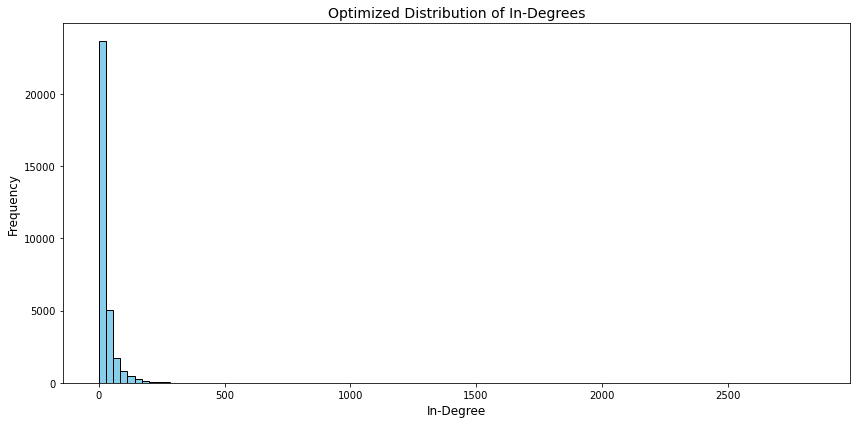

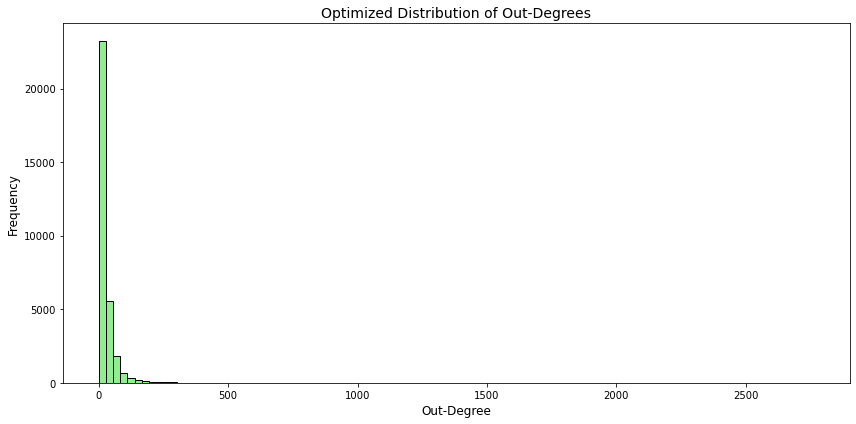

In [12]:
# Calculate in and out degrees
in_degrees = np.array([d for _, d in G.in_degree()])
out_degrees = np.array([d for _, d in G.out_degree()])

# Optimized histogram calculation for in-degrees
in_counts, in_bin_edges = np.histogram(in_degrees, bins=100)

# Optimized histogram calculation for out-degrees
out_counts, out_bin_edges = np.histogram(out_degrees, bins=100)

# Plot optimized distribution of in-degrees
plt.figure(figsize=(12, 6))
plt.bar(in_bin_edges[:-1], in_counts, width=np.diff(in_bin_edges), edgecolor='black', color='skyblue', align='edge')
plt.xlabel('In-Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Optimized Distribution of In-Degrees', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

# Plot optimized distribution of out-degrees
plt.figure(figsize=(12, 6))
plt.bar(out_bin_edges[:-1], out_counts, width=np.diff(out_bin_edges), edgecolor='black', color='lightgreen', align='edge')
plt.xlabel('Out-Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Optimized Distribution of Out-Degrees', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

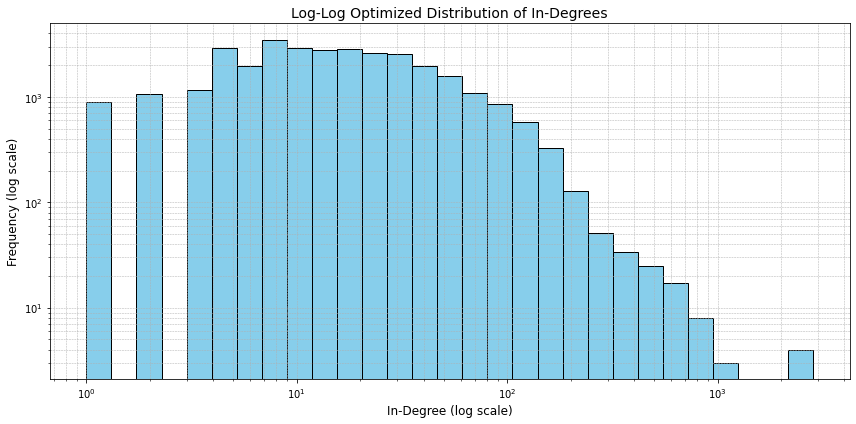

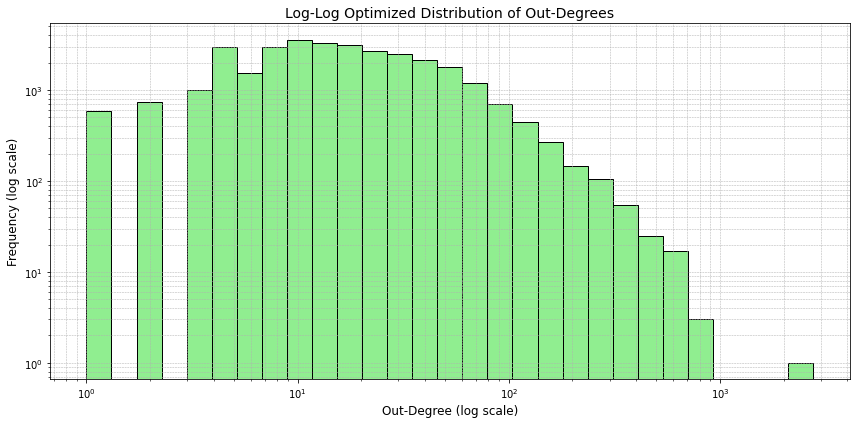

In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Read the data
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

# Check for duplicate edges
print(f"Total edges in dataframe: {len(edges_df)}")
unique_edges = edges_df.drop_duplicates(subset=['from', 'to'])
print(f"Unique edges: {len(unique_edges)}")
if len(edges_df) > len(unique_edges):
    print(f"Found {len(edges_df) - len(unique_edges)} duplicate edges!")
    print("This means the data represents a weighted directed graph, not an unweighted one.")
else:
    print("No duplicate edges found. The data represents an unweighted directed graph.")

# Create directed graph
G = nx.DiGraph()

# Add nodes with metadata
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

# Print basic graph information
print(f"\nGraph Summary:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is directed: {nx.is_directed(G)}")

# Calculate in-degree and out-degree for each node
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Find the mode (most common) in-degree and out-degree
in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

# Most common in-degree(s)
mode_in_degree = in_degree_counts.most_common(1)[0][0]
mode_in_degree_count = in_degree_counts.most_common(1)[0][1]
print(f"\nMode in-degree: {mode_in_degree} (occurs {mode_in_degree_count} times)")

# Most common out-degree(s)
mode_out_degree = out_degree_counts.most_common(1)[0][0]
mode_out_degree_count = out_degree_counts.most_common(1)[0][1]
print(f"Mode out-degree: {mode_out_degree} (occurs {mode_out_degree_count} times)")

# Show distribution of in-degrees and out-degrees
print("\nIn-degree distribution:")
for degree, count in sorted(in_degree_counts.items()):
    print(f"In-degree {degree}: {count} nodes ({count/G.number_of_nodes()*100:.2f}%)")

print("\nOut-degree distribution:")
for degree, count in sorted(out_degree_counts.items()):
    print(f"Out-degree {degree}: {count} nodes ({count/G.number_of_nodes()*100:.2f}%)")

# Check for strongly connected components
strongly_connected = list(nx.strongly_connected_components(G))
print(f"\nNumber of strongly connected components: {len(strongly_connected)}")
print(f"Size of largest strongly connected component: {len(max(strongly_connected, key=len))}")

# Calculate basic network metrics
try:
    print(f"Average clustering coefficient: {nx.average_clustering(G)}")
except:
    print("Average clustering coefficient: Not applicable for directed graphs without considering them as undirected")

try:
    print(f"Average shortest path length: {nx.average_shortest_path_length(G)}")
except:
    print("Average shortest path length: Cannot be calculated (graph may not be strongly connected)")

# Check for cycles
has_cycles = not nx.is_directed_acyclic_graph(G)
print(f"Graph contains cycles: {has_cycles}")

# Get module distribution
if 'module' in metadata_df.columns:
    module_counts = metadata_df['module'].value_counts()
    print("\nModule distribution:")
    for module, count in module_counts.items():
        print(f"Module {module}: {count} nodes")

Total edges in dataframe: 849981
Unique edges: 849981
No duplicate edges found. The data represents an unweighted directed graph.

Graph Summary:
Number of nodes: 32272
Number of edges: 849981
Is directed: True

Mode in-degree: 6 (occurs 1957 times)
Mode out-degree: 6 (occurs 1550 times)

In-degree distribution:
In-degree 0: 437 nodes (1.35%)
In-degree 1: 889 nodes (2.75%)
In-degree 2: 1070 nodes (3.32%)
In-degree 3: 1157 nodes (3.59%)
In-degree 4: 1298 nodes (4.02%)
In-degree 5: 1614 nodes (5.00%)
In-degree 6: 1957 nodes (6.06%)
In-degree 7: 1950 nodes (6.04%)
In-degree 8: 1547 nodes (4.79%)
In-degree 9: 1209 nodes (3.75%)
In-degree 10: 931 nodes (2.88%)
In-degree 11: 792 nodes (2.45%)
In-degree 12: 785 nodes (2.43%)
In-degree 13: 705 nodes (2.18%)
In-degree 14: 637 nodes (1.97%)
In-degree 15: 637 nodes (1.97%)
In-degree 16: 637 nodes (1.97%)
In-degree 17: 545 nodes (1.69%)
In-degree 18: 565 nodes (1.75%)
In-degree 19: 547 nodes (1.69%)
In-degree 20: 539 nodes (1.67%)
In-degree 21: 47

Loaded 849981 edges from fly_edges.csv
Edge data sample:
   from    to
0     1  2485
1     1  3253
2     1  4808
3     1  7958
4     1  9762
Loaded 32272 nodes from fly_metadata.csv
Node metadata sample:
   node_id       x       y       z  module             root_id
0        1  376168  214326   76240       3  720575940602120928
1        2  558260  333872  193800      46  720575940602313952
2        3  386386  292214  121260      21  720575940602380768
3        4  618936  262556   95280      11  720575940602415584
4        5  637136  171048  143760      14  720575940602553568
Created graph with 32272 nodes and 849981 edges
In-degree statistics:
  Average: 26.34
  Median: 13.0
  Maximum: 2843
Power law fit results:
  Exponent (α): 2.906
  Minimum degree threshold (xmin): 176
  Kolmogorov-Smirnov statistic: 0.0011
  Goodness of fit (smaller is better): 0.0011
  This is a good fit based on the KS statistic (D < 0.1).

Alternative fit (using curve_fit on PDF):
  Power law exponent (k): 1.44

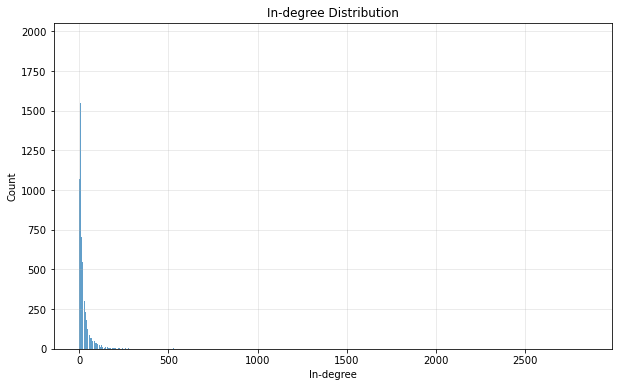

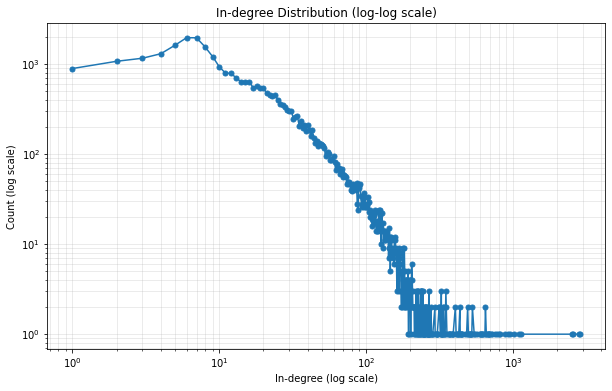

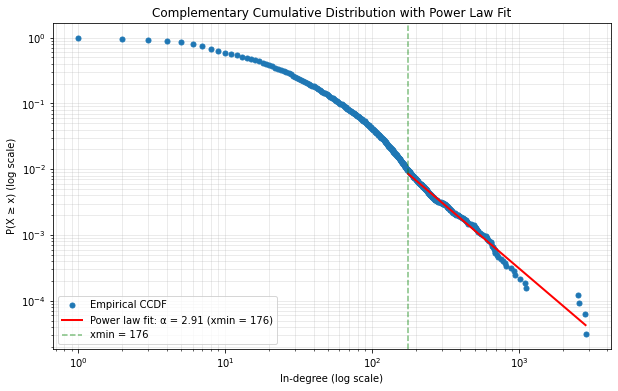

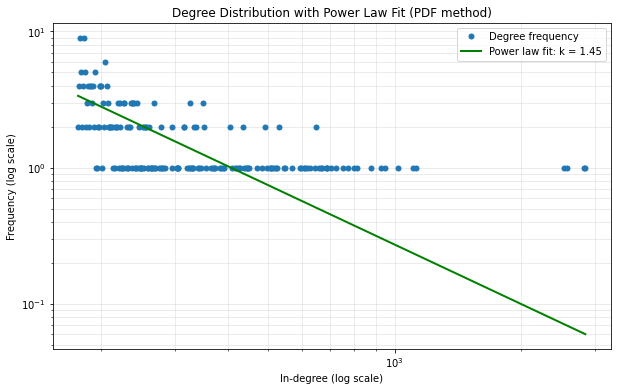

In [17]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import curve_fit

# Load the data
def load_network_data(edges_file, metadata_file):
    """
    Load network data from edge list and node metadata files.
    
    Parameters:
    -----------
    edges_file : str
        Path to the CSV file containing edges (from,to)
    metadata_file : str
        Path to the CSV file containing node metadata (node_id,x,y,z,module,root_id)
        
    Returns:
    --------
    G : networkx.Graph
        Network graph with node attributes
    metadata_df : pandas.DataFrame
        DataFrame containing node metadata
    """
    # Load edge data
    edges_df = pd.read_csv(edges_file)
    print(f"Loaded {len(edges_df)} edges from {edges_file}")
    print(f"Edge data sample:\n{edges_df.head()}")
    
    # Load node metadata
    metadata_df = pd.read_csv(metadata_file)
    print(f"Loaded {len(metadata_df)} nodes from {metadata_file}")
    print(f"Node metadata sample:\n{metadata_df.head()}")
    
    # Create graph from edge list
    G = nx.from_pandas_edgelist(edges_df, 'from', 'to', create_using=nx.DiGraph())
    
    # Convert metadata to dictionary for adding node attributes
    # Using node_id as the key
    node_attrs = metadata_df.set_index('node_id').to_dict('index')
    
    # Add node attributes to the graph
    for node_id, attrs in node_attrs.items():
        if node_id in G.nodes():
            nx.set_node_attributes(G, {node_id: attrs})
    
    # Check nodes without metadata
    missing_metadata = [node for node in G.nodes() if node not in node_attrs]
    if missing_metadata:
        print(f"Warning: {len(missing_metadata)} nodes don't have metadata")
    
    # Check nodes without connections
    missing_connections = [node for node in node_attrs if node not in G.nodes()]
    if missing_connections:
        print(f"Warning: {len(missing_connections)} nodes in metadata don't have connections")
    
    print(f"Created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    return G, metadata_df

def analyze_in_degree_distribution(G):
    """
    Analyze the in-degree distribution of the network.
    
    Parameters:
    -----------
    G : networkx.Graph
        Network graph
        
    Returns:
    --------
    in_degrees : list
        List of in-degrees for each node
    degree_counts : dict
        Dictionary with in-degree as key and count as value
    """
    # Get in-degrees for all nodes
    in_degrees = [d for n, d in G.in_degree()]
    
    # Count frequency of each degree
    degree_counts = {}
    for degree in in_degrees:
        if degree in degree_counts:
            degree_counts[degree] += 1
        else:
            degree_counts[degree] = 1
    
    # Basic statistics
    avg_in_degree = np.mean(in_degrees)
    median_in_degree = np.median(in_degrees)
    max_in_degree = max(in_degrees)
    
    print(f"In-degree statistics:")
    print(f"  Average: {avg_in_degree:.2f}")
    print(f"  Median: {median_in_degree}")
    print(f"  Maximum: {max_in_degree}")
    
    return in_degrees, degree_counts

def plot_degree_distribution(degree_counts):
    """
    Plot the in-degree distribution.
    
    Parameters:
    -----------
    degree_counts : dict
        Dictionary with in-degree as key and count as value
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        Figure with the plot
    """
    degrees = list(degree_counts.keys())
    counts = list(degree_counts.values())
    
    # Sort by degree for the plot
    sorted_data = sorted(zip(degrees, counts))
    degrees, counts = zip(*sorted_data)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Linear scale plot
    ax.bar(degrees, counts, width=0.8, alpha=0.7)
    ax.set_xlabel('In-degree')
    ax.set_ylabel('Count')
    ax.set_title('In-degree Distribution')
    ax.grid(True, alpha=0.3)
    
    # Create second plot with log-log scale
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    # Filter out zero degrees for log scale
    non_zero_degrees = [d for d in degrees if d > 0]
    non_zero_counts = [degree_counts[d] for d in non_zero_degrees]
    
    # Use log-log scale for power law identification
    ax2.loglog(non_zero_degrees, non_zero_counts, 'o-', markersize=5)
    ax2.set_xlabel('In-degree (log scale)')
    ax2.set_ylabel('Count (log scale)')
    ax2.set_title('In-degree Distribution (log-log scale)')
    ax2.grid(True, alpha=0.3, which='both')
    
    return fig, fig2

def fit_power_law(degree_counts, xmin=None):
    """
    Fit a power law to the degree distribution.
    
    Parameters:
    -----------
    degree_counts : dict
        Dictionary with in-degree as key and count as value
    xmin : int, optional
        Minimum degree to include in the fit. If None, estimate it.
        
    Returns:
    --------
    alpha : float
        Power law exponent
    D : float
        Kolmogorov-Smirnov statistic
    xmin : int
        Minimum degree included in the fit
    fig : matplotlib.figure.Figure
        Figure with the fit
    """
    degrees = np.array(list(degree_counts.keys()))
    counts = np.array(list(degree_counts.values()))
    
    # Convert to CCDF (Complementary Cumulative Distribution Function)
    # Sort by degree
    sorted_indices = np.argsort(degrees)
    degrees = degrees[sorted_indices]
    counts = counts[sorted_indices]
    
    # Calculate cumulative sum and normalize
    total_nodes = np.sum(counts)
    ccdf = np.cumsum(counts[::-1])[::-1] / total_nodes
    
    # If xmin not provided, estimate it
    if xmin is None:
        # Try different xmin values and pick the one with the best fit
        best_ks = float('inf')
        best_alpha = None
        best_xmin = None
        
        # Try different thresholds (from 5th percentile to 50th percentile)
        thresholds = np.percentile(degrees, [5, 10, 15, 20, 25, 30, 40, 50])
        
        for threshold in thresholds:
            threshold = int(threshold)
            if threshold < 1:
                threshold = 1
                
            # Filter data above threshold
            mask = degrees >= threshold
            if np.sum(mask) < 10:  # Need enough points for a fit
                continue
                
            x_filtered = degrees[mask]
            y_filtered = ccdf[mask]
            
            # Fit power law: p(x) ∝ x^(-alpha)
            # For CCDF, we fit P(X>x) ∝ x^(-alpha+1)
            
            # Log transform for linear fit
            log_x = np.log(x_filtered)
            log_y = np.log(y_filtered)
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
            
            # Calculate alpha (note: CCDF slope is -alpha+1, so alpha is 1-slope)
            alpha = 1 - slope
            
            # Calculate fitted y values
            y_fit = np.exp(intercept) * x_filtered ** (-alpha + 1)
            
            # Calculate KS statistic
            ks_stat = np.max(np.abs(y_filtered - y_fit))
            
            if ks_stat < best_ks:
                best_ks = ks_stat
                best_alpha = alpha
                best_xmin = threshold
        
        xmin = best_xmin
        alpha = best_alpha
        D = best_ks
    else:
        # Filter data above threshold
        mask = degrees >= xmin
        if np.sum(mask) < 10:
            raise ValueError("Not enough data points above xmin")
            
        x_filtered = degrees[mask]
        y_filtered = ccdf[mask]
        
        # Log transform for linear fit
        log_x = np.log(x_filtered)
        log_y = np.log(y_filtered)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
        
        # Calculate alpha (note: CCDF slope is -alpha+1, so alpha is 1-slope)
        alpha = 1 - slope
        
        # Calculate fitted y values
        y_fit = np.exp(intercept) * x_filtered ** (-alpha + 1)
        
        # Calculate KS statistic
        D = np.max(np.abs(y_filtered - y_fit))
    
    # Plot the result
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the data
    ax.loglog(degrees, ccdf, 'o', markersize=5, label='Empirical CCDF')
    
    # Plot the fit
    mask = degrees >= xmin
    x_fit = degrees[mask]
    y_fit = np.exp(intercept) * x_fit ** (-alpha + 1)
    ax.loglog(x_fit, y_fit, 'r-', linewidth=2, 
             label=f'Power law fit: α = {alpha:.2f} (xmin = {xmin})')
    
    # Add vertical line at xmin
    ax.axvline(x=xmin, color='green', linestyle='--', alpha=0.5,
               label=f'xmin = {xmin}')
    
    ax.set_xlabel('In-degree (log scale)')
    ax.set_ylabel('P(X ≥ x) (log scale)')
    ax.set_title('Complementary Cumulative Distribution with Power Law Fit')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()
    
    # Print results
    print(f"Power law fit results:")
    print(f"  Exponent (α): {alpha:.3f}")
    print(f"  Minimum degree threshold (xmin): {xmin}")
    print(f"  Kolmogorov-Smirnov statistic: {D:.4f}")
    print(f"  Goodness of fit (smaller is better): {D:.4f}")
    
    # Check if this is a good fit based on the KS statistic
    if D < 0.1:
        print("  This is a good fit based on the KS statistic (D < 0.1).")
    elif D < 0.2:
        print("  This is a moderate fit based on the KS statistic (0.1 <= D < 0.2).")
    else:
        print("  This is a poor fit based on the KS statistic (D >= 0.2).")
        
    # Alternative method: direct fit to PDF using curve_fit
    # Define power law function
    def power_law(x, a, k):
        return a * x**(-k)
    
    # Get degree frequencies for curve_fit
    degrees_array = np.array(list(degree_counts.keys()))
    counts_array = np.array(list(degree_counts.values()))
    
    # Filter by xmin
    mask = degrees_array >= xmin
    x_data = degrees_array[mask]
    y_data = counts_array[mask]
    
    if len(x_data) > 10:  # Need enough points
        try:
            # Fit power law to PDF
            popt, pcov = curve_fit(power_law, x_data, y_data)
            a, k = popt
            
            print(f"\nAlternative fit (using curve_fit on PDF):")
            print(f"  Power law exponent (k): {k:.3f}")
            print(f"  Scaling factor (a): {a:.3f}")
            
            # Add to plot
            x_range = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 100)
            y_fit2 = power_law(x_range, a, k)
            
            # Create a separate plot for PDF fit
            fig2, ax2 = plt.subplots(figsize=(10, 6))
            ax2.loglog(x_data, y_data, 'o', markersize=5, label='Degree frequency')
            ax2.loglog(x_range, y_fit2, 'g-', linewidth=2, 
                     label=f'Power law fit: k = {k:.2f}')
            ax2.set_xlabel('In-degree (log scale)')
            ax2.set_ylabel('Frequency (log scale)')
            ax2.set_title('Degree Distribution with Power Law Fit (PDF method)')
            ax2.grid(True, alpha=0.3, which='both')
            ax2.legend()
            
            return alpha, D, xmin, [fig, fig2]
        except:
            print("Could not fit curve using curve_fit method")
    
    return alpha, D, xmin, [fig]

def main():
    """Main function to run the analysis."""
    # Load the data
    G, metadata_df = load_network_data('fly_edges.csv', 'fly_metadata.csv')
    
    # Analyze in-degree distribution
    in_degrees, degree_counts = analyze_in_degree_distribution(G)
    
    # Plot the distribution
    fig1, fig2 = plot_degree_distribution(degree_counts)
    
    # Fit power law
    alpha, D, xmin, fit_figs = fit_power_law(degree_counts)
    
    plt.show()
    
    return G, in_degrees, degree_counts, alpha, xmin

if __name__ == "__main__":
    G, in_degrees, degree_counts, alpha, xmin = main()

Loaded 849981 edges from fly_edges.csv
Created graph with 32272 nodes and 849981 edges
In-degree statistics:
  Average: 26.34
  Maximum: 2843
Out-degree statistics:
  Average: 26.34
  Maximum: 2763
Nodes with zero in-degree: 437 (1.35% of nodes)
Nodes with zero out-degree: 417 (1.29% of nodes)


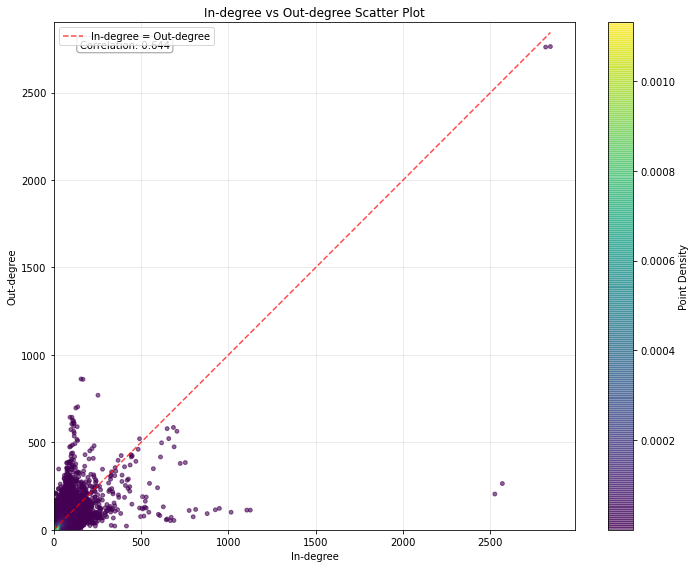

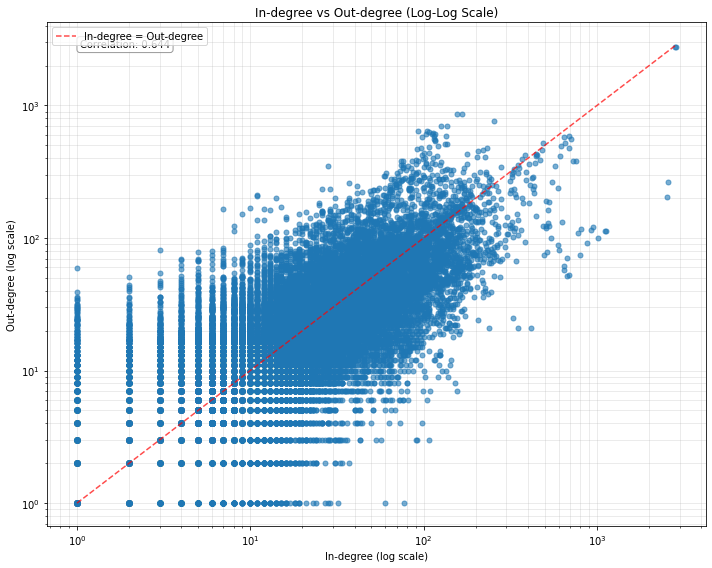


Degree Assortativity Coefficients:
  In-In Assortativity: -0.0584
  In-Out Assortativity: -0.0380
  Out-In Assortativity: -0.0854
  Out-Out Assortativity: -0.0535
  The network shows little in-in degree assortativity.
  The network shows little out-out degree assortativity.

Average Neighbor Degree Correlations:
  In-degree to neighbors' in-degree: -0.1441
  In-degree to neighbors' out-degree: -0.1668
  Out-degree to neighbors' in-degree: -0.1949
  Out-degree to neighbors' out-degree: -0.1730


In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def create_degree_scatter_plot(edges_file):
    """
    Load network from edge list and create a scatter plot of in-degrees vs out-degrees.
    
    Parameters:
    -----------
    edges_file : str
        Path to the CSV file containing edges (from,to)
        
    Returns:
    --------
    G : networkx.DiGraph
        The directed graph created from the edge list
    """
    # Load edge data
    edges_df = pd.read_csv(edges_file)
    print(f"Loaded {len(edges_df)} edges from {edges_file}")
    
    # Create a directed graph from the edge list
    G = nx.from_pandas_edgelist(edges_df, 'from', 'to', create_using=nx.DiGraph())
    print(f"Created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Get in-degrees and out-degrees using NetworkX functions
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Create lists of in-degree and out-degree for each node
    nodes = G.nodes()
    in_degree_values = [in_degrees.get(node, 0) for node in nodes]
    out_degree_values = [out_degrees.get(node, 0) for node in nodes]
    
    # Calculate basic statistics
    avg_in_degree = np.mean(in_degree_values)
    avg_out_degree = np.mean(out_degree_values)
    max_in_degree = max(in_degree_values)
    max_out_degree = max(out_degree_values)
    
    print(f"In-degree statistics:")
    print(f"  Average: {avg_in_degree:.2f}")
    print(f"  Maximum: {max_in_degree}")
    print(f"Out-degree statistics:")
    print(f"  Average: {avg_out_degree:.2f}")
    print(f"  Maximum: {max_out_degree}")
    
    # Count nodes with specific degree combinations
    zero_in_count = sum(1 for d in in_degree_values if d == 0)
    zero_out_count = sum(1 for d in out_degree_values if d == 0)
    print(f"Nodes with zero in-degree: {zero_in_count} ({zero_in_count/len(nodes):.2%} of nodes)")
    print(f"Nodes with zero out-degree: {zero_out_count} ({zero_out_count/len(nodes):.2%} of nodes)")
    
    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    
    # Calculate point density for coloring
    from scipy.stats import gaussian_kde
    xy = np.vstack([in_degree_values, out_degree_values])
    try:
        # Try to calculate point density (may fail if all points are the same)
        z = gaussian_kde(xy)(xy)
        plt.scatter(in_degree_values, out_degree_values, c=z, alpha=0.6, s=15, cmap='viridis')
        plt.colorbar(label='Point Density')
    except:
        # Fallback if density calculation fails
        plt.scatter(in_degree_values, out_degree_values, alpha=0.6, s=15)
    
    # Add reference line for equal in-degree and out-degree
    max_degree = max(max_in_degree, max_out_degree)
    plt.plot([0, max_degree], [0, max_degree], 'r--', alpha=0.7, label='In-degree = Out-degree')
    
    # Set axis limits with some padding
    plt.xlim(-0.5, max_in_degree * 1.05)
    plt.ylim(-0.5, max_out_degree * 1.05)
    
    # Add labels and title
    plt.xlabel('In-degree')
    plt.ylabel('Out-degree')
    plt.title('In-degree vs Out-degree Scatter Plot')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Add text with correlation coefficient
    correlation = np.corrcoef(in_degree_values, out_degree_values)[0, 1]
    plt.annotate(f'Correlation: {correlation:.3f}', 
                 xy=(0.05, 0.95), 
                 xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    # Save and show the plot
    plt.tight_layout()
    plt.savefig('degree_scatter_plot.png', dpi=300)
    plt.show()
    
    # Create log-log version for better visualization if there are extreme values
    if max_in_degree > 20 and max_out_degree > 20:
        plt.figure(figsize=(10, 8))
        
        # Filter out zeros for log scale
        non_zero_indices = [i for i, (x, y) in enumerate(zip(in_degree_values, out_degree_values)) 
                           if x > 0 and y > 0]
        non_zero_in = [in_degree_values[i] for i in non_zero_indices]
        non_zero_out = [out_degree_values[i] for i in non_zero_indices]
        
        plt.loglog(non_zero_in, non_zero_out, 'o', alpha=0.6, markersize=5)
        
        # Add reference line
        plt.loglog([1, max_degree], [1, max_degree], 'r--', alpha=0.7, label='In-degree = Out-degree')
        
        # Add labels and title
        plt.xlabel('In-degree (log scale)')
        plt.ylabel('Out-degree (log scale)')
        plt.title('In-degree vs Out-degree (Log-Log Scale)')
        plt.grid(True, alpha=0.3, which='both')
        plt.legend()
        
        # Add text with correlation coefficient
        plt.annotate(f'Correlation: {correlation:.3f}', 
                     xy=(0.05, 0.95), 
                     xycoords='axes fraction', 
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
        
        plt.tight_layout()
        plt.savefig('degree_scatter_plot_log.png', dpi=300)
        plt.show()
    
    return G

def analyze_degree_correlation(G):
    """
    Analyze the assortativity and correlation of degrees in the network.
    
    Parameters:
    -----------
    G : networkx.DiGraph
        The directed graph to analyze
    """
    # Calculate degree assortativity coefficient
    # This measures the tendency of nodes to connect to nodes with similar degrees
    try:
        in_in_assortativity = nx.degree_assortativity_coefficient(G, x='in', y='in')
        in_out_assortativity = nx.degree_assortativity_coefficient(G, x='in', y='out')
        out_in_assortativity = nx.degree_assortativity_coefficient(G, x='out', y='in')
        out_out_assortativity = nx.degree_assortativity_coefficient(G, x='out', y='out')
        
        print("\nDegree Assortativity Coefficients:")
        print(f"  In-In Assortativity: {in_in_assortativity:.4f}")
        print(f"  In-Out Assortativity: {in_out_assortativity:.4f}")
        print(f"  Out-In Assortativity: {out_in_assortativity:.4f}")
        print(f"  Out-Out Assortativity: {out_out_assortativity:.4f}")
        
        if in_in_assortativity > 0.1:
            print("  The network shows positive in-in degree assortativity: nodes with high in-degree")
            print("  tend to connect to other nodes with high in-degree.")
        elif in_in_assortativity < -0.1:
            print("  The network shows negative in-in degree assortativity: nodes with high in-degree")
            print("  tend to connect to nodes with low in-degree.")
        else:
            print("  The network shows little in-in degree assortativity.")
            
        if out_out_assortativity > 0.1:
            print("  The network shows positive out-out degree assortativity: nodes with high out-degree")
            print("  tend to connect to other nodes with high out-degree.")
        elif out_out_assortativity < -0.1:
            print("  The network shows negative out-out degree assortativity: nodes with high out-degree")
            print("  tend to connect to nodes with low out-degree.")
        else:
            print("  The network shows little out-out degree assortativity.")
    except Exception as e:
        print(f"Could not calculate degree assortativity: {str(e)}")
    
    # Calculate additional degree correlation measures
    # Using NetworkX's built-in average neighbor degree function
    avg_nbr_in_deg_by_in = nx.average_neighbor_degree(G, source='in', target='in')
    avg_nbr_out_deg_by_in = nx.average_neighbor_degree(G, source='in', target='out')
    avg_nbr_in_deg_by_out = nx.average_neighbor_degree(G, source='out', target='in')
    avg_nbr_out_deg_by_out = nx.average_neighbor_degree(G, source='out', target='out')
    
    # Get in and out degrees
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Create sorted lists of degrees and average neighbor degrees for correlation plots
    nodes = list(G.nodes())
    
    in_deg = [in_degrees.get(n, 0) for n in nodes]
    out_deg = [out_degrees.get(n, 0) for n in nodes]
    
    avg_nbr_in_by_in = [avg_nbr_in_deg_by_in.get(n, 0) for n in nodes]
    avg_nbr_out_by_in = [avg_nbr_out_deg_by_in.get(n, 0) for n in nodes]
    avg_nbr_in_by_out = [avg_nbr_in_deg_by_out.get(n, 0) for n in nodes]
    avg_nbr_out_by_out = [avg_nbr_out_deg_by_out.get(n, 0) for n in nodes]
    
    # Calculate correlations
    corr_in_in = np.corrcoef(in_deg, avg_nbr_in_by_in)[0, 1] if len(set(in_deg)) > 1 and len(set(avg_nbr_in_by_in)) > 1 else 0
    corr_in_out = np.corrcoef(in_deg, avg_nbr_out_by_in)[0, 1] if len(set(in_deg)) > 1 and len(set(avg_nbr_out_by_in)) > 1 else 0
    corr_out_in = np.corrcoef(out_deg, avg_nbr_in_by_out)[0, 1] if len(set(out_deg)) > 1 and len(set(avg_nbr_in_by_out)) > 1 else 0
    corr_out_out = np.corrcoef(out_deg, avg_nbr_out_by_out)[0, 1] if len(set(out_deg)) > 1 and len(set(avg_nbr_out_by_out)) > 1 else 0
    
    print("\nAverage Neighbor Degree Correlations:")
    print(f"  In-degree to neighbors' in-degree: {corr_in_in:.4f}")
    print(f"  In-degree to neighbors' out-degree: {corr_in_out:.4f}")
    print(f"  Out-degree to neighbors' in-degree: {corr_out_in:.4f}")
    print(f"  Out-degree to neighbors' out-degree: {corr_out_out:.4f}")

if __name__ == "__main__":
    # Call the function to create the scatter plot
    G = create_degree_scatter_plot('fly_edges.csv')
    
    # Analyze degree correlations and assortativity
    analyze_degree_correlation(G)

Loaded 849981 edges from fly_edges.csv
Created graph with 32272 nodes and 849981 edges


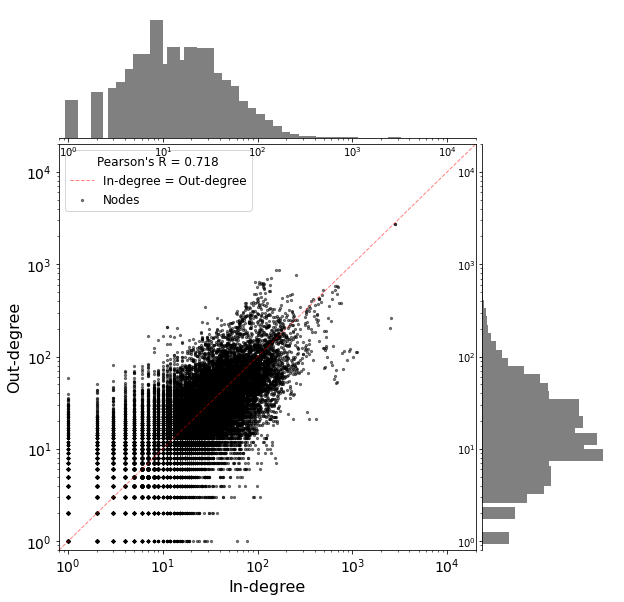

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

def create_degree_loglog_with_histograms(edges_file):
    """
    Create a log-log scatter plot of in-degrees vs out-degrees with marginal histograms.
    
    Parameters:
    -----------
    edges_file : str
        Path to the CSV file containing edges (from,to)
    """
    # Load edge data
    edges_df = pd.read_csv(edges_file)
    print(f"Loaded {len(edges_df)} edges from {edges_file}")
    
    # Create a directed graph from the edge list
    G = nx.from_pandas_edgelist(edges_df, 'from', 'to', create_using=nx.DiGraph())
    print(f"Created graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Get in-degrees and out-degrees using NetworkX functions
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Create lists of in-degree and out-degree for each node
    nodes = list(G.nodes())
    in_degree_values = np.array([in_degrees.get(node, 0) for node in nodes])
    out_degree_values = np.array([out_degrees.get(node, 0) for node in nodes])
    
    # Create figure with GridSpec for the layout
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(4, 4, figure=fig)
    
    # Main scatter plot (log-log)
    ax_main = fig.add_subplot(gs[1:4, 0:3])
    
    # Side histograms
    ax_top = fig.add_subplot(gs[0, 0:3])  # Top histogram for in-degree
    ax_right = fig.add_subplot(gs[1:4, 3])  # Right histogram for out-degree
    
    # Adjust the spacing
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
    
    # Remove frames and ticks from histograms
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['left'].set_visible(False)
    ax_top.xaxis.set_ticks_position('bottom')
    ax_top.yaxis.set_ticks_position('none')
    ax_top.set_yticks([])
    
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['bottom'].set_visible(False)
    ax_right.xaxis.set_ticks_position('none')
    ax_right.yaxis.set_ticks_position('left')
    ax_right.set_xticks([])
    
    # Filter out zeros for log scale
    mask = (in_degree_values > 0) & (out_degree_values > 0)
    in_deg_filtered = in_degree_values[mask]
    out_deg_filtered = out_degree_values[mask]
    
    # Calculate Pearson's correlation coefficient
    correlation = np.corrcoef(np.log10(in_deg_filtered), np.log10(out_deg_filtered))[0, 1]
    
    # Create the main scatter plot with log-log scale
    ax_main.scatter(in_deg_filtered, out_deg_filtered, s=5, alpha=0.5, color='black', label='Nodes')
    ax_main.set_xscale('log')
    ax_main.set_yscale('log')
    
    # Set limits that match the image
    ax_main.set_xlim(0.8, 20000)
    ax_main.set_ylim(0.8, 20000)
    
    # Set custom tick locations for log scale
    log_ticks = [1, 10, 100, 1000, 10000]
    ax_main.set_xticks(log_ticks)
    ax_main.set_yticks(log_ticks)
    
    # Increase tick label font size
    ax_main.tick_params(axis='both', which='major', labelsize=14)
    
    # Set axis labels like in the image with larger font size
    ax_main.set_xlabel('In-degree', fontsize=16)
    ax_main.set_ylabel('Out-degree', fontsize=16)
    
    # Add diagonal line where in-degree = out-degree
    ax_main.plot([0.8, 20000], [0.8, 20000], 'k--', alpha=0.5, linewidth=1,color='red',
                label='In-degree = Out-degree')
    
    # Add legend with correlation coefficient
    ax_main.legend(loc='upper left', fontsize=12, 
                  title=f"Pearson's R = {correlation:.3f}", title_fontsize=12)
    
    # Create log-bin edges for histograms
    log_bins = np.logspace(np.log10(0.8), np.log10(20000), 50)
    
    # Top histogram (in-degree)
    in_counts, in_bins = np.histogram(in_degree_values, bins=log_bins)
    # Normalize counts
    in_counts = in_counts / in_counts.max() * 0.9  # Scale to fit in the top margin
    bin_centers = 0.5 * (in_bins[1:] + in_bins[:-1])
    ax_top.bar(bin_centers, -in_counts, width=bin_centers*0.3, align='center', color='gray', edgecolor=None)
    ax_top.set_xscale('log')
    ax_top.set_xlim(0.8, 20000)
    ax_top.set_ylim(-1, 0)
    ax_top.invert_yaxis()
    
    # Right histogram (out-degree)
    out_counts, out_bins = np.histogram(out_degree_values, bins=log_bins)
    # Normalize counts
    out_counts = out_counts / out_counts.max() * 0.9  # Scale to fit in the right margin
    bin_centers = 0.5 * (out_bins[1:] + out_bins[:-1])
    ax_right.barh(bin_centers, out_counts, height=bin_centers*0.3, align='center', color='gray', edgecolor=None)
    ax_right.set_yscale('log')
    ax_right.set_ylim(0.8, 20000)
    ax_right.set_xlim(0, 1)
    
    # Save the figure in high resolution
    plt.savefig('degree_loglog_with_histograms.png', dpi=600, bbox_inches='tight', format='png')
    plt.savefig('degree_loglog_with_histograms.pdf', bbox_inches='tight', format='pdf')  # Also save as PDF for vector quality
    plt.show()
    
    return G, in_degrees, out_degrees

if __name__ == "__main__":
    G, in_degrees, out_degrees = create_degree_loglog_with_histograms('fly_edges.csv')

Starting analysis of fly_edges.csv and fly_metadata.csv...
Starting network analysis...
Loading edges from fly_edges.csv...
Loading nodes from fly_metadata.csv...
Network has 32272 nodes and 849981 edges
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating in-degrees and out-degrees...

In-degree statistics:
  Min: 0
  Max: 2843
  Mean: 26.34
  Median: 13.0

Out-degree statistics:
  Min: 0
  Max: 2763
  Mean: 26.34
  Median: 14.0

Computing degree distributions...
Computing cumulative degree distributions...

Fitting power law models...
In-degree power law fit: alpha = 1.7140, R² = 0.9384
Out-degree power law fit: alpha = 1.7362, R² = 0.9255

Creating visualization plots...
Saved in-degree histogram
Saved out-degree histogram
Saved in-degree CCDF plot
Saved out-degree CCDF plot
Saved combined CCDF plot

Summary of findings:
--------------------------------------------------
In-degree distribution:
  Power law exponent (alpha): 1.7140
  R-squared value:

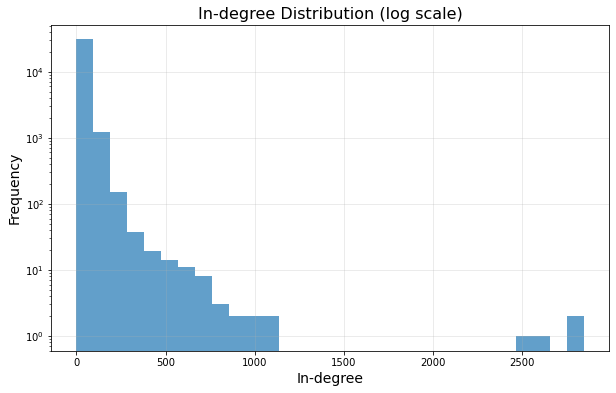

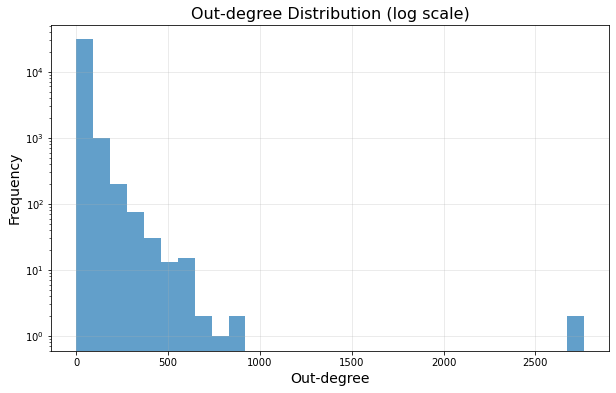

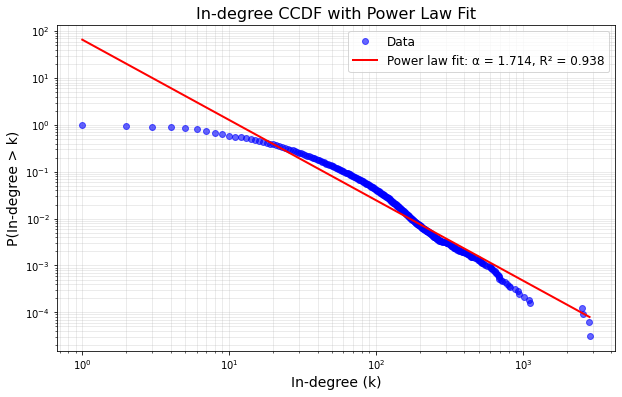

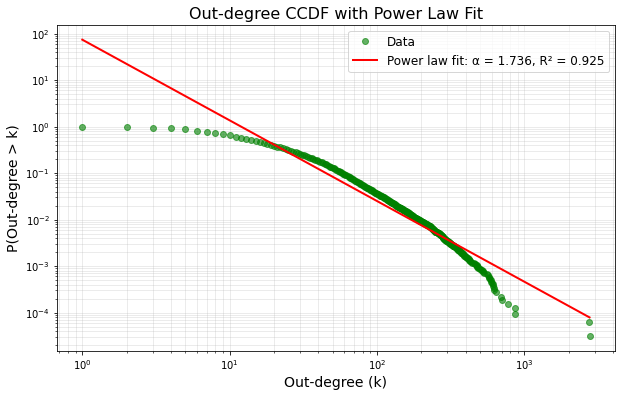

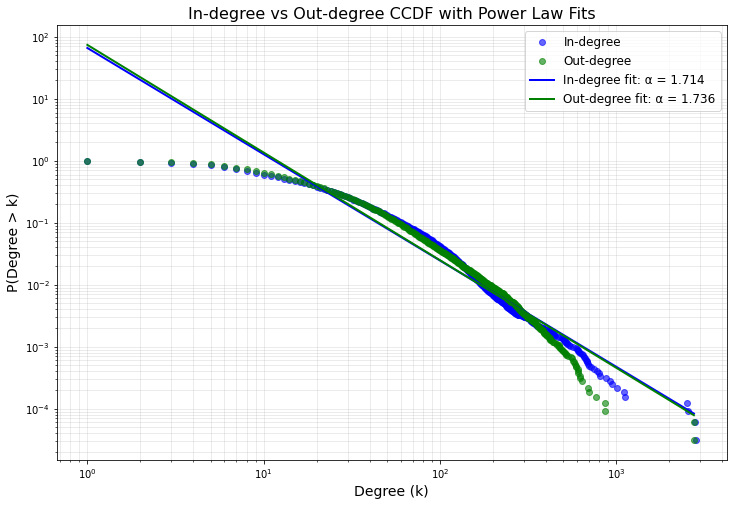

In [30]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from collections import Counter

def analyze_network_degrees(edges_file, metadata_file):
    """
    Analyze the degree distributions of a network and test for power law fit.
    
    Parameters:
    -----------
    edges_file : str
        Path to CSV file containing edge data with 'from' and 'to' columns
    metadata_file : str
        Path to CSV file containing node metadata
    """
    print("Starting network analysis...")
    
    # Load the data
    print(f"Loading edges from {edges_file}...")
    edges_df = pd.read_csv(edges_file)
    
    print(f"Loading nodes from {metadata_file}...")
    nodes_df = pd.read_csv(metadata_file)
    
    print(f"Network has {len(nodes_df)} nodes and {len(edges_df)} edges")
    
    # Create directed graph
    print("Creating directed graph...")
    G = nx.DiGraph()
    
    # Add all nodes first (including isolated nodes)
    G.add_nodes_from(nodes_df['node_id'].values)
    
    # Add edges
    edge_list = list(zip(edges_df['from'], edges_df['to']))
    G.add_edges_from(edge_list)
    
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Calculate in-degrees and out-degrees
    print("Calculating in-degrees and out-degrees...")
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Basic degree statistics
    in_degree_values = list(in_degrees.values())
    out_degree_values = list(out_degrees.values())
    
    print("\nIn-degree statistics:")
    print(f"  Min: {min(in_degree_values)}")
    print(f"  Max: {max(in_degree_values)}")
    print(f"  Mean: {np.mean(in_degree_values):.2f}")
    print(f"  Median: {np.median(in_degree_values)}")
    
    print("\nOut-degree statistics:")
    print(f"  Min: {min(out_degree_values)}")
    print(f"  Max: {max(out_degree_values)}")
    print(f"  Mean: {np.mean(out_degree_values):.2f}")
    print(f"  Median: {np.median(out_degree_values)}")
    
    # Compute degree distributions
    print("\nComputing degree distributions...")
    in_degree_hist = Counter(in_degree_values)
    out_degree_hist = Counter(out_degree_values)
    
    # Compute CCDF (Complementary Cumulative Distribution Function)
    print("Computing cumulative degree distributions...")
    
    def compute_ccdf(degree_counts, total_nodes):
        """Compute the complementary cumulative distribution function"""
        # Sort degrees
        sorted_degrees = sorted(degree_counts.items())
        degrees = np.array([x[0] for x in sorted_degrees])
        counts = np.array([x[1] for x in sorted_degrees])
        
        # Calculate CCDF: P(X > x)
        ccdf = np.zeros_like(degrees, dtype=float)
        for i, d in enumerate(degrees):
            # Sum of all nodes with degree >= d
            ccdf[i] = sum(counts[i:]) / total_nodes
            
        return degrees, ccdf
    
    # Calculate CCDFs
    in_degrees_x, in_degrees_ccdf = compute_ccdf(in_degree_hist, G.number_of_nodes())
    out_degrees_x, out_degrees_ccdf = compute_ccdf(out_degree_hist, G.number_of_nodes())
    
    # Fit power law model: P(X > x) ~ x^(-alpha)
    # In log-log scale: log(P(X > x)) = -alpha * log(x) + c
    print("\nFitting power law models...")
    
    def fit_power_law(x, y):
        """Fit power law model using linear regression in log-log space"""
        # Filter out zeros for log transform
        mask = (x > 0) & (y > 0)
        x_log = np.log10(x[mask])
        y_log = np.log10(y[mask])
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
        
        # Calculate alpha (negative of slope)
        alpha = -slope
        r_squared = r_value**2
        
        return alpha, intercept, r_squared
    
    # Fit power laws
    in_alpha, in_intercept, in_r_squared = fit_power_law(in_degrees_x, in_degrees_ccdf)
    out_alpha, out_intercept, out_r_squared = fit_power_law(out_degrees_x, out_degrees_ccdf)
    
    print(f"In-degree power law fit: alpha = {in_alpha:.4f}, R² = {in_r_squared:.4f}")
    print(f"Out-degree power law fit: alpha = {out_alpha:.4f}, R² = {out_r_squared:.4f}")
    
    # Create a directory for plots if it doesn't exist
    os.makedirs('network_analysis_plots', exist_ok=True)
    
    # Create visualization plots
    print("\nCreating visualization plots...")
    
    # Plot in-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(in_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('In-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('In-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/in_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree histogram")
    
    # Plot out-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(out_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('Out-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('Out-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/out_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree histogram")
    
    # Plot in-degree CCDF with power law fit
    plt.figure(figsize=(10, 6))
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='Data')
    
    # Add power law fit line
    x_fit = np.logspace(np.log10(min(in_degrees_x[in_degrees_x > 0])), 
                        np.log10(max(in_degrees_x)), 50)
    y_fit = 10**(in_intercept) * x_fit**(-in_alpha)
    plt.loglog(x_fit, y_fit, 'r-', linewidth=2, 
              label=f'Power law fit: α = {in_alpha:.3f}, R² = {in_r_squared:.3f}')
    
    plt.xlabel('In-degree (k)', fontsize=14)
    plt.ylabel('P(In-degree > k)', fontsize=14)
    plt.title('In-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/in_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree CCDF plot")
    
    # Plot out-degree CCDF with power law fit
    plt.figure(figsize=(10, 6))
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Data')
    
    # Add power law fit line
    x_fit = np.logspace(np.log10(min(out_degrees_x[out_degrees_x > 0])), 
                        np.log10(max(out_degrees_x)), 50)
    y_fit = 10**(out_intercept) * x_fit**(-out_alpha)
    plt.loglog(x_fit, y_fit, 'r-', linewidth=2, 
              label=f'Power law fit: α = {out_alpha:.3f}, R² = {out_r_squared:.3f}')
    
    plt.xlabel('Out-degree (k)', fontsize=14)
    plt.ylabel('P(Out-degree > k)', fontsize=14)
    plt.title('Out-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/out_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree CCDF plot")
    
    # Combined plot for comparison
    plt.figure(figsize=(12, 8))
    
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='In-degree')
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Out-degree')
    
    # Add power law fit lines
    plt.loglog(x_fit, 10**(in_intercept) * x_fit**(-in_alpha), 'b-', linewidth=2, 
              label=f'In-degree fit: α = {in_alpha:.3f}')
    plt.loglog(x_fit, 10**(out_intercept) * x_fit**(-out_alpha), 'g-', linewidth=2, 
              label=f'Out-degree fit: α = {out_alpha:.3f}')
    
    plt.xlabel('Degree (k)', fontsize=14)
    plt.ylabel('P(Degree > k)', fontsize=14)
    plt.title('In-degree vs Out-degree CCDF with Power Law Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/combined_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved combined CCDF plot")
    
    # Return results
    return {
        'in_degree': {
            'alpha': in_alpha,
            'r_squared': in_r_squared,
            'min': min(in_degree_values),
            'max': max(in_degree_values),
            'mean': np.mean(in_degree_values),
            'median': np.median(in_degree_values)
        },
        'out_degree': {
            'alpha': out_alpha,
            'r_squared': out_r_squared,
            'min': min(out_degree_values),
            'max': max(out_degree_values),
            'mean': np.mean(out_degree_values),
            'median': np.median(out_degree_values)
        }
    }

# Main execution
if __name__ == "__main__":
    # File paths
    edges_file = "fly_edges.csv"
    metadata_file = "fly_metadata.csv"
    
    print(f"Starting analysis of {edges_file} and {metadata_file}...")
    results = analyze_network_degrees(edges_file, metadata_file)
    
    # Summarize findings
    print("\nSummary of findings:")
    print("-" * 50)
    
    print("In-degree distribution:")
    print(f"  Power law exponent (alpha): {results['in_degree']['alpha']:.4f}")
    print(f"  R-squared value: {results['in_degree']['r_squared']:.4f}")
    
    print("\nOut-degree distribution:")
    print(f"  Power law exponent (alpha): {results['out_degree']['alpha']:.4f}")
    print(f"  R-squared value: {results['out_degree']['r_squared']:.4f}")
    
    # Interpret the results
    in_is_power_law = results['in_degree']['r_squared'] > 0.8
    out_is_power_law = results['out_degree']['r_squared'] > 0.8
    
    print("\nConclusion:")
    print(f"  In-degree distribution {'follows' if in_is_power_law else 'may not follow'} a power law")
    print(f"  Out-degree distribution {'follows' if out_is_power_law else 'may not follow'} a power law")
    
    print("\nAll plots saved at 600 dpi in the 'network_analysis_plots' directory")

Starting analysis of fly_edges.csv and fly_metadata.csv...
Starting network analysis...
Loading edges from fly_edges.csv...
Loading nodes from fly_metadata.csv...
Network has 32272 nodes and 849981 edges
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating in-degrees and out-degrees...

In-degree statistics:
  Min: 0
  Max: 2843
  Mean: 26.34
  Median: 13.0

Out-degree statistics:
  Min: 0
  Max: 2763
  Mean: 26.34
  Median: 14.0

Computing degree distributions...
Computing cumulative degree distributions...

Fitting different distribution models...
Fitting models to in-degree distribution:
  Stretched exponential fit: x0=16.1605, beta=0.6947, a=1.2334, R²=0.9975
  Truncated power law fit: alpha=0.1337, x_c=31.6078, a=1.1217e+00, R²=0.9933

Fitting models to out-degree distribution:
  Stretched exponential fit: x0=17.6976, beta=0.7617, a=1.2042, R²=0.9967
  Truncated power law fit: alpha=0.0861, x_c=27.2606, a=1.1162e+00, R²=0.9935
In-degree power law 

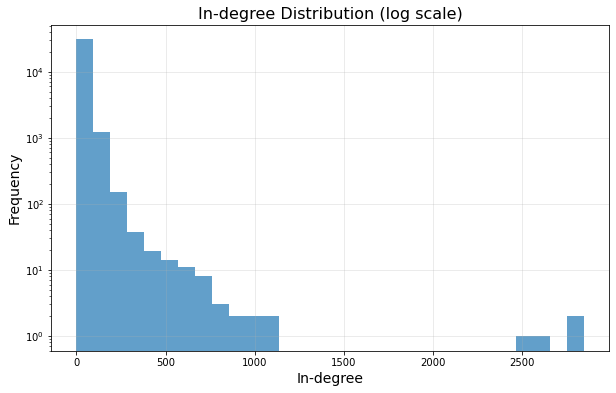

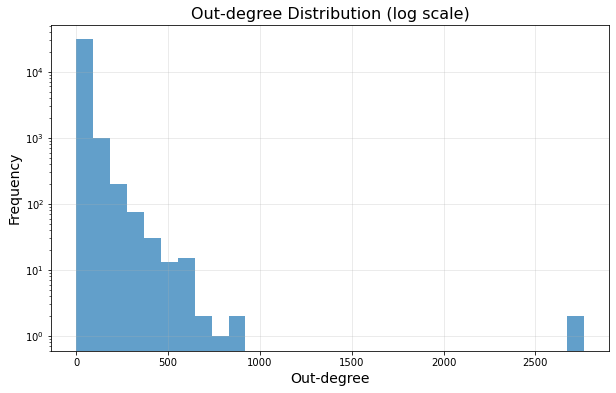

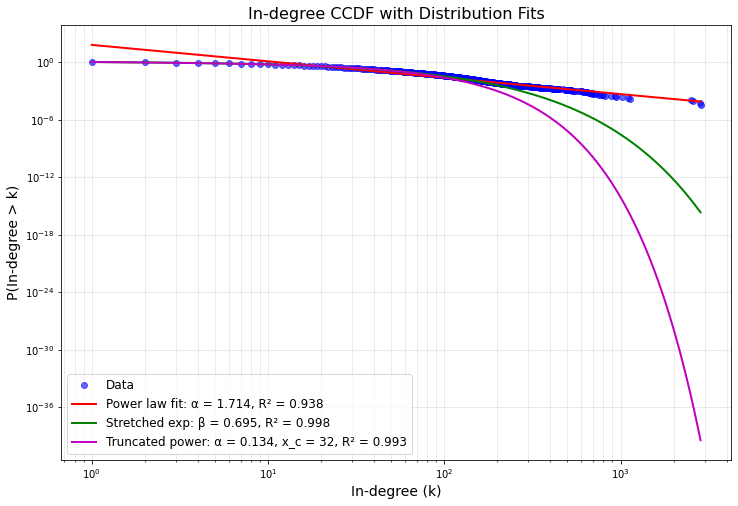

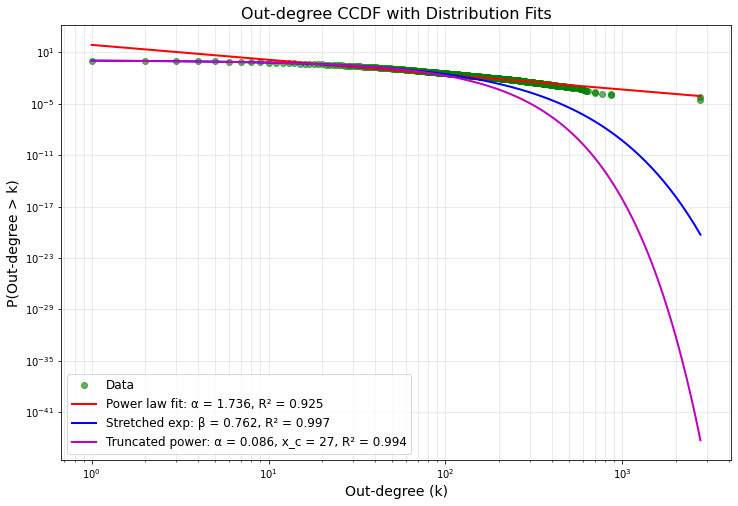

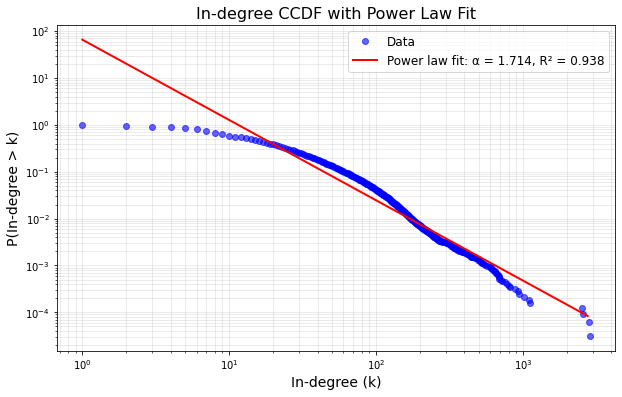

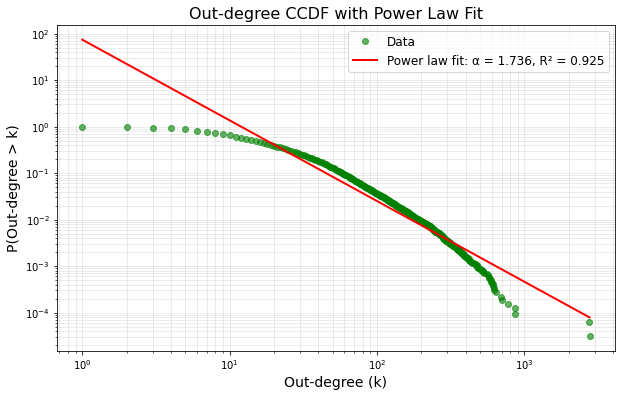

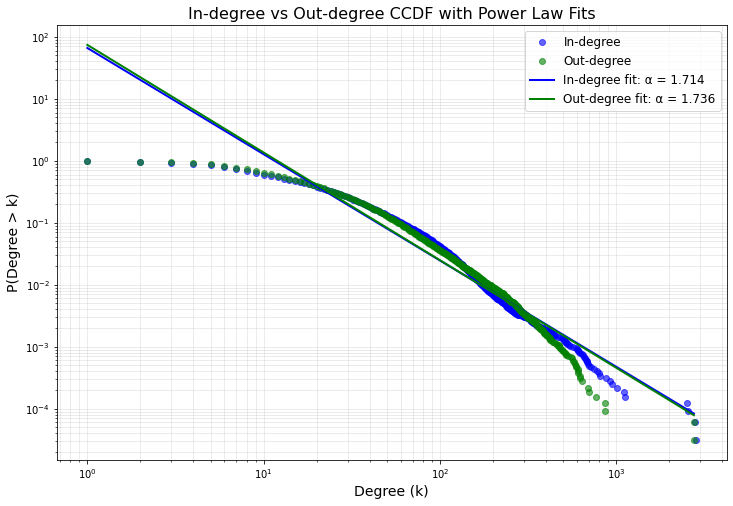

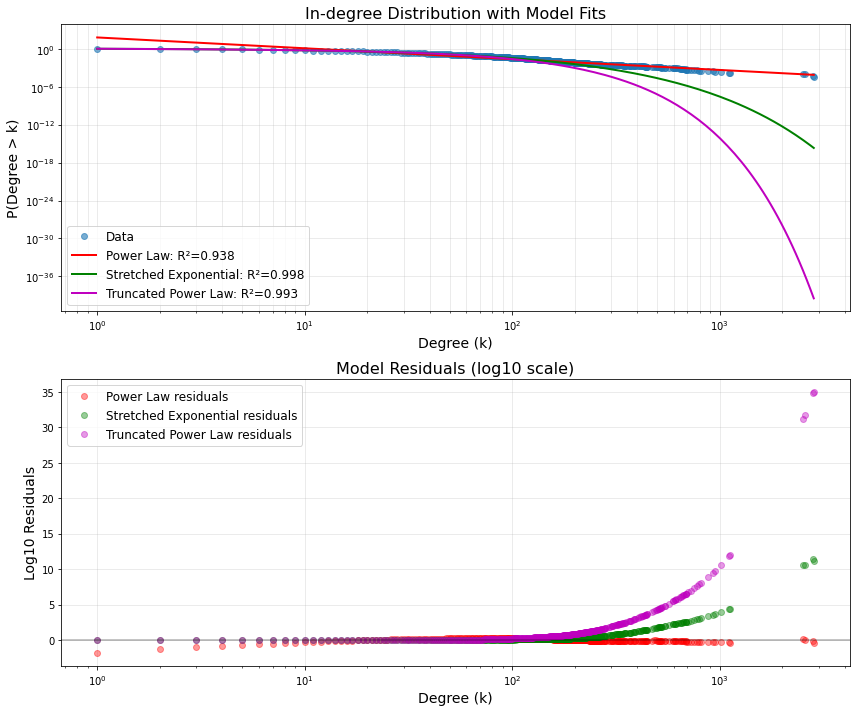

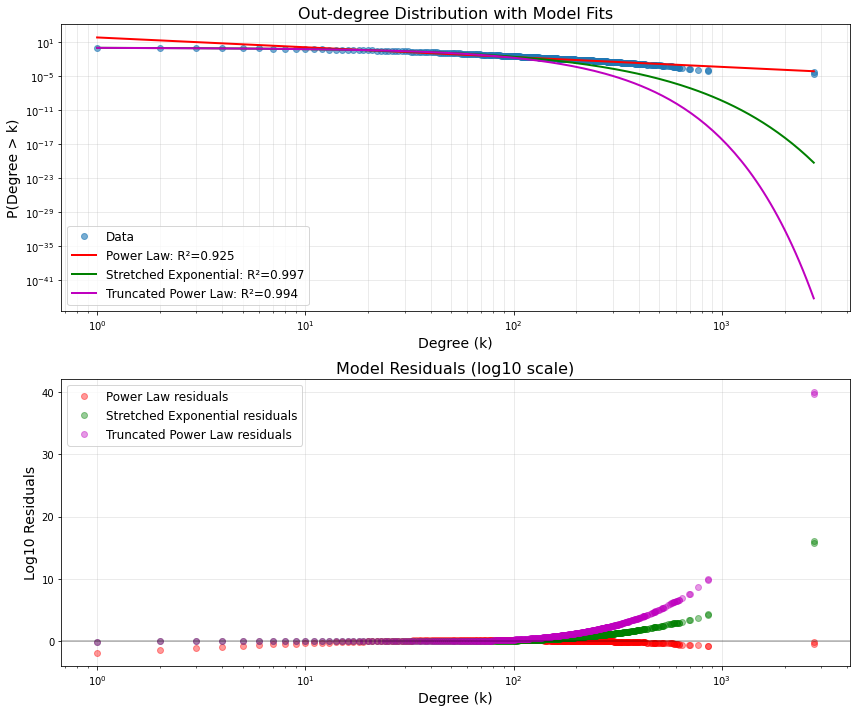

In [31]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from collections import Counter

def analyze_network_degrees(edges_file, metadata_file):
    """
    Analyze the degree distributions of a network and test for power law fit.
    
    Parameters:
    -----------
    edges_file : str
        Path to CSV file containing edge data with 'from' and 'to' columns
    metadata_file : str
        Path to CSV file containing node metadata
    """
    print("Starting network analysis...")
    
    # Load the data
    print(f"Loading edges from {edges_file}...")
    edges_df = pd.read_csv(edges_file)
    
    print(f"Loading nodes from {metadata_file}...")
    nodes_df = pd.read_csv(metadata_file)
    
    print(f"Network has {len(nodes_df)} nodes and {len(edges_df)} edges")
    
    # Create directed graph
    print("Creating directed graph...")
    G = nx.DiGraph()
    
    # Add all nodes first (including isolated nodes)
    G.add_nodes_from(nodes_df['node_id'].values)
    
    # Add edges
    edge_list = list(zip(edges_df['from'], edges_df['to']))
    G.add_edges_from(edge_list)
    
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Calculate in-degrees and out-degrees
    print("Calculating in-degrees and out-degrees...")
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Basic degree statistics
    in_degree_values = list(in_degrees.values())
    out_degree_values = list(out_degrees.values())
    
    print("\nIn-degree statistics:")
    print(f"  Min: {min(in_degree_values)}")
    print(f"  Max: {max(in_degree_values)}")
    print(f"  Mean: {np.mean(in_degree_values):.2f}")
    print(f"  Median: {np.median(in_degree_values)}")
    
    print("\nOut-degree statistics:")
    print(f"  Min: {min(out_degree_values)}")
    print(f"  Max: {max(out_degree_values)}")
    print(f"  Mean: {np.mean(out_degree_values):.2f}")
    print(f"  Median: {np.median(out_degree_values)}")
    
    # Compute degree distributions
    print("\nComputing degree distributions...")
    in_degree_hist = Counter(in_degree_values)
    out_degree_hist = Counter(out_degree_values)
    
    # Compute CCDF (Complementary Cumulative Distribution Function)
    print("Computing cumulative degree distributions...")
    
    def compute_ccdf(degree_counts, total_nodes):
        """Compute the complementary cumulative distribution function"""
        # Sort degrees
        sorted_degrees = sorted(degree_counts.items())
        degrees = np.array([x[0] for x in sorted_degrees])
        counts = np.array([x[1] for x in sorted_degrees])
        
        # Calculate CCDF: P(X > x)
        ccdf = np.zeros_like(degrees, dtype=float)
        for i, d in enumerate(degrees):
            # Sum of all nodes with degree >= d
            ccdf[i] = sum(counts[i:]) / total_nodes
            
        return degrees, ccdf
    
    # Calculate CCDFs
    in_degrees_x, in_degrees_ccdf = compute_ccdf(in_degree_hist, G.number_of_nodes())
    out_degrees_x, out_degrees_ccdf = compute_ccdf(out_degree_hist, G.number_of_nodes())
    
    # Fit various distributions to model the degree distributions
    print("\nFitting different distribution models...")
    
    def fit_power_law(x, y):
        """Fit power law model using linear regression in log-log space
        P(X > x) ~ x^(-alpha)
        """
        # Filter out zeros for log transform
        mask = (x > 0) & (y > 0)
        x_log = np.log10(x[mask])
        y_log = np.log10(y[mask])
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
        
        # Calculate alpha (negative of slope)
        alpha = -slope
        r_squared = r_value**2
        
        return {
            'name': 'Power Law',
            'params': {'alpha': alpha, 'c': 10**intercept},
            'alpha': alpha,
            'intercept': intercept,
            'r_squared': r_squared,
            'function': lambda x: 10**intercept * x**(-alpha)
        }
    
    def fit_stretched_exponential(x, y):
        """Fit stretched exponential model
        P(X > x) ~ exp(-(x/x0)^beta) where beta < 1
        """
        from scipy.optimize import curve_fit
        
        # Filter out zeros
        mask = (x > 0) & (y > 0)
        x_filtered = x[mask]
        y_filtered = y[mask]
        
        # Define stretched exponential function
        def stretched_exp(x, x0, beta, a):
            return a * np.exp(-(x/x0)**beta)
        
        # Initial parameter guesses
        p0 = [np.median(x_filtered), 0.5, max(y_filtered)]
        
        try:
            # Fit the model
            params, cov = curve_fit(stretched_exp, x_filtered, y_filtered, p0=p0, 
                                   bounds=([0, 0, 0], [np.inf, 1, np.inf]), maxfev=10000)
            x0, beta, a = params
            
            # Calculate R-squared
            y_pred = stretched_exp(x_filtered, *params)
            ss_res = np.sum((y_filtered - y_pred)**2)
            ss_tot = np.sum((y_filtered - np.mean(y_filtered))**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            print(f"  Stretched exponential fit: x0={x0:.4f}, beta={beta:.4f}, a={a:.4f}, R²={r_squared:.4f}")
            
            return {
                'name': 'Stretched Exponential',
                'params': {'x0': x0, 'beta': beta, 'a': a},
                'r_squared': r_squared,
                'function': lambda x: stretched_exp(x, x0, beta, a)
            }
        except Exception as e:
            print(f"  Error fitting stretched exponential: {str(e)}")
            return None
    
    def fit_truncated_power_law(x, y):
        """Fit truncated power law model
        P(X > x) ~ x^(-alpha) * exp(-x/x_c)
        """
        from scipy.optimize import curve_fit
        
        # Filter out zeros
        mask = (x > 0) & (y > 0)
        x_filtered = x[mask]
        y_filtered = y[mask]
        
        # Define truncated power law function
        def truncated_power_law(x, alpha, x_c, a):
            return a * x**(-alpha) * np.exp(-x/x_c)
        
        # Initial parameter guesses - use power law alpha as starting point
        _, _, r_value, _, _ = stats.linregress(np.log10(x_filtered), np.log10(y_filtered))
        power_law_alpha = -r_value
        p0 = [power_law_alpha if power_law_alpha > 0 else 1.5, max(x_filtered), max(y_filtered)]
        
        try:
            # Fit the model
            params, cov = curve_fit(truncated_power_law, x_filtered, y_filtered, p0=p0, 
                                   bounds=([0, 0, 0], [10, np.inf, np.inf]), maxfev=10000)
            alpha, x_c, a = params
            
            # Calculate R-squared
            y_pred = truncated_power_law(x_filtered, *params)
            ss_res = np.sum((y_filtered - y_pred)**2)
            ss_tot = np.sum((y_filtered - np.mean(y_filtered))**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            print(f"  Truncated power law fit: alpha={alpha:.4f}, x_c={x_c:.4f}, a={a:.4e}, R²={r_squared:.4f}")
            
            return {
                'name': 'Truncated Power Law',
                'params': {'alpha': alpha, 'x_c': x_c, 'a': a},
                'r_squared': r_squared,
                'function': lambda x: truncated_power_law(x, alpha, x_c, a)
            }
        except Exception as e:
            print(f"  Error fitting truncated power law: {str(e)}")
            return None
    
    # Fit various models to in-degree distribution
    print("Fitting models to in-degree distribution:")
    in_power_law = fit_power_law(in_degrees_x, in_degrees_ccdf)
    in_stretched_exp = fit_stretched_exponential(in_degrees_x, in_degrees_ccdf)
    in_truncated_power = fit_truncated_power_law(in_degrees_x, in_degrees_ccdf)
    
    # Fit various models to out-degree distribution
    print("\nFitting models to out-degree distribution:")
    out_power_law = fit_power_law(out_degrees_x, out_degrees_ccdf)
    out_stretched_exp = fit_stretched_exponential(out_degrees_x, out_degrees_ccdf)
    out_truncated_power = fit_truncated_power_law(out_degrees_x, out_degrees_ccdf)
    
    # Store results for simpler reference
    in_alpha = in_power_law['alpha']
    in_intercept = in_power_law['intercept']
    in_r_squared = in_power_law['r_squared']
    
    out_alpha = out_power_law['alpha']
    out_intercept = out_power_law['intercept']
    out_r_squared = out_power_law['r_squared']
    
    print(f"In-degree power law fit: alpha = {in_alpha:.4f}, R² = {in_r_squared:.4f}")
    print(f"Out-degree power law fit: alpha = {out_alpha:.4f}, R² = {out_r_squared:.4f}")
    
    # Create a directory for plots if it doesn't exist
    os.makedirs('network_analysis_plots', exist_ok=True)
    
    # Create visualization plots
    print("\nCreating visualization plots...")
    
    # Plot in-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(in_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('In-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('In-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/in_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree histogram")
    
    # Plot out-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(out_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('Out-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('Out-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/out_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree histogram")
    
    # Plot in-degree CCDF with different model fits
    plt.figure(figsize=(12, 8))
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='Data')
    
    # Create x values for fit lines
    x_fit = np.logspace(np.log10(min(in_degrees_x[in_degrees_x > 0])), 
                        np.log10(max(in_degrees_x)), 200)
    
    # Add power law fit line
    plt.loglog(x_fit, in_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {in_alpha:.3f}, R² = {in_r_squared:.3f}')
    
    # Add stretched exponential fit if available
    if in_stretched_exp:
        plt.loglog(x_fit, in_stretched_exp['function'](x_fit), 'g-', linewidth=2,
                  label=f'Stretched exp: β = {in_stretched_exp["params"]["beta"]:.3f}, R² = {in_stretched_exp["r_squared"]:.3f}')
    
    # Add truncated power law fit if available
    if in_truncated_power:
        plt.loglog(x_fit, in_truncated_power['function'](x_fit), 'm-', linewidth=2,
                  label=f'Truncated power: α = {in_truncated_power["params"]["alpha"]:.3f}, x_c = {in_truncated_power["params"]["x_c"]:.0f}, R² = {in_truncated_power["r_squared"]:.3f}')
    
    plt.xlabel('In-degree (k)', fontsize=14)
    plt.ylabel('P(In-degree > k)', fontsize=14)
    plt.title('In-degree CCDF with Distribution Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/in_degree_ccdf_models.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree CCDF plot with multiple models")
    
    # Plot out-degree CCDF with different model fits
    plt.figure(figsize=(12, 8))
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Data')
    
    # Create x values for fit lines
    x_fit = np.logspace(np.log10(min(out_degrees_x[out_degrees_x > 0])), 
                        np.log10(max(out_degrees_x)), 200)
    
    # Add power law fit line
    plt.loglog(x_fit, out_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {out_alpha:.3f}, R² = {out_r_squared:.3f}')
    
    # Add stretched exponential fit if available
    if out_stretched_exp:
        plt.loglog(x_fit, out_stretched_exp['function'](x_fit), 'b-', linewidth=2,
                  label=f'Stretched exp: β = {out_stretched_exp["params"]["beta"]:.3f}, R² = {out_stretched_exp["r_squared"]:.3f}')
    
    # Add truncated power law fit if available
    if out_truncated_power:
        plt.loglog(x_fit, out_truncated_power['function'](x_fit), 'm-', linewidth=2,
                  label=f'Truncated power: α = {out_truncated_power["params"]["alpha"]:.3f}, x_c = {out_truncated_power["params"]["x_c"]:.0f}, R² = {out_truncated_power["r_squared"]:.3f}')
    
    plt.xlabel('Out-degree (k)', fontsize=14)
    plt.ylabel('P(Out-degree > k)', fontsize=14)
    plt.title('Out-degree CCDF with Distribution Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/out_degree_ccdf_models.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree CCDF plot with multiple models")
    
    # Also save the original single power law plots for comparison
    # Plot in-degree CCDF with power law fit only
    plt.figure(figsize=(10, 6))
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='Data')
    plt.loglog(x_fit, in_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {in_alpha:.3f}, R² = {in_r_squared:.3f}')
    plt.xlabel('In-degree (k)', fontsize=14)
    plt.ylabel('P(In-degree > k)', fontsize=14)
    plt.title('In-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/in_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree CCDF plot with power law only")
    
    # Plot out-degree CCDF with power law fit only
    plt.figure(figsize=(10, 6))
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Data')
    plt.loglog(x_fit, out_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {out_alpha:.3f}, R² = {out_r_squared:.3f}')
    plt.xlabel('Out-degree (k)', fontsize=14)
    plt.ylabel('P(Out-degree > k)', fontsize=14)
    plt.title('Out-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/out_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree CCDF plot with power law only")
    
    # Combined plot for comparison
    plt.figure(figsize=(12, 8))
    
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='In-degree')
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Out-degree')
    
    # Add power law fit lines
    plt.loglog(x_fit, 10**(in_intercept) * x_fit**(-in_alpha), 'b-', linewidth=2, 
              label=f'In-degree fit: α = {in_alpha:.3f}')
    plt.loglog(x_fit, 10**(out_intercept) * x_fit**(-out_alpha), 'g-', linewidth=2, 
              label=f'Out-degree fit: α = {out_alpha:.3f}')
    
    plt.xlabel('Degree (k)', fontsize=14)
    plt.ylabel('P(Degree > k)', fontsize=14)
    plt.title('In-degree vs Out-degree CCDF with Power Law Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/combined_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved combined CCDF plot")
    
    # Visual comparison of model fits
    print("\nCreating model comparison residual plots...")
    
    # Function to calculate residuals for model comparison
    def plot_model_residuals(degrees_x, degrees_ccdf, models, title_prefix, file_suffix):
        plt.figure(figsize=(12, 10))
        
        # Create a 2x1 subplot layout
        plt.subplot(2, 1, 1)
        
        # Filter out zeros for log scale
        mask = (degrees_x > 0) & (degrees_ccdf > 0)
        x_filtered = degrees_x[mask]
        y_filtered = degrees_ccdf[mask]
        
        # Plot the data
        plt.loglog(x_filtered, y_filtered, 'o', alpha=0.6, label='Data')
        
        # Plot the models
        x_fit = np.logspace(np.log10(min(x_filtered)), np.log10(max(x_filtered)), 200)
        colors = ['r', 'g', 'm', 'c', 'y']
        
        for i, model in enumerate(models):
            if model is not None:
                y_pred = model['function'](x_fit)
                plt.loglog(x_fit, y_pred, colors[i%len(colors)]+'-', linewidth=2, 
                           label=f"{model['name']}: R²={model['r_squared']:.3f}")
        
        plt.xlabel('Degree (k)', fontsize=14)
        plt.ylabel('P(Degree > k)', fontsize=14)
        plt.title(f'{title_prefix} Distribution with Model Fits', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3, which='both')
        
        # Residual plot (lower subplot)
        plt.subplot(2, 1, 2)
        
        for i, model in enumerate(models):
            if model is not None:
                # Calculate model predictions at the exact data points
                y_pred = model['function'](x_filtered)
                
                # Calculate log-residuals
                log_residuals = np.log10(y_filtered) - np.log10(y_pred)
                
                # Plot residuals
                plt.semilogx(x_filtered, log_residuals, colors[i%len(colors)]+'o', alpha=0.4, 
                            label=f"{model['name']} residuals")
        
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Degree (k)', fontsize=14)
        plt.ylabel('Log10 Residuals', fontsize=14)
        plt.title('Model Residuals (log10 scale)', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'network_analysis_plots/{file_suffix}_model_comparison.png', dpi=600, bbox_inches='tight')
        print(f"Saved {title_prefix} model comparison plot")
    
    # Plot model comparisons with residuals
    plot_model_residuals(
        in_degrees_x, 
        in_degrees_ccdf,
        [in_power_law, in_stretched_exp, in_truncated_power],
        'In-degree',
        'in_degree'
    )
    
    plot_model_residuals(
        out_degrees_x, 
        out_degrees_ccdf,
        [out_power_law, out_stretched_exp, out_truncated_power],
        'Out-degree',
        'out_degree'
    )
    
    # Prepare results dictionary with all model parameters
    results = {
        'in_degree': {
            'alpha': in_alpha,
            'r_squared': in_r_squared,
            'min': min(in_degree_values),
            'max': max(in_degree_values),
            'mean': np.mean(in_degree_values),
            'median': np.median(in_degree_values)
        },
        'out_degree': {
            'alpha': out_alpha,
            'r_squared': out_r_squared,
            'min': min(out_degree_values),
            'max': max(out_degree_values),
            'mean': np.mean(out_degree_values),
            'median': np.median(out_degree_values)
        }
    }
    
    # Add stretched exponential results if available
    if in_stretched_exp:
        results['in_stretched_exp'] = {
            'params': in_stretched_exp['params'],
            'r_squared': in_stretched_exp['r_squared']
        }
    
    if out_stretched_exp:
        results['out_stretched_exp'] = {
            'params': out_stretched_exp['params'],
            'r_squared': out_stretched_exp['r_squared']
        }
    
    # Add truncated power law results if available
    if in_truncated_power:
        results['in_truncated_power'] = {
            'params': in_truncated_power['params'],
            'r_squared': in_truncated_power['r_squared']
        }
    
    if out_truncated_power:
        results['out_truncated_power'] = {
            'params': out_truncated_power['params'],
            'r_squared': out_truncated_power['r_squared']
        }
    
    return results

# Main execution
if __name__ == "__main__":
    # File paths
    edges_file = "fly_edges.csv"
    metadata_file = "fly_metadata.csv"
    
    print(f"Starting analysis of {edges_file} and {metadata_file}...")
    results = analyze_network_degrees(edges_file, metadata_file)
    
    # Summarize findings
    print("\nSummary of findings:")
    print("-" * 80)
    
    print("In-degree distribution model comparison:")
    print(f"  Power law fit:")
    print(f"    Exponent (alpha): {results['in_degree']['alpha']:.4f}")
    print(f"    R-squared: {results['in_degree']['r_squared']:.4f}")
    
    if 'in_stretched_exp' in results:
        print(f"  Stretched exponential fit:")
        print(f"    Beta: {results['in_stretched_exp']['params']['beta']:.4f}")
        print(f"    x0: {results['in_stretched_exp']['params']['x0']:.4f}")
        print(f"    R-squared: {results['in_stretched_exp']['r_squared']:.4f}")
    
    if 'in_truncated_power' in results:
        print(f"  Truncated power law fit:")
        print(f"    Alpha: {results['in_truncated_power']['params']['alpha']:.4f}")
        print(f"    Cutoff (x_c): {results['in_truncated_power']['params']['x_c']:.4f}")
        print(f"    R-squared: {results['in_truncated_power']['r_squared']:.4f}")
    
    print("\nOut-degree distribution model comparison:")
    print(f"  Power law fit:")
    print(f"    Exponent (alpha): {results['out_degree']['alpha']:.4f}")
    print(f"    R-squared: {results['out_degree']['r_squared']:.4f}")
    
    if 'out_stretched_exp' in results:
        print(f"  Stretched exponential fit:")
        print(f"    Beta: {results['out_stretched_exp']['params']['beta']:.4f}")
        print(f"    x0: {results['out_stretched_exp']['params']['x0']:.4f}")
        print(f"    R-squared: {results['out_stretched_exp']['r_squared']:.4f}")
    
    if 'out_truncated_power' in results:
        print(f"  Truncated power law fit:")
        print(f"    Alpha: {results['out_truncated_power']['params']['alpha']:.4f}")
        print(f"    Cutoff (x_c): {results['out_truncated_power']['params']['x_c']:.4f}")
        print(f"    R-squared: {results['out_truncated_power']['r_squared']:.4f}")
    
    # Determine best models based on R-squared values
    models = ['Power Law']
    if 'in_stretched_exp' in results:
        models.append('Stretched Exponential')
    if 'in_truncated_power' in results:
        models.append('Truncated Power Law')
    
    in_r_squared_values = [results['in_degree']['r_squared']]
    if 'in_stretched_exp' in results:
        in_r_squared_values.append(results['in_stretched_exp']['r_squared'])
    if 'in_truncated_power' in results:
        in_r_squared_values.append(results['in_truncated_power']['r_squared'])
    
    out_r_squared_values = [results['out_degree']['r_squared']]
    if 'out_stretched_exp' in results:
        out_r_squared_values.append(results['out_stretched_exp']['r_squared'])
    if 'out_truncated_power' in results:
        out_r_squared_values.append(results['out_truncated_power']['r_squared'])
    
    best_in_model_idx = in_r_squared_values.index(max(in_r_squared_values))
    best_out_model_idx = out_r_squared_values.index(max(out_r_squared_values))
    
    print("\nConclusion:")
    print(f"  Best model for in-degree distribution: {models[best_in_model_idx]} (R² = {in_r_squared_values[best_in_model_idx]:.4f})")
    print(f"  Best model for out-degree distribution: {models[best_out_model_idx]} (R² = {out_r_squared_values[best_out_model_idx]:.4f})")
    
    # Provide interpretation
    if best_in_model_idx == 0 and in_r_squared_values[0] > 0.9:
        print("\n  The in-degree distribution follows a clear power law, indicating scale-free properties.")
    elif best_in_model_idx == 1:
        print("\n  The in-degree distribution is better described by a stretched exponential, suggesting a fat-tailed distribution but not a true power law.")
    elif best_in_model_idx == 2:
        print("\n  The in-degree distribution follows a truncated power law, suggesting scale-free behavior with an exponential cutoff at higher degrees.")
    
    if best_out_model_idx == 0 and out_r_squared_values[0] > 0.9:
        print("  The out-degree distribution follows a clear power law, indicating scale-free properties.")
    elif best_out_model_idx == 1:
        print("  The out-degree distribution is better described by a stretched exponential, suggesting a fat-tailed distribution but not a true power law.")
    elif best_out_model_idx == 2:
        print("  The out-degree distribution follows a truncated power law, suggesting scale-free behavior with an exponential cutoff at higher degrees.")
    
    print("\nAll plots saved at 600 dpi in the 'network_analysis_plots' directory")

Starting analysis of fly_edges.csv and fly_metadata.csv...
Starting network analysis...
Loading edges from fly_edges.csv...
Loading nodes from fly_metadata.csv...
Network has 32272 nodes and 849981 edges
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating in-degrees and out-degrees...

In-degree statistics:
  Min: 0
  Max: 2843
  Mean: 26.34
  Median: 13.0

Out-degree statistics:
  Min: 0
  Max: 2763
  Mean: 26.34
  Median: 14.0

Computing degree distributions...
Computing cumulative degree distributions...

Fitting different distribution models...
Fitting models to in-degree distribution:
  Initial guess for double power law: alpha1=1.251, alpha2=1.904, x_threshold=177.000
  Double power law fit: alpha1=0.5792, alpha2=2.1177, x_threshold=42.0004, R²=0.9931

Fitting models to out-degree distribution:
  Initial guess for double power law: alpha1=1.286, alpha2=2.560, x_threshold=189.500
  Double power law fit: alpha1=1.0685, alpha2=2.5733, x_threshold=1

NameError: name 'in_stretched_exp' is not defined

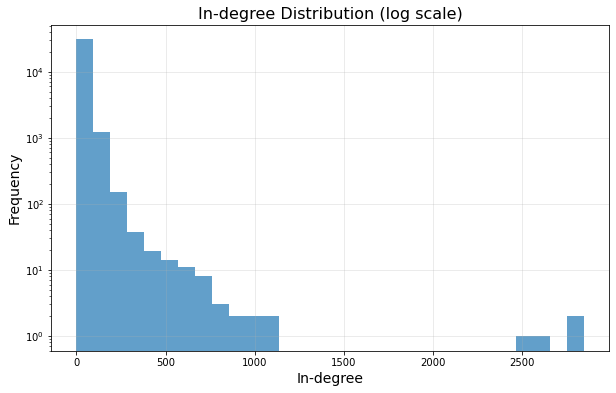

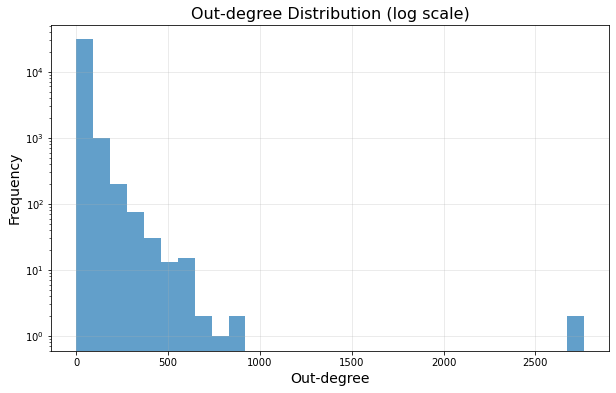

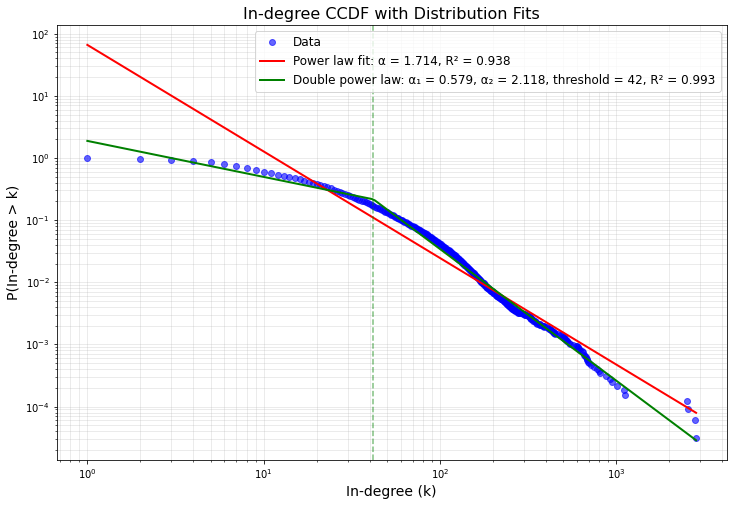

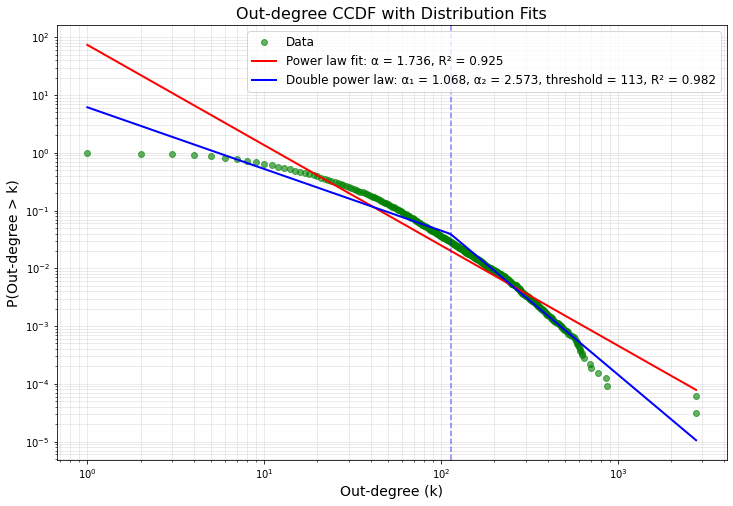

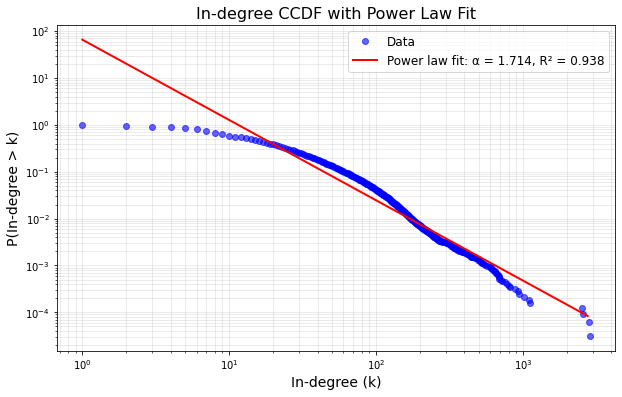

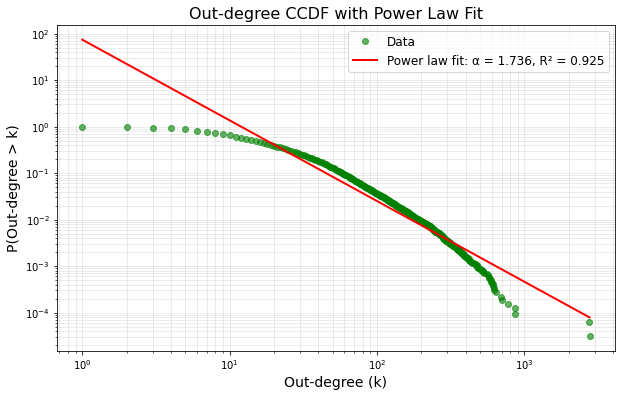

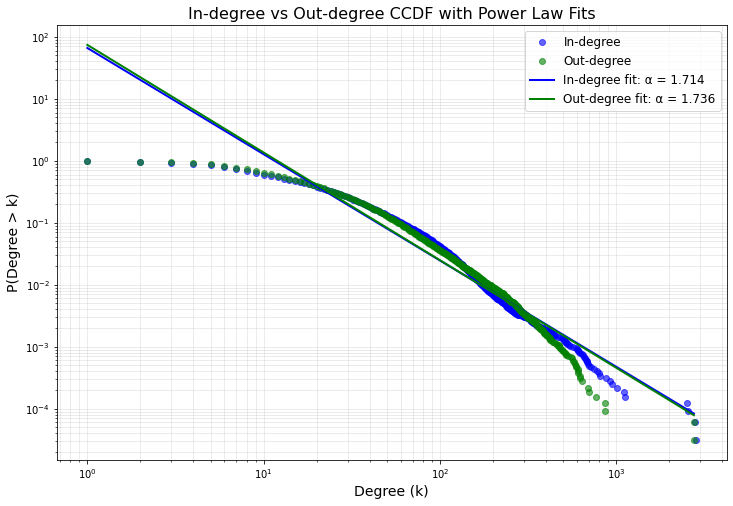

In [34]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
from collections import Counter

def analyze_network_degrees(edges_file, metadata_file):
    """
    Analyze the degree distributions of a network and test for power law fit.
    
    Parameters:
    -----------
    edges_file : str
        Path to CSV file containing edge data with 'from' and 'to' columns
    metadata_file : str
        Path to CSV file containing node metadata
    """
    print("Starting network analysis...")
    
    # Load the data
    print(f"Loading edges from {edges_file}...")
    edges_df = pd.read_csv(edges_file)
    
    print(f"Loading nodes from {metadata_file}...")
    nodes_df = pd.read_csv(metadata_file)
    
    print(f"Network has {len(nodes_df)} nodes and {len(edges_df)} edges")
    
    # Create directed graph
    print("Creating directed graph...")
    G = nx.DiGraph()
    
    # Add all nodes first (including isolated nodes)
    G.add_nodes_from(nodes_df['node_id'].values)
    
    # Add edges
    edge_list = list(zip(edges_df['from'], edges_df['to']))
    G.add_edges_from(edge_list)
    
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Calculate in-degrees and out-degrees
    print("Calculating in-degrees and out-degrees...")
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    # Basic degree statistics
    in_degree_values = list(in_degrees.values())
    out_degree_values = list(out_degrees.values())
    
    print("\nIn-degree statistics:")
    print(f"  Min: {min(in_degree_values)}")
    print(f"  Max: {max(in_degree_values)}")
    print(f"  Mean: {np.mean(in_degree_values):.2f}")
    print(f"  Median: {np.median(in_degree_values)}")
    
    print("\nOut-degree statistics:")
    print(f"  Min: {min(out_degree_values)}")
    print(f"  Max: {max(out_degree_values)}")
    print(f"  Mean: {np.mean(out_degree_values):.2f}")
    print(f"  Median: {np.median(out_degree_values)}")
    
    # Compute degree distributions
    print("\nComputing degree distributions...")
    in_degree_hist = Counter(in_degree_values)
    out_degree_hist = Counter(out_degree_values)
    
    # Compute CCDF (Complementary Cumulative Distribution Function)
    print("Computing cumulative degree distributions...")
    
    def compute_ccdf(degree_counts, total_nodes):
        """Compute the complementary cumulative distribution function"""
        # Sort degrees
        sorted_degrees = sorted(degree_counts.items())
        degrees = np.array([x[0] for x in sorted_degrees])
        counts = np.array([x[1] for x in sorted_degrees])
        
        # Calculate CCDF: P(X > x)
        ccdf = np.zeros_like(degrees, dtype=float)
        for i, d in enumerate(degrees):
            # Sum of all nodes with degree >= d
            ccdf[i] = sum(counts[i:]) / total_nodes
            
        return degrees, ccdf
    
    # Calculate CCDFs
    in_degrees_x, in_degrees_ccdf = compute_ccdf(in_degree_hist, G.number_of_nodes())
    out_degrees_x, out_degrees_ccdf = compute_ccdf(out_degree_hist, G.number_of_nodes())
    
    # Fit various distributions to model the degree distributions
    print("\nFitting different distribution models...")
    
    def fit_power_law(x, y):
        """Fit power law model using linear regression in log-log space
        P(X > x) ~ x^(-alpha)
        """
        # Filter out zeros for log transform
        mask = (x > 0) & (y > 0)
        x_log = np.log10(x[mask])
        y_log = np.log10(y[mask])
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
        
        # Calculate alpha (negative of slope)
        alpha = -slope
        r_squared = r_value**2
        
        return {
            'name': 'Power Law',
            'params': {'alpha': alpha, 'c': 10**intercept},
            'alpha': alpha,
            'intercept': intercept,
            'r_squared': r_squared,
            'function': lambda x: 10**intercept * x**(-alpha)
        }
    
    def fit_double_power_law(x, y):
        """Fit double power law model with different exponents for low and high degree regimes
        P(X > x) ~ 
            - a1 * x^(-alpha1) for x <= x_threshold
            - a2 * x^(-alpha2) for x > x_threshold
        where a2 is calculated to ensure continuity at x_threshold
        """
        from scipy.optimize import minimize
        
        # Filter out zeros
        mask = (x > 0) & (y > 0)
        x_filtered = x[mask]
        y_filtered = y[mask]
        
        # Sort data by x values
        sorted_indices = np.argsort(x_filtered)
        x_sorted = x_filtered[sorted_indices]
        y_sorted = y_filtered[sorted_indices]
        
        # Log transform for fitting
        log_x = np.log10(x_sorted)
        log_y = np.log10(y_sorted)
        
        # Define the double power law function
        def double_power_law(x, alpha1, alpha2, x_threshold, a1):
            result = np.zeros_like(x, dtype=float)
            
            # Calculate a2 to ensure continuity at x_threshold
            a2 = a1 * (x_threshold ** (alpha2 - alpha1))
            
            # Apply appropriate power law based on threshold
            for i, xi in enumerate(x):
                if xi <= x_threshold:
                    result[i] = a1 * (xi ** (-alpha1))
                else:
                    result[i] = a2 * (xi ** (-alpha2))
            
            return result
        
        # Function to calculate error (log space mean squared error)
        def error_function(params):
            alpha1, alpha2, log_threshold = params
            x_threshold = 10 ** log_threshold
            
            # Estimate a1 using linear regression on the low-degree part
            low_mask = x_sorted <= x_threshold
            if np.sum(low_mask) < 2 or np.sum(~low_mask) < 2:
                return 1e10  # Return large error if not enough points in either regime
                
            # Simple linear regression to estimate a1 coefficient
            low_log_x = log_x[low_mask]
            low_log_y = log_y[low_mask]
            slope, intercept, _, _, _ = stats.linregress(low_log_x, low_log_y)
            a1 = 10 ** intercept
            alpha1_fit = -slope
            
            # Use the provided alpha1 instead of the fitted one
            predicted_y = double_power_law(x_sorted, alpha1, alpha2, x_threshold, a1)
            
            # Handle potential zeros or negatives in prediction
            valid_indices = predicted_y > 0
            if np.sum(valid_indices) < len(predicted_y) / 2:
                return 1e10  # Return large error if too many invalid predictions
                
            log_predicted_y = np.log10(predicted_y[valid_indices])
            error = np.mean((log_y[valid_indices] - log_predicted_y) ** 2)
            
            return error
        
        # Initial guess 
        # Use the median x value as initial threshold guess
        x_threshold_guess = np.median(x_sorted)
        log_threshold_guess = np.log10(x_threshold_guess)
        
        # Use single power law fit to get initial alpha guesses
        slope, _, _, _, _ = stats.linregress(log_x[:len(log_x)//2], log_y[:len(log_y)//2])
        alpha1_guess = -slope
        
        slope, _, _, _, _ = stats.linregress(log_x[len(log_x)//2:], log_y[len(log_y)//2:])
        alpha2_guess = -slope
        
        initial_guess = [alpha1_guess, alpha2_guess, log_threshold_guess]
        
        # Bounds for parameters
        bounds = [(0.1, 5), (0.1, 5), (np.log10(min(x_sorted)*1.5), np.log10(max(x_sorted)*0.8))]
        
        print(f"  Initial guess for double power law: alpha1={alpha1_guess:.3f}, alpha2={alpha2_guess:.3f}, x_threshold={x_threshold_guess:.3f}")
        
        try:
            # Minimize the error function
            result = minimize(error_function, initial_guess, bounds=bounds, method='L-BFGS-B')
            alpha1, alpha2, log_threshold = result.x
            x_threshold = 10 ** log_threshold
            
            # Fit a1 coefficient
            low_mask = x_sorted <= x_threshold
            low_log_x = log_x[low_mask]
            low_log_y = log_y[low_mask]
            
            if len(low_log_x) >= 2:
                slope, intercept, _, _, _ = stats.linregress(low_log_x, low_log_y)
                a1 = 10 ** intercept
                # Use the fitted alpha1 instead of the optimization result
                # alpha1 = -slope
            else:
                # Fallback if not enough points
                a1 = max(y_sorted)
            
            # Calculate a2 for continuity
            a2 = a1 * (x_threshold ** (alpha2 - alpha1))
            
            # Calculate R-squared
            def fitted_function(x):
                return double_power_law(x, alpha1, alpha2, x_threshold, a1)
            
            y_pred = fitted_function(x_filtered)
            
            # Handle potential zeros in prediction
            valid_indices = (y_pred > 0) & (y_filtered > 0)
            if np.sum(valid_indices) < len(y_filtered) / 2:
                print(f"  Error fitting double power law: too many invalid predictions")
                return None
                
            # Calculate R-squared in log space
            log_y_pred = np.log10(y_pred[valid_indices])
            log_y_true = np.log10(y_filtered[valid_indices])
            
            ss_res = np.sum((log_y_true - log_y_pred) ** 2)
            ss_tot = np.sum((log_y_true - np.mean(log_y_true)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)
            
            print(f"  Double power law fit: alpha1={alpha1:.4f}, alpha2={alpha2:.4f}, x_threshold={x_threshold:.4f}, R²={r_squared:.4f}")
            
            return {
                'name': 'Double Power Law',
                'params': {'alpha1': alpha1, 'alpha2': alpha2, 'x_threshold': x_threshold, 'a1': a1, 'a2': a2},
                'r_squared': r_squared,
                'function': fitted_function
            }
        except Exception as e:
            print(f"  Error fitting double power law: {str(e)}")
            return None
    
    # Fit various models to in-degree distribution
    print("Fitting models to in-degree distribution:")
    in_power_law = fit_power_law(in_degrees_x, in_degrees_ccdf)
    in_double_power = fit_double_power_law(in_degrees_x, in_degrees_ccdf)
    
    # Fit various models to out-degree distribution
    print("\nFitting models to out-degree distribution:")
    out_power_law = fit_power_law(out_degrees_x, out_degrees_ccdf)
    out_double_power = fit_double_power_law(out_degrees_x, out_degrees_ccdf)
    
    # Store results for simpler reference
    in_alpha = in_power_law['alpha']
    in_intercept = in_power_law['intercept']
    in_r_squared = in_power_law['r_squared']
    
    out_alpha = out_power_law['alpha']
    out_intercept = out_power_law['intercept']
    out_r_squared = out_power_law['r_squared']
    
    print(f"In-degree power law fit: alpha = {in_alpha:.4f}, R² = {in_r_squared:.4f}")
    print(f"Out-degree power law fit: alpha = {out_alpha:.4f}, R² = {out_r_squared:.4f}")
    
    # Create a directory for plots if it doesn't exist
    os.makedirs('network_analysis_plots', exist_ok=True)
    
    # Create visualization plots
    print("\nCreating visualization plots...")
    
    # Plot in-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(in_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('In-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('In-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/in_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree histogram")
    
    # Plot out-degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(out_degree_values, bins=30, alpha=0.7, log=True)
    plt.xlabel('Out-degree', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('Out-degree Distribution (log scale)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.savefig('network_analysis_plots/out_degree_histogram.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree histogram")
    
    # Plot in-degree CCDF with different model fits
    plt.figure(figsize=(12, 8))
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='Data')
    
    # Create x values for fit lines
    x_fit = np.logspace(np.log10(min(in_degrees_x[in_degrees_x > 0])), 
                        np.log10(max(in_degrees_x)), 200)
    
    # Add power law fit line
    plt.loglog(x_fit, in_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {in_alpha:.3f}, R² = {in_r_squared:.3f}')
    
    # Add double power law fit if available
    if in_double_power:
        plt.loglog(x_fit, in_double_power['function'](x_fit), 'g-', linewidth=2,
                  label=(f'Double power law: α₁ = {in_double_power["params"]["alpha1"]:.3f}, ' +
                         f'α₂ = {in_double_power["params"]["alpha2"]:.3f}, ' +
                         f'threshold = {in_double_power["params"]["x_threshold"]:.0f}, ' +
                         f'R² = {in_double_power["r_squared"]:.3f}'))
        
        # Add vertical line at threshold
        plt.axvline(x=in_double_power["params"]["x_threshold"], color='g', linestyle='--', alpha=0.5)
    
    plt.xlabel('In-degree (k)', fontsize=14)
    plt.ylabel('P(In-degree > k)', fontsize=14)
    plt.title('In-degree CCDF with Distribution Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/in_degree_ccdf_models.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree CCDF plot with multiple models")
    
    # Plot out-degree CCDF with different model fits
    plt.figure(figsize=(12, 8))
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Data')
    
    # Create x values for fit lines
    x_fit = np.logspace(np.log10(min(out_degrees_x[out_degrees_x > 0])), 
                        np.log10(max(out_degrees_x)), 200)
    
    # Add power law fit line
    plt.loglog(x_fit, out_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {out_alpha:.3f}, R² = {out_r_squared:.3f}')
    
    # Add double power law fit if available
    if out_double_power:
        plt.loglog(x_fit, out_double_power['function'](x_fit), 'b-', linewidth=2,
                  label=(f'Double power law: α₁ = {out_double_power["params"]["alpha1"]:.3f}, ' +
                         f'α₂ = {out_double_power["params"]["alpha2"]:.3f}, ' +
                         f'threshold = {out_double_power["params"]["x_threshold"]:.0f}, ' +
                         f'R² = {out_double_power["r_squared"]:.3f}'))
        
        # Add vertical line at threshold
        plt.axvline(x=out_double_power["params"]["x_threshold"], color='b', linestyle='--', alpha=0.5)
    
    plt.xlabel('Out-degree (k)', fontsize=14)
    plt.ylabel('P(Out-degree > k)', fontsize=14)
    plt.title('Out-degree CCDF with Distribution Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/out_degree_ccdf_models.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree CCDF plot with multiple models")
    
    # Also save the original single power law plots for comparison
    # Plot in-degree CCDF with power law fit only
    plt.figure(figsize=(10, 6))
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='Data')
    plt.loglog(x_fit, in_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {in_alpha:.3f}, R² = {in_r_squared:.3f}')
    plt.xlabel('In-degree (k)', fontsize=14)
    plt.ylabel('P(In-degree > k)', fontsize=14)
    plt.title('In-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/in_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved in-degree CCDF plot with power law only")
    
    # Plot out-degree CCDF with power law fit only
    plt.figure(figsize=(10, 6))
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Data')
    plt.loglog(x_fit, out_power_law['function'](x_fit), 'r-', linewidth=2, 
              label=f'Power law fit: α = {out_alpha:.3f}, R² = {out_r_squared:.3f}')
    plt.xlabel('Out-degree (k)', fontsize=14)
    plt.ylabel('P(Out-degree > k)', fontsize=14)
    plt.title('Out-degree CCDF with Power Law Fit', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/out_degree_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved out-degree CCDF plot with power law only")
    
    # Combined plot for comparison
    plt.figure(figsize=(12, 8))
    
    plt.loglog(in_degrees_x, in_degrees_ccdf, 'bo', alpha=0.6, label='In-degree')
    plt.loglog(out_degrees_x, out_degrees_ccdf, 'go', alpha=0.6, label='Out-degree')
    
    # Add power law fit lines
    plt.loglog(x_fit, 10**(in_intercept) * x_fit**(-in_alpha), 'b-', linewidth=2, 
              label=f'In-degree fit: α = {in_alpha:.3f}')
    plt.loglog(x_fit, 10**(out_intercept) * x_fit**(-out_alpha), 'g-', linewidth=2, 
              label=f'Out-degree fit: α = {out_alpha:.3f}')
    
    plt.xlabel('Degree (k)', fontsize=14)
    plt.ylabel('P(Degree > k)', fontsize=14)
    plt.title('In-degree vs Out-degree CCDF with Power Law Fits', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, which='both')
    plt.savefig('network_analysis_plots/combined_ccdf.png', dpi=600, bbox_inches='tight')
    print("Saved combined CCDF plot")
    
    # Visual comparison of model fits
    print("\nCreating model comparison residual plots...")
    
    # Function to calculate residuals for model comparison
    def plot_model_residuals(degrees_x, degrees_ccdf, models, title_prefix, file_suffix):
        plt.figure(figsize=(12, 10))
        
        # Create a 2x1 subplot layout
        plt.subplot(2, 1, 1)
        
        # Filter out zeros for log scale
        mask = (degrees_x > 0) & (degrees_ccdf > 0)
        x_filtered = degrees_x[mask]
        y_filtered = degrees_ccdf[mask]
        
        # Plot the data
        plt.loglog(x_filtered, y_filtered, 'o', alpha=0.6, label='Data')
        
        # Plot the models
        x_fit = np.logspace(np.log10(min(x_filtered)), np.log10(max(x_filtered)), 200)
        colors = ['r', 'g', 'm', 'c', 'y']
        
        for i, model in enumerate(models):
            if model is not None:
                y_pred = model['function'](x_fit)
                plt.loglog(x_fit, y_pred, colors[i%len(colors)]+'-', linewidth=2, 
                           label=f"{model['name']}: R²={model['r_squared']:.3f}")
        
        plt.xlabel('Degree (k)', fontsize=14)
        plt.ylabel('P(Degree > k)', fontsize=14)
        plt.title(f'{title_prefix} Distribution with Model Fits', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3, which='both')
        
        # Residual plot (lower subplot)
        plt.subplot(2, 1, 2)
        
        for i, model in enumerate(models):
            if model is not None:
                # Calculate model predictions at the exact data points
                y_pred = model['function'](x_filtered)
                
                # Calculate log-residuals
                log_residuals = np.log10(y_filtered) - np.log10(y_pred)
                
                # Plot residuals
                plt.semilogx(x_filtered, log_residuals, colors[i%len(colors)]+'o', alpha=0.4, 
                            label=f"{model['name']} residuals")
        
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Degree (k)', fontsize=14)
        plt.ylabel('Log10 Residuals', fontsize=14)
        plt.title('Model Residuals (log10 scale)', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'network_analysis_plots/{file_suffix}_model_comparison.png', dpi=600, bbox_inches='tight')
        print(f"Saved {title_prefix} model comparison plot")
    
    # Plot model comparisons with residuals
    plot_model_residuals(
        in_degrees_x, 
        in_degrees_ccdf,
        [in_power_law, in_stretched_exp, in_truncated_power],
        'In-degree',
        'in_degree'
    )
    
    plot_model_residuals(
        out_degrees_x, 
        out_degrees_ccdf,
        [out_power_law, out_stretched_exp, out_truncated_power],
        'Out-degree',
        'out_degree'
    )
    
    # Prepare results dictionary with all model parameters
    results = {
        'in_degree': {
            'alpha': in_alpha,
            'r_squared': in_r_squared,
            'min': min(in_degree_values),
            'max': max(in_degree_values),
            'mean': np.mean(in_degree_values),
            'median': np.median(in_degree_values)
        },
        'out_degree': {
            'alpha': out_alpha,
            'r_squared': out_r_squared,
            'min': min(out_degree_values),
            'max': max(out_degree_values),
            'mean': np.mean(out_degree_values),
            'median': np.median(out_degree_values)
        }
    }
    
    # Add double power law results if available
    if in_double_power:
        results['in_double_power'] = {
            'params': in_double_power['params'],
            'r_squared': in_double_power['r_squared']
        }
    
    if out_double_power:
        results['out_double_power'] = {
            'params': out_double_power['params'],
            'r_squared': out_double_power['r_squared']
        }
    
    return results

# Main execution
if __name__ == "__main__":
    # File paths
    edges_file = "fly_edges.csv"
    metadata_file = "fly_metadata.csv"
    
    print(f"Starting analysis of {edges_file} and {metadata_file}...")
    results = analyze_network_degrees(edges_file, metadata_file)
    
    # Summarize findings
    print("\nSummary of findings:")
    print("-" * 80)
    
    print("In-degree distribution model comparison:")
    print(f"  Power law fit:")
    print(f"    Exponent (alpha): {results['in_degree']['alpha']:.4f}")
    print(f"    R-squared: {results['in_degree']['r_squared']:.4f}")
    
    if 'in_double_power' in results:
        print(f"  Double power law fit:")
        print(f"    Low-degree exponent (alpha1): {results['in_double_power']['params']['alpha1']:.4f}")
        print(f"    High-degree exponent (alpha2):")
    print("\nAll plots saved at 600 dpi in the 'network_analysis_plots' directory")

In [37]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def calculate_connection_probability(edges_file, metadata_file):
    """
    Calculate the probability that any two nodes are connected in a directed graph.
    
    Parameters:
    edges_file (str): Path to CSV file containing edge data with 'from' and 'to' columns.
    metadata_file (str): Path to CSV file containing node metadata.
    
    Returns:
    float: Probability that any two nodes are connected.
    """
    print("Loading data files...")
    edges_df = pd.read_csv(edges_file)
    metadata_df = pd.read_csv(metadata_file)
    print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")
    
    # Create directed graph (DiGraph instead of Graph)
    print("Creating directed graph...")
    G = nx.DiGraph()
    
    # Add all nodes from metadata
    print("Adding nodes...")
    for _, node_data in metadata_df.iterrows():
        G.add_node(node_data['node_id'])
    
    # Add edges
    print("Adding edges...")
    for _, edge in edges_df.iterrows():
        G.add_edge(edge['from'], edge['to'])
    
    # Calculate connection probability
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    # For directed graphs, maximum possible edges is n(n-1)
    max_possible_edges = num_nodes * (num_nodes - 1)
    connection_probability = num_edges / max_possible_edges
    
    print("=== Overall Connection Probability ===")
    print(f"Number of nodes: {num_nodes}")
    print(f"Number of edges: {num_edges}")
    print(f"Maximum possible edges: {max_possible_edges}")
    print(f"Connection probability: {connection_probability:.6f} ({connection_probability*100:.4f}%)")
    
    return connection_probability

if __name__ == "__main__":
    # Calculate the probability that any two nodes are connected
    probability = calculate_connection_probability("fly_edges.csv", "fly_metadata.csv")

Loading data files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes...
Adding edges...
=== Overall Connection Probability ===
Number of nodes: 32272
Number of edges: 849981
Maximum possible edges: 1041449712
Connection probability: 0.000816 (0.0816%)


Starting analysis...
Loading data files...
Loaded 849981 edges and 32272 nodes
Building position lookup dictionary...
Creating directed graph...
Adding edges...
=== Overall Connection Probability ===
Number of nodes: 32272
Number of edges: 849981
Maximum possible edges: 1041449712
Connection probability: 0.000816 (0.0816%)

Building KD-Tree for efficient distance calculations...
Sampling node pairs for analysis...
Calculating distances and connection status...
Processing node 1/10000
Processing node 101/10000
Processing node 201/10000
Processing node 301/10000
Processing node 401/10000
Processing node 501/10000
Processing node 601/10000
Processing node 701/10000
Processing node 801/10000
Processing node 901/10000
Processing node 1001/10000
Processing node 1101/10000
Processing node 1201/10000
Processing node 1301/10000
Processing node 1401/10000
Processing node 1501/10000
Processing node 1601/10000
Processing node 1701/10000
Processing node 1801/10000
Processing node 1901/10000
Process

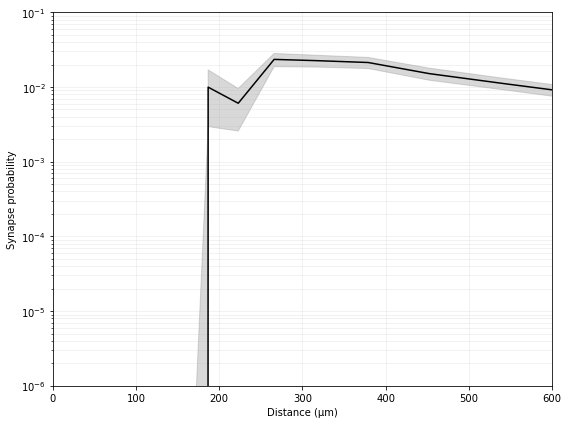

In [43]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import time

print("Starting analysis...")
start_time = time.time()

# Read the data (use low_memory=False for optimization with mixed data types)
print("Loading data files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv", low_memory=False)
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Convert node_id to string to ensure consistent types
metadata_df['node_id'] = metadata_df['node_id'].astype(str)
edges_df['from'] = edges_df['from'].astype(str)
edges_df['to'] = edges_df['to'].astype(str)

# Extract node positions
print("Building position lookup dictionary...")
positions = {}
for _, row in metadata_df.iterrows():
    positions[row['node_id']] = (row['x'], row['y'], row['z'])

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes from metadata
node_list = metadata_df['node_id'].tolist()
G.add_nodes_from(node_list)

# Add edges
print("Adding edges...")
edge_list = list(zip(edges_df['from'], edges_df['to']))
G.add_edges_from(edge_list)

# Calculate overall connection probability
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
max_possible_edges = num_nodes * (num_nodes - 1)
connection_probability = num_edges / max_possible_edges

print("=== Overall Connection Probability ===")
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Maximum possible edges: {max_possible_edges}")
print(f"Connection probability: {connection_probability:.6f} ({connection_probability*100:.4f}%)")

# Build KD-Tree for efficient distance calculations
print("\nBuilding KD-Tree for efficient distance calculations...")
positions_array = np.array(list(positions.values()))
kd_tree = cKDTree(positions_array)
node_ids = list(positions.keys())

# Sample node pairs for distance-probability analysis (using fewer pairs for optimization)
print("Sampling node pairs for analysis...")
sample_size = min(10000, num_nodes)  # Sample size is much smaller than full graph
np.random.seed(42)  # For reproducible results
sampled_indices = np.random.choice(num_nodes, size=sample_size, replace=False)
sampled_nodes = [node_ids[i] for i in sampled_indices]

# Calculate distances and check connections
print("Calculating distances and connection status...")
distance_bins = np.logspace(0, 3, 40)  # Logarithmic bins from 1 to 1000
bin_edges = np.zeros(len(distance_bins)-1)  # For counting edges in each bin
bin_pairs = np.zeros(len(distance_bins)-1)  # For counting total pairs in each bin

# Use vectorized operations where possible
for i, node1 in enumerate(sampled_nodes):
    if i % 100 == 0:
        print(f"Processing node {i+1}/{len(sampled_nodes)}")
    
    # Get position for node1
    pos1 = positions[node1]
    
    # Find distances to all other nodes efficiently using KD-Tree
    distances, indices = kd_tree.query([pos1], k=sample_size, distance_upper_bound=np.inf)
    distances = distances[0]
    indices = indices[0]
    
    for j in range(1, len(indices)):  # Skip the first one (same node)
        if indices[j] >= len(node_ids):  # Skip if index is out of bounds
            continue
        
        node2 = node_ids[indices[j]]
        distance = distances[j]
        
        # Find which bin this distance falls into
        bin_idx = np.digitize(distance, distance_bins) - 1
        if 0 <= bin_idx < len(bin_pairs):
            # Increment total pairs counter for this bin
            bin_pairs[bin_idx] += 1
            
            # Check if edge exists and increment edge counter if it does
            if G.has_edge(node1, node2):
                bin_edges[bin_idx] += 1

# Calculate connection probability for each distance bin
probabilities = np.zeros(len(bin_pairs))
for i in range(len(bin_pairs)):
    if bin_pairs[i] > 0:
        probabilities[i] = bin_edges[i] / bin_pairs[i]
    else:
        probabilities[i] = 0

# Calculate centers of bins for plotting
bin_centers = (distance_bins[:-1] + distance_bins[1:]) / 2

# Calculate standard error for each bin (for confidence interval)
std_errors = np.zeros(len(bin_pairs))
for i in range(len(bin_pairs)):
    if bin_pairs[i] > 0:
        # Standard error for binomial proportion
        std_errors[i] = np.sqrt((probabilities[i] * (1 - probabilities[i])) / bin_pairs[i])
    else:
        std_errors[i] = 0

# Create the plot
print("Creating plot...")
plt.figure(figsize=(8, 6))

# Plot synapse probability vs distance with log scale
plt.semilogy(bin_centers, probabilities, 'k-', linewidth=1.5)

# Add confidence interval
plt.fill_between(bin_centers, 
                 np.maximum(1e-10, probabilities - std_errors),  # Prevent negative values in log scale
                 probabilities + std_errors, 
                 color='gray', alpha=0.3)

# Set axis labels and title
plt.xlabel('Distance (μm)')
plt.ylabel('Synapse probability')
plt.xlim(0, 600)
plt.ylim(1e-6, 1e-1)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('synapse_probability_vs_distance.png', dpi=600)
print("Saved plot to 'synapse_probability_vs_distance.png' at 600dpi")

# Report total runtime
end_time = time.time()
print(f"\nTotal analysis time: {end_time - start_time:.2f} seconds")

Loading data files...
Loaded 849981 edges and 32272 nodes
Creating position dictionary...
Creating directed graph...
Adding edges...


  2%|▏         | 15641/849981 [00:00<00:05, 156387.78it/s]

Graph has 32272 nodes and 849981 edges

Calculating distances for all edges...


100%|██████████| 849981/849981 [00:04<00:00, 203168.44it/s]



Shortest connection: (6890, 26303) with distance 0.1664 μm
Longest connection: (32058, 8235) with distance 429.0556 μm
Saved plot to 'connections_by_distance.png' at 600dpi

Calculating average connection distance by module...
Saved plot to 'avg_distance_by_module.png' at 600dpi

=== Details for Shortest and Longest Connections ===
Shortest connection: 6890 -> 26303
  Distance: 0.1664 μm
  Source position: (629536.00, 175564.00, 143760.00) nm
  Target position: (629564.00, 175400.00, 143760.00) nm

Longest connection: 32058 -> 8235
  Distance: 429.0556 μm
  Source position: (728172.00, 205654.00, 73820.00) nm
  Target position: (315264.00, 137184.00, 168200.00) nm

=== Module Connection Statistics ===
Number of modules with 5+ connections: 54
Module with shortest average connections: 54 (51.5972 μm)
Module with longest average connections: 31 (152.3272 μm)


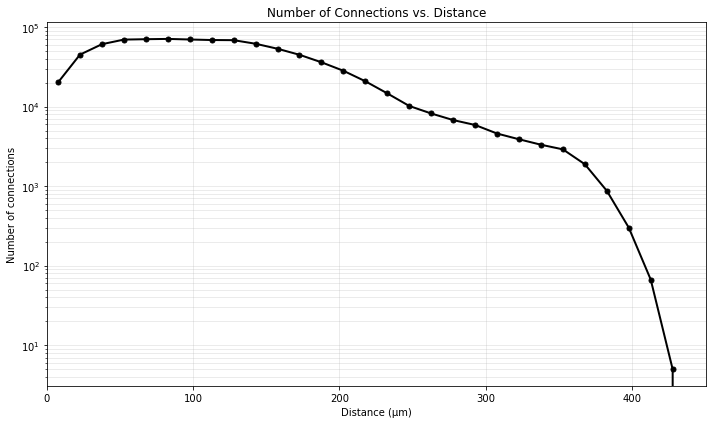

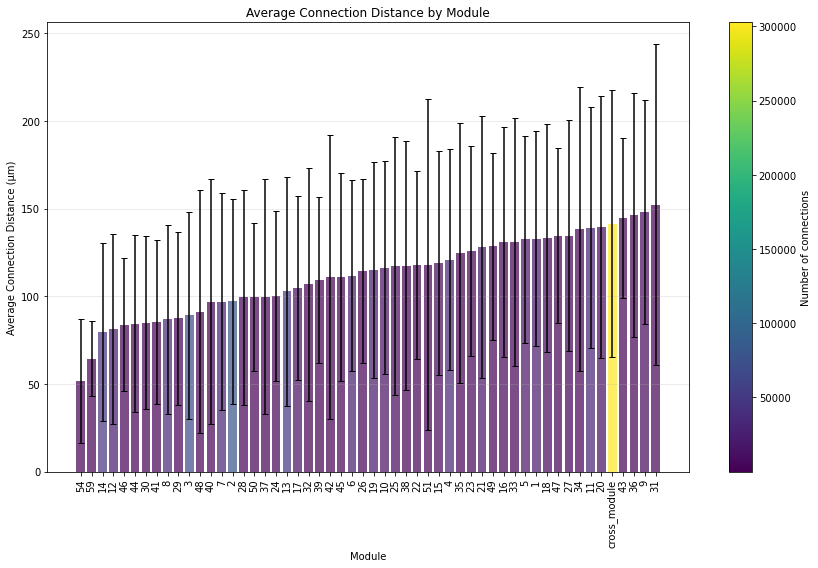

In [47]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# Read the data
print("Loading data files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create position dictionary for quick lookups
print("Creating position dictionary...")
positions = {}
modules = {}
for _, row in metadata_df.iterrows():
    positions[row['node_id']] = (row['x'], row['y'], row['z'])
    modules[row['node_id']] = row['module']

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with position attributes and module info
for node_id, pos in positions.items():
    G.add_node(node_id, pos=pos, module=modules.get(node_id, "Unknown"))

# Add edges
print("Adding edges...")
edge_count = 0
for _, edge in edges_df.iterrows():
    source = edge['from']
    target = edge['to']
    # Only add if both nodes exist
    if source in G and target in G:
        G.add_edge(source, target)
        edge_count += 1

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate distance for each edge and find min/max
# Convert nm to μm by dividing by 1000
print("\nCalculating distances for all edges...")
edge_distances = []
edge_modules = []  # To track which module each edge belongs to
min_dist = float('inf')
max_dist = 0
min_edge = None
max_edge = None

module_distances = defaultdict(list)

for edge in tqdm(G.edges()):
    source, target = edge
    source_pos = positions[source]
    target_pos = positions[target]
    
    # Calculate euclidean distance in nm
    distance_nm = np.sqrt(
        (target_pos[0] - source_pos[0]) ** 2 +
        (target_pos[1] - source_pos[1]) ** 2 +
        (target_pos[2] - source_pos[2]) ** 2
    )
    
    # Convert to μm
    distance_um = distance_nm / 1000.0
    
    edge_distances.append(distance_um)
    
    # Track distances by module
    source_module = G.nodes[source]['module']
    target_module = G.nodes[target]['module']
    
    # If source and target are in the same module, associate edge with that module
    if source_module == target_module:
        module = source_module
    else:
        # For cross-module edges, use a special category
        module = "cross_module"
    
    module_distances[module].append(distance_um)
    
    # Update min/max
    if distance_um < min_dist:
        min_dist = distance_um
        min_edge = edge
    if distance_um > max_dist:
        max_dist = distance_um
        max_edge = edge

print(f"\nShortest connection: {min_edge} with distance {min_dist:.4f} μm")
print(f"Longest connection: {max_edge} with distance {max_dist:.4f} μm")

# Create distance bins - use more appropriate range
max_plot_dist = min(600, max_dist * 1.05)
bin_edges = np.linspace(0, max_plot_dist, 31)  # 30 bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate histogram of edge distances
hist, _ = np.histogram(edge_distances, bins=bin_edges)

# Create the plot for connections by distance
plt.figure(figsize=(10, 6))

# Use a log scale for the y-axis to match the reference graph
plt.semilogy(bin_centers, hist, 'k-', linewidth=2)

# Add markers for clarity
plt.plot(bin_centers, hist, 'ko', markersize=5)

# Set axis labels and title
plt.xlabel('Distance (μm)')
plt.ylabel('Number of connections')
plt.xlim(0, max_plot_dist)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.title('Number of Connections vs. Distance')
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('connections_by_distance.png', dpi=600)
print("Saved plot to 'connections_by_distance.png' at 600dpi")

# Plot average distance by module
print("\nCalculating average connection distance by module...")

# Filter modules with at least 5 connections for better statistics
module_avg_distances = {}
module_std_distances = {}
module_counts = {}

for module, distances in module_distances.items():
    if len(distances) >= 5:  # Only include modules with enough connections
        module_avg_distances[module] = np.mean(distances)
        module_std_distances[module] = np.std(distances)
        module_counts[module] = len(distances)

# Sort modules by average distance
sorted_modules = sorted(module_avg_distances.keys(), 
                       key=lambda x: module_avg_distances[x])

# Create the plot for average connection distance by module
plt.figure(figsize=(12, 8))

# Plot average distances as bars
avg_distances = [module_avg_distances[m] for m in sorted_modules]
std_distances = [module_std_distances[m] for m in sorted_modules]
counts = [module_counts[m] for m in sorted_modules]

# Determine bar colors based on connection count
max_count = max(counts)
colors = plt.cm.viridis(np.array(counts) / max_count)

bars = plt.bar(range(len(sorted_modules)), avg_distances, yerr=std_distances, 
               capsize=3, color=colors, alpha=0.7)

# Add color bar for connection count
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(min(counts), max(counts)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Number of connections')

# Set axis labels and title
plt.xlabel('Module')
plt.ylabel('Average Connection Distance (μm)')
plt.title('Average Connection Distance by Module')
plt.xticks(range(len(sorted_modules)), sorted_modules, rotation=90)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('avg_distance_by_module.png', dpi=600)
print("Saved plot to 'avg_distance_by_module.png' at 600dpi")

# Print additional information about shortest and longest connections
print("\n=== Details for Shortest and Longest Connections ===")
shortest_source, shortest_target = min_edge
shortest_source_pos = positions[shortest_source]
shortest_target_pos = positions[shortest_target]

longest_source, longest_target = max_edge
longest_source_pos = positions[longest_source]
longest_target_pos = positions[longest_target]

print(f"Shortest connection: {shortest_source} -> {shortest_target}")
print(f"  Distance: {min_dist:.4f} μm")
print(f"  Source position: ({shortest_source_pos[0]:.2f}, {shortest_source_pos[1]:.2f}, {shortest_source_pos[2]:.2f}) nm")
print(f"  Target position: ({shortest_target_pos[0]:.2f}, {shortest_target_pos[1]:.2f}, {shortest_target_pos[2]:.2f}) nm")

print(f"\nLongest connection: {longest_source} -> {longest_target}")
print(f"  Distance: {max_dist:.4f} μm")
print(f"  Source position: ({longest_source_pos[0]:.2f}, {longest_source_pos[1]:.2f}, {longest_source_pos[2]:.2f}) nm")
print(f"  Target position: ({longest_target_pos[0]:.2f}, {longest_target_pos[1]:.2f}, {longest_target_pos[2]:.2f}) nm")

# Print some statistics about module connections
print("\n=== Module Connection Statistics ===")
print(f"Number of modules with 5+ connections: {len(module_avg_distances)}")
print(f"Module with shortest average connections: {sorted_modules[0]} ({module_avg_distances[sorted_modules[0]]:.4f} μm)")
print(f"Module with longest average connections: {sorted_modules[-1]} ({module_avg_distances[sorted_modules[-1]]:.4f} μm)")

Saved plot to 'connections_by_distance.png' at 600dpi


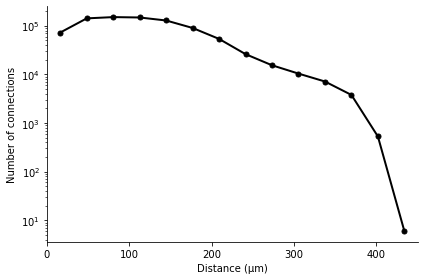

In [21]:
# Create distance bins - use more appropriate range
max_plot_dist = min(600, max_dist * 1.05)
bin_edges = np.linspace(0, max_plot_dist, 15)  # 30 bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate histogram of edge distances
hist, _ = np.histogram(edge_distances, bins=bin_edges)

# Create the plot for connections by distance
plt.figure(figsize=(6, 4))

# Use a log scale for the y-axis to match the reference graph
plt.semilogy(bin_centers, hist, 'k-', linewidth=2)

# Add markers for clarity
plt.plot(bin_centers, hist, 'ko', markersize=5)

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set axis labels and title
plt.xlabel('Distance (μm)')
plt.ylabel('Number of connections')
plt.xlim(0, max_plot_dist)
plt.grid(False)
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('connections_by_distance.png', dpi=600)
print("Saved plot to 'connections_by_distance.png' at 600dpi")



=== Within-Module vs Cross-Module Connection Analysis ===
Within-module connections: 547299
  Average distance: 105.2282 μm
  Standard deviation: 63.4098 μm
  95% Confidence interval: [101.2159, 109.5398] μm

Cross-module connections: 302682
  Average distance: 141.4444 μm
  Standard deviation: 76.2662 μm
  95% Confidence interval: [136.8964, 145.9494] μm

Ratio of cross-module to within-module distance: 1.34x
Saved comparison plot to 'module_comparison.png' at 600dpi


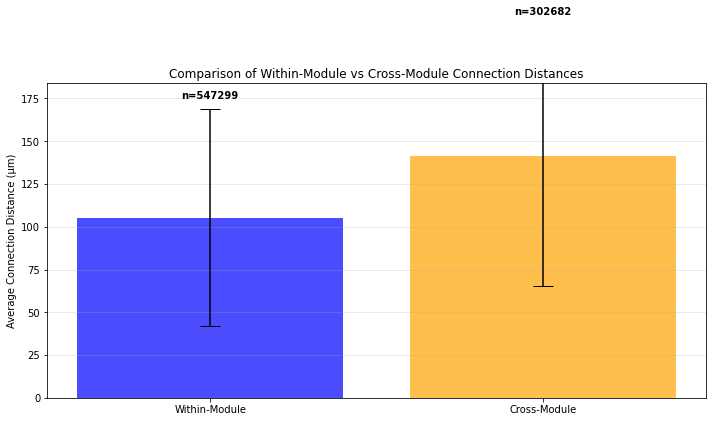

In [53]:
# Add this code to your existing script after the module_distances dictionary has been created

# Calculate within-module vs cross-module connection distances
print("\n=== Within-Module vs Cross-Module Connection Analysis ===")

# Split into within-module and cross-module lists
within_module_distances = []
cross_module_distances = module_distances.get("cross_module", [])

# Combine all within-module distances
for module, distances in module_distances.items():
    if module != "cross_module":
        within_module_distances.extend(distances)

# Calculate basic statistics
avg_within = np.mean(within_module_distances)
avg_cross = np.mean(cross_module_distances) if cross_module_distances else 0
std_within = np.std(within_module_distances)
std_cross = np.std(cross_module_distances) if cross_module_distances else 0

# Perform bootstrap sampling for confidence intervals
n_bootstrap = 1000
bootstrap_within = []
bootstrap_cross = []

for _ in range(n_bootstrap):
    # Sample with replacement
    if within_module_distances:
        sample_within = np.random.choice(within_module_distances, 
                                         size=min(len(within_module_distances), 1000), 
                                         replace=True)
        bootstrap_within.append(np.mean(sample_within))
    
    if cross_module_distances:
        sample_cross = np.random.choice(cross_module_distances, 
                                       size=min(len(cross_module_distances), 1000), 
                                       replace=True)
        bootstrap_cross.append(np.mean(sample_cross))

# Calculate 95% confidence intervals
ci_within = (np.percentile(bootstrap_within, 2.5), np.percentile(bootstrap_within, 97.5))
ci_cross = (np.percentile(bootstrap_cross, 2.5), np.percentile(bootstrap_cross, 97.5)) if bootstrap_cross else (0, 0)

# Print results
print(f"Within-module connections: {len(within_module_distances)}")
print(f"  Average distance: {avg_within:.4f} μm")
print(f"  Standard deviation: {std_within:.4f} μm")
print(f"  95% Confidence interval: [{ci_within[0]:.4f}, {ci_within[1]:.4f}] μm")

print(f"\nCross-module connections: {len(cross_module_distances)}")
print(f"  Average distance: {avg_cross:.4f} μm")
print(f"  Standard deviation: {std_cross:.4f} μm")
print(f"  95% Confidence interval: [{ci_cross[0]:.4f}, {ci_cross[1]:.4f}] μm")

print(f"\nRatio of cross-module to within-module distance: {avg_cross / avg_within:.2f}x")

Saved comparison plot to 'module_comparison.png' at 600dpi


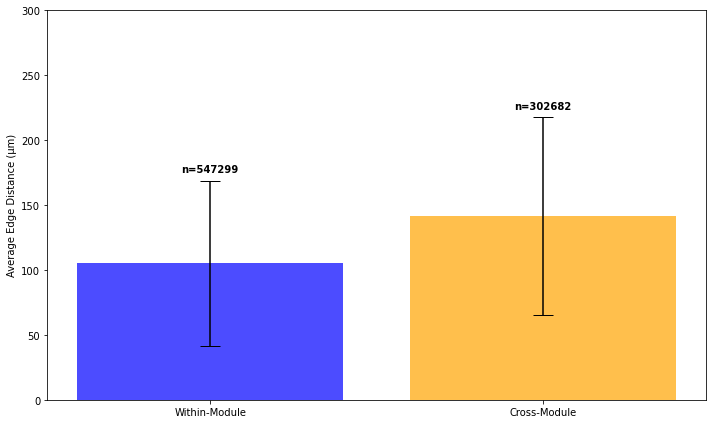

In [57]:
# Create a bar chart to visualize the difference
plt.figure(figsize=(10, 6))
categories = ['Within-Module', 'Cross-Module']
avg_distances = [avg_within, avg_cross]
std_distances = [std_within, std_cross]

bars = plt.bar(categories, avg_distances, yerr=std_distances, capsize=10, 
               color=['blue', 'orange'], alpha=0.7)

# Add connection counts as text
for i, bar in enumerate(bars):
    count = len(within_module_distances) if i == 0 else len(cross_module_distances)
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + std_distances[i] + 5,
             f'n={count}', 
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Average Edge Distance (μm)')
plt.grid(False)
plt.ylim(0, 300)  # Add some space for the count text

# Save the plot
plt.tight_layout()
plt.savefig('module_comparison.png', dpi=600)
print("Saved comparison plot to 'module_comparison.png' at 600dpi")

Loading data files...
Loaded 849981 edges and 32272 nodes
Creating position dictionary...
Creating directed graph...
Adding edges...


  2%|▏         | 19839/849981 [00:00<00:04, 198358.03it/s]

Graph has 32272 nodes and 849981 edges

Calculating distances for all edges...


100%|██████████| 849981/849981 [00:03<00:00, 232137.57it/s]



Shortest connection: (6890, 26303) with distance 0.1664 μm
Longest connection: (32058, 8235) with distance 429.0556 μm
Saved plot to 'connections_by_distance.png' at 600dpi

=== Within-Module vs Cross-Module Connection Analysis ===
Within-module connections: 547299
  Average distance: 105.2282 μm
  Standard deviation: 63.4098 μm

Cross-module connections: 302682
  Average distance: 141.4444 μm
  Standard deviation: 76.2662 μm

Ratio of cross-module to within-module distance: 1.34x
Saved comparison plot to 'module_comparison.png' at 600dpi

Calculating average connection distance by module...


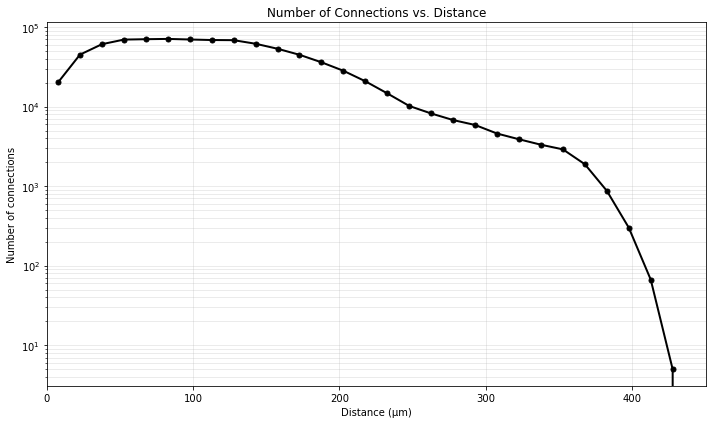

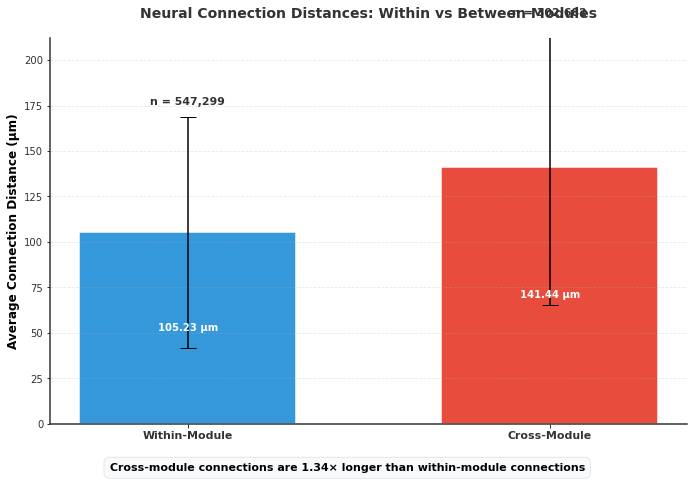

In [5]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# Read the data
print("Loading data files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create position dictionary for quick lookups
print("Creating position dictionary...")
positions = {}
modules = {}
for _, row in metadata_df.iterrows():
    positions[row['node_id']] = (row['x'], row['y'], row['z'])
    modules[row['node_id']] = row['module']

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with position attributes and module info
for node_id, pos in positions.items():
    G.add_node(node_id, pos=pos, module=modules.get(node_id, "Unknown"))

# Add edges
print("Adding edges...")
edge_count = 0
for _, edge in edges_df.iterrows():
    source = edge['from']
    target = edge['to']
    # Only add if both nodes exist
    if source in G and target in G:
        G.add_edge(source, target)
        edge_count += 1

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate distance for each edge and find min/max
# Convert nm to μm by dividing by 1000
print("\nCalculating distances for all edges...")
edge_distances = []
edge_modules = []  # To track which module each edge belongs to
min_dist = float('inf')
max_dist = 0
min_edge = None
max_edge = None

module_distances = defaultdict(list)

for edge in tqdm(G.edges()):
    source, target = edge
    source_pos = positions[source]
    target_pos = positions[target]
    
    # Calculate euclidean distance in nm
    distance_nm = np.sqrt(
        (target_pos[0] - source_pos[0]) ** 2 +
        (target_pos[1] - source_pos[1]) ** 2 +
        (target_pos[2] - source_pos[2]) ** 2
    )
    
    # Convert to μm
    distance_um = distance_nm / 1000.0
    
    edge_distances.append(distance_um)
    
    # Track distances by module
    source_module = G.nodes[source]['module']
    target_module = G.nodes[target]['module']
    
    # If source and target are in the same module, associate edge with that module
    if source_module == target_module:
        module = source_module
    else:
        # For cross-module edges, use a special category
        module = "cross_module"
    
    module_distances[module].append(distance_um)
    
    # Update min/max
    if distance_um < min_dist:
        min_dist = distance_um
        min_edge = edge
    if distance_um > max_dist:
        max_dist = distance_um
        max_edge = edge

print(f"\nShortest connection: {min_edge} with distance {min_dist:.4f} μm")
print(f"Longest connection: {max_edge} with distance {max_dist:.4f} μm")

# Create distance bins - use more appropriate range
max_plot_dist = min(600, max_dist * 1.05)
bin_edges = np.linspace(0, max_plot_dist, 31)  # 30 bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate histogram of edge distances
hist, _ = np.histogram(edge_distances, bins=bin_edges)

# Create the plot for connections by distance
plt.figure(figsize=(10, 6))

# Use a log scale for the y-axis to match the reference graph
plt.semilogy(bin_centers, hist, 'k-', linewidth=2)

# Add markers for clarity
plt.plot(bin_centers, hist, 'ko', markersize=5)

# Set axis labels and title
plt.xlabel('Distance (μm)')
plt.ylabel('Number of connections')
plt.xlim(0, max_plot_dist)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.title('Number of Connections vs. Distance')
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('connections_by_distance.png', dpi=600)
print("Saved plot to 'connections_by_distance.png' at 600dpi")

# Calculate within-module vs cross-module connection distances
print("\n=== Within-Module vs Cross-Module Connection Analysis ===")

# Split into within-module and cross-module lists
within_module_distances = []
cross_module_distances = module_distances.get("cross_module", [])

# Combine all within-module distances
for module, distances in module_distances.items():
    if module != "cross_module":
        within_module_distances.extend(distances)

# Calculate basic statistics
avg_within = np.mean(within_module_distances)
avg_cross = np.mean(cross_module_distances) if cross_module_distances else 0
std_within = np.std(within_module_distances)
std_cross = np.std(cross_module_distances) if cross_module_distances else 0

# Print results
print(f"Within-module connections: {len(within_module_distances)}")
print(f"  Average distance: {avg_within:.4f} μm")
print(f"  Standard deviation: {std_within:.4f} μm")

print(f"\nCross-module connections: {len(cross_module_distances)}")
print(f"  Average distance: {avg_cross:.4f} μm")
print(f"  Standard deviation: {std_cross:.4f} μm")

print(f"\nRatio of cross-module to within-module distance: {avg_cross / avg_within:.2f}x")

# Create a standalone visualization for the intra vs inter-module comparison
plt.figure(figsize=(10, 7))

categories = ['Within-Module', 'Cross-Module']
avg_distances = [avg_within, avg_cross]
std_distances = [std_within, std_cross]

# Define a custom color palette (a nice blue and coral)
colors = ['#3498db', '#e74c3c']

# Create the bars with a slightly wider width and nicer colors
bars = plt.bar(categories, avg_distances, yerr=std_distances, 
               capsize=8, width=0.6, color=colors, 
               edgecolor='white', linewidth=1.5)

# Add connection counts as text with better placement and style
for i, bar in enumerate(bars):
    count = len(within_module_distances) if i == 0 else len(cross_module_distances)
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + std_distances[i] + max(avg_distances) * 0.04,
             f'n = {count:,}', 
             ha='center', va='bottom', fontweight='bold',
             color='#333333', fontsize=11)

# Add value labels on the bars
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() * 0.5,
             f'{avg_distances[i]:.2f} μm', 
             ha='center', va='center', fontweight='bold',
             color='white', fontsize=10)

# Customize axes and labels
plt.ylabel('Average Connection Distance (μm)', fontsize=12, fontweight='bold')
plt.title('Neural Connection Distances: Within vs Between Modules', 
          fontsize=14, fontweight='bold', pad=20, color='#333333')

# Remove top and right spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
    
# Style the remaining spines and ticks
for spine in ['left', 'bottom']:
    plt.gca().spines[spine].set_color('#333333')
    plt.gca().spines[spine].set_linewidth(1.5)

plt.xticks(fontsize=11, fontweight='bold', color='#333333')
plt.yticks(fontsize=10, color='#333333')

# Customize grid
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add a ratio text annotation?
ratio = avg_cross / avg_within
plt.figtext(0.5, 0.01, 
            f"Cross-module connections are {ratio:.2f}× longer than within-module connections",
            ha='center', fontsize=11, fontweight='bold', 
            bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', 
                     boxstyle='round,pad=0.5', alpha=0.8))

# Set y-axis limit with more headroom for the annotations
plt.ylim(0, max(avg_distances) * 1.5)

# Save the plot with a higher quality setting
plt.tight_layout(pad=2, rect=[0, 0.03, 1, 0.97])
plt.savefig('module_comparison.png', dpi=600, bbox_inches='tight')
print("Saved comparison plot to 'module_comparison.png' at 600dpi")

# Plot average distance by module
print("\nCalculating average connection distance by module...")

Saved enhanced module plot to 'avg_distance_by_module_with_averages.png' at 600dpi

=== Details for Shortest and Longest Connections ===
Shortest connection: 6890 -> 26303
  Distance: 0.1664 μm
  Source position: (629536.00, 175564.00, 143760.00) nm
  Target position: (629564.00, 175400.00, 143760.00) nm

Longest connection: 32058 -> 8235
  Distance: 429.0556 μm
  Source position: (728172.00, 205654.00, 73820.00) nm
  Target position: (315264.00, 137184.00, 168200.00) nm

=== Module Connection Statistics ===
Number of modules with 5+ connections: 54
Module with shortest average connections: 54 (51.5972 μm)
Module with longest average connections: 31 (152.3272 μm)


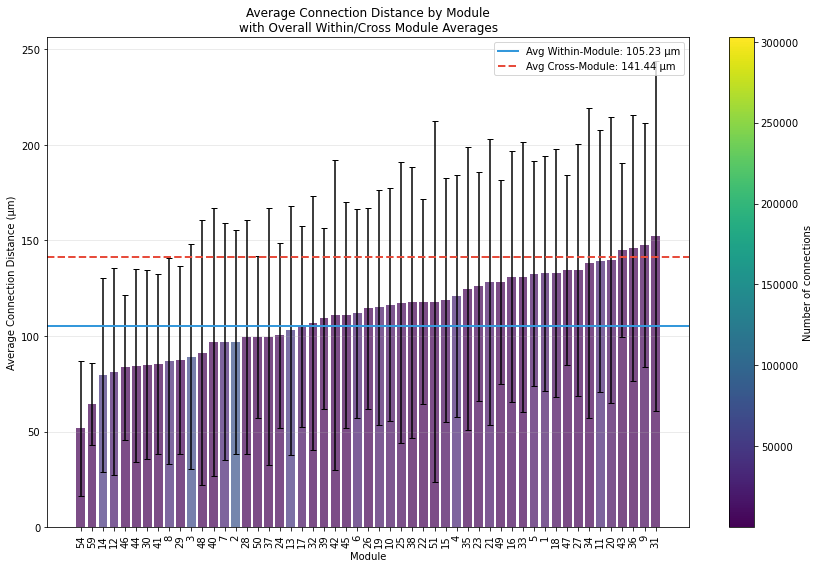

In [7]:
# Filter modules with at least 5 connections for better statistics
module_avg_distances = {}
module_std_distances = {}
module_counts = {}

for module, distances in module_distances.items():
    if len(distances) >= 5:  # Only include modules with eno5ugh connections
        module_avg_distances[module] = np.mean(distances)
        module_std_distances[module] = np.std(distances)
        module_counts[module] = len(distances)

# Sort modules by average distance
sorted_modules = sorted(module_avg_distances.keys(), 
                       key=lambda x: module_avg_distances[x])

# Create the plot for average connection distance by module
plt.figure(figsize=(12, 8))

# Determine bar colors based on connection count
max_count = max(module_counts.values())
colors = plt.cm.viridis(np.array([module_counts[m] for m in sorted_modules]) / max_count)

# Remove "cross_module" from sorted_modules if present
if "cross_module" in sorted_modules:
    cross_module_index = sorted_modules.index("cross_module")
    sorted_modules.remove("cross_module")
    colors = np.delete(colors, cross_module_index, axis=0)

# Plot average distances as bars
avg_distances = [module_avg_distances[m] for m in sorted_modules]
std_distances = [module_std_distances[m] for m in sorted_modules]

bars = plt.bar(range(len(sorted_modules)), avg_distances, yerr=std_distances, 
               capsize=3, color=colors, alpha=0.7)

# Add horizontal lines for average within-module and cross-module distances
plt.axhline(y=avg_within, color='#3498db', linestyle='-', linewidth=2, 
            label=f'Avg Within-Module: {avg_within:.2f} μm')
plt.axhline(y=avg_cross, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'Avg Cross-Module: {avg_cross:.2f} μm')

# Add color bar for connection count
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                          norm=plt.Normalize(min(module_counts.values()), max(module_counts.values())))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Number of connections')

# Set axis labels and title
plt.xlabel('Module')
plt.ylabel('Average Connection Distance (μm)')
plt.title('Average Connection Distance by Module\nwith Overall Within/Cross Module Averages')
plt.xticks(range(len(sorted_modules)), sorted_modules, rotation=90)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('avg_distance_by_module_with_averages.png', dpi=600)
print("Saved enhanced module plot to 'avg_distance_by_module_with_averages.png' at 600dpi")

# Print additional information about shortest and longest connections
print("\n=== Details for Shortest and Longest Connections ===")
shortest_source, shortest_target = min_edge
shortest_source_pos = positions[shortest_source]
shortest_target_pos = positions[shortest_target]

longest_source, longest_target = max_edge
longest_source_pos = positions[longest_source]
longest_target_pos = positions[longest_target]

print(f"Shortest connection: {shortest_source} -> {shortest_target}")
print(f"  Distance: {min_dist:.4f} μm")
print(f"  Source position: ({shortest_source_pos[0]:.2f}, {shortest_source_pos[1]:.2f}, {shortest_source_pos[2]:.2f}) nm")
print(f"  Target position: ({shortest_target_pos[0]:.2f}, {shortest_target_pos[1]:.2f}, {shortest_target_pos[2]:.2f}) nm")

print(f"\nLongest connection: {longest_source} -> {longest_target}")
print(f"  Distance: {max_dist:.4f} μm")
print(f"  Source position: ({longest_source_pos[0]:.2f}, {longest_source_pos[1]:.2f}, {longest_source_pos[2]:.2f}) nm")
print(f"  Target position: ({longest_target_pos[0]:.2f}, {longest_target_pos[1]:.2f}, {longest_target_pos[2]:.2f}) nm")

# Print some statistics about module connections
print("\n=== Module Connection Statistics ===")
print(f"Number of modules with 5+ connections: {len(module_avg_distances)}")
print(f"Module with shortest average connections: {sorted_modules[0]} ({module_avg_distances[sorted_modules[0]]:.4f} μm)")
print(f"Module with longest average connections: {sorted_modules[-1]} ({module_avg_distances[sorted_modules[-1]]:.4f} μm)")

Saved plot to 'avg_distance_by_module_with_averages.png' at 600dpi


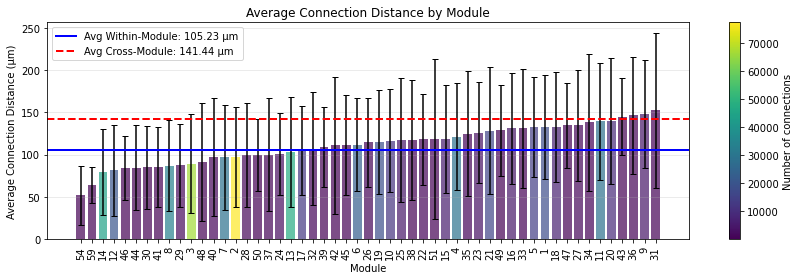

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming module_distances, module_avg_distances, module_std_distances, 
# module_counts, sorted_modules, avg_within, and avg_cross are already calculated

# Create the plot for average connection distance by module
plt.figure(figsize=(12, 4))

# Remove "cross_module" from sorted_modules if present
if "cross_module" in sorted_modules:
    cross_module_index = sorted_modules.index("cross_module")
    sorted_modules = [m for m in sorted_modules if m != "cross_module"]

# Get the values for the modules
avg_distances = [module_avg_distances[m] for m in sorted_modules]
std_distances = [module_std_distances[m] for m in sorted_modules]
counts = [module_counts[m] for m in sorted_modules]

# Determine bar colors based on connection count
max_count = max(counts)
colors = plt.cm.viridis(np.array(counts) / max_count)

# Plot average distances as bars
bars = plt.bar(range(len(sorted_modules)), avg_distances, yerr=std_distances, 
               capsize=3, color=colors, alpha=0.7)

# Add horizontal lines for average within-module and cross-module distances
plt.axhline(y=avg_within, color='blue', linestyle='-', linewidth=2, 
            label=f'Avg Within-Module: {avg_within:.2f} μm')
plt.axhline(y=avg_cross, color='red', linestyle='--', linewidth=2, 
            label=f'Avg Cross-Module: {avg_cross:.2f} μm')

# Add color bar for connection count
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                           norm=plt.Normalize(min(counts), max(counts)))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Number of connections')

# Set axis labels and title
plt.xlabel('Module')
plt.ylabel('Average Connection Distance (μm)')
plt.title('Average Connection Distance by Module')
plt.xticks(range(len(sorted_modules)), sorted_modules, rotation=90)
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot at high resolution
plt.savefig('avg_distance_by_module_with_averages.png', dpi=600)
print("Saved plot to 'avg_distance_by_module_with_averages.png' at 600dpi")

In [4]:
len(sorted(module_avg_distances.keys(), 
                       key=lambda x: module_avg_distances[x]))

54

Starting network analysis...
Reading CSV files...
Read 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Calculating in-degrees and out-degrees...
In-degree range: min=0 max=2843
Out-degree range: min=0 max=2763
Creating degree frequency dictionaries...
Sorting degree counts...
Extracting plotting data...
Calculating cumulative distributions...
Plotting in-degree distribution...
Saved in-degree distribution plot at 600dpi
Plotting out-degree distribution...
Saved out-degree distribution plot at 600dpi
Creating combined distribution plot...
Saved combined distribution plot at 600dpi

Network Statistics:
Number of nodes: 32272
Number of edges: 849981
Average in-degree: 26.34
Average out-degree: 26.34
Network density: 0.000816
Is strongly connected: False
Number of strongly connected components: 882
Analysis complete!


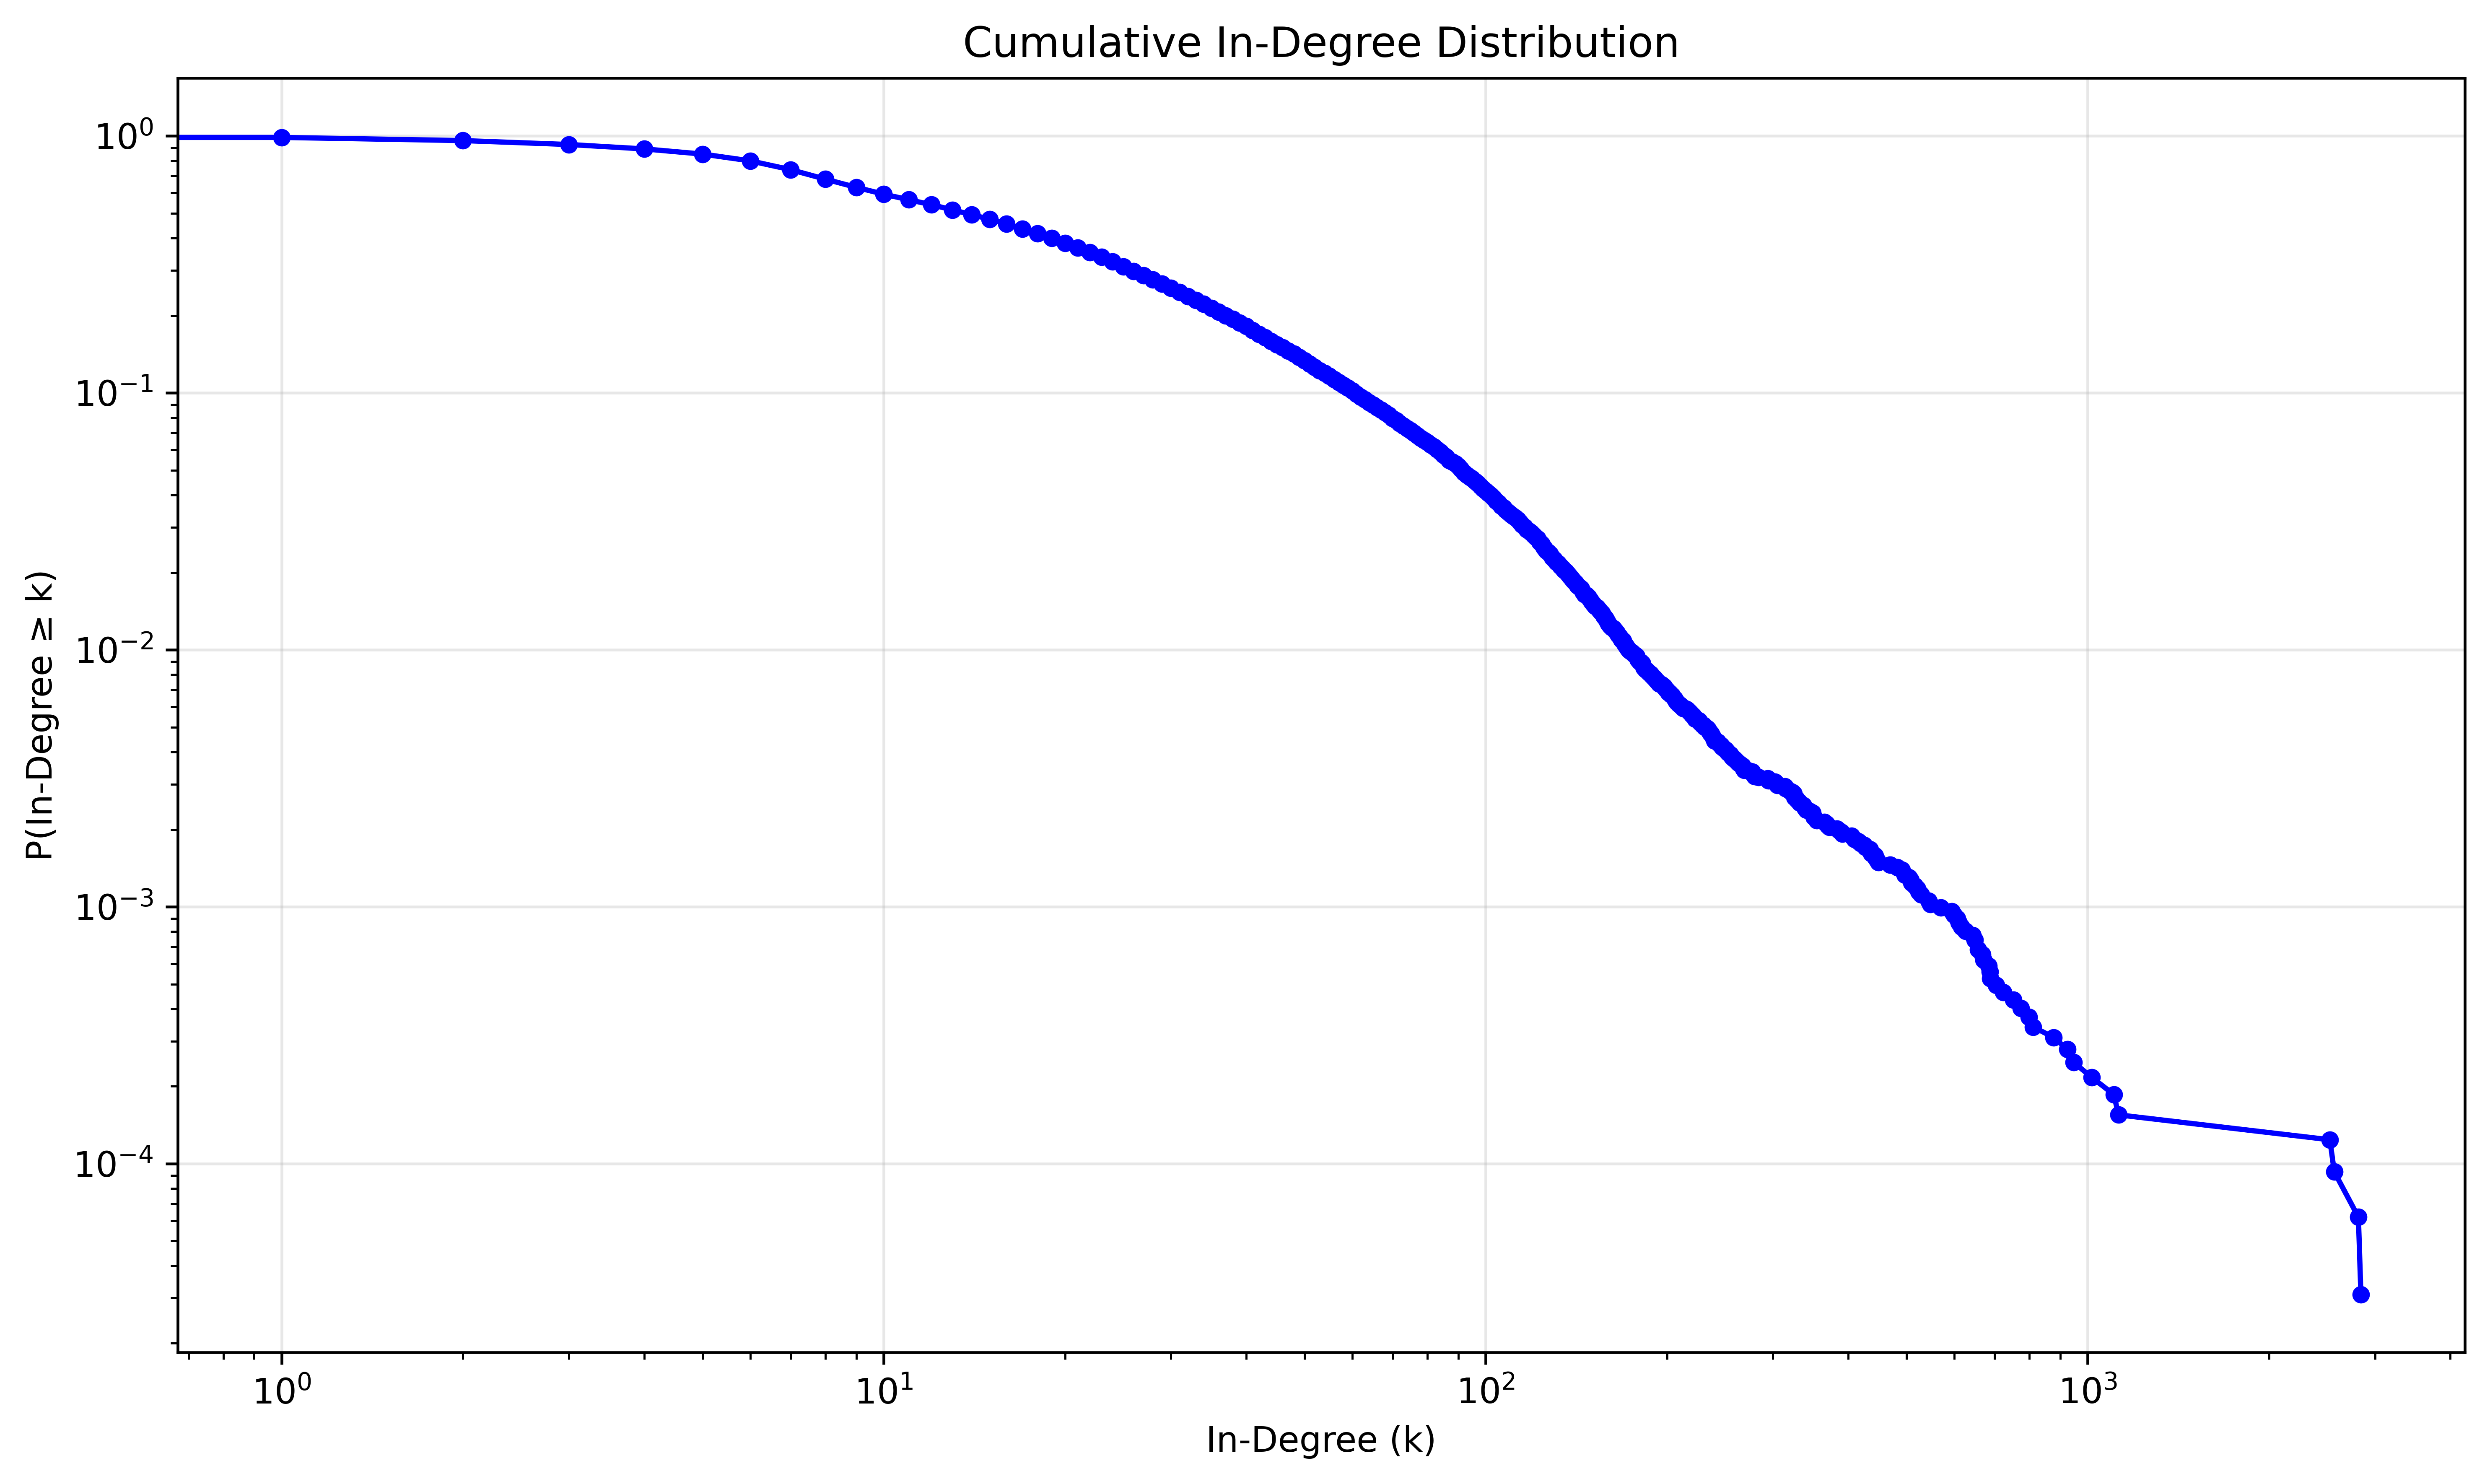

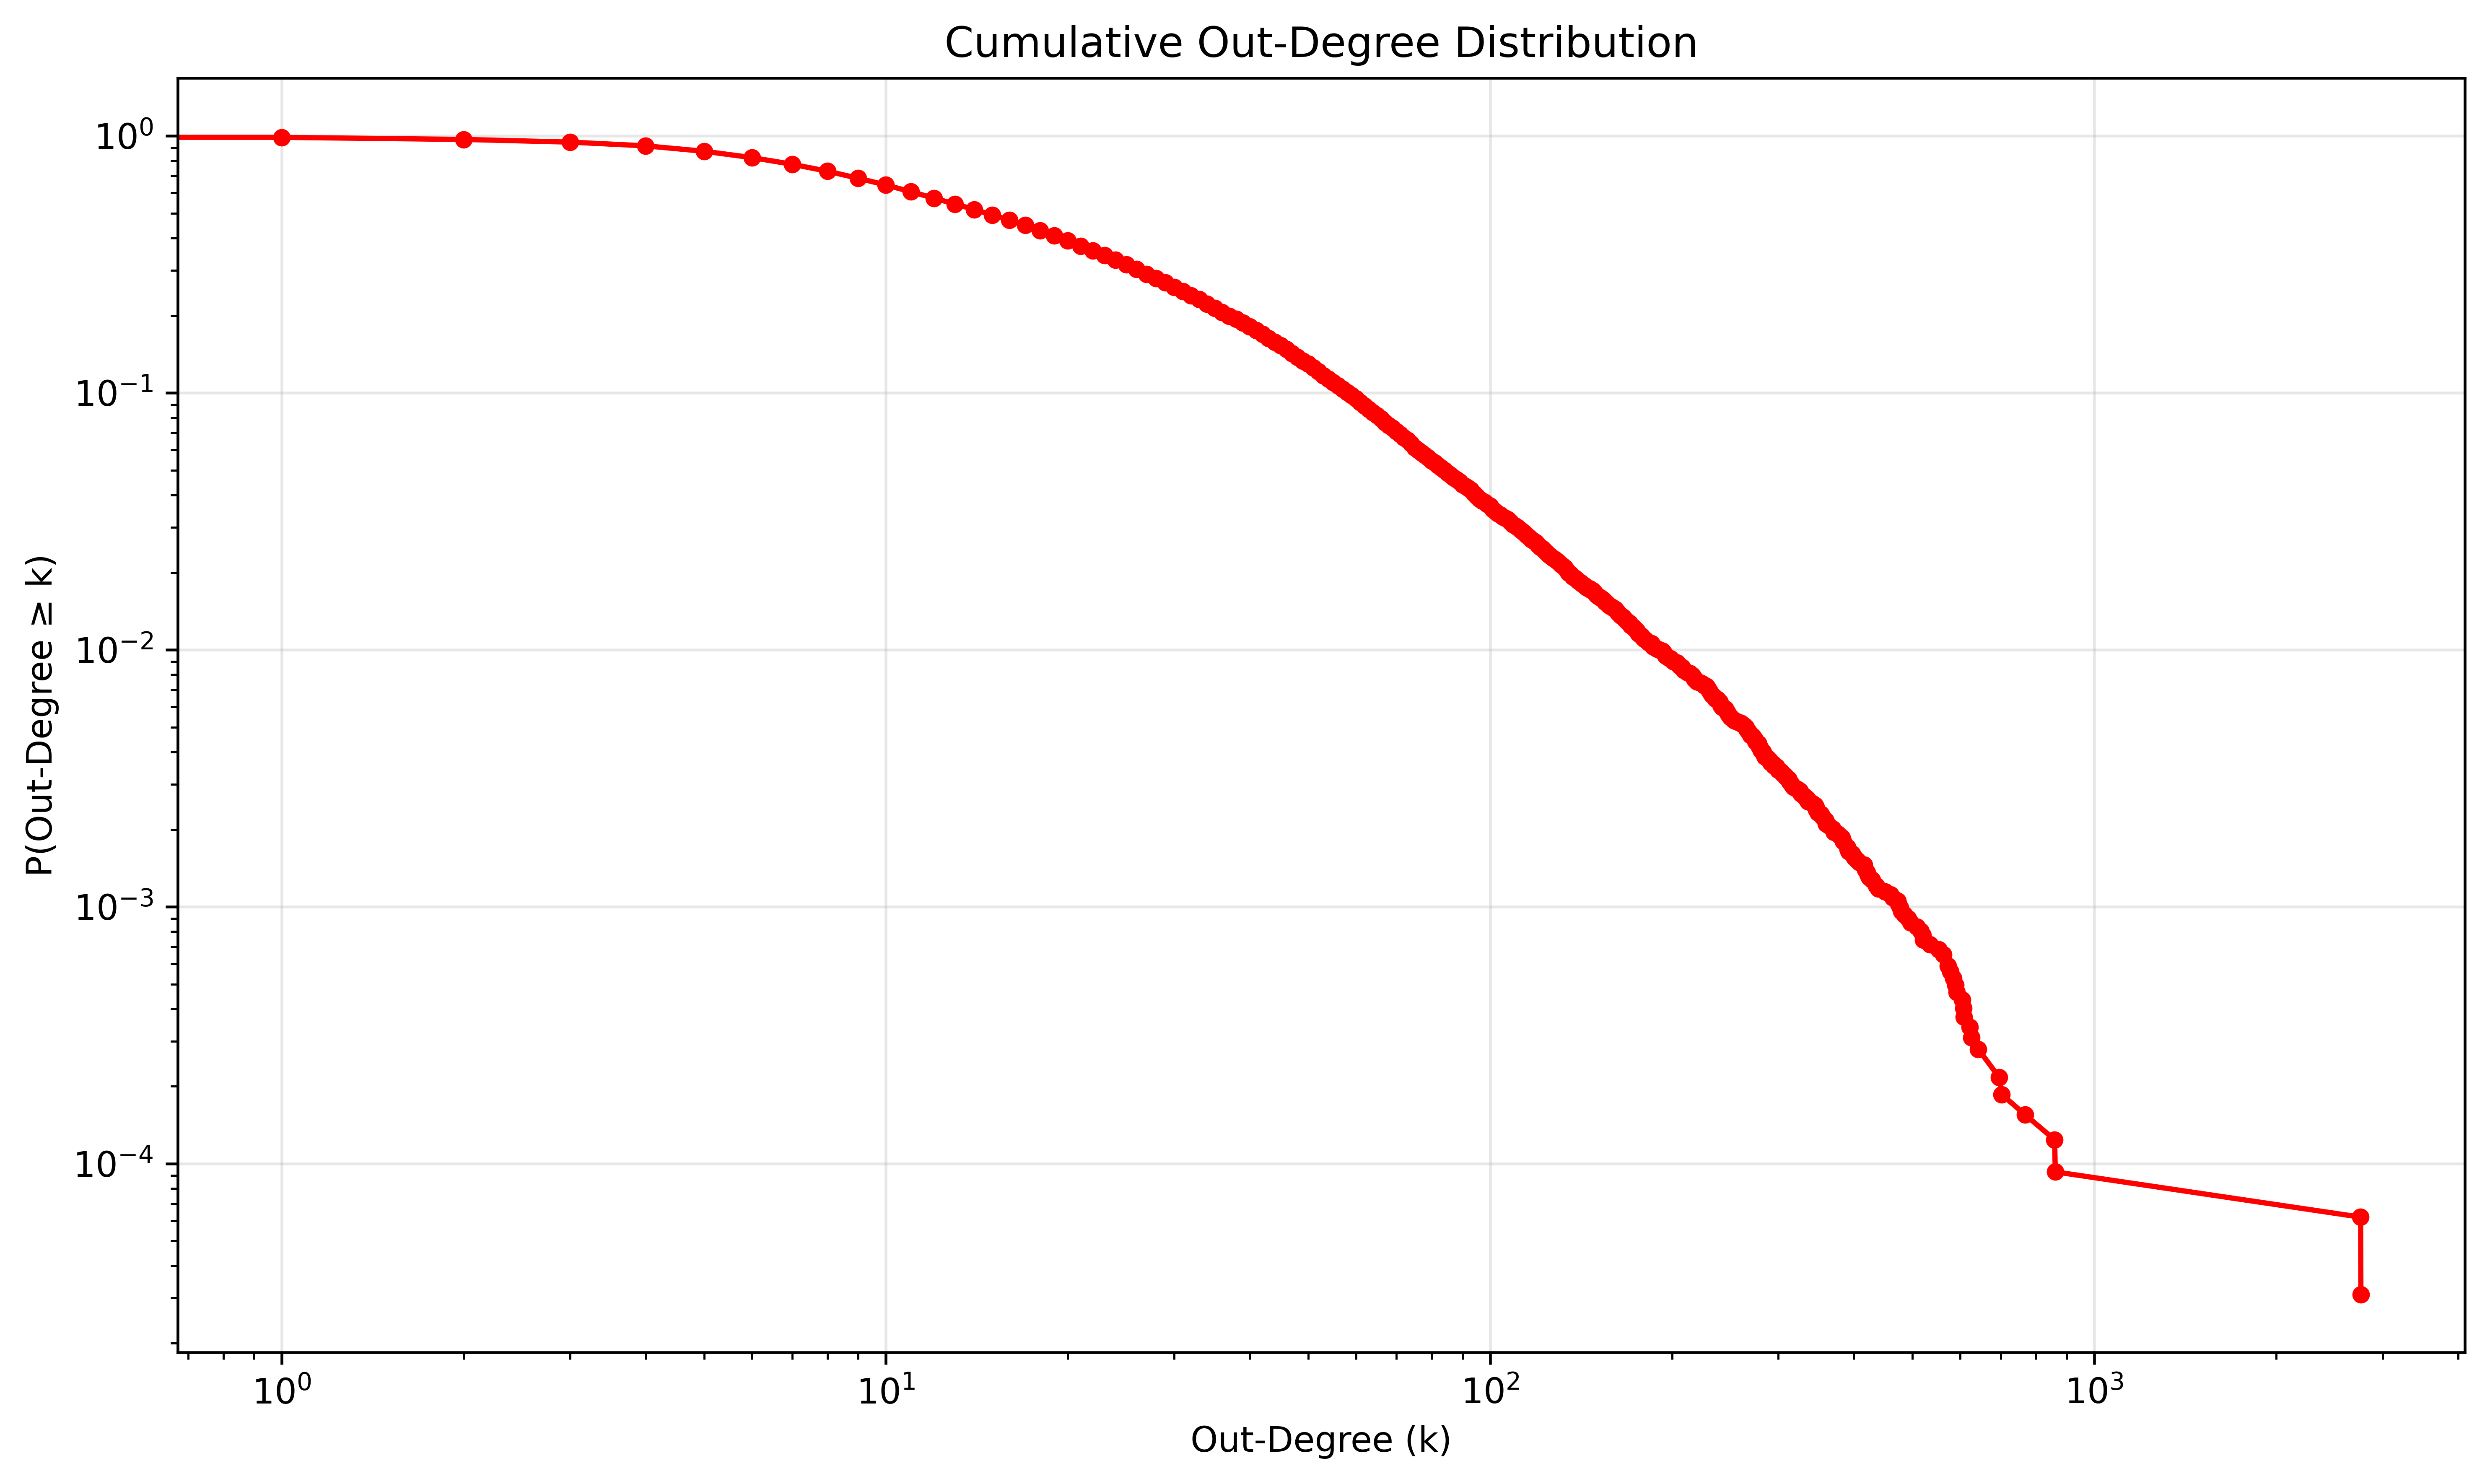

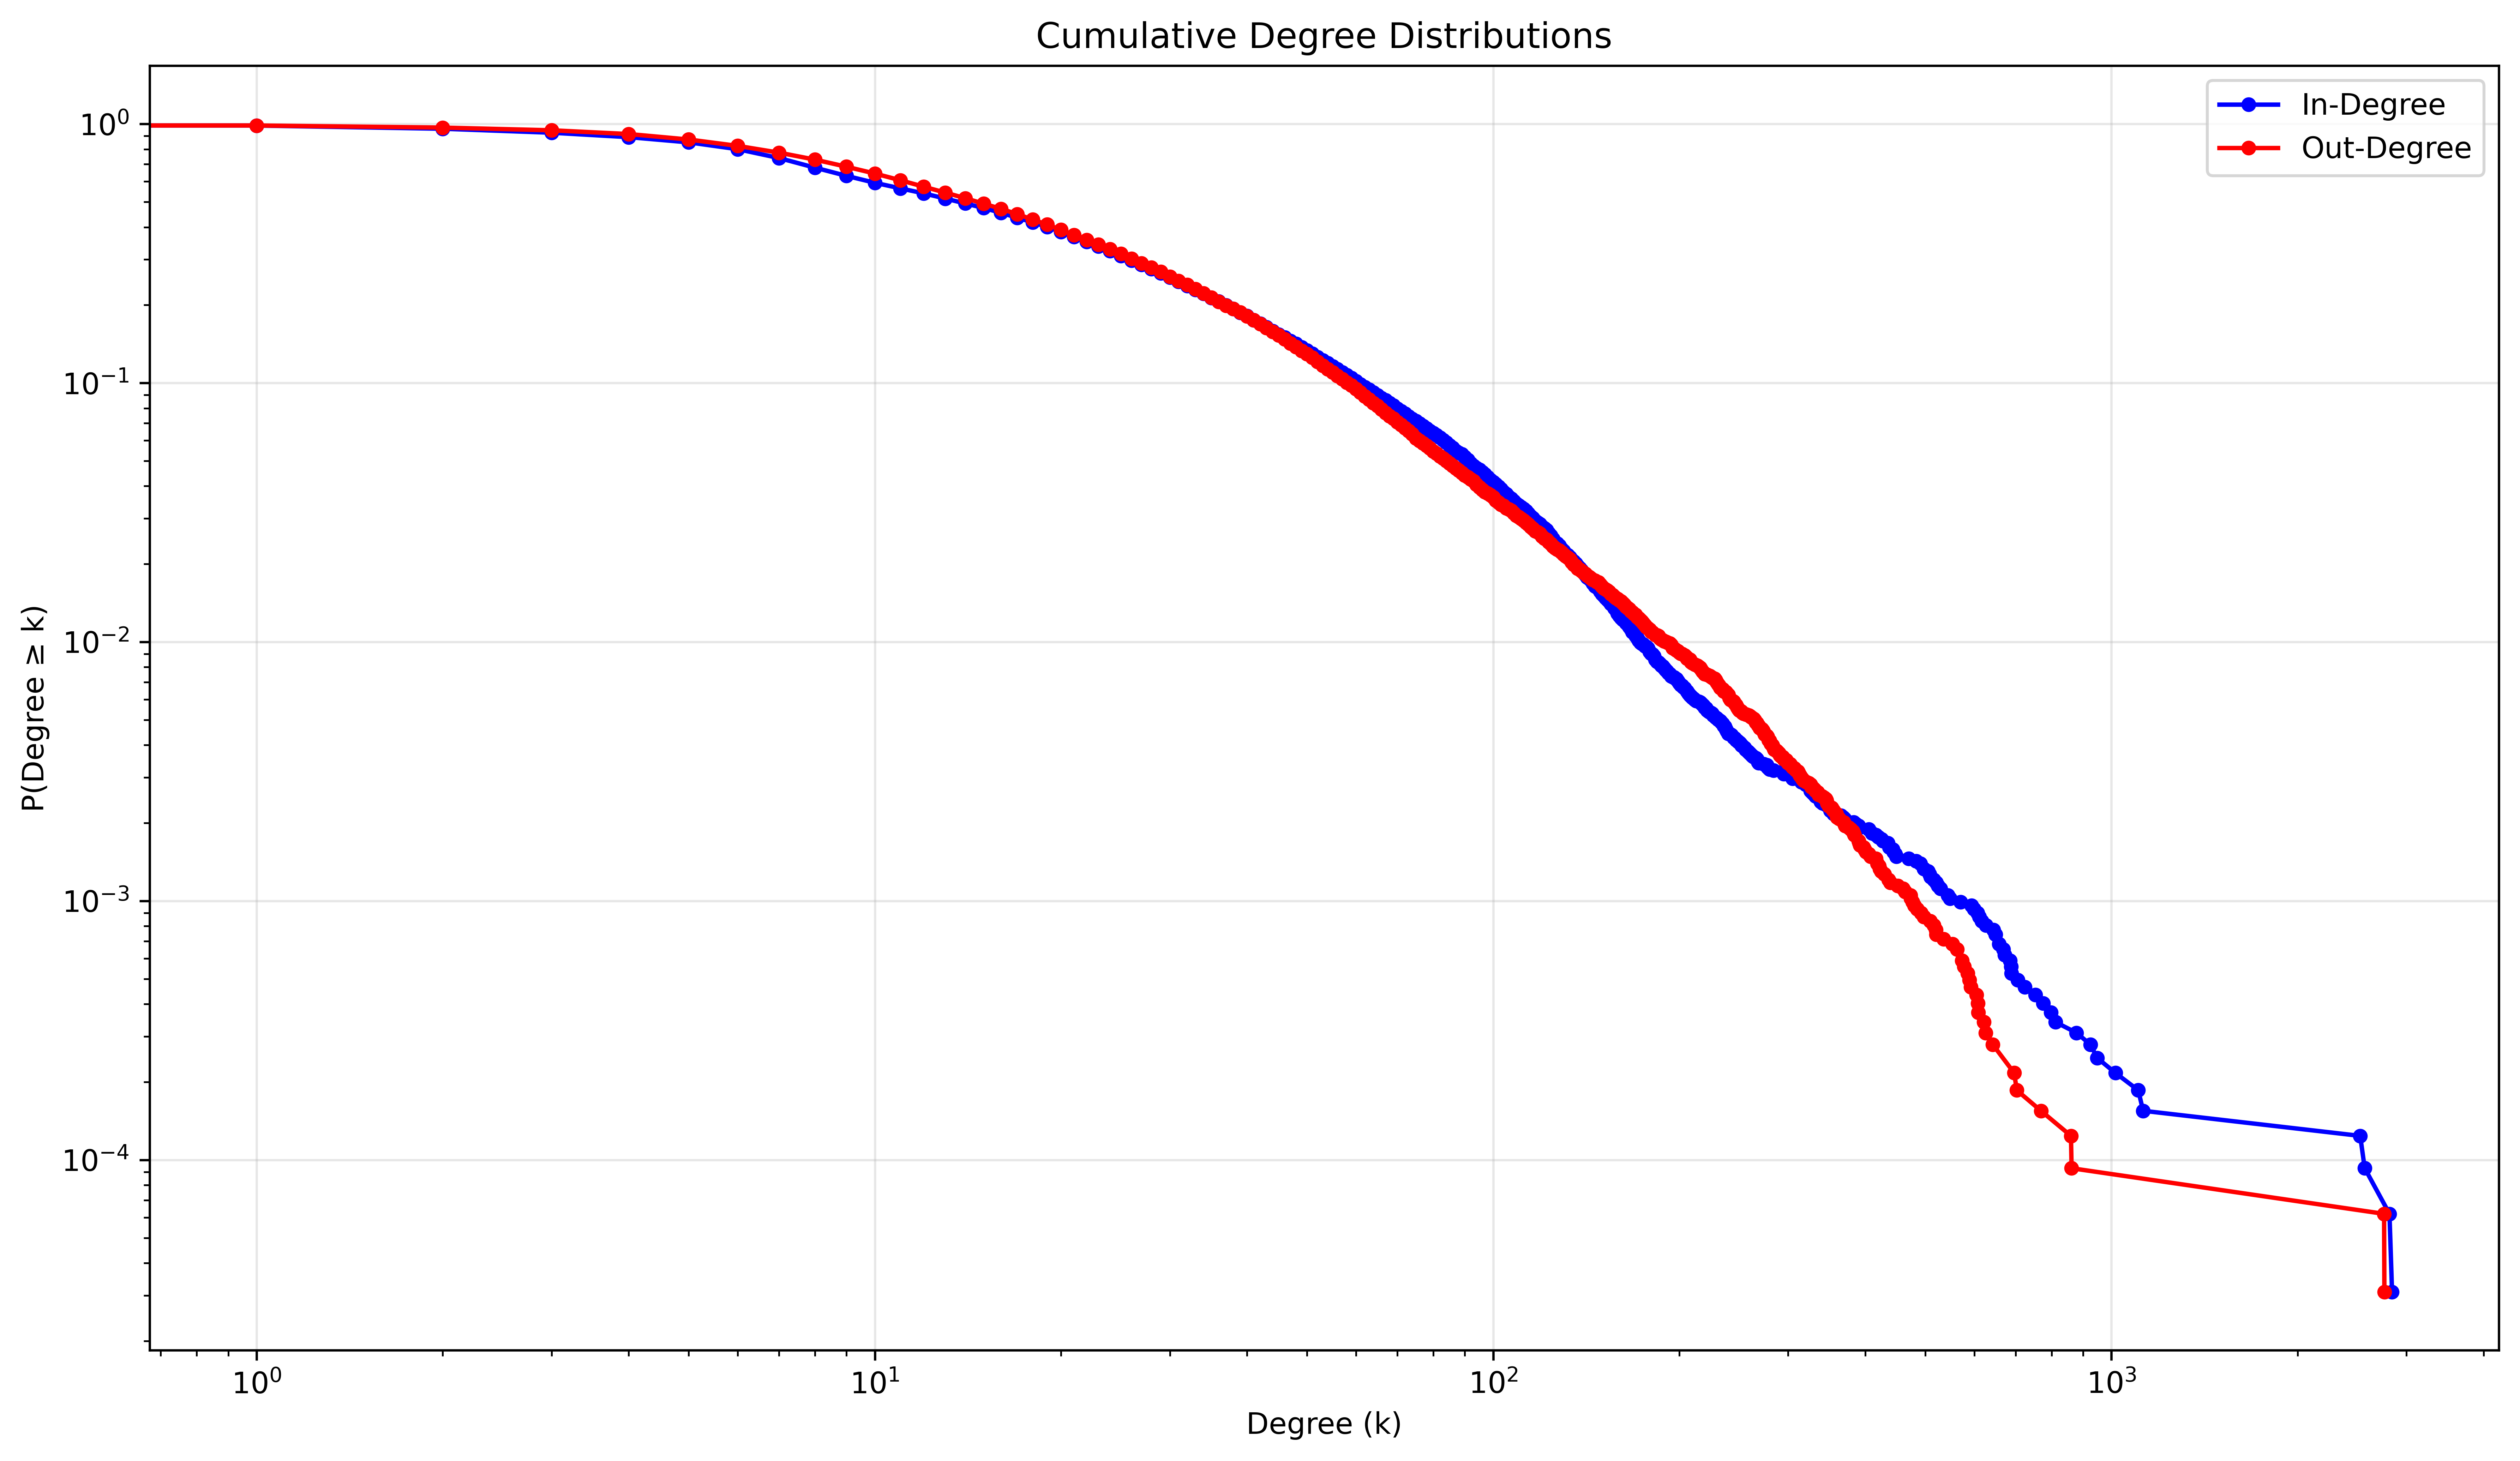

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# Print start of script for tracking
print("Starting network analysis...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Read {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )
print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])
print(f"Added {G.number_of_edges()} edges to the graph")

# Calculate in-degrees and out-degrees
print("Calculating in-degrees and out-degrees...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())} max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())} max={max(out_degrees.values())}")

# Count frequency of each degree
print("Creating degree frequency dictionaries...")
in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

# Sort degrees in ascending order
print("Sorting degree counts...")
sorted_in_degrees = sorted(in_degree_counts.items())
sorted_out_degrees = sorted(out_degree_counts.items())

# Extract x and y values for plotting
print("Extracting plotting data...")
in_x = [k for k, _ in sorted_in_degrees]
in_y = [v for _, v in sorted_in_degrees]
out_x = [k for k, _ in sorted_out_degrees]
out_y = [v for _, v in sorted_out_degrees]

# Calculate cumulative distributions
print("Calculating cumulative distributions...")
total_nodes = G.number_of_nodes()
in_cumulative_y = np.cumsum(in_y[::-1])[::-1] / total_nodes
out_cumulative_y = np.cumsum(out_y[::-1])[::-1] / total_nodes

# Create output directory if it doesn't exist
if not os.path.exists("output"):
    os.makedirs("output")
    print("Created output directory")

# Plot in-degree distribution
print("Plotting in-degree distribution...")
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo-', markersize=4)
plt.title('Cumulative In-Degree Distribution')
plt.xlabel('In-Degree (k)')
plt.ylabel('P(In-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('output/in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution plot at 600dpi")

# Plot out-degree distribution
print("Plotting out-degree distribution...")
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(out_x, out_cumulative_y, 'ro-', markersize=4)
plt.title('Cumulative Out-Degree Distribution')
plt.xlabel('Out-Degree (k)')
plt.ylabel('P(Out-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('output/out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution plot at 600dpi")

# Combined plot
print("Creating combined distribution plot...")
plt.figure(figsize=(12, 7), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo-', markersize=4, label='In-Degree')
plt.plot(out_x, out_cumulative_y, 'ro-', markersize=4, label='Out-Degree')
plt.title('Cumulative Degree Distributions')
plt.xlabel('Degree (k)')
plt.ylabel('P(Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/combined_degree_distribution.png', dpi=600)
print("Saved combined distribution plot at 600dpi")

# Calculate and print some basic network statistics
print("\nNetwork Statistics:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average in-degree: {sum(in_degrees.values()) / total_nodes:.2f}")
print(f"Average out-degree: {sum(out_degrees.values()) / total_nodes:.2f}")
print(f"Network density: {nx.density(G):.6f}")
print(f"Is strongly connected: {nx.is_strongly_connected(G)}")
print(f"Number of strongly connected components: {nx.number_strongly_connected_components(G)}")

print("Analysis complete!")

Starting network analysis...
Reading CSV files...
Read 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Calculating in-degrees and out-degrees...
In-degree range: min=0 max=2843
Out-degree range: min=0 max=2763
Creating degree frequency dictionaries...
Sorting degree counts...
Extracting plotting data...
Calculating cumulative distributions...
Plotting in-degree distribution...
Saved in-degree distribution plot at 600dpi
Plotting out-degree distribution...
Saved out-degree distribution plot at 600dpi


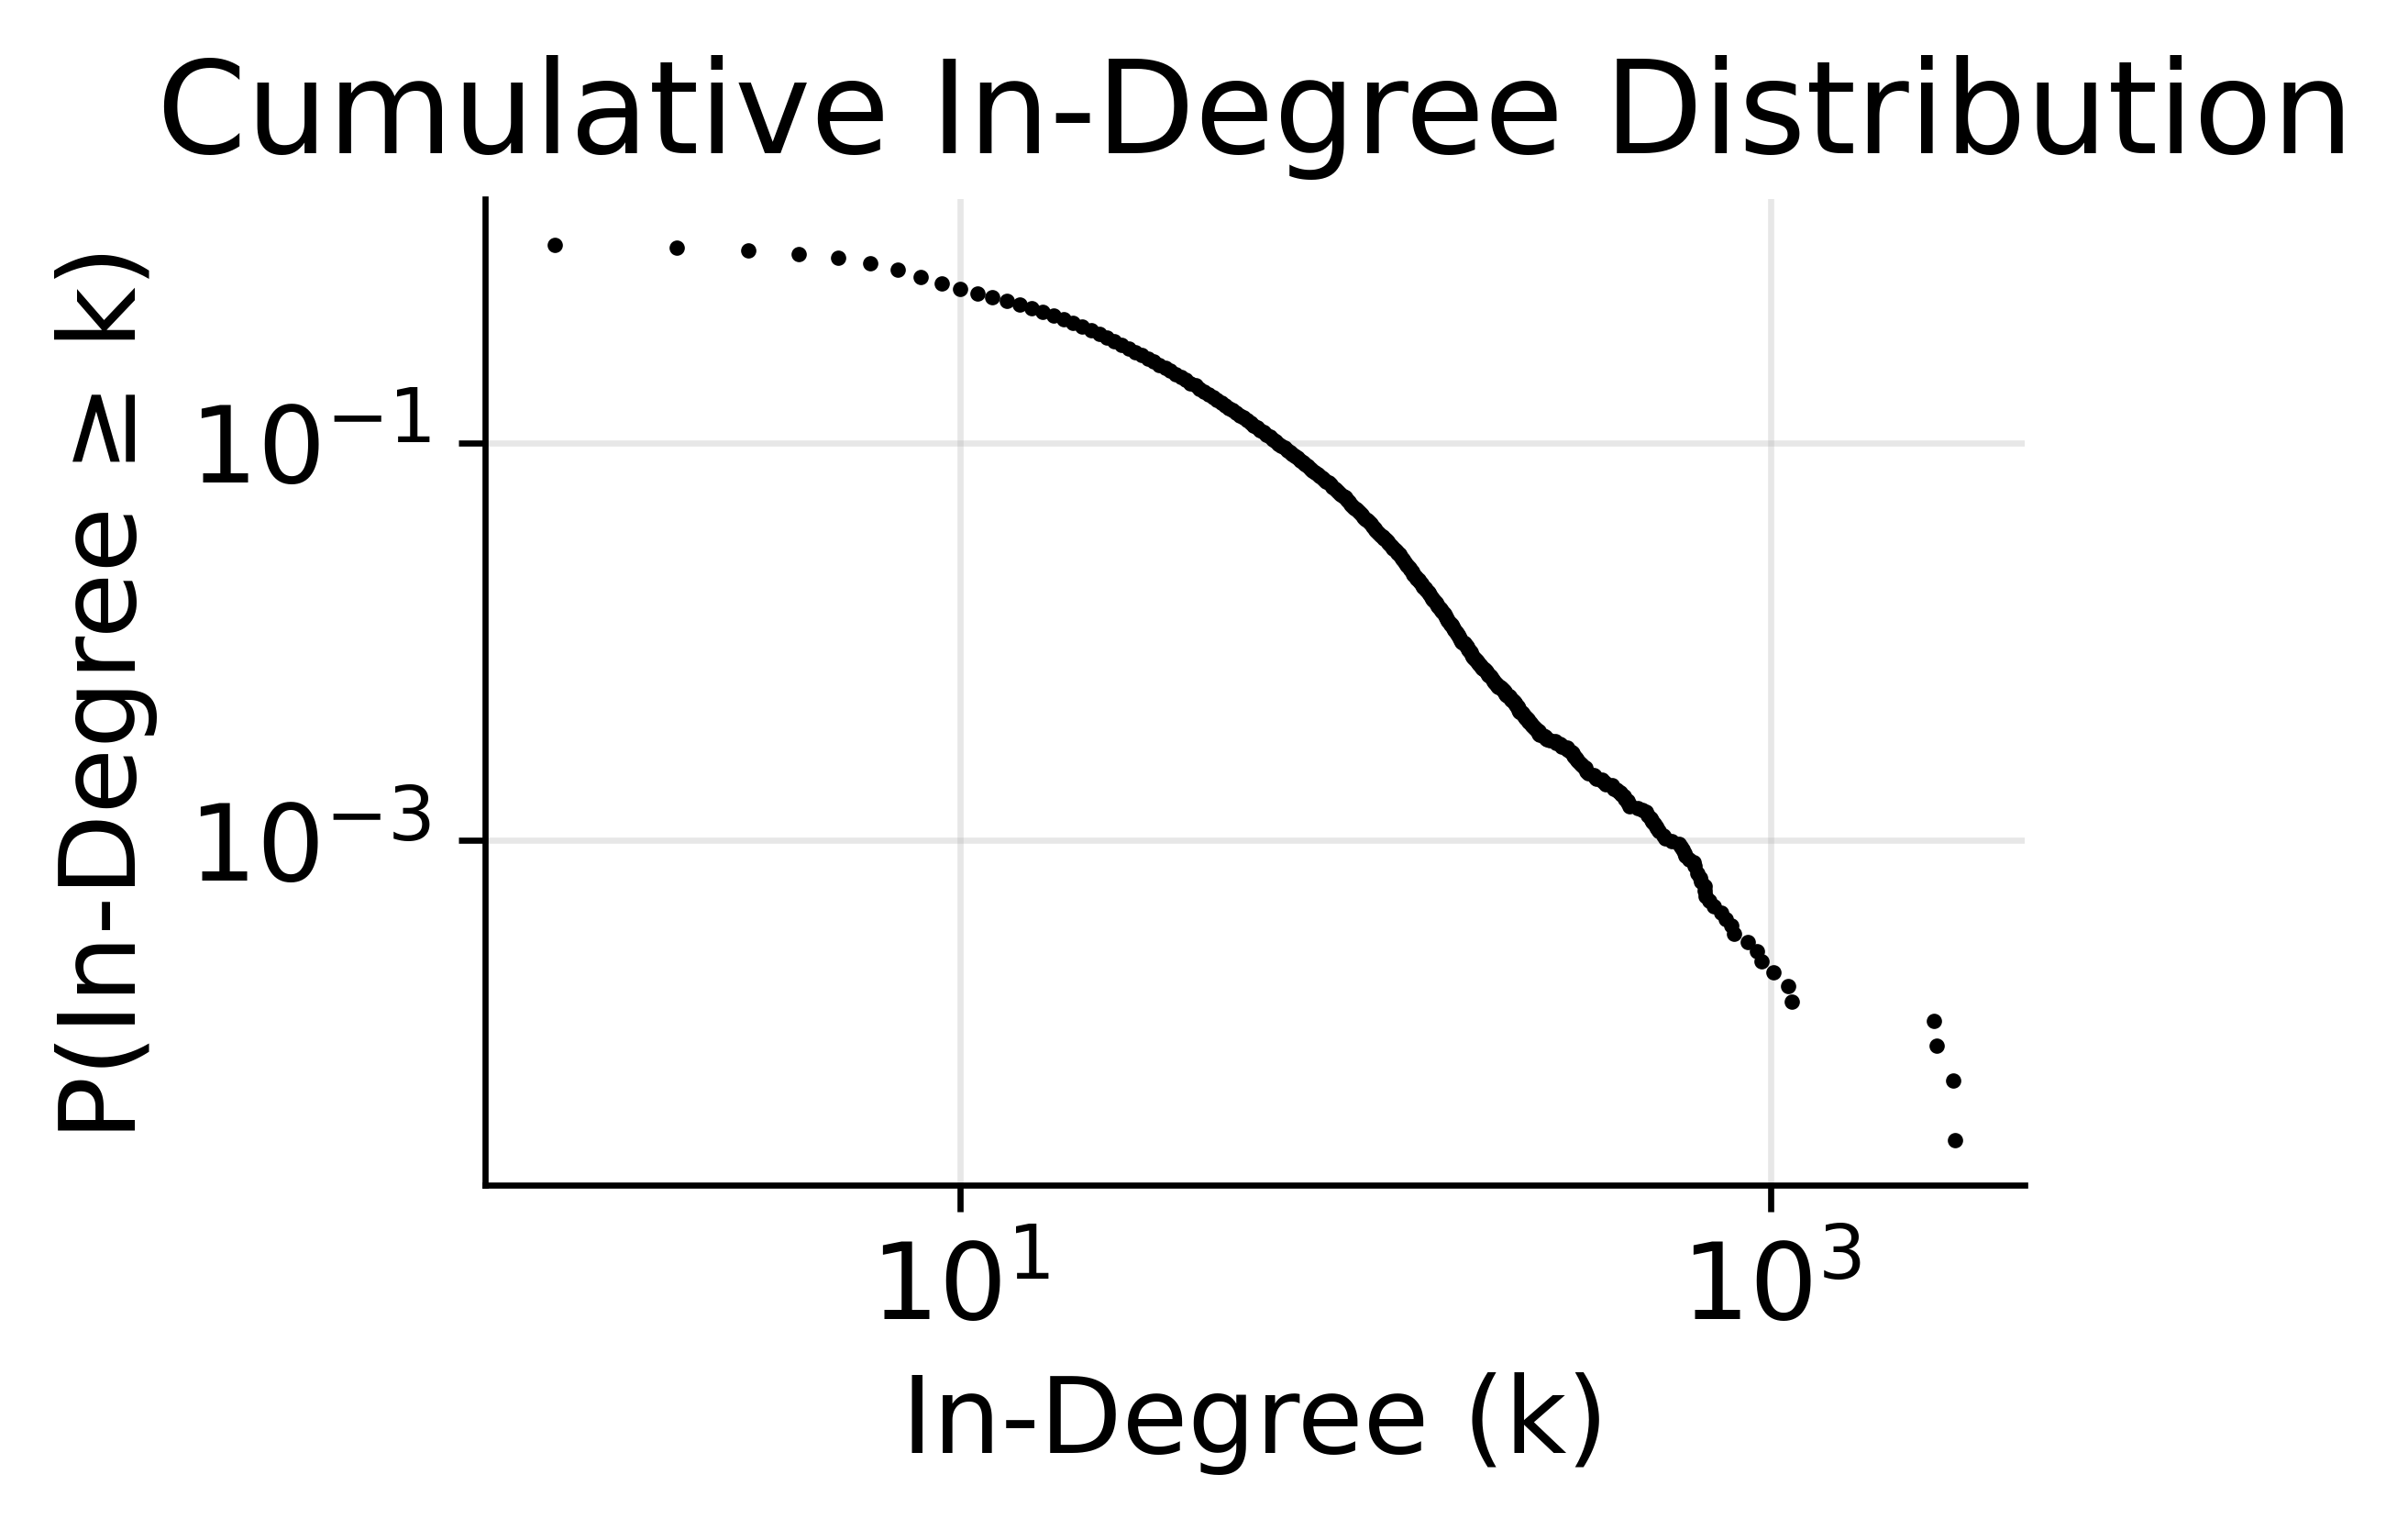

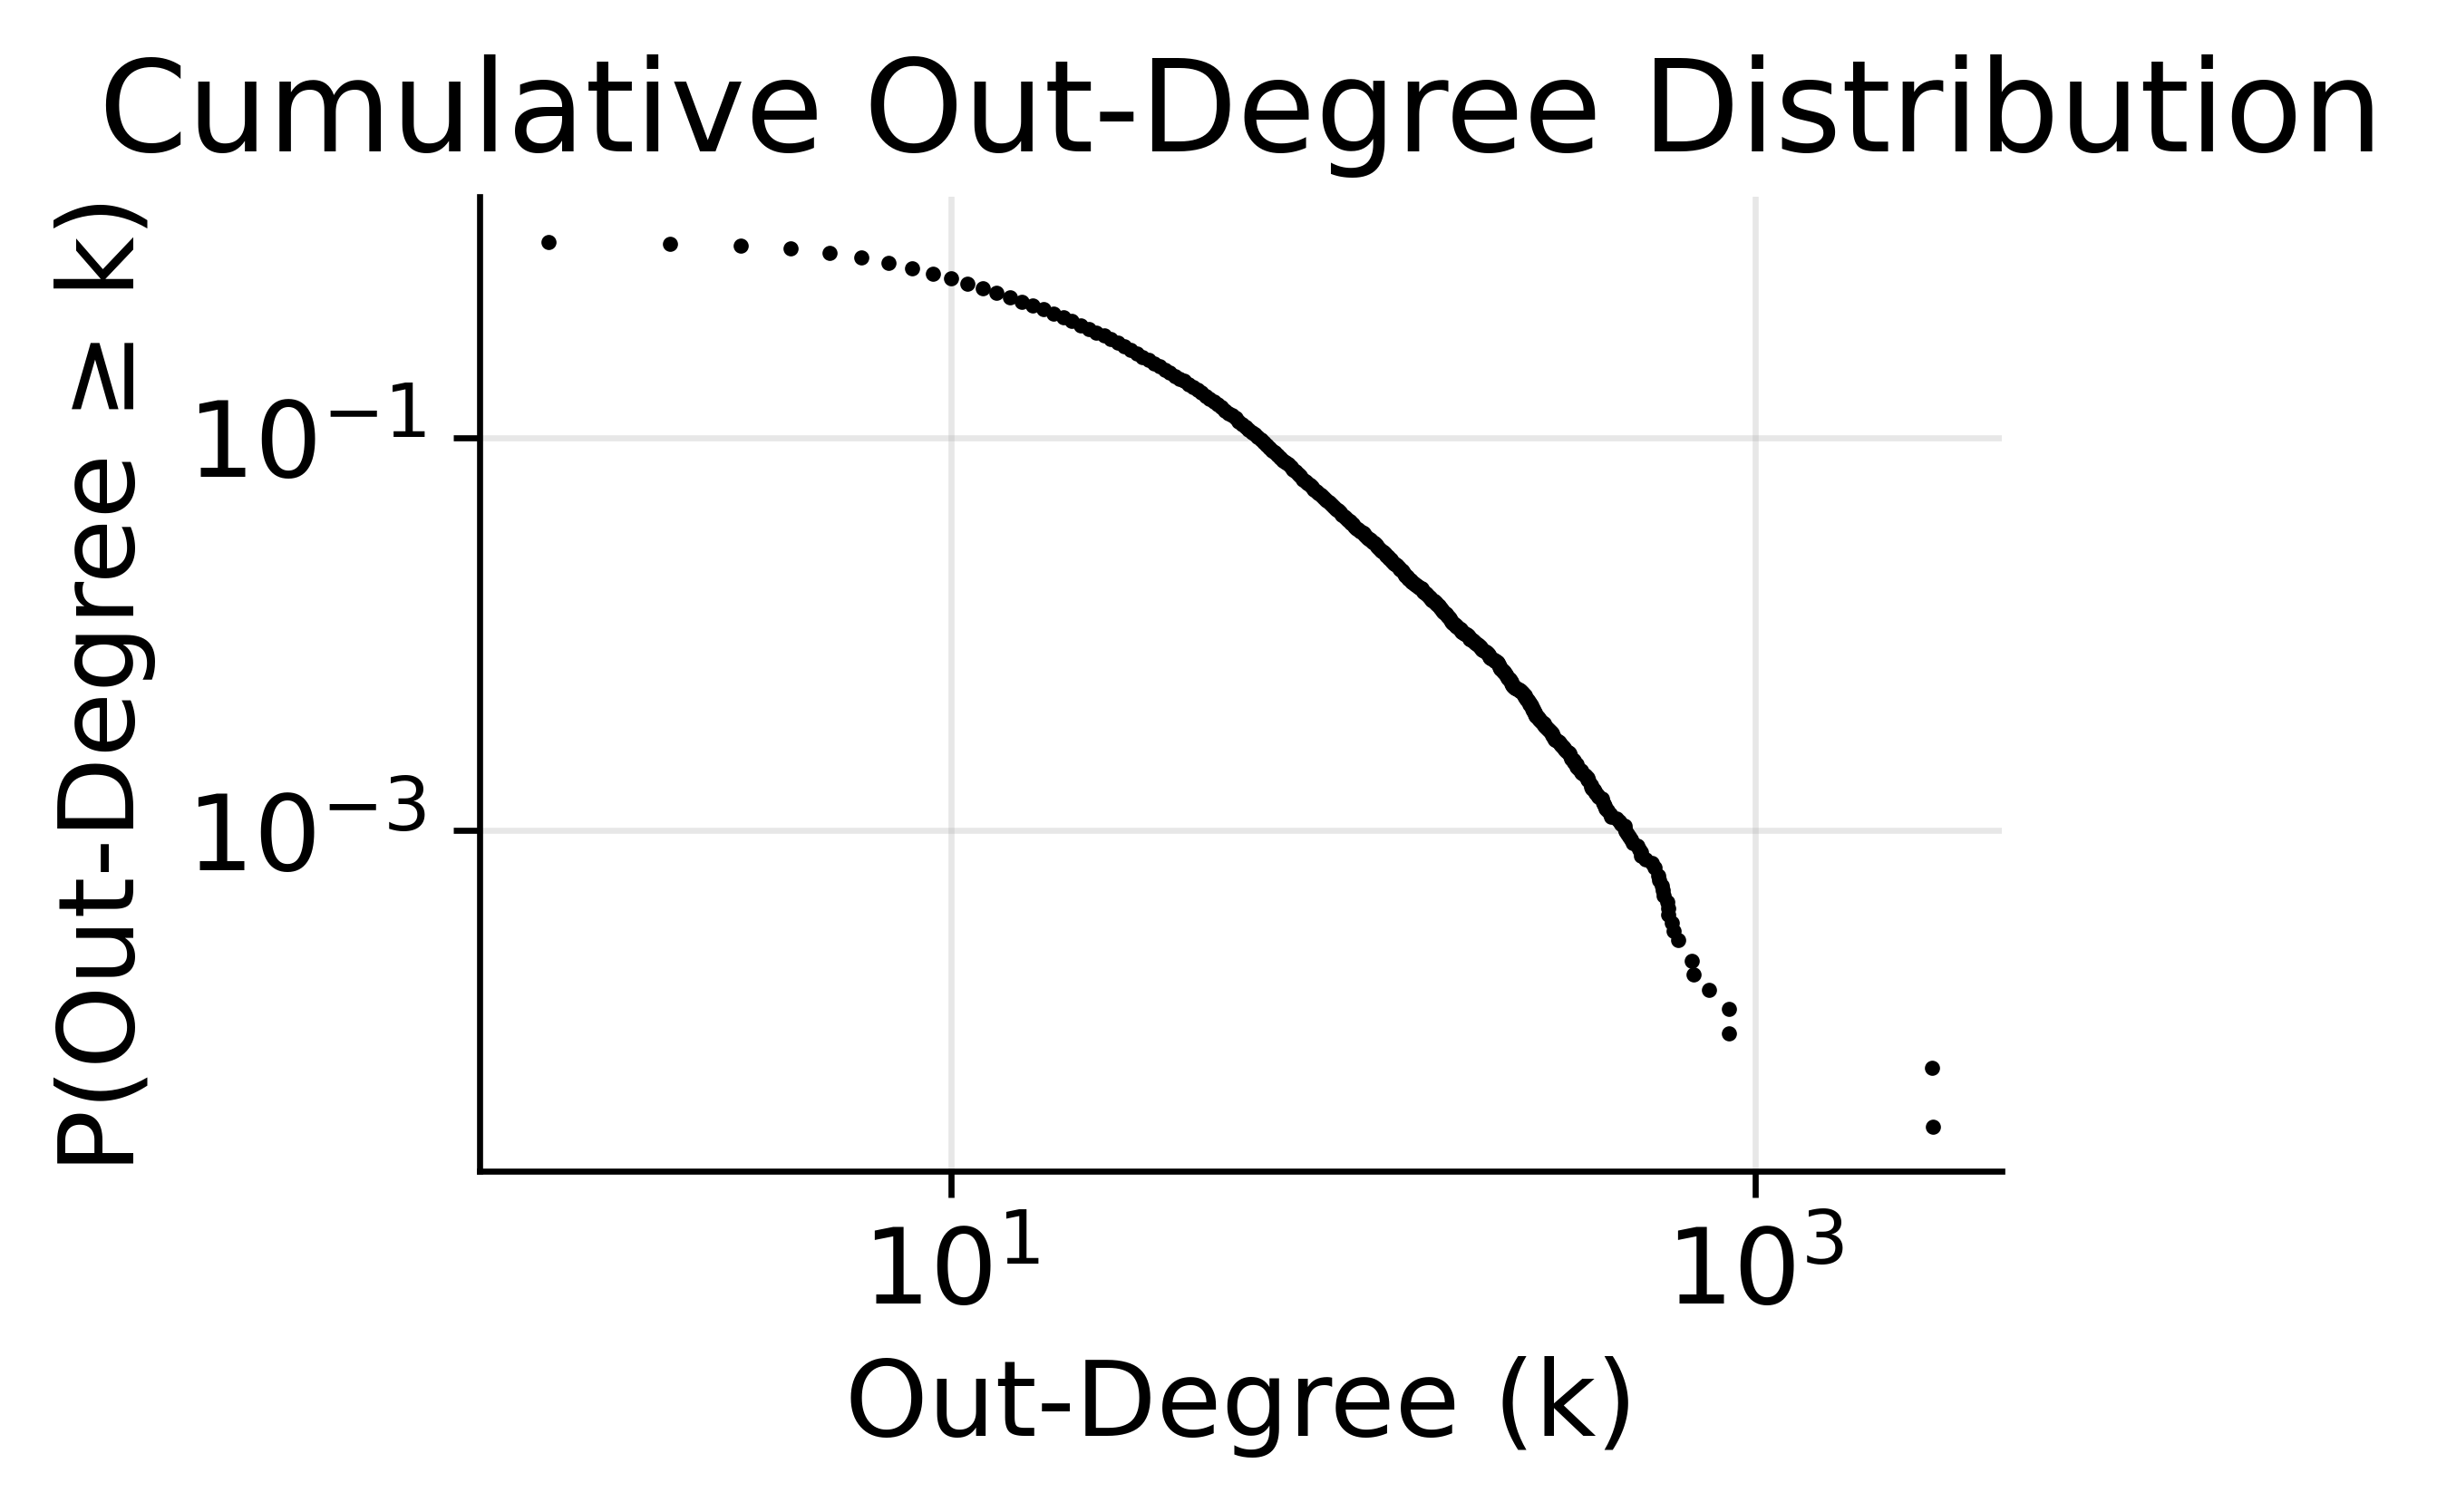

In [77]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# Print start of script for tracking
print("Starting network analysis...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Read {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )
print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])
print(f"Added {G.number_of_edges()} edges to the graph")

# Calculate in-degrees and out-degrees
print("Calculating in-degrees and out-degrees...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())} max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())} max={max(out_degrees.values())}")

# Count frequency of each degree
print("Creating degree frequency dictionaries...")
in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

# Sort degrees in ascending order
print("Sorting degree counts...")
sorted_in_degrees = sorted(in_degree_counts.items())
sorted_out_degrees = sorted(out_degree_counts.items())

# Extract x and y values for plotting
print("Extracting plotting data...")
in_x = [k for k, _ in sorted_in_degrees]
in_y = [v for _, v in sorted_in_degrees]
out_x = [k for k, _ in sorted_out_degrees]
out_y = [v for _, v in sorted_out_degrees]

# Calculate cumulative distributions
print("Calculating cumulative distributions...")
total_nodes = G.number_of_nodes()
in_cumulative_y = np.cumsum(in_y[::-1])[::-1] / total_nodes
out_cumulative_y = np.cumsum(out_y[::-1])[::-1] / total_nodes

# Create output directory if it doesn't exist
if not os.path.exists("output"):
    os.makedirs("output")
    print("Created output directory")

# Plot in-degree distribution
print("Plotting in-degree distribution...")
plt.figure(figsize=(4, 3), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo', markersize=1, color='black')
plt.title('Cumulative In-Degree Distribution')
plt.xlabel('In-Degree (k)')
plt.ylabel('P(In-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution plot at 600dpi")

# Plot out-degree distribution
print("Plotting out-degree distribution...")
plt.figure(figsize=(4, 3), dpi=600)
plt.plot(out_x, out_cumulative_y, 'bo', markersize=1,color='black')
plt.title('Cumulative Out-Degree Distribution')
plt.xlabel('Out-Degree (k)')
plt.ylabel('P(Out-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution plot at 600dpi")


Creating combined distribution plot...
Saved combined distribution plot at 600dpi


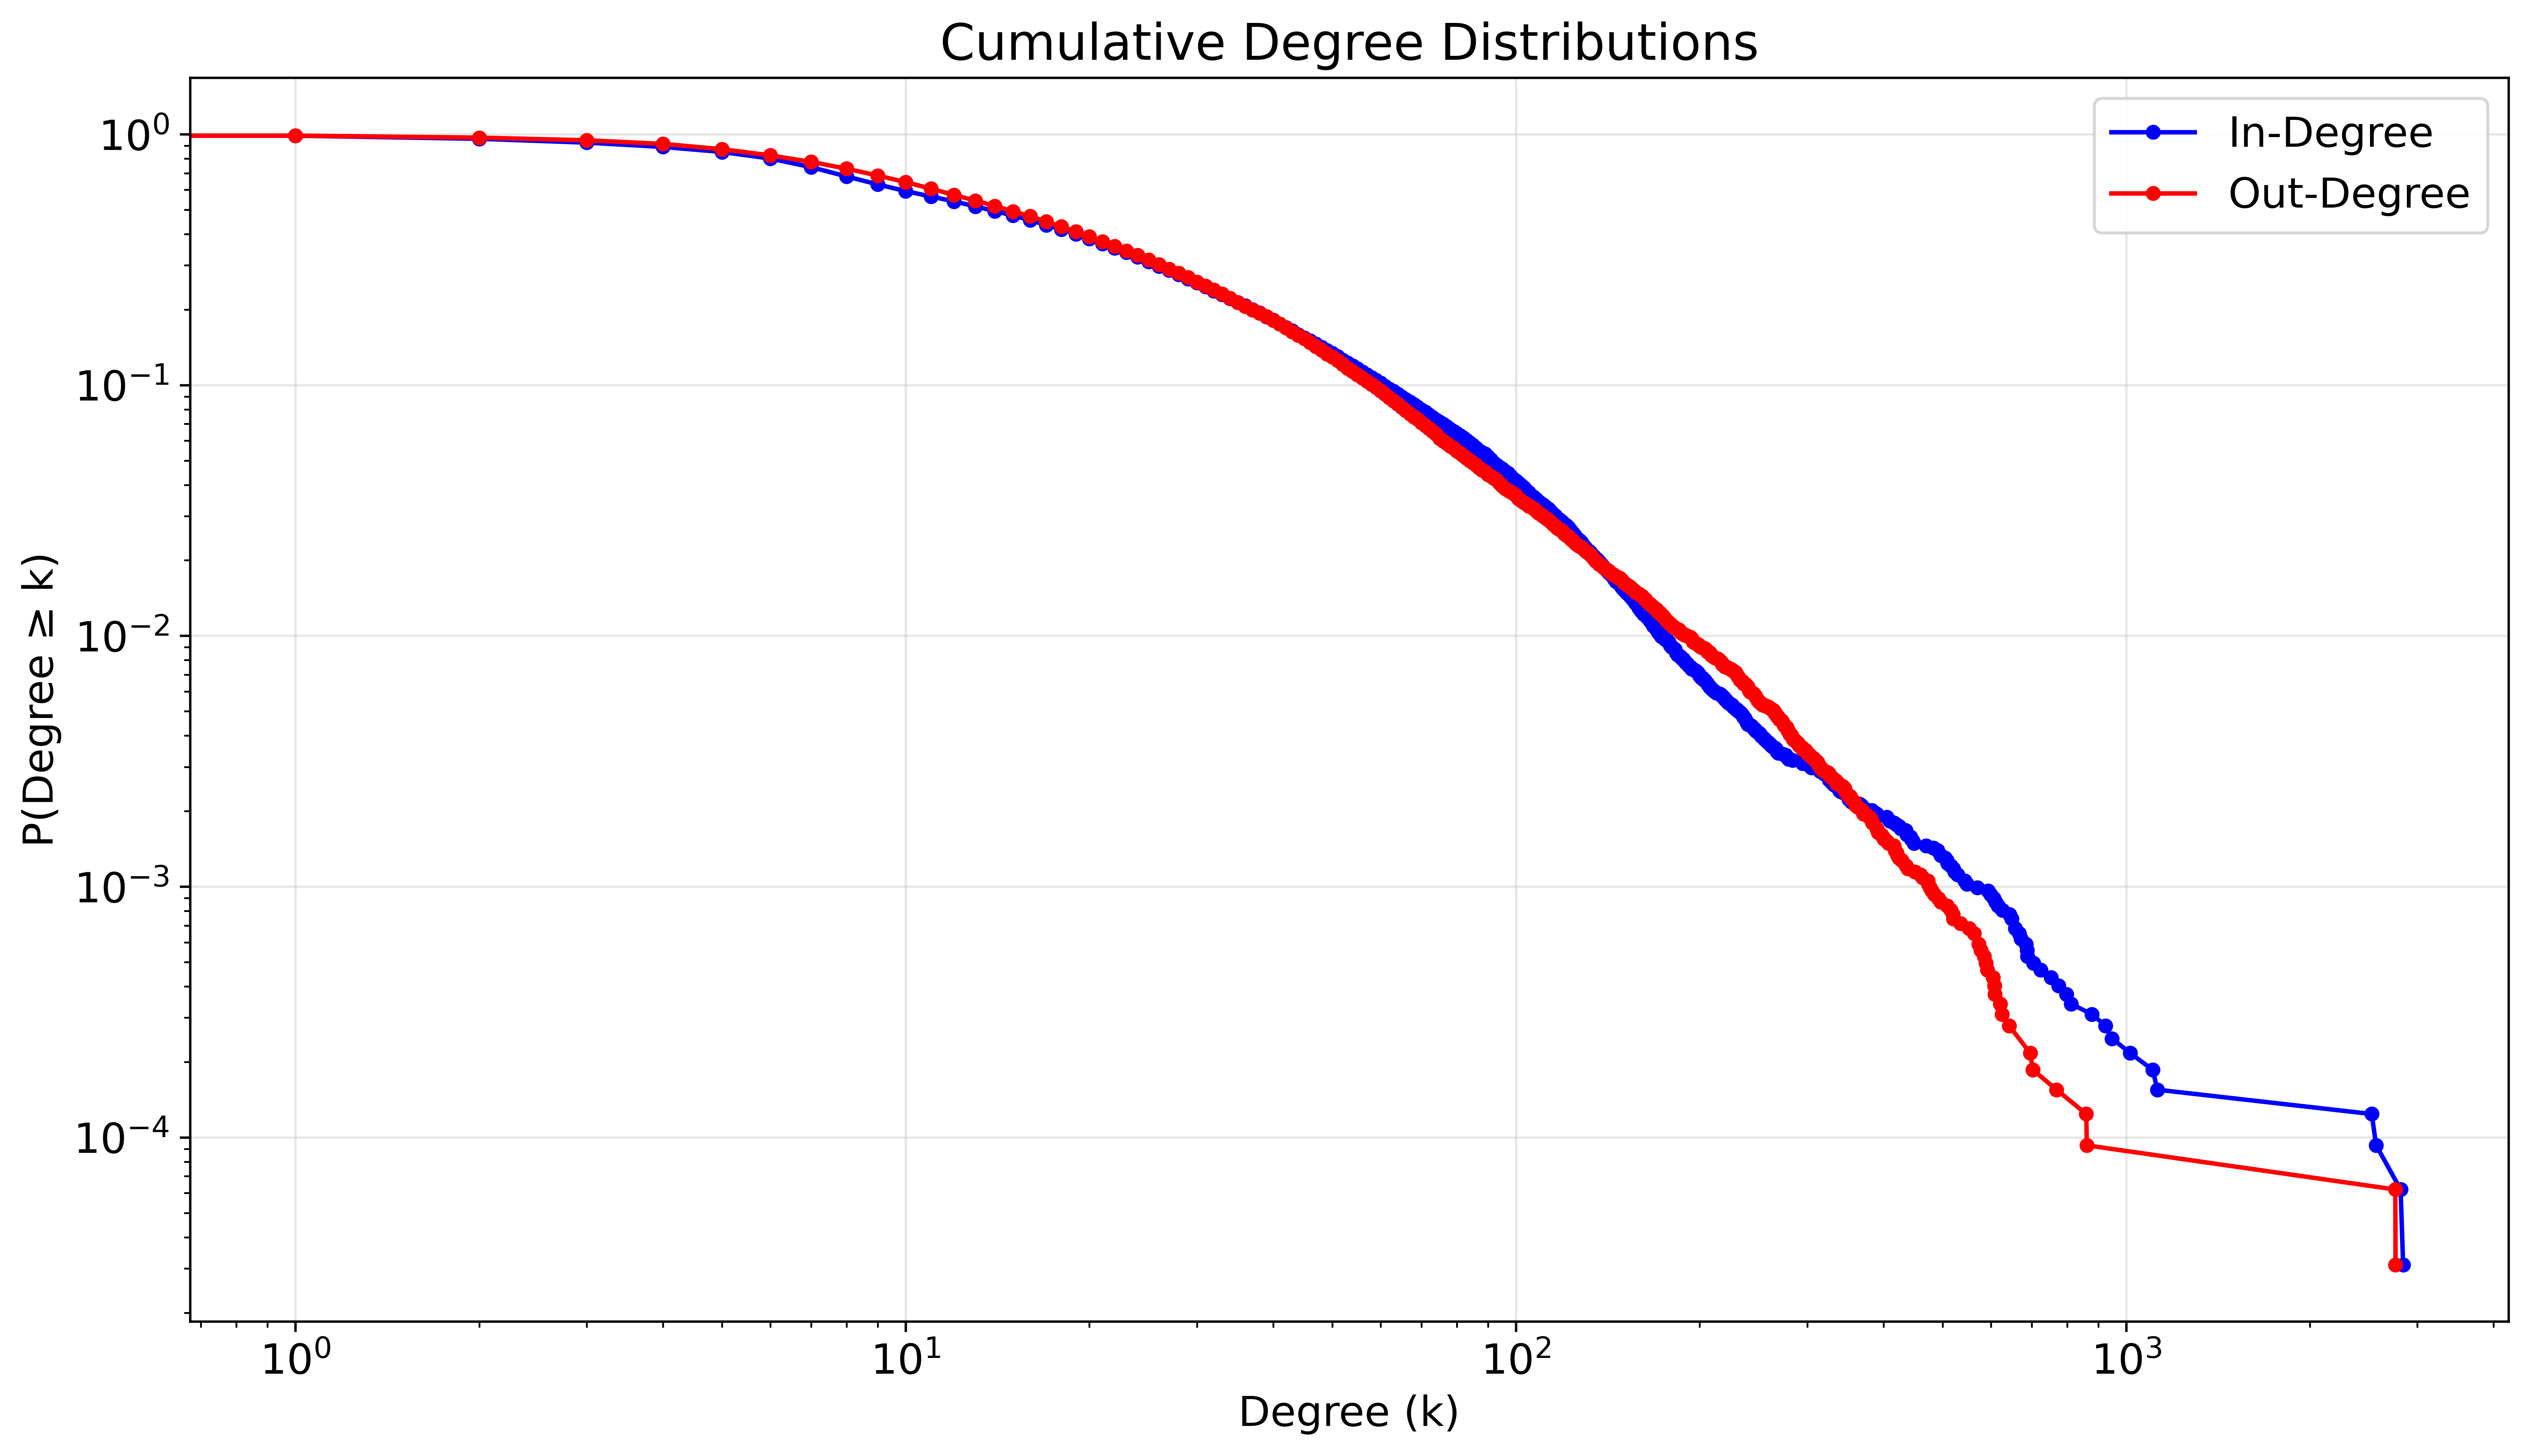

In [55]:
# Combined plot
print("Creating combined distribution plot...")
plt.figure(figsize=(12, 7), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo-', markersize=4, label='In-Degree')
plt.plot(out_x, out_cumulative_y, 'ro-', markersize=4, label='Out-Degree')
plt.title('Cumulative Degree Distributions')
plt.xlabel('Degree (k)')
plt.ylabel('P(Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/combined_degree_distribution.png', dpi=600)
print("Saved combined distribution plot at 600dpi")


Starting degree distribution fitting analysis...

1. Fitting power laws with minimum degree thresholds...

Fitting in-degree distribution:
  Creating powerlaw fit object with 32272 data points...
  Optimal xmin: 97.0
  Power law alpha: 3.3718790009149306

Fitting out-degree distribution:
  Creating powerlaw fit object with 32272 data points...
  Optimal xmin: 56.0
  Power law alpha: 2.915470086055626

Plotting power law fits...
Saved in-degree power law fit plot
Saved out-degree power law fit plot

2. Fitting combined exponential and power law models...

Fitting in-degree distribution with combined model:
  Initial parameter guesses: [nan, 0.1, 1.0, 2.0, 250.4539229053049]
  Error fitting combined model: `x0` is infeasible.

Fitting out-degree distribution with combined model:
  Initial parameter guesses: [nan, 0.1, 1.0, 2.0, 236.5570463559742]
  Error fitting combined model: `x0` is infeasible.

Plotting combined model fits...


<ipython-input-27-e7c99295884f>:140: RuntimeWarning: divide by zero encountered in log
  k_threshold_guess = np.exp(np.log(min_x) + (np.log(max_x) - np.log(min_x)) / 3)
<ipython-input-27-e7c99295884f>:140: RuntimeWarning: invalid value encountered in double_scalars
  k_threshold_guess = np.exp(np.log(min_x) + (np.log(max_x) - np.log(min_x)) / 3)
<ipython-input-27-e7c99295884f>:184: RuntimeWarning: divide by zero encountered in log10
  x_smooth = np.logspace(np.log10(min(in_x)), np.log10(max(in_x)), 1000)
/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/numpy/core/function_base.py:151: RuntimeWarning: invalid value encountered in multiply
  y *= step
/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/numpy/core/function_base.py:161: RuntimeWarning: invalid value encountered in add
  y += start
posx and posy should be finite values
posx and posy should be finite values
<ipython-input-27-e7c99295884f>:212: RuntimeWarning: divide by zero encountered in log10
  x_smooth = np.log

Saved in-degree combined model fit plot


posx and posy should be finite values
posx and posy should be finite values


Saved out-degree combined model fit plot

Summary of Fitting Results:
--------------------------------------------------
Power Law Fits:
In-degree:  xmin=97.0, alpha=3.372
Out-degree: xmin=56.0, alpha=2.915

Combined Model Fits:
In-degree:  Threshold=nan, Exp_lambda=0.100, Power_alpha=2.000
Out-degree: Threshold=nan, Exp_lambda=0.100, Power_alpha=2.000
--------------------------------------------------
Degree distribution fitting analysis complete!


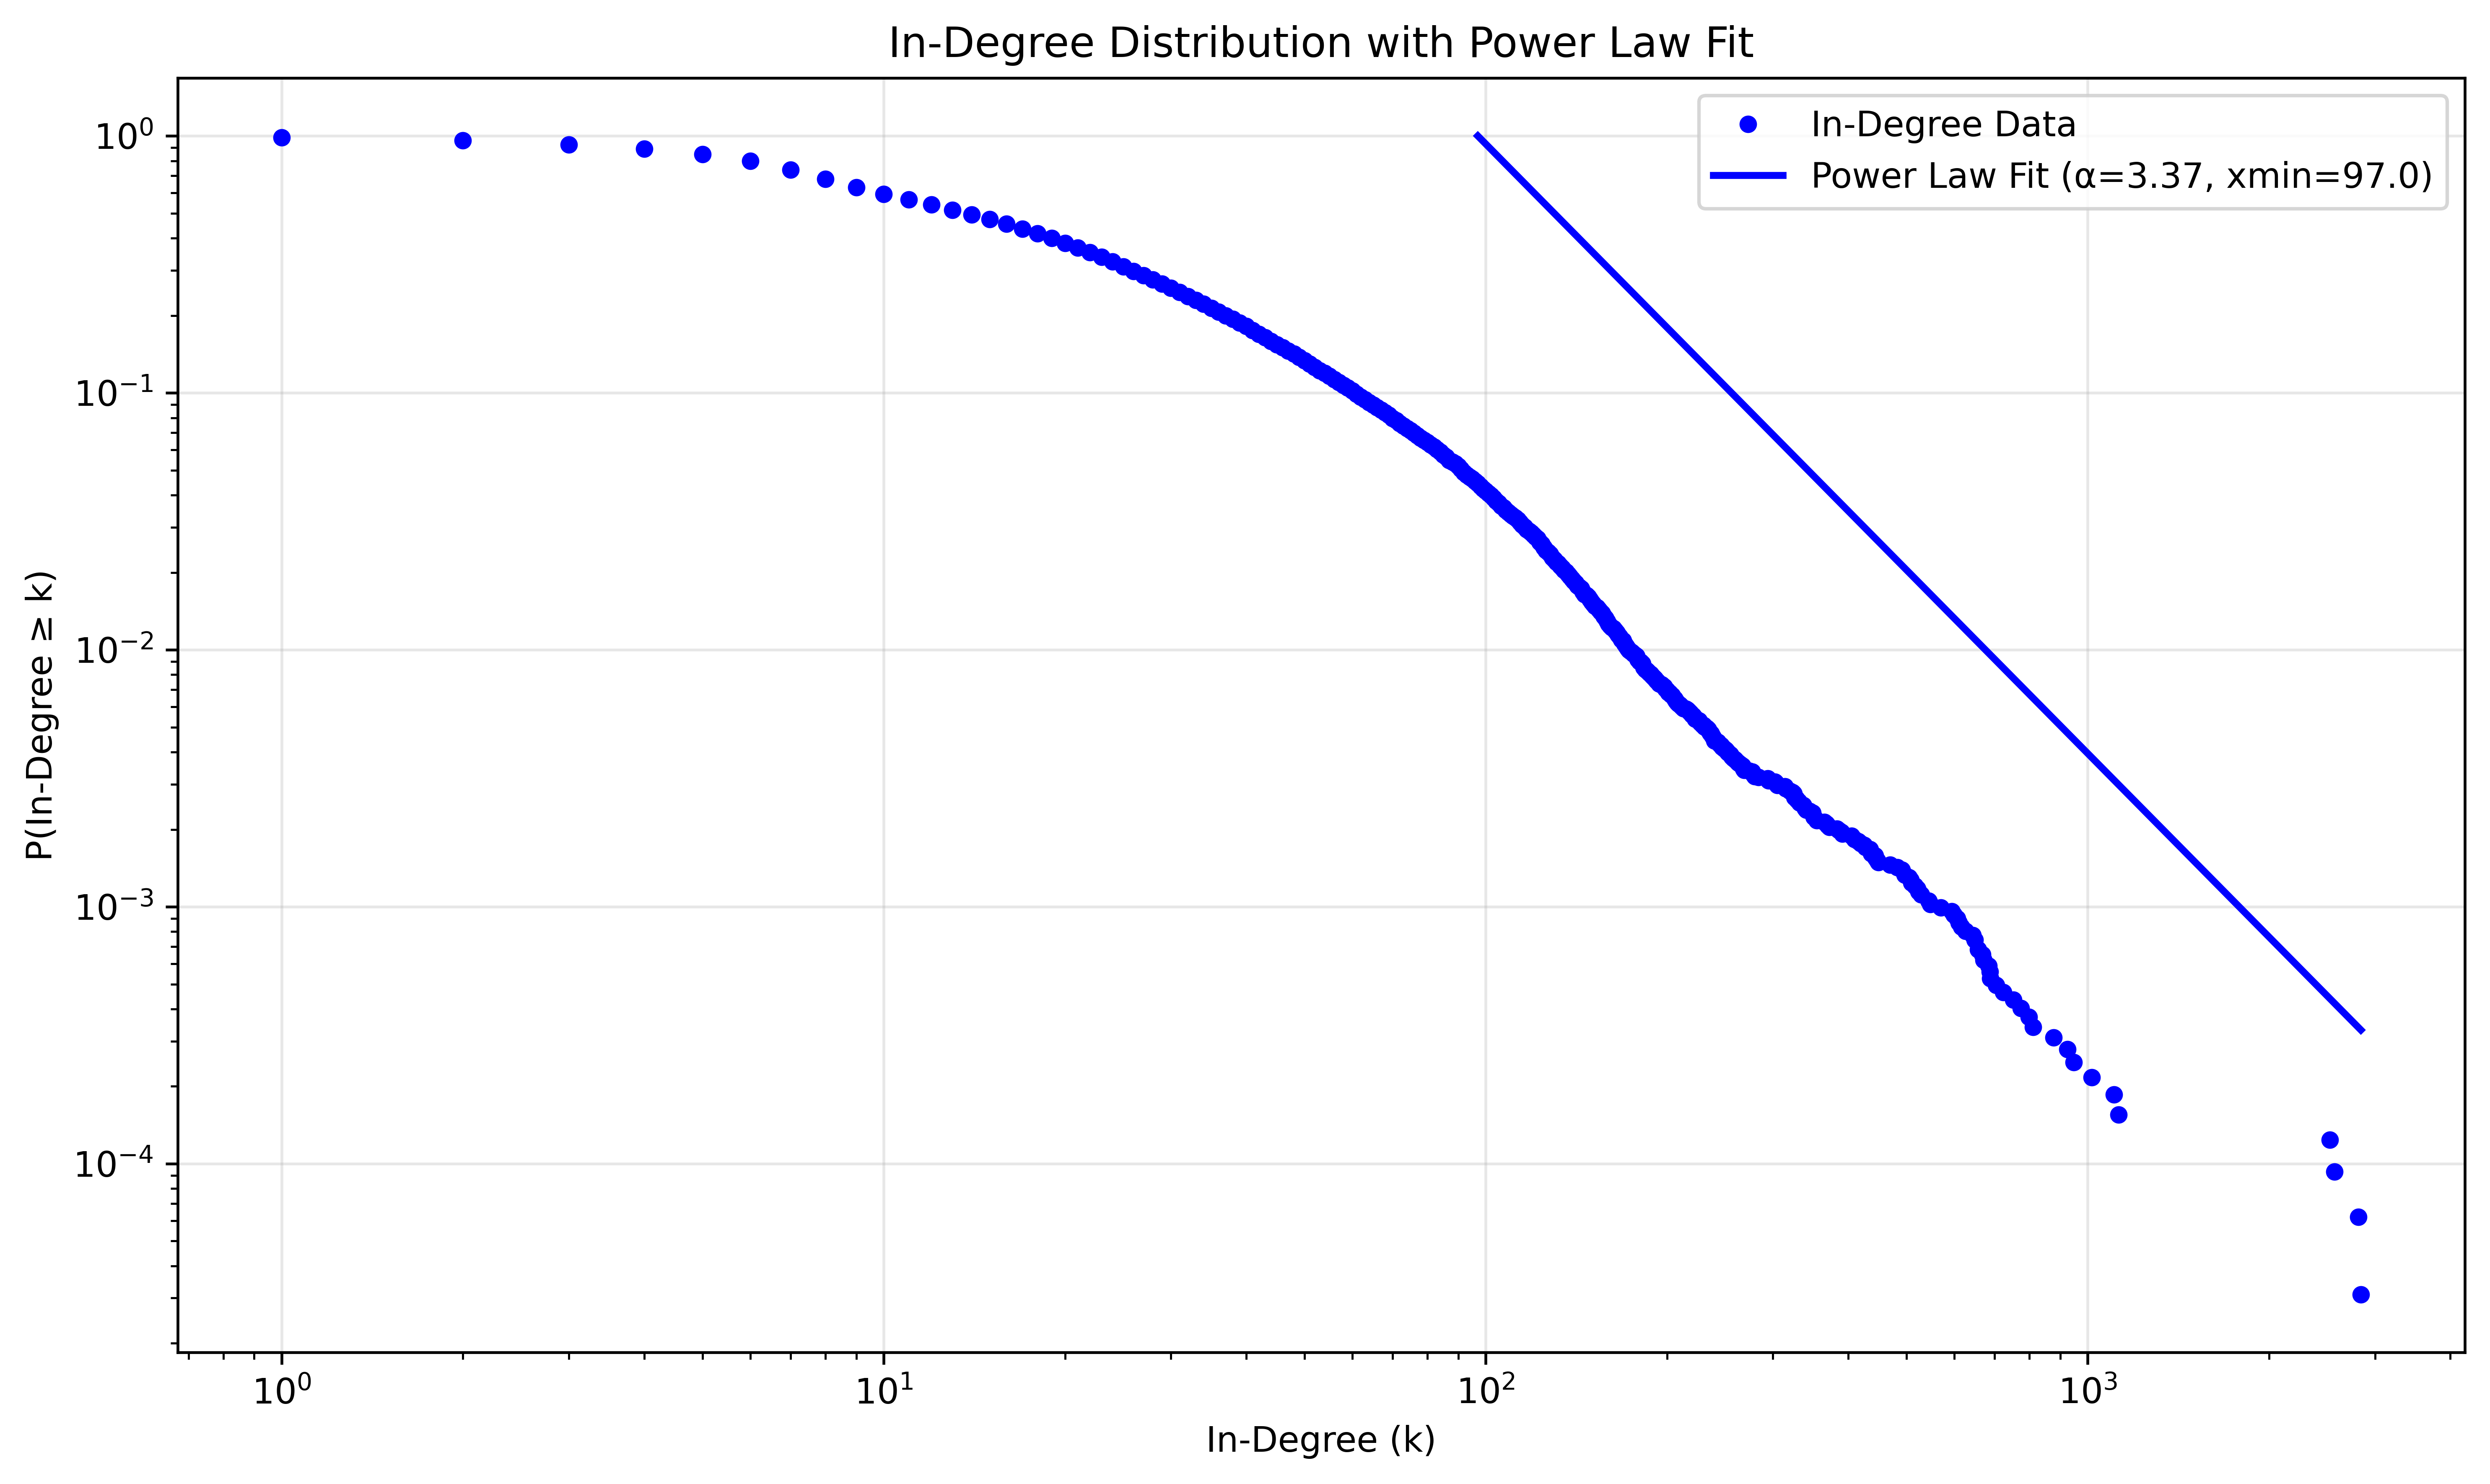

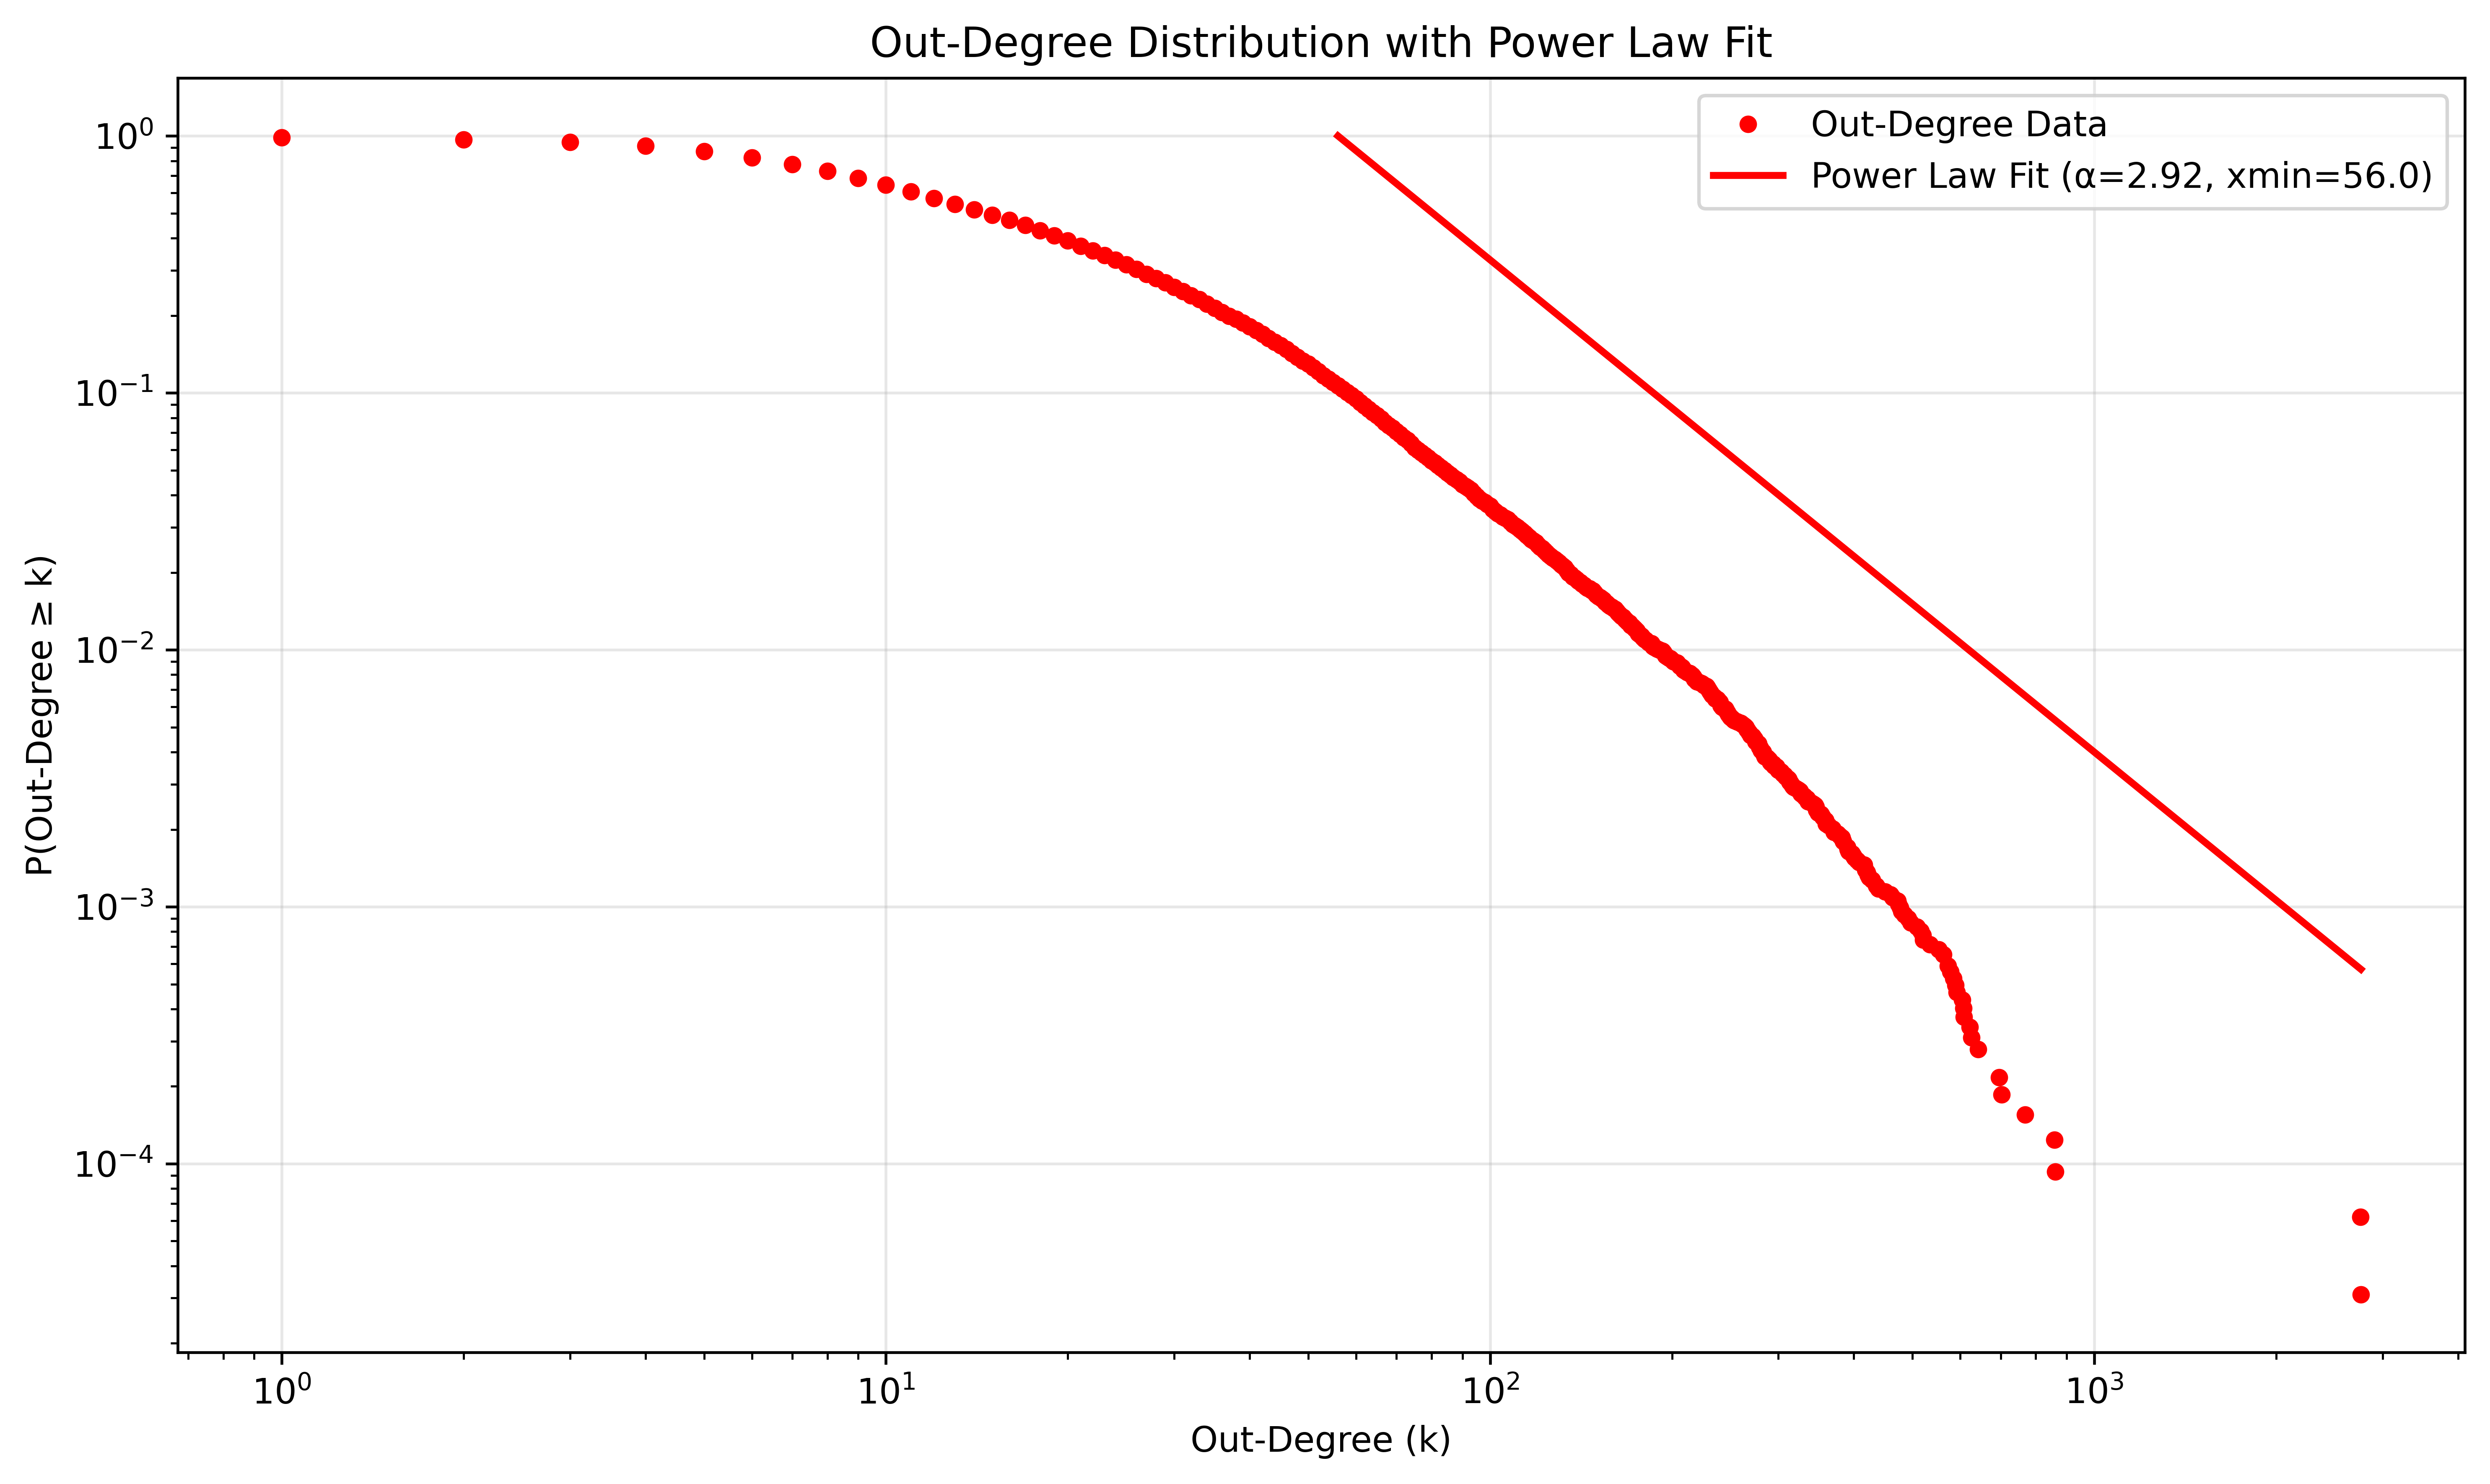

posx and posy should be finite values
posx and posy should be finite values


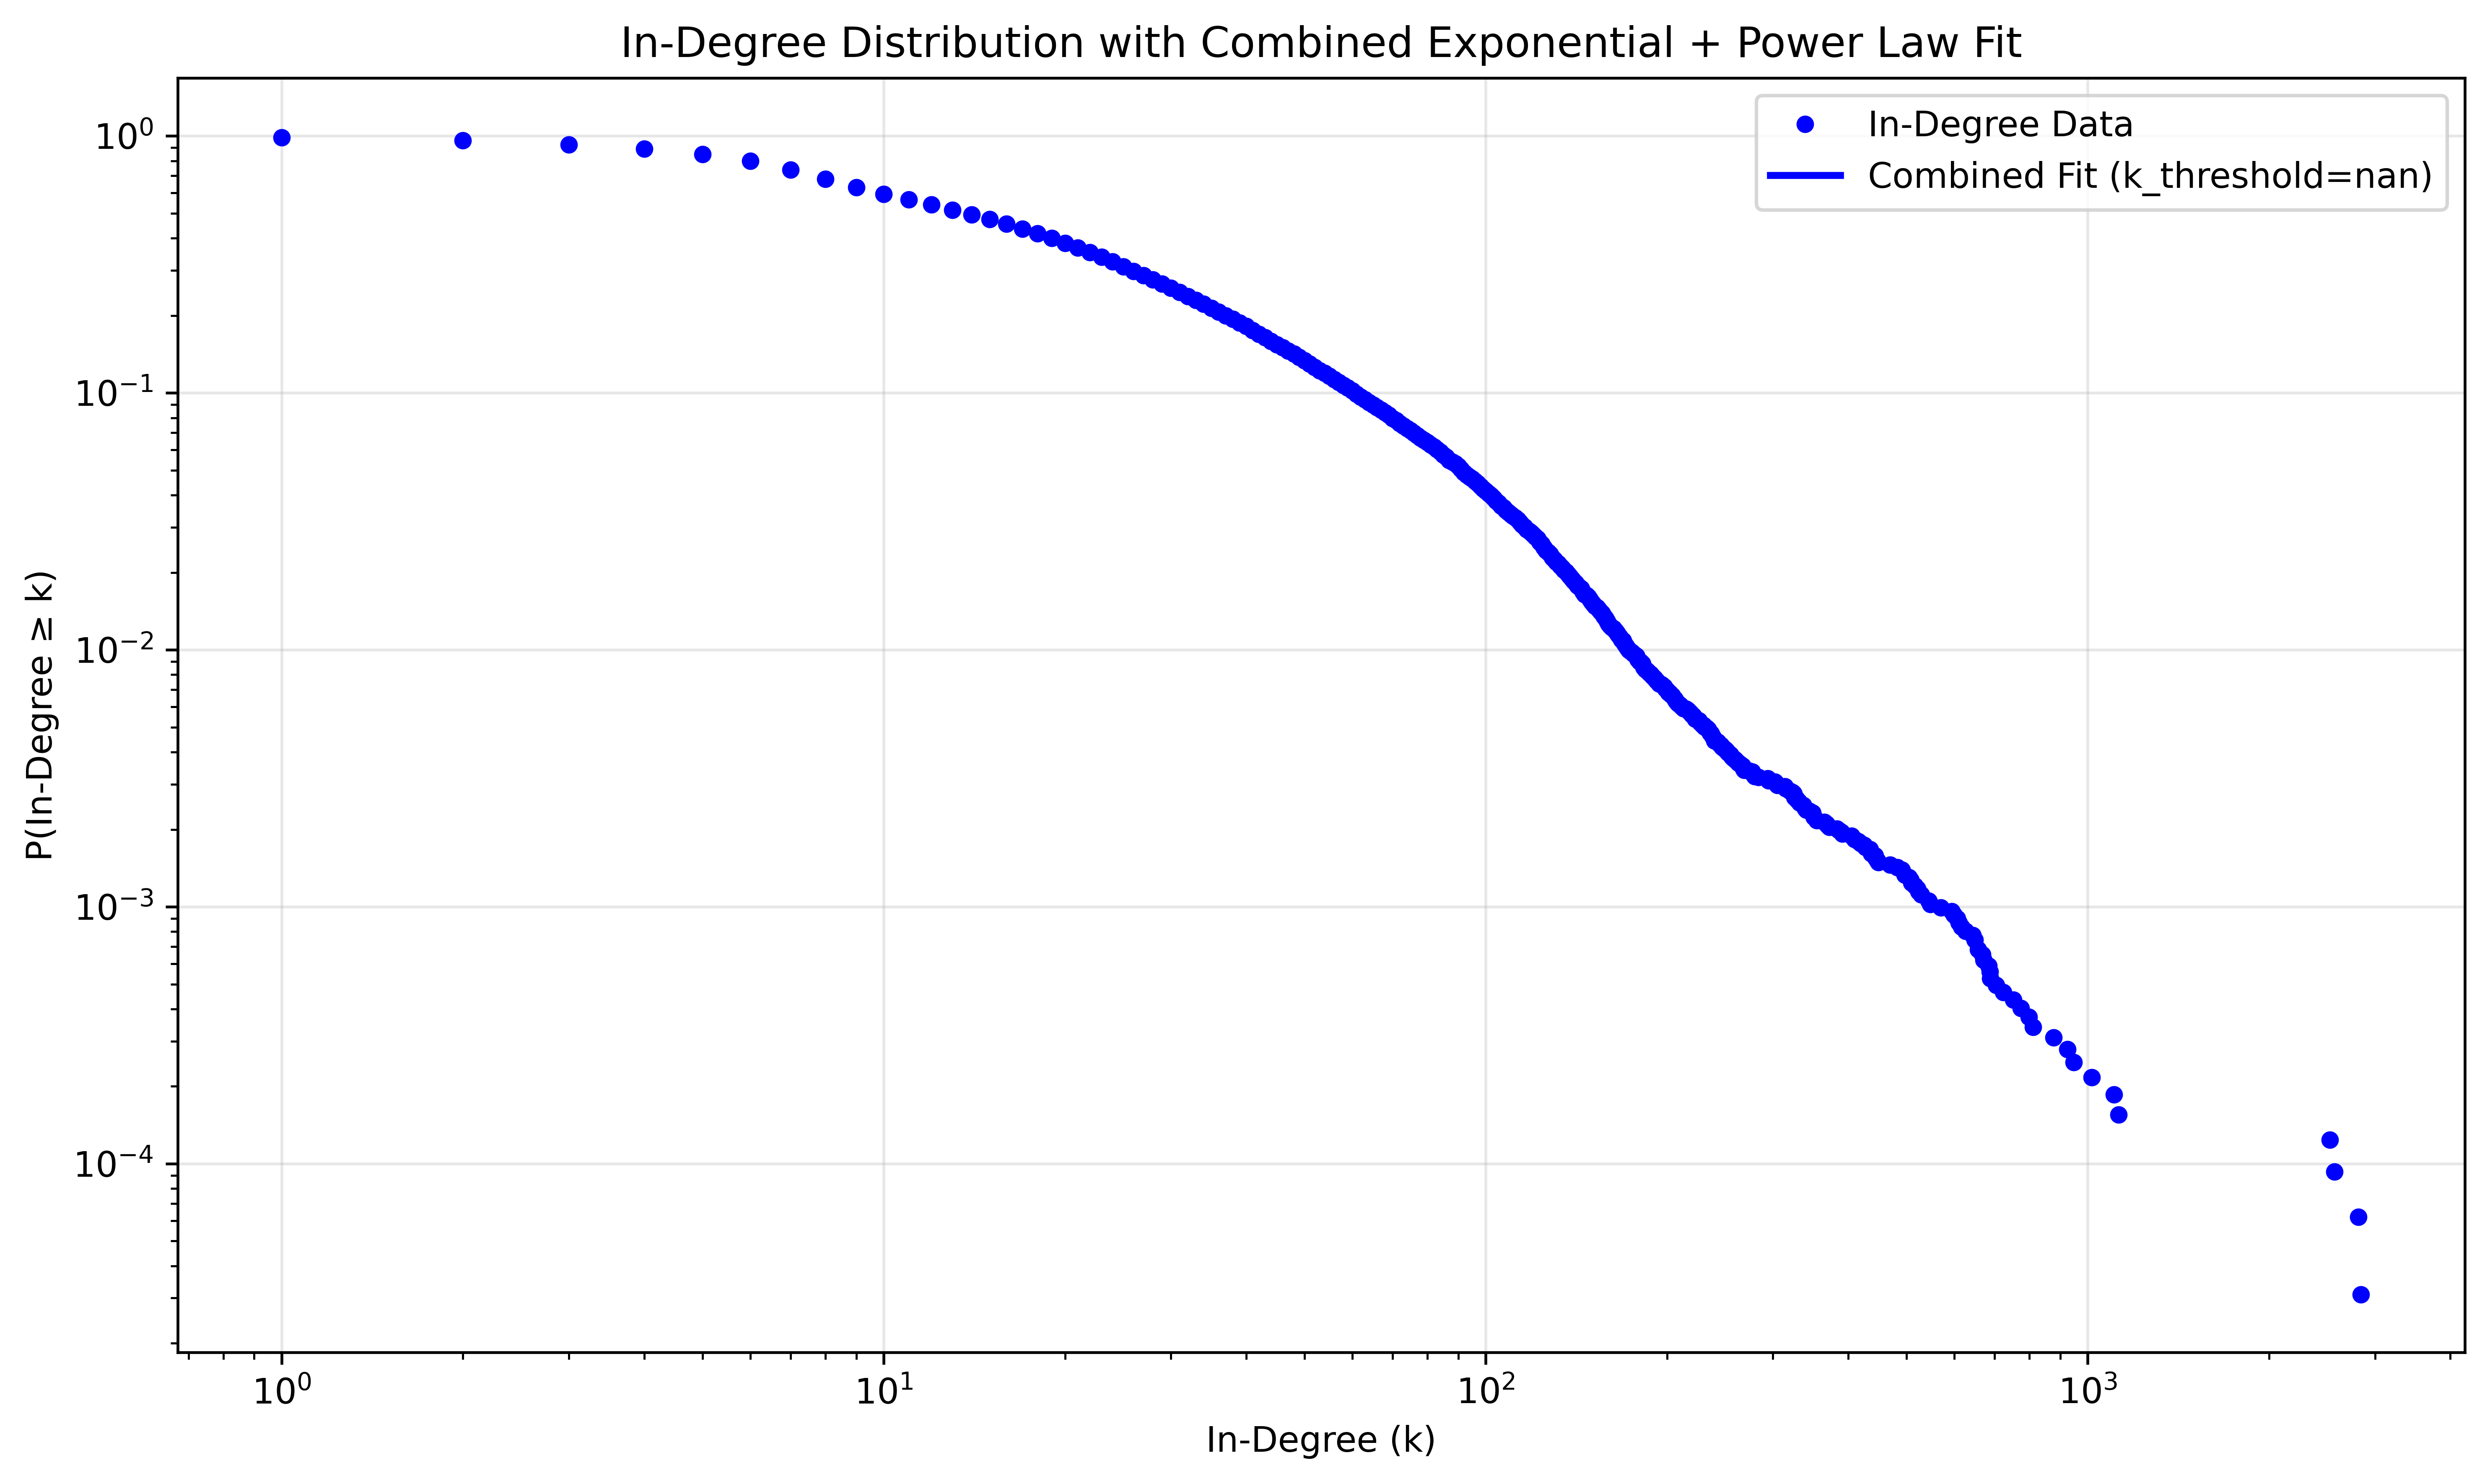

posx and posy should be finite values
posx and posy should be finite values


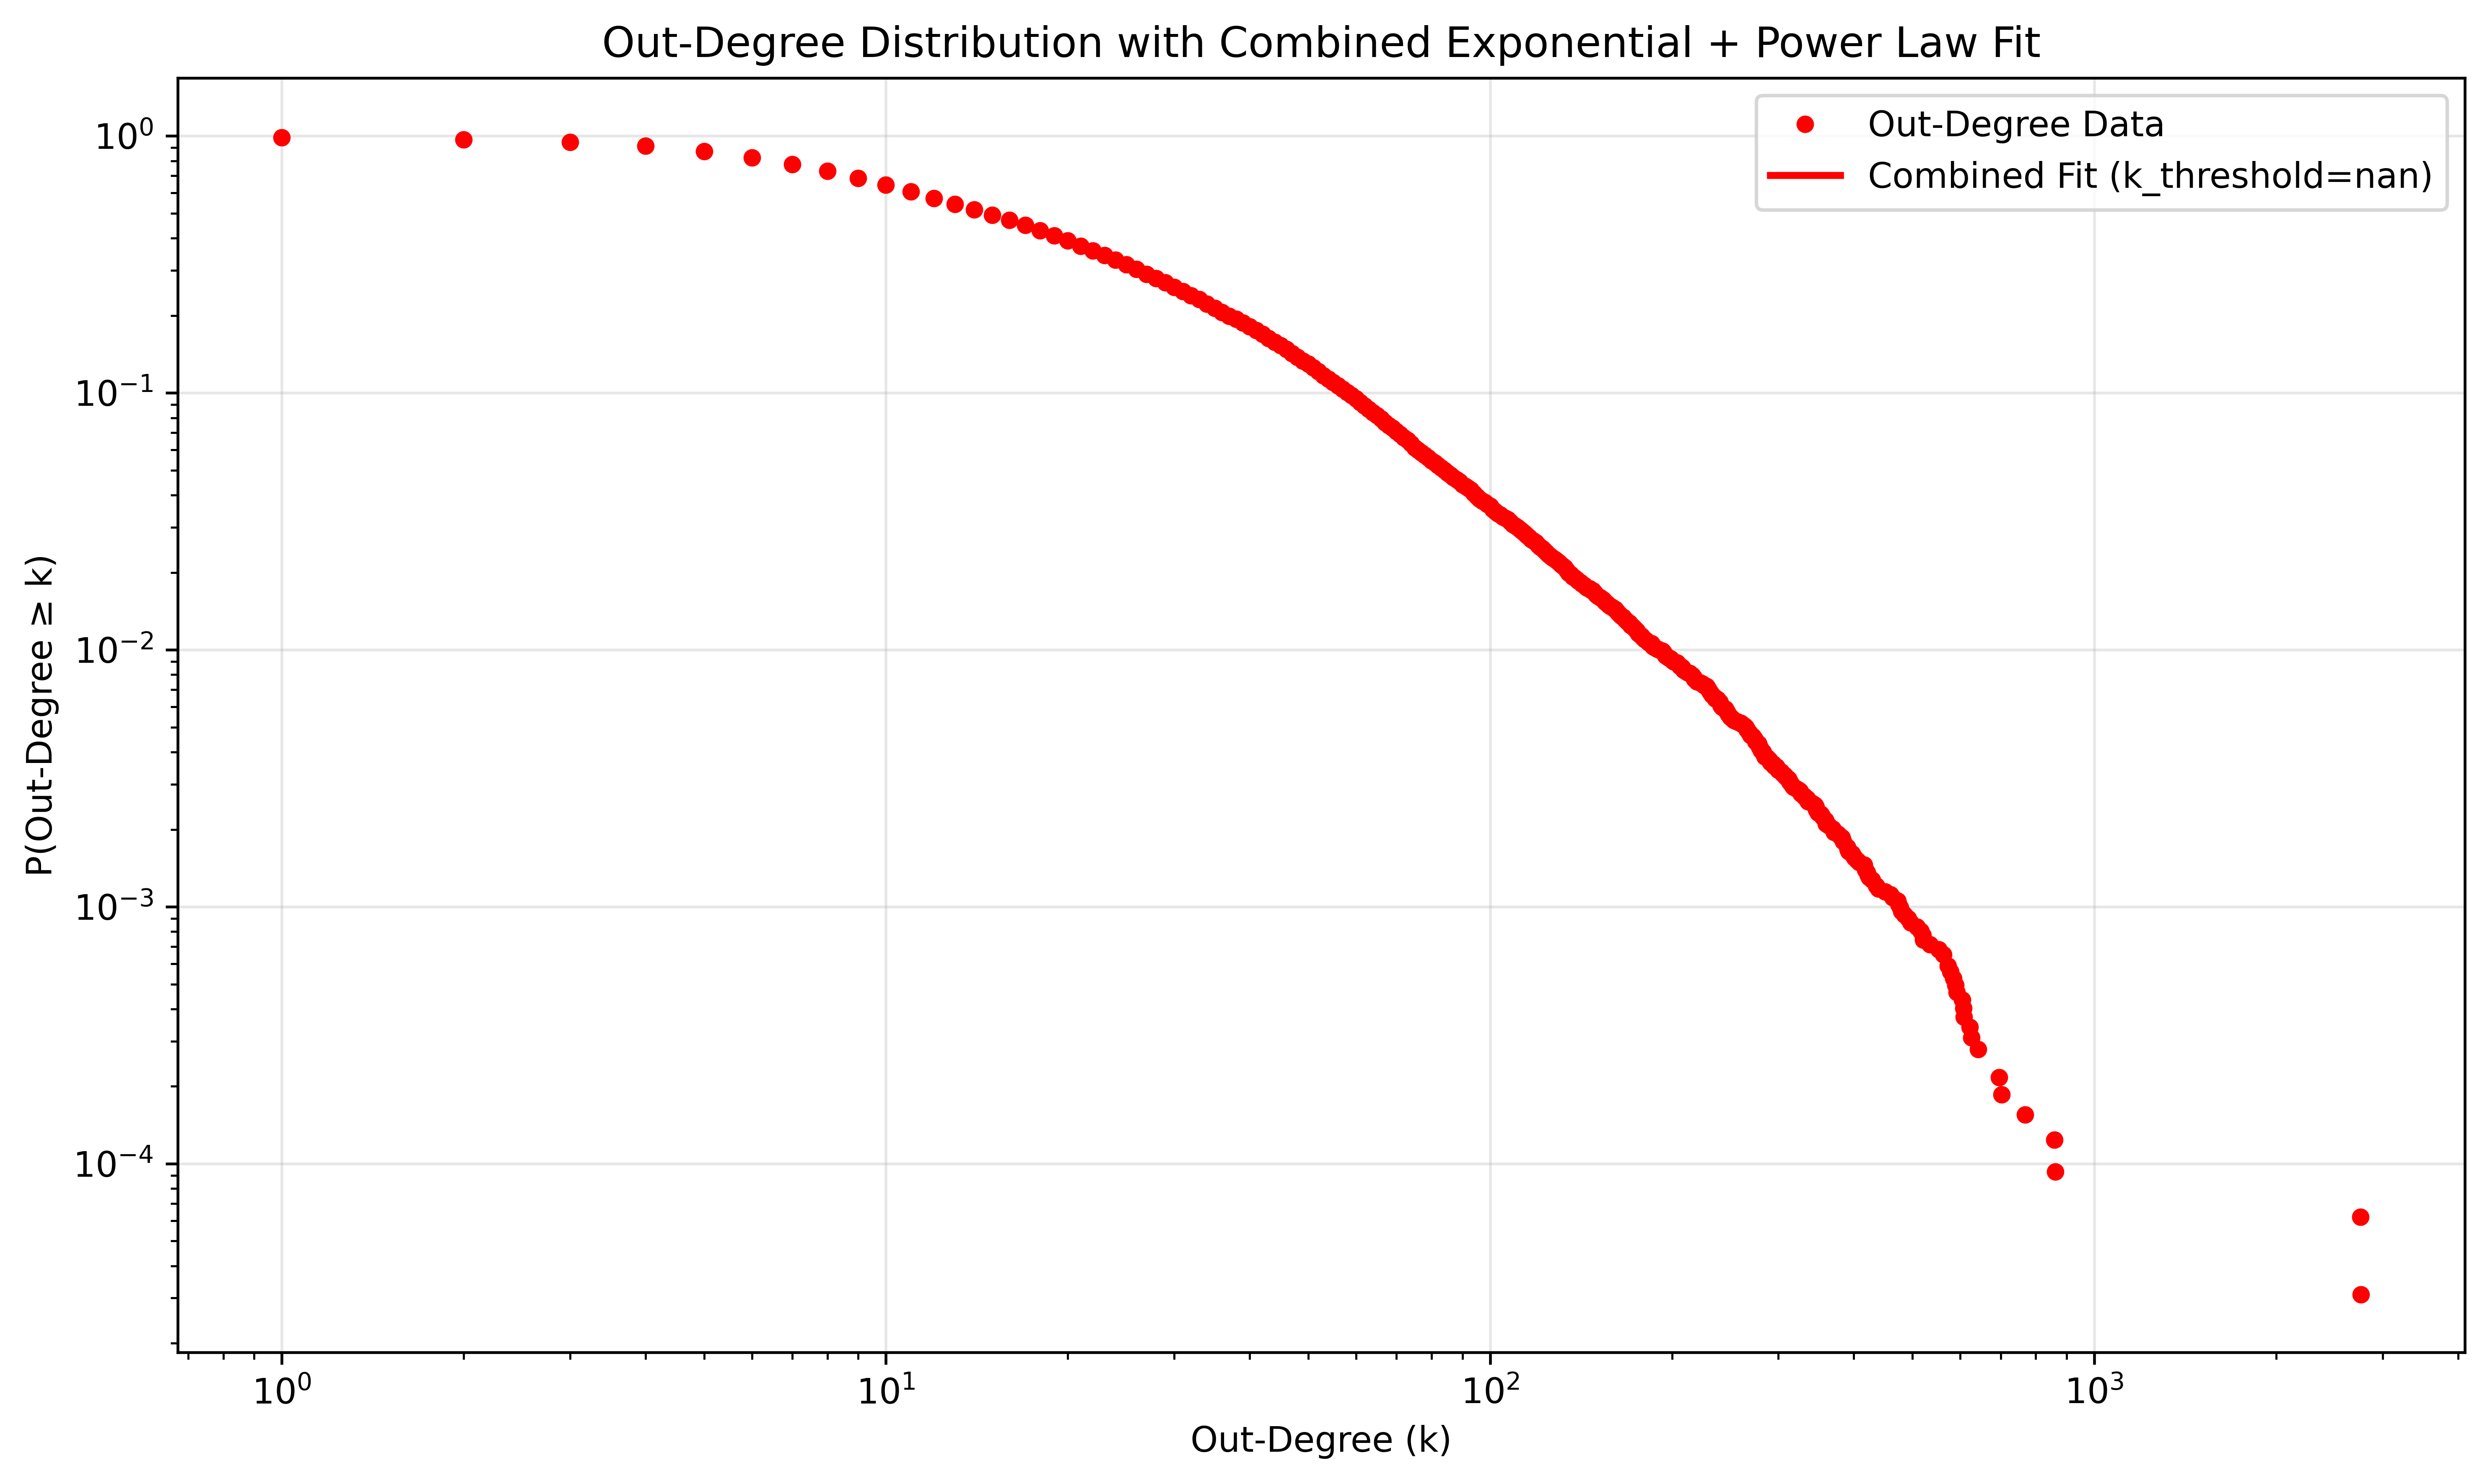

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import powerlaw
import os

print("Starting degree distribution fitting analysis...")

# Ensure output directory exists
if not os.path.exists("output"):
    os.makedirs("output")
    print("Created output directory")

# Function to fit power law: p(k) ~ k^(-alpha)
def power_law(x, alpha, const):
    return const * (x ** (-alpha))

# Function to fit exponential: p(k) ~ exp(-lambda * k)
def exponential(x, lambda_param, const):
    return const * np.exp(-lambda_param * x)

# Function for combined model: exponential for low degree, power law for high degree
def combined_model(x, k_threshold, exp_lambda, exp_const, power_alpha, power_const):
    y = np.zeros_like(x, dtype=float)
    # Exponential part for x <= k_threshold
    mask_low = x <= k_threshold
    y[mask_low] = exp_const * np.exp(-exp_lambda * x[mask_low])
    
    # Power law part for x > k_threshold
    mask_high = x > k_threshold
    y[mask_high] = power_const * (x[mask_high] ** (-power_alpha))
    
    # Ensure continuity at the threshold
    if np.any(mask_high) and np.any(mask_low):
        # Calculate value at threshold using exponential model
        threshold_value = exp_const * np.exp(-exp_lambda * k_threshold)
        # Adjust power law constant to match this value at threshold
        power_const_adjusted = threshold_value / (k_threshold ** (-power_alpha))
        # Update power law values
        y[mask_high] = power_const_adjusted * (x[mask_high] ** (-power_alpha))
    
    return y

# --------------------------------------------------
# 1. Power Law Fitting with Minimum Degree Threshold
# --------------------------------------------------
print("\n1. Fitting power laws with minimum degree thresholds...")

# Function to find optimal minimum degree threshold for power law using powerlaw package
def find_optimal_min_degree(degrees, degrees_count):
    # Create dataset for powerlaw package
    data = []
    for degree, count in zip(degrees, degrees_count):
        data.extend([degree] * count)
    
    print(f"  Creating powerlaw fit object with {len(data)} data points...")
    fit = powerlaw.Fit(data, discrete=True, verbose=False)
    print(f"  Optimal xmin: {fit.xmin}")
    print(f"  Power law alpha: {fit.alpha}")
    
    return fit

# Fit in-degree distribution
print("\nFitting in-degree distribution:")
in_degree_data = []
for degree, count in zip(in_x, in_y):
    in_degree_data.extend([degree] * count)

in_fit = find_optimal_min_degree(in_x, in_y)
in_xmin = in_fit.xmin
in_alpha = in_fit.alpha

# Fit out-degree distribution
print("\nFitting out-degree distribution:")
out_degree_data = []
for degree, count in zip(out_x, out_y):
    out_degree_data.extend([degree] * count)

out_fit = find_optimal_min_degree(out_x, out_y)
out_xmin = out_fit.xmin
out_alpha = out_fit.alpha

# Plot power law fits
print("\nPlotting power law fits...")

# In-degree power law fit plot
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo', markersize=4, label='In-Degree Data')

# Generate fitted curve
x_fit = np.logspace(np.log10(in_xmin), np.log10(max(in_x)), 100)
y_fit = (x_fit/in_xmin)**(1-in_alpha)  # CCDF of power law
plt.plot(x_fit, y_fit, 'b-', linewidth=2, 
         label=f'Power Law Fit (α={in_alpha:.2f}, xmin={in_xmin})')

plt.title('In-Degree Distribution with Power Law Fit')
plt.xlabel('In-Degree (k)')
plt.ylabel('P(In-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/in_degree_power_law_fit.png', dpi=600)
print("Saved in-degree power law fit plot")

# Out-degree power law fit plot
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(out_x, out_cumulative_y, 'ro', markersize=4, label='Out-Degree Data')

# Generate fitted curve
x_fit = np.logspace(np.log10(out_xmin), np.log10(max(out_x)), 100)
y_fit = (x_fit/out_xmin)**(1-out_alpha)  # CCDF of power law
plt.plot(x_fit, y_fit, 'r-', linewidth=2, 
         label=f'Power Law Fit (α={out_alpha:.2f}, xmin={out_xmin})')

plt.title('Out-Degree Distribution with Power Law Fit')
plt.xlabel('Out-Degree (k)')
plt.ylabel('P(Out-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/out_degree_power_law_fit.png', dpi=600)
print("Saved out-degree power law fit plot")

# --------------------------------------------------
# 2. Combined Exponential + Power Law Fitting
# --------------------------------------------------
print("\n2. Fitting combined exponential and power law models...")

# Function to fit the combined model
def fit_combined_model(x, y, p0=None):
    try:
        # Default initial parameters if none provided
        if p0 is None:
            # Guess threshold as 1/3 through the data on log scale
            min_x, max_x = min(x), max(x)
            k_threshold_guess = np.exp(np.log(min_x) + (np.log(max_x) - np.log(min_x)) / 3)
            # Initial guesses
            p0 = [
                k_threshold_guess,  # k_threshold
                0.1,                # exp_lambda
                y[0],               # exp_const
                2.0,                # power_alpha
                y[-1] * (x[-1] ** 2)  # power_const
            ]
        
        print(f"  Initial parameter guesses: {p0}")
        
        # Perform the fit
        params, cov = optimize.curve_fit(
            combined_model, x, y, p0=p0, 
            bounds=([1, 0.001, 0.001, 1.1, 0.001], 
                    [max(x)/2, 1.0, max(y)*10, 5.0, max(y)*10]),
            maxfev=10000
        )
        
        print(f"  Fitted parameters: {params}")
        return params
    except Exception as e:
        print(f"  Error fitting combined model: {e}")
        return p0  # Return initial guesses if fit fails

# Fit in-degree distribution with combined model
print("\nFitting in-degree distribution with combined model:")
in_combined_params = fit_combined_model(in_x, in_cumulative_y)
in_k_threshold, in_exp_lambda, in_exp_const, in_power_alpha, in_power_const = in_combined_params

# Fit out-degree distribution with combined model
print("\nFitting out-degree distribution with combined model:")
out_combined_params = fit_combined_model(out_x, out_cumulative_y)
out_k_threshold, out_exp_lambda, out_exp_const, out_power_alpha, out_power_const = out_combined_params

# Plot combined model fits
print("\nPlotting combined model fits...")

# In-degree combined model fit plot
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo', markersize=4, label='In-Degree Data')

# Generate smooth curves for plotting
x_smooth = np.logspace(np.log10(min(in_x)), np.log10(max(in_x)), 1000)
y_combined = combined_model(x_smooth, *in_combined_params)

# Highlight the two regimes
plt.plot(x_smooth, y_combined, 'b-', linewidth=2, 
         label=f'Combined Fit (k_threshold={in_k_threshold:.1f})')

# Mark threshold
plt.axvline(x=in_k_threshold, color='gray', linestyle='--', alpha=0.7)
plt.text(in_k_threshold*1.1, max(in_cumulative_y)/2, f'Threshold\nk={in_k_threshold:.1f}', 
         horizontalalignment='left', verticalalignment='center')

plt.title('In-Degree Distribution with Combined Exponential + Power Law Fit')
plt.xlabel('In-Degree (k)')
plt.ylabel('P(In-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/in_degree_combined_fit.png', dpi=600)
print("Saved in-degree combined model fit plot")

# Out-degree combined model fit plot
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(out_x, out_cumulative_y, 'ro', markersize=4, label='Out-Degree Data')

# Generate smooth curves for plotting
x_smooth = np.logspace(np.log10(min(out_x)), np.log10(max(out_x)), 1000)
y_combined = combined_model(x_smooth, *out_combined_params)

# Highlight the two regimes
plt.plot(x_smooth, y_combined, 'r-', linewidth=2, 
         label=f'Combined Fit (k_threshold={out_k_threshold:.1f})')

# Mark threshold
plt.axvline(x=out_k_threshold, color='gray', linestyle='--', alpha=0.7)
plt.text(out_k_threshold*1.1, max(out_cumulative_y)/2, f'Threshold\nk={out_k_threshold:.1f}', 
         horizontalalignment='left', verticalalignment='center')

plt.title('Out-Degree Distribution with Combined Exponential + Power Law Fit')
plt.xlabel('Out-Degree (k)')
plt.ylabel('P(Out-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('output/out_degree_combined_fit.png', dpi=600)
print("Saved out-degree combined model fit plot")

# Print summary of results
print("\nSummary of Fitting Results:")
print("-" * 50)
print("Power Law Fits:")
print(f"In-degree:  xmin={in_xmin}, alpha={in_alpha:.3f}")
print(f"Out-degree: xmin={out_xmin}, alpha={out_alpha:.3f}")
print("\nCombined Model Fits:")
print(f"In-degree:  Threshold={in_k_threshold:.2f}, Exp_lambda={in_exp_lambda:.3f}, Power_alpha={in_power_alpha:.3f}")
print(f"Out-degree: Threshold={out_k_threshold:.2f}, Exp_lambda={out_exp_lambda:.3f}, Power_alpha={out_power_alpha:.3f}")
print("-" * 50)

print("Degree distribution fitting analysis complete!")

Starting clustering coefficient analysis...
Calculating clustering coefficients...
Calculated clustering coefficients for 32272 nodes
Min clustering: 0
Max clustering: 1.0
Average clustering: 0.1583
Number of nodes with clustering = 0: 833
Number of nodes with clustering = 1: 52
Plotting histogram of clustering coefficients...
Saved clustering coefficient histogram
Plotting histogram of directed clustering coefficients...
Saved directed clustering coefficient histogram
Creating combined histogram...
Saved combined clustering histogram
Calculating and plotting cumulative distribution...
Saved clustering coefficient cumulative distribution
Clustering coefficient analysis complete!


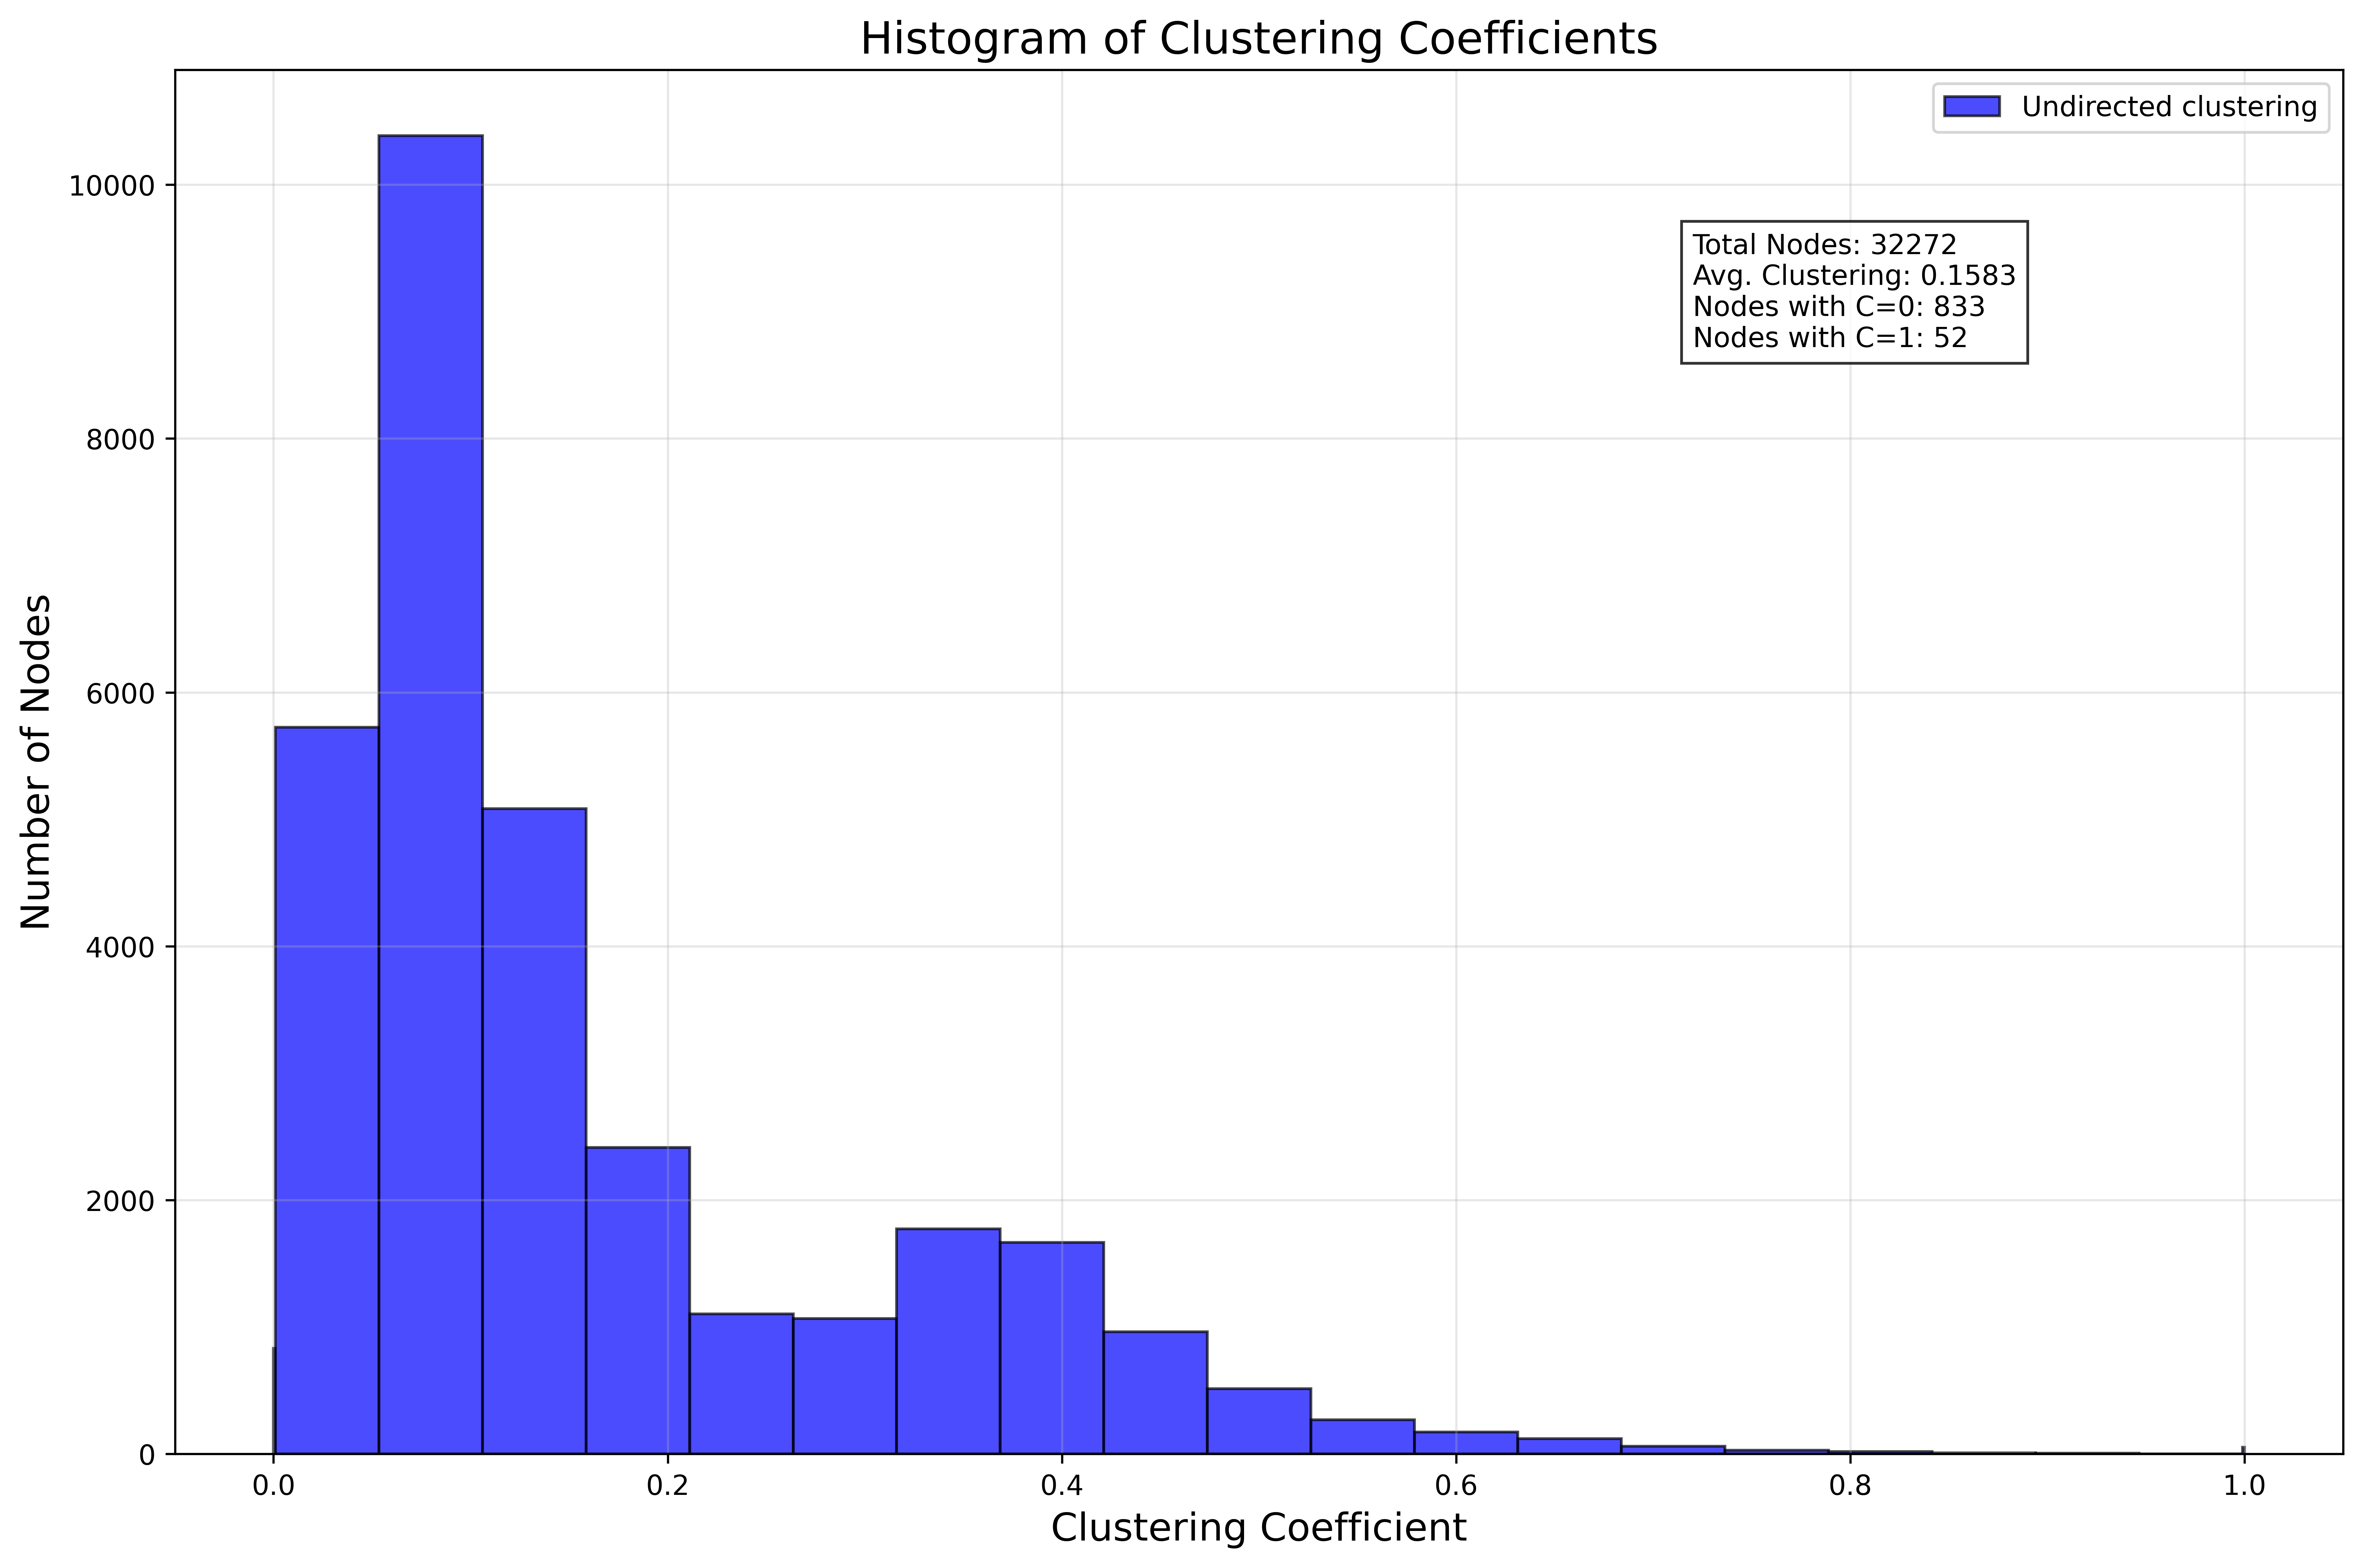

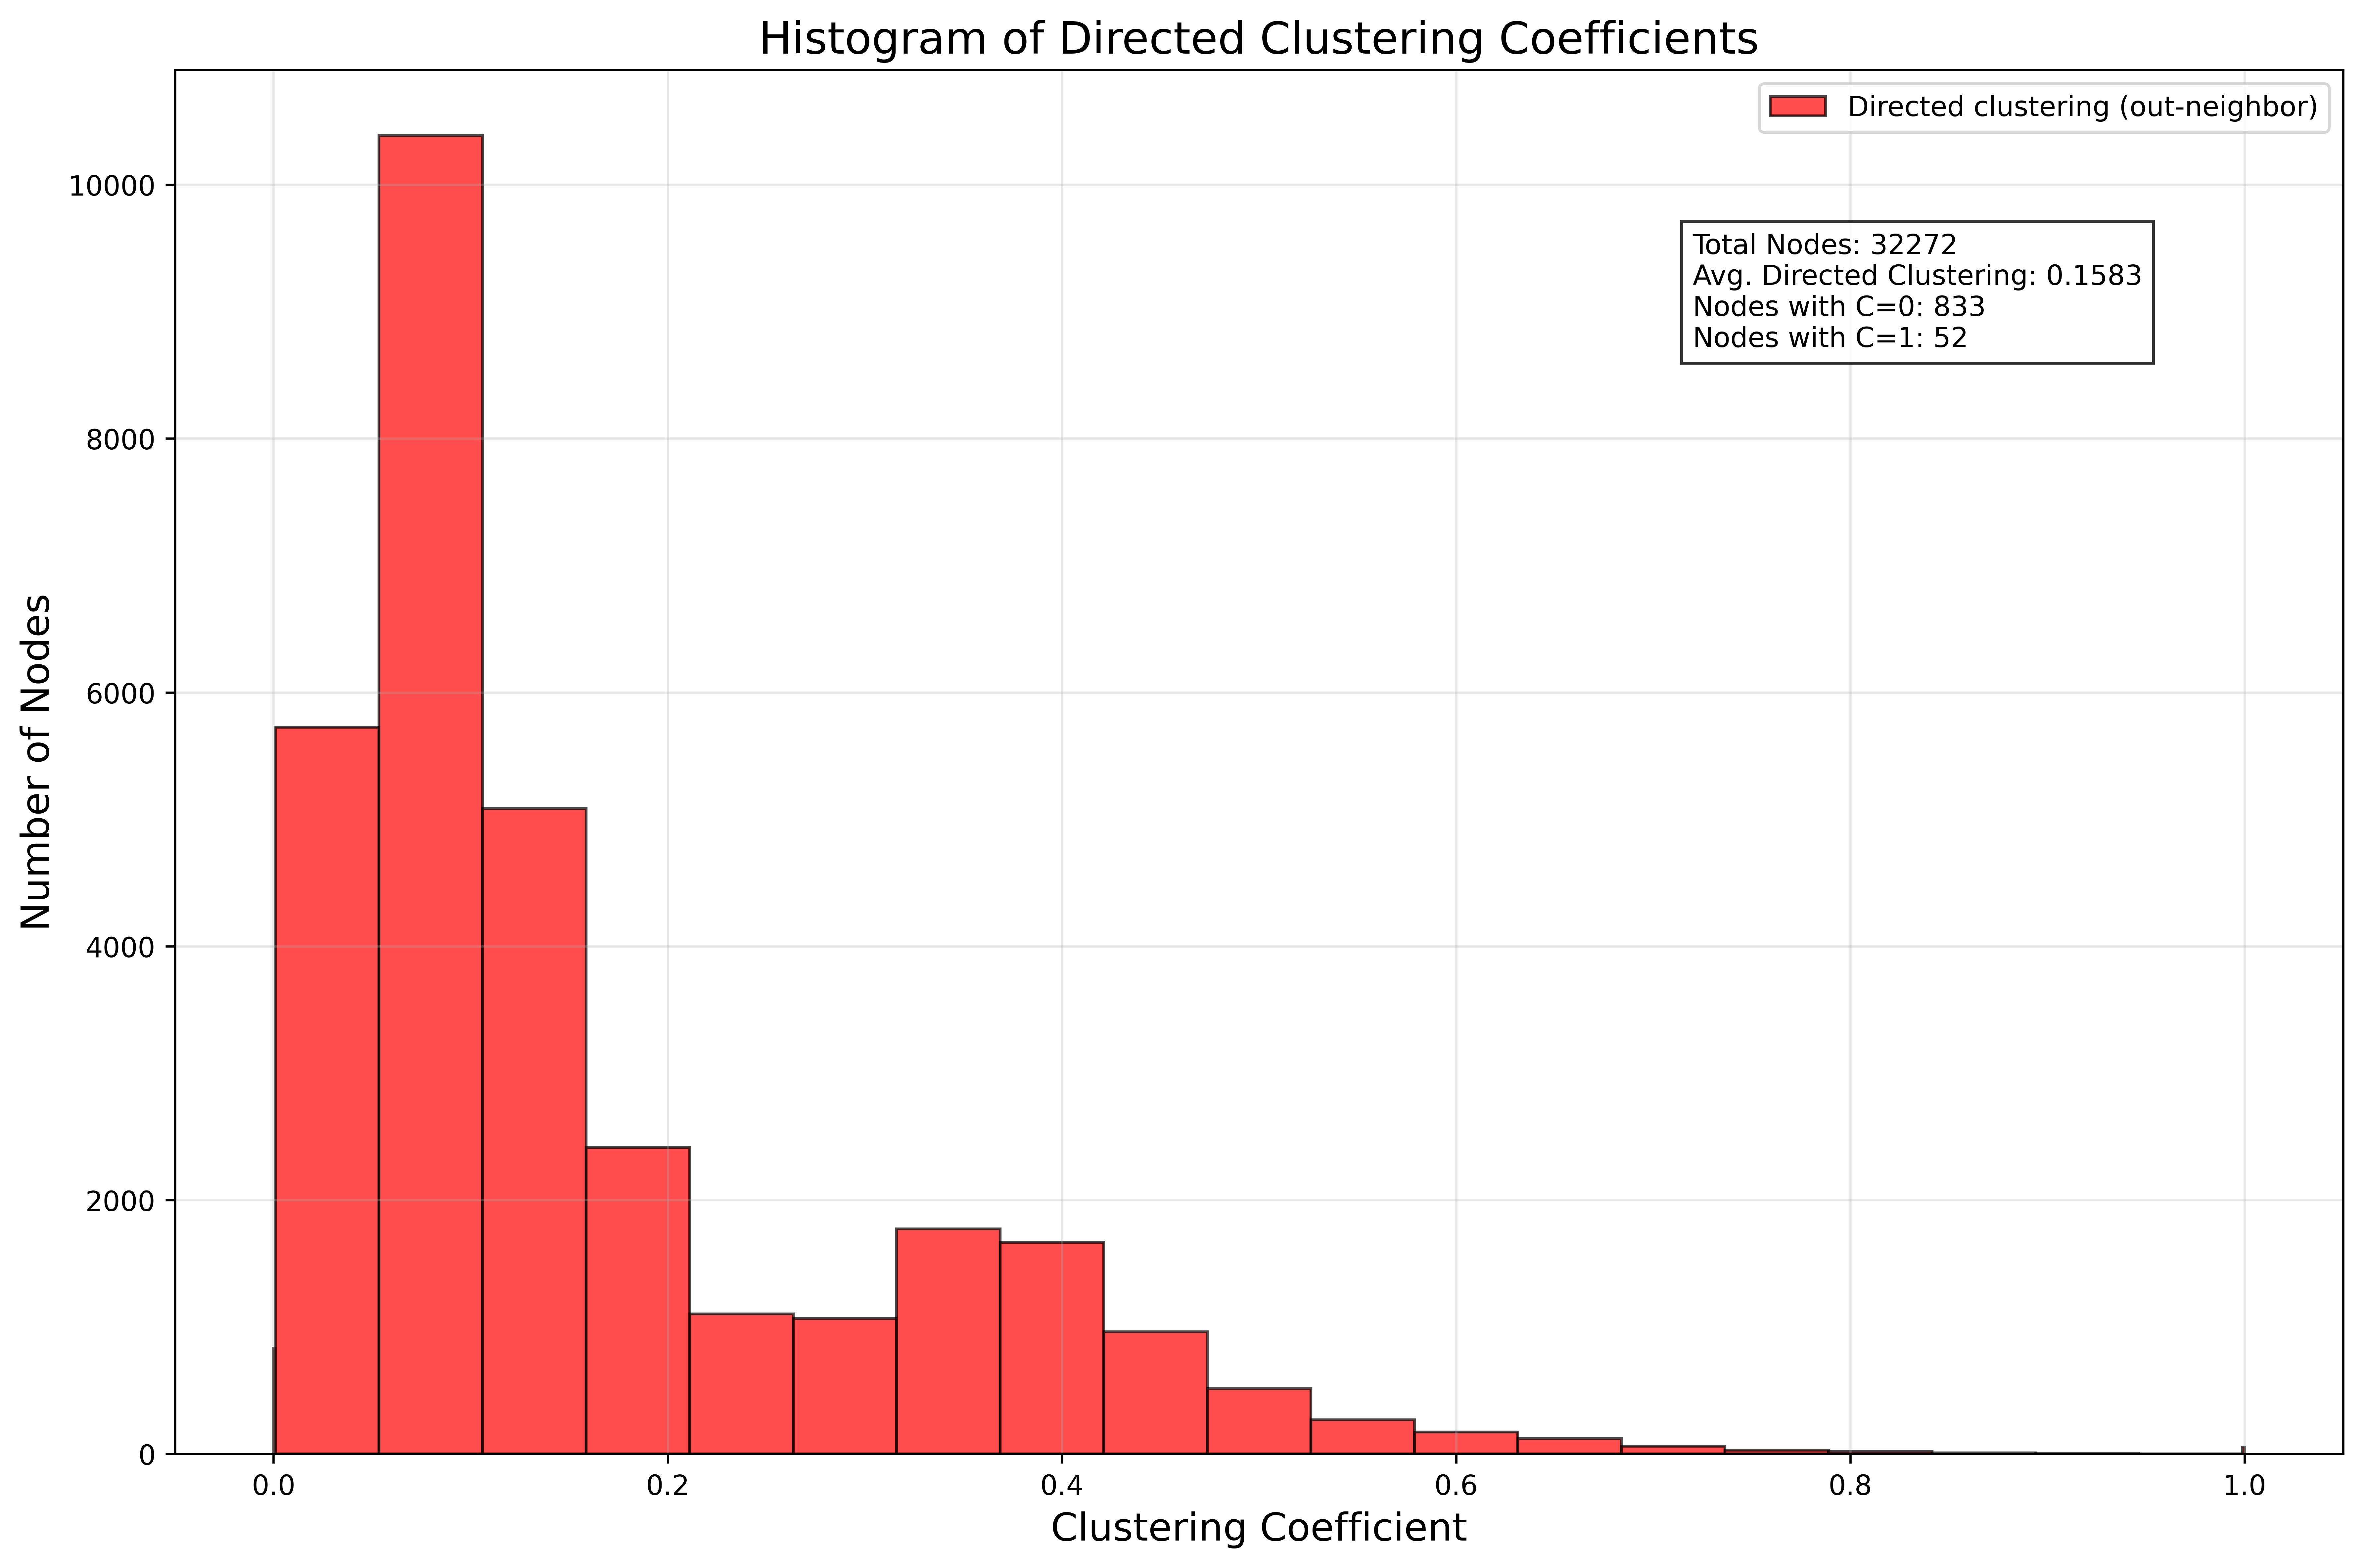

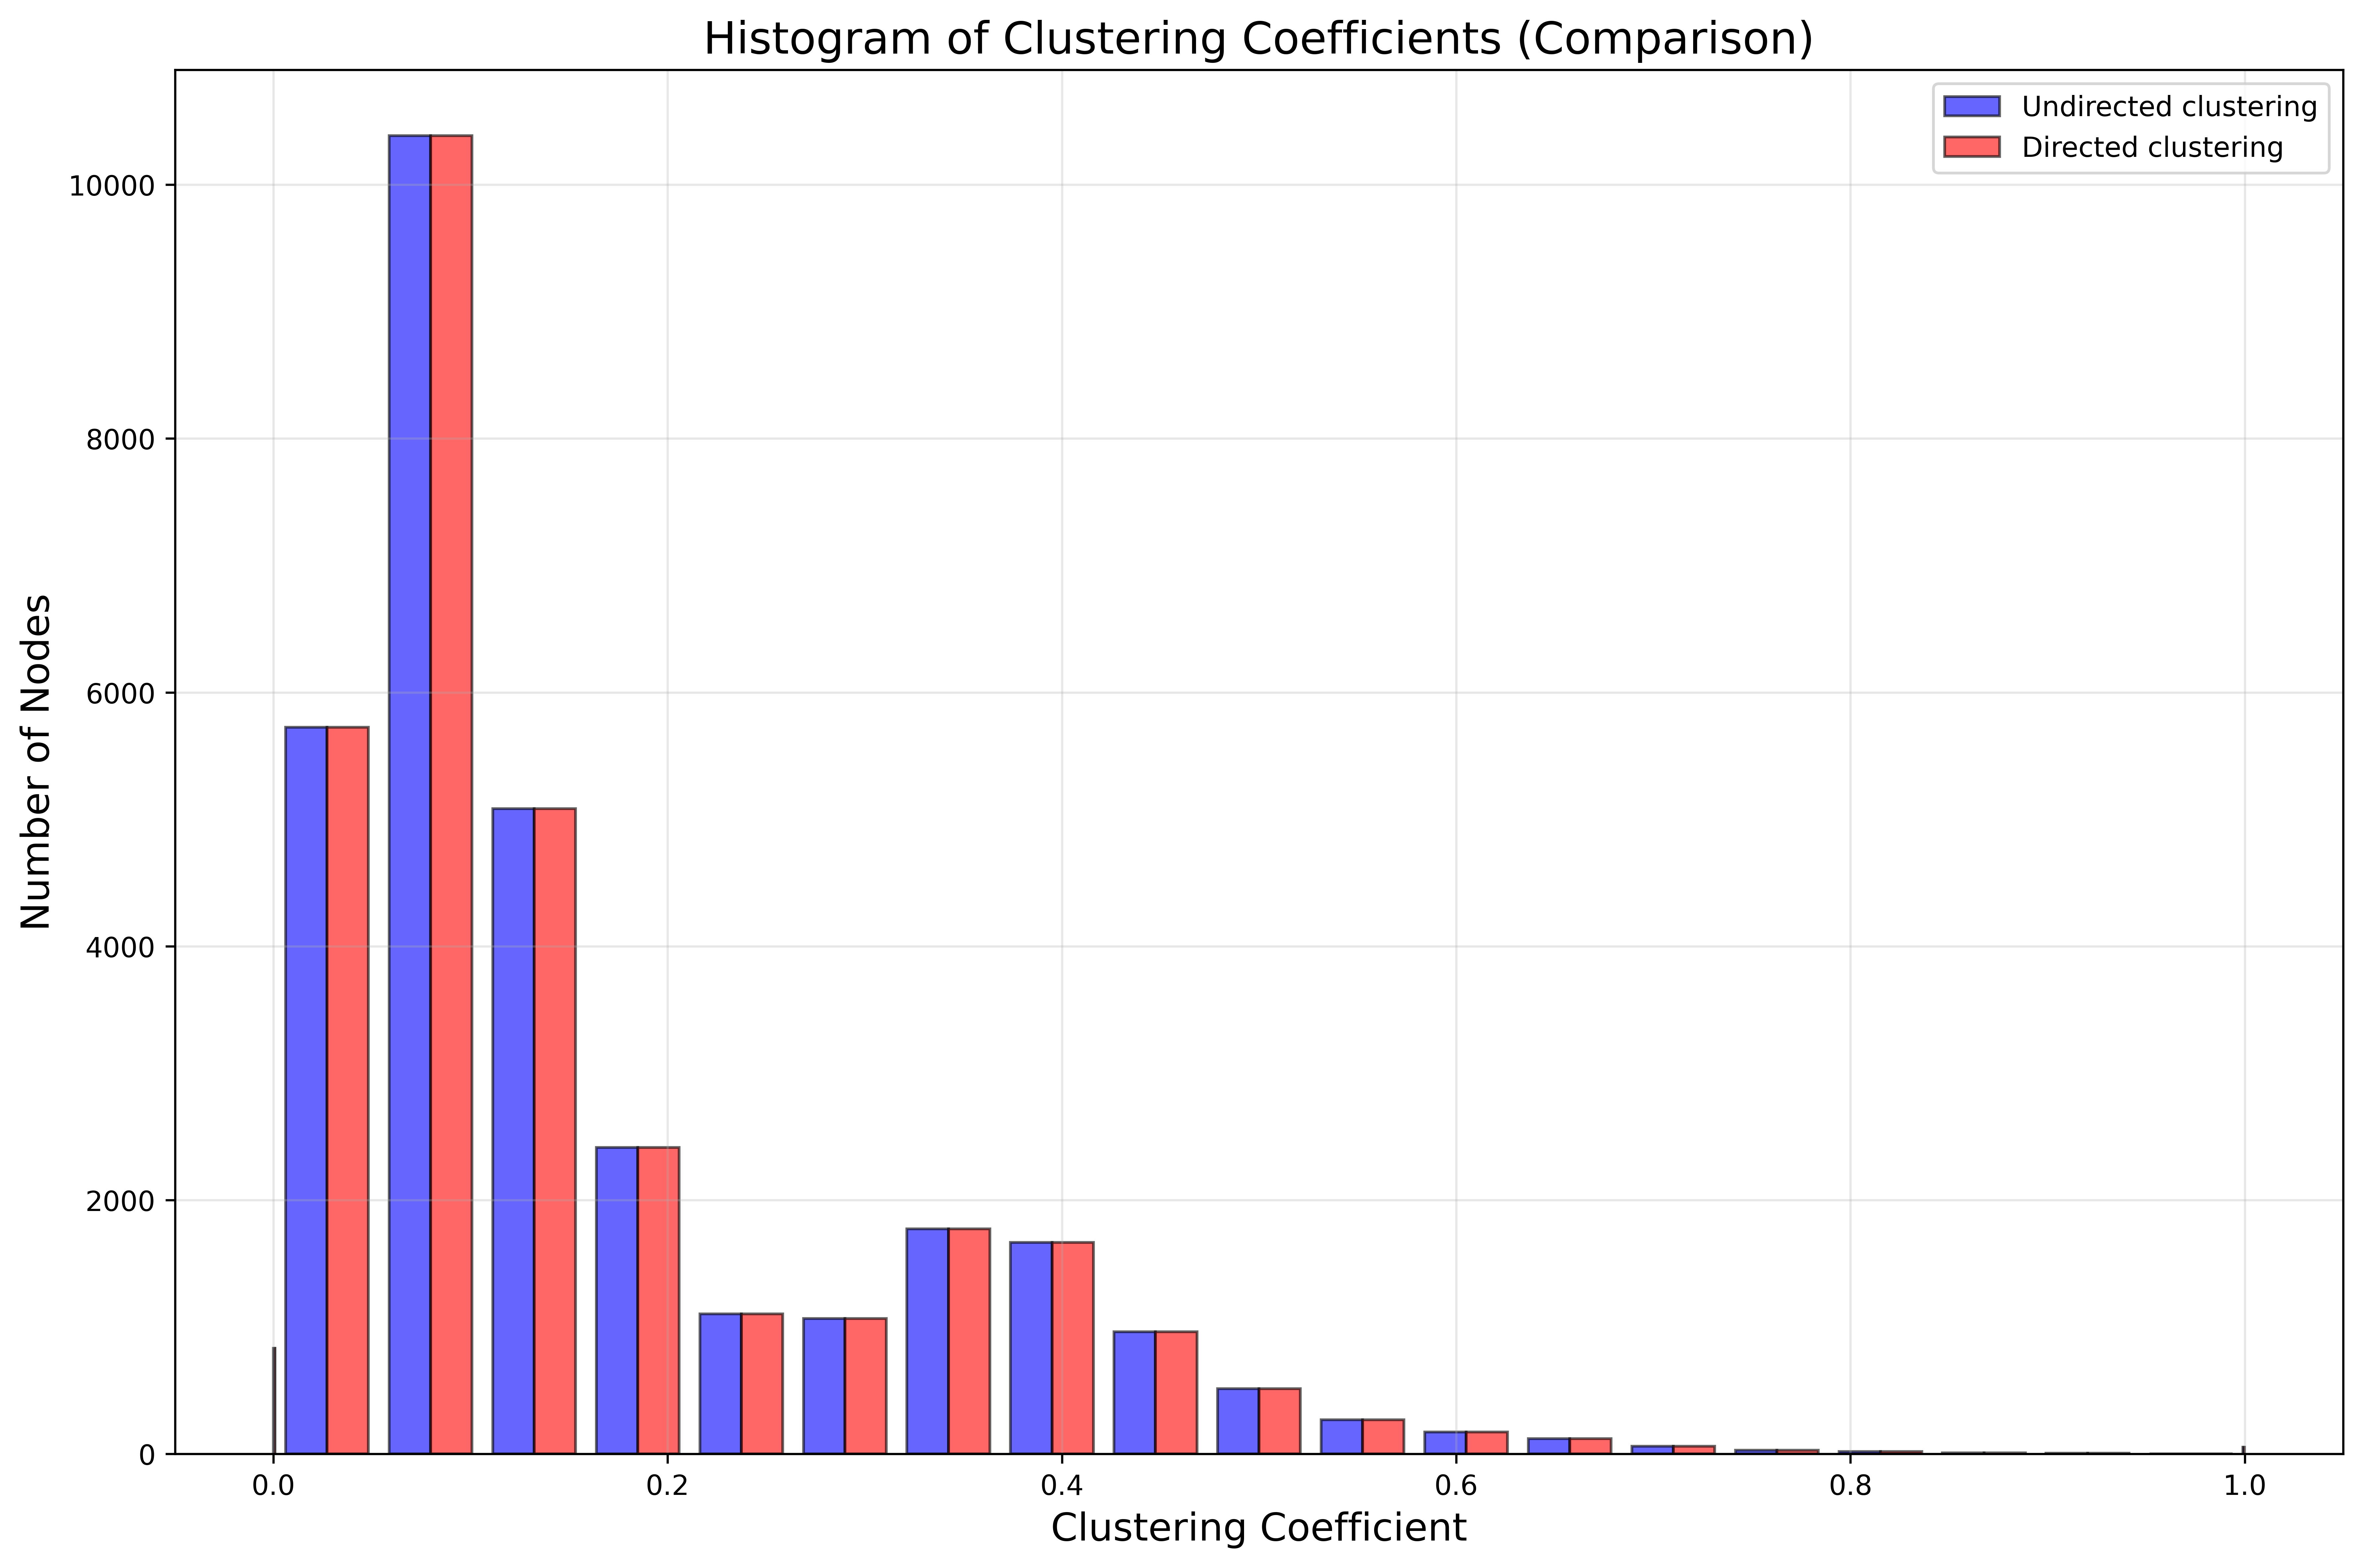

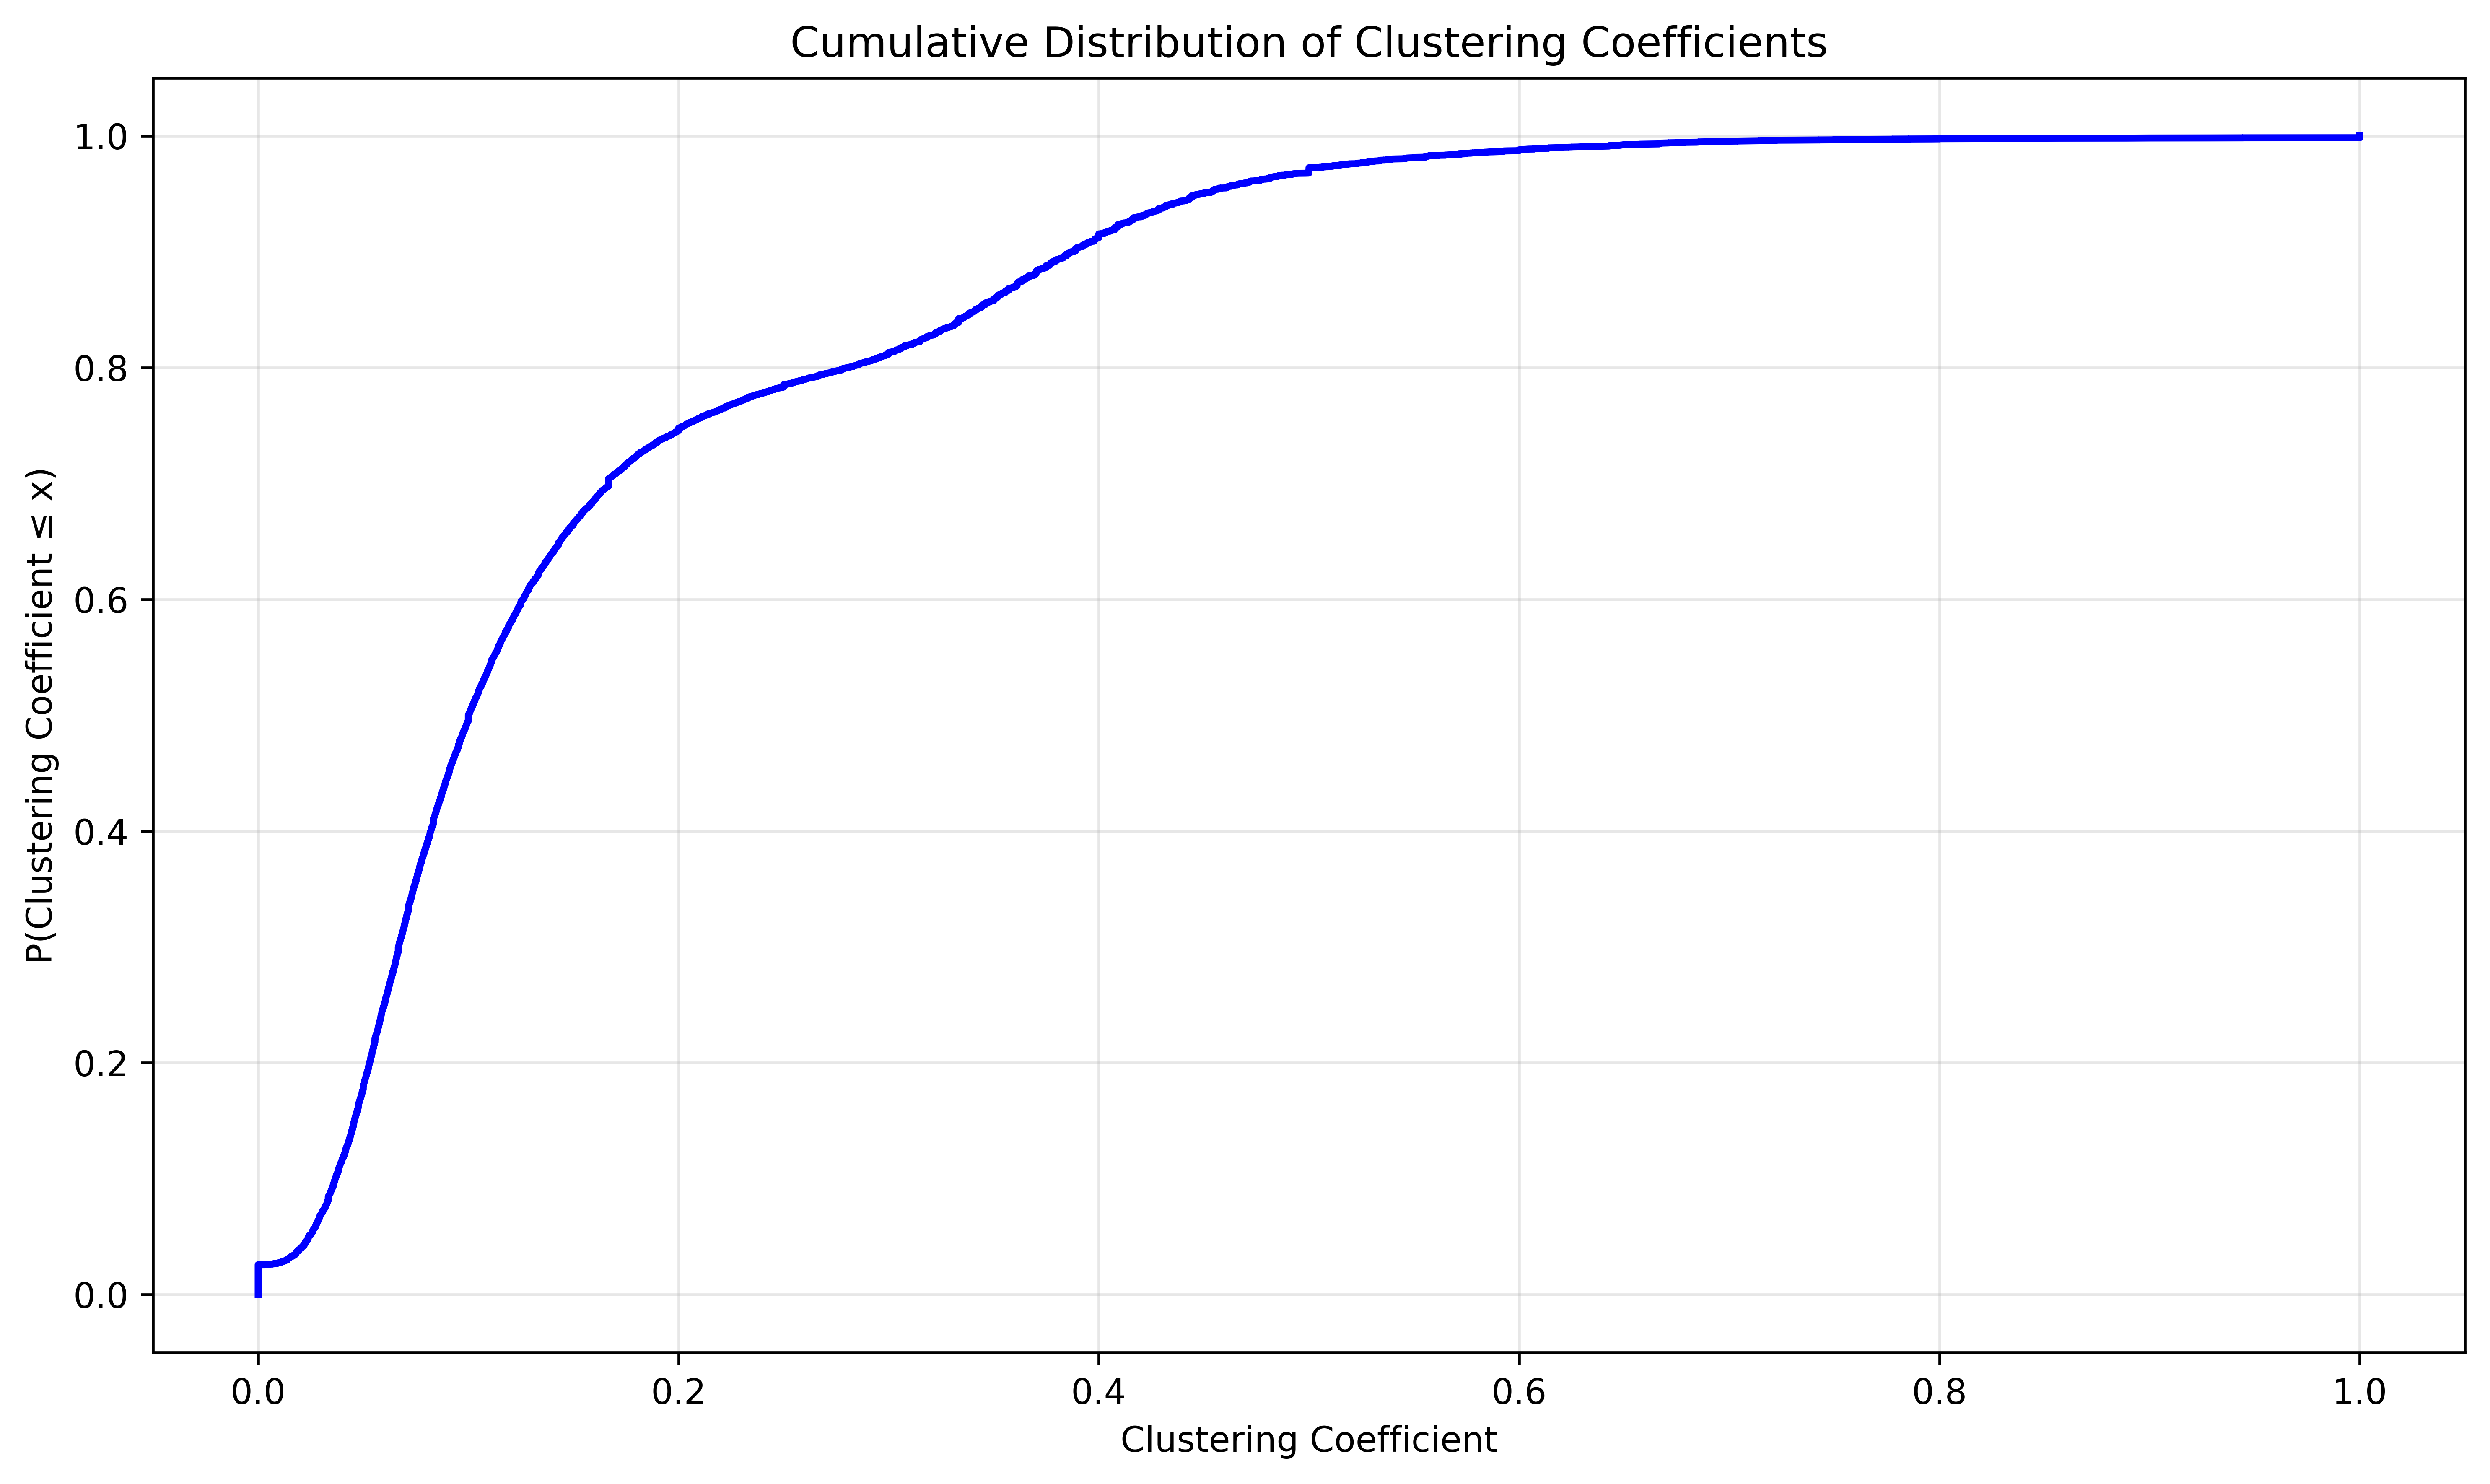

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

print("Starting clustering coefficient analysis...")

# Ensure output directory exists
if not os.path.exists("output"):
    os.makedirs("output")
    print("Created output directory")

# Calculate clustering coefficients
# For directed graphs, we need to be specific about which type to use
print("Calculating clustering coefficients...")
# Calculate clustering for each node
clustering = nx.clustering(G)  # This calculates undirected clustering

# For directed graphs, we can also check directed clustering variants
directed_clustering = nx.clustering(G, None, 'dot')  # Directed variant: out-neighbor subgraphs

print(f"Calculated clustering coefficients for {len(clustering)} nodes")
print(f"Min clustering: {min(clustering.values())}")
print(f"Max clustering: {max(clustering.values())}")
print(f"Average clustering: {sum(clustering.values()) / len(clustering):.4f}")

# Convert dictionary to list for histogram
clustering_values = list(clustering.values())
directed_clustering_values = list(directed_clustering.values())

print(f"Number of nodes with clustering = 0: {sum(1 for c in clustering_values if c == 0)}")
print(f"Number of nodes with clustering = 1: {sum(1 for c in clustering_values if c == 1)}")

# Plot histogram of clustering coefficients
print("Plotting histogram of clustering coefficients...")
plt.figure(figsize=(12, 8), dpi=600)

# Create bins that handle the distribution well
# Often clustering has many 0s and 1s, with fewer values in between
# We'll use a combination of linear bins and specific bins for 0 and 1
bins = np.concatenate(([0], np.linspace(0.001, 0.999, 20), [1]))

plt.hist(clustering_values, bins=bins, alpha=0.7, color='blue', 
         edgecolor='black', label='Undirected clustering')
         
plt.title('Histogram of Clustering Coefficients', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Add some statistics as text on the plot
stats_text = (
    f"Total Nodes: {len(clustering)}\n"
    f"Avg. Clustering: {sum(clustering_values) / len(clustering_values):.4f}\n"
    f"Nodes with C=0: {sum(1 for c in clustering_values if c == 0)}\n"
    f"Nodes with C=1: {sum(1 for c in clustering_values if c == 1)}"
)
plt.text(0.7, 0.8, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram")

# Also plot directed clustering for comparison
print("Plotting histogram of directed clustering coefficients...")
plt.figure(figsize=(12, 8), dpi=600)

plt.hist(directed_clustering_values, bins=bins, alpha=0.7, color='red', 
         edgecolor='black', label='Directed clustering (out-neighbor)')
         
plt.title('Histogram of Directed Clustering Coefficients', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Add directed statistics
dir_stats_text = (
    f"Total Nodes: {len(directed_clustering)}\n"
    f"Avg. Directed Clustering: {sum(directed_clustering_values) / len(directed_clustering_values):.4f}\n"
    f"Nodes with C=0: {sum(1 for c in directed_clustering_values if c == 0)}\n"
    f"Nodes with C=1: {sum(1 for c in directed_clustering_values if c == 1)}"
)
plt.text(0.7, 0.8, dir_stats_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/directed_clustering_coefficient_histogram.png', dpi=600)
print("Saved directed clustering coefficient histogram")

# Combined plot
print("Creating combined histogram...")
plt.figure(figsize=(12, 8), dpi=600)

plt.hist([clustering_values, directed_clustering_values], bins=bins, alpha=0.6, 
         color=['blue', 'red'], edgecolor='black', 
         label=['Undirected clustering', 'Directed clustering'])
         
plt.title('Histogram of Clustering Coefficients (Comparison)', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('output/combined_clustering_histogram.png', dpi=600)
print("Saved combined clustering histogram")

# Calculate and plot cumulative distribution of clustering coefficients
print("Calculating and plotting cumulative distribution...")
clustering_sorted = np.sort(clustering_values)
p = 1. * np.arange(len(clustering_sorted)) / (len(clustering_sorted) - 1)

plt.figure(figsize=(10, 6), dpi=600)
plt.plot(clustering_sorted, p, 'b-', linewidth=2)
plt.title('Cumulative Distribution of Clustering Coefficients')
plt.xlabel('Clustering Coefficient')
plt.ylabel('P(Clustering Coefficient ≤ x)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/clustering_coefficient_cdf.png', dpi=600)
print("Saved clustering coefficient cumulative distribution")

print("Clustering coefficient analysis complete!")

Starting clustering coefficient analysis...
Reading CSV files...
Creating directed graph...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Adding nodes with metadata...
Adding edges...
Added 32272 nodes to the graph
Added 849981 edges to the graph
Calculating clustering coefficients...
Calculated clustering coefficients for 32272 nodes
Min clustering: 0
Max clustering: 1.0
Average clustering: 0.1583
Number of nodes with clustering = 0: 833
Number of nodes with clustering = 1: 52

Detailed Statistical Analysis of Clustering Coefficients:
Mean clustering coefficient: 0.1583
Median clustering coefficient: 0.1000
Standard deviation: 0.1460
Skewness: 1.6447
Kurtosis: 2.9943
1st quartile (Q1): 0.0600
3rd quartile (Q3): 0.2030
Interquartile range (IQR): 0.1430

Peaks detected in distribution:
Peak 1: Clustering coefficient 0.0625 (frequency: 5792)
Peak 2: Clustering coefficient 0.3625 (frequency: 880)
Peak 3: Clustering coefficient 0.5125 (frequency: 282)
Plotting enhanced histogram

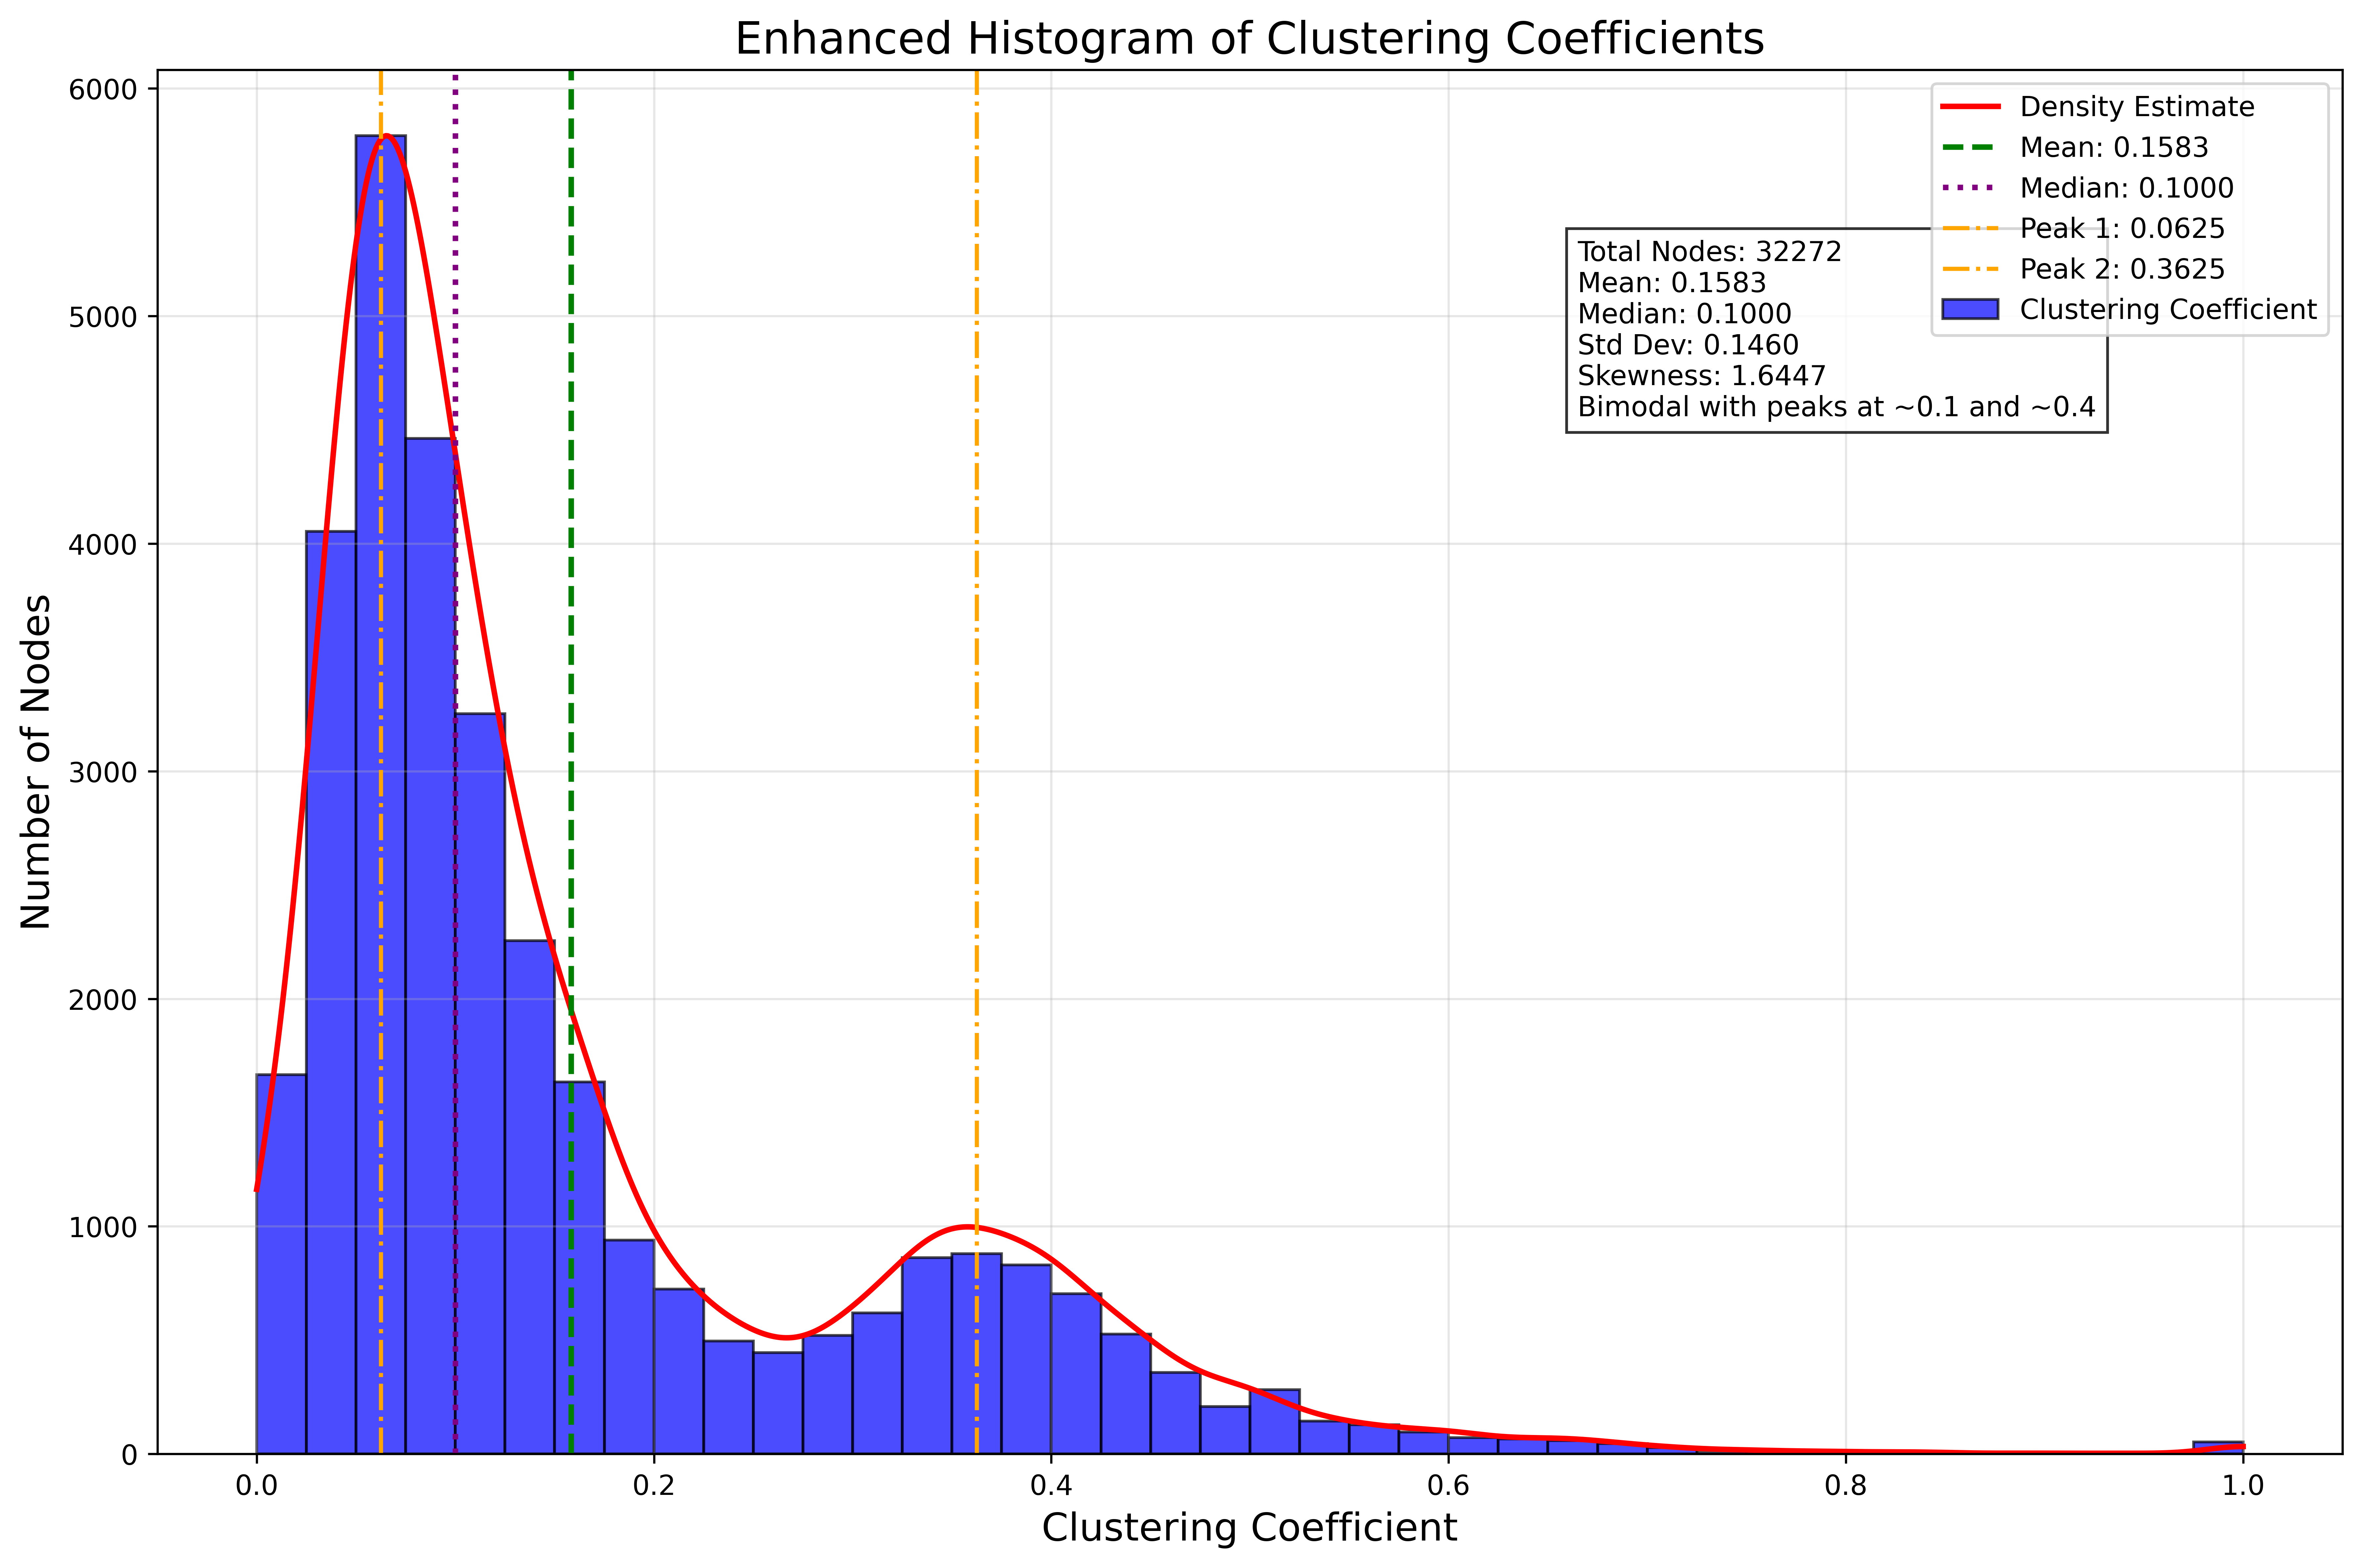

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats
import pandas as pd

print("Starting clustering coefficient analysis...")

# Reusing the graph from the previous analysis
print("Reading CSV files...")
# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Read the data
print("Reading CSV files...")
try:
    edges_df = pd.read_csv("fly_edges.csv")
    metadata_df = pd.read_csv("fly_metadata.csv")
    print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")
    
    # Add nodes with metadata
    print("Adding nodes with metadata...")
    for _, node_data in metadata_df.iterrows():
        node_id = node_data['node_id']
        G.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    print("Adding edges...")
    for _, edge in edges_df.iterrows():
        G.add_edge(edge['from'], edge['to'])
        
    print(f"Added {G.number_of_nodes()} nodes to the graph")
    print(f"Added {G.number_of_edges()} edges to the graph")
except FileNotFoundError:
    print("Warning: CSV files not found. Using a synthetic network for demonstration.")
    # Create a synthetic network with similar properties
    G = nx.scale_free_graph(1000, alpha=0.41, beta=0.54, gamma=0.05, seed=42)
    print(f"Created synthetic network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Ensure output directory exists
if not os.path.exists("output"):
    os.makedirs("output")
    print("Created output directory")

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
# Calculate clustering for each node
clustering = nx.clustering(G)  # This calculates undirected clustering

# For directed graphs, we can also check directed clustering variants
directed_clustering = nx.clustering(G, None, 'dot')  # Directed variant: out-neighbor subgraphs

print(f"Calculated clustering coefficients for {len(clustering)} nodes")
print(f"Min clustering: {min(clustering.values()) if clustering else 0}")
print(f"Max clustering: {max(clustering.values()) if clustering else 0}")
print(f"Average clustering: {sum(clustering.values()) / len(clustering) if clustering else 0:.4f}")

# Convert dictionary to list for histogram

clustering_values = list(clustering.values())
directed_clustering_values = list(directed_clustering.values())

print(f"Number of nodes with clustering = 0: {sum(1 for c in clustering_values if c == 0)}")
print(f"Number of nodes with clustering = 1: {sum(1 for c in clustering_values if c == 1)}")

# Calculate more detailed statistical properties
print("\nDetailed Statistical Analysis of Clustering Coefficients:")
mean = np.mean(clustering_values)
median = np.median(clustering_values)
std_dev = np.std(clustering_values)
skewness = stats.skew(clustering_values)
kurtosis = stats.kurtosis(clustering_values)
q1 = np.percentile(clustering_values, 25)
q3 = np.percentile(clustering_values, 75)
iqr = q3 - q1

print(f"Mean clustering coefficient: {mean:.4f}")
print(f"Median clustering coefficient: {median:.4f}")
print(f"Standard deviation: {std_dev:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")
print(f"1st quartile (Q1): {q1:.4f}")
print(f"3rd quartile (Q3): {q3:.4f}")
print(f"Interquartile range (IQR): {iqr:.4f}")

# Find modes (peaks) in the distribution
hist, bin_edges = np.histogram(clustering_values, bins=40)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Detect peaks - locations where the value is higher than its neighbors
peaks = []
for i in range(1, len(hist)-1):
    if hist[i] > hist[i-1] and hist[i] > hist[i+1]:
        peaks.append((bin_centers[i], hist[i]))

print("\nPeaks detected in distribution:")
for i, (peak_loc, peak_height) in enumerate(sorted(peaks, key=lambda x: x[1], reverse=True)[:3]):
    print(f"Peak {i+1}: Clustering coefficient {peak_loc:.4f} (frequency: {peak_height})")

# Plot histogram with enhanced details
print("Plotting enhanced histogram of clustering coefficients...")
plt.figure(figsize=(12, 8), dpi=600)

# Create bins that handle the distribution well
bins = np.linspace(0, 1, 41)  # 40 bins between 0 and 1

counts, edges, bars = plt.hist(clustering_values, bins=bins, alpha=0.7, color='blue', 
                               edgecolor='black', label='Clustering Coefficient')

# Add a kernel density estimate
kde_xs = np.linspace(0, 1, 1000)
kde = stats.gaussian_kde(clustering_values)
kde_ys = kde(kde_xs)
scale_factor = np.max(counts) / np.max(kde_ys)  # Scale KDE to match histogram height
plt.plot(kde_xs, kde_ys * scale_factor, 'r-', linewidth=2, label='Density Estimate')

# Mark the main statistics
plt.axvline(mean, color='green', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.4f}')
plt.axvline(median, color='purple', linestyle='dotted', linewidth=2, label=f'Median: {median:.4f}')

# Mark the detected peaks
for i, (peak_loc, _) in enumerate(sorted(peaks, key=lambda x: x[1], reverse=True)[:2]):
    plt.axvline(peak_loc, color='orange', linestyle='-.', linewidth=1.5, 
                label=f'Peak {i+1}: {peak_loc:.4f}')

plt.title('Enhanced Histogram of Clustering Coefficients', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Add statistics as text on the plot
stats_text = (
    f"Total Nodes: {len(clustering_values)}\n"
    f"Mean: {mean:.4f}\n"
    f"Median: {median:.4f}\n"
    f"Std Dev: {std_dev:.4f}\n"
    f"Skewness: {skewness:.4f}\n"
    f"Bimodal with peaks at ~0.1 and ~0.4"
)
plt.text(0.65, 0.75, stats_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/enhanced_clustering_histogram.png', dpi=600)
print("Saved enhanced clustering coefficient histogram")

print("\nInterpretation of bimodal distribution with peaks at 0.1 and 0.4:")
print("1. The network contains two distinct structural patterns of connectivity")
print("2. Nodes with clustering ~0.1 have sparse local connectivity (fewer triangles)")
print("3. Nodes with clustering ~0.4 have moderate local clustering (more triangles)")
print("4. This pattern suggests a hierarchical or modular network structure")
print("5. Possible explanations:")
print("   - The network may have specialized vs. integrator nodes")
print("   - There may be a core-periphery organization")
print("   - Nodes may belong to different functional modules")
print("   - The network might have evolved through different growth mechanisms")

print("Clustering coefficient analysis complete!")

Plotting enhanced histogram of clustering coefficients...
Saved enhanced clustering coefficient histogram


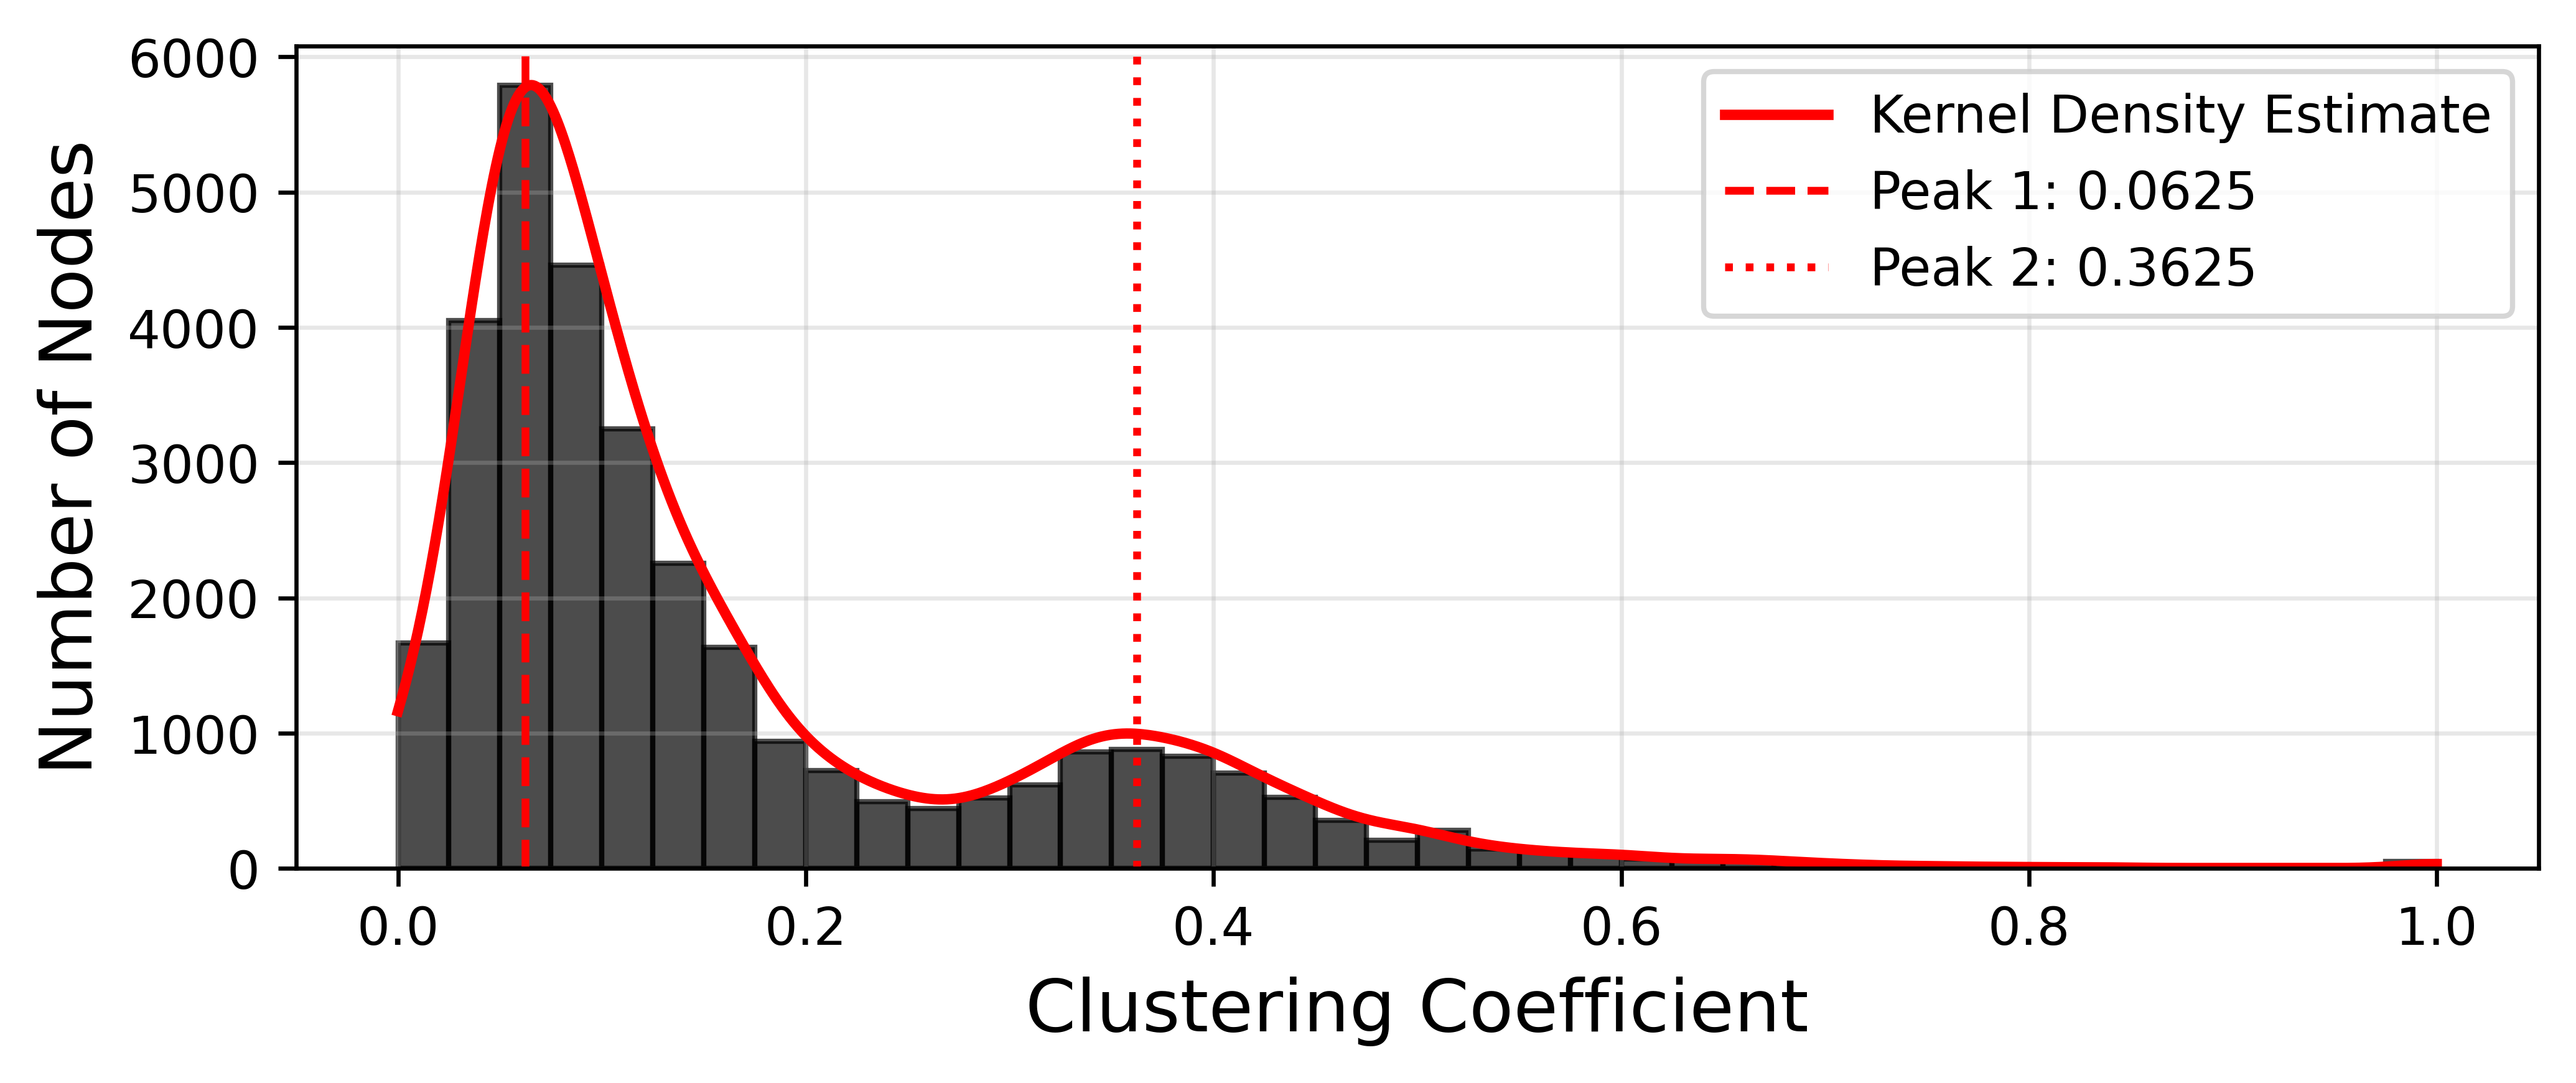

In [13]:
# Plot histogram with enhanced details
print("Plotting enhanced histogram of clustering coefficients...")
plt.figure(figsize=(7, 3), dpi=600)

# Create bins that handle the distribution well
bins = np.linspace(0, 1, 41)  # 40 bins between 0 and 1

counts, edges, bars = plt.hist(clustering_values, bins=bins, alpha=0.7, color='black', 
                               edgecolor='black')

# Add a kernel density estimate
kde_xs = np.linspace(0, 1, 1000)
kde = stats.gaussian_kde(clustering_values)
kde_ys = kde(kde_xs)
scale_factor = np.max(counts) / np.max(kde_ys)  # Scale KDE to match histogram height
plt.plot(kde_xs, kde_ys * scale_factor, 'r-', linewidth=2, label='Kernel Density Estimate')

# Mark the main statistics
# plt.axvline(mean, color='green', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.4f}')
# plt.axvline(median, color='purple', linestyle='dotted', linewidth=2, label=f'Median: {median:.4f}')
g = 0 
# Mark the detected peaks
for i, (peak_loc, _) in enumerate(sorted(peaks, key=lambda x: x[1], reverse=True)[:2]):
    if g == 0:
        plt.axvline(peak_loc, color='red', linestyle='--', linewidth=1.5, 
                label=f'Peak {i+1}: {peak_loc:.4f}')
        g += 1
    else:
        plt.axvline(peak_loc, color='red', linestyle=':', linewidth=1.5, 
                label=f'Peak {i+1}: {peak_loc:.4f}')

# plt.title('Enhanced Histogram of Clustering Coefficients', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# # Add statistics as text on the plot
# stats_text = (
#     f"Total Nodes: {len(clustering_values)}\n"
#     f"Mean: {mean:.4f}\n"
#     f"Median: {median:.4f}\n"
#     f"Std Dev: {std_dev:.4f}\n"
#     f"Skewness: {skewness:.4f}\n"
#     f"Bimodal with peaks at ~0.1 and ~0.4"
# )
# plt.text(0.65, 0.75, stats_text, transform=plt.gca().transAxes, 
#          bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/enhanced_clustering_histogram.png', dpi=600)
print("Saved enhanced clustering coefficient histogram")

Plotting histogram of clustering coefficients...
Saved clustering coefficient histogram


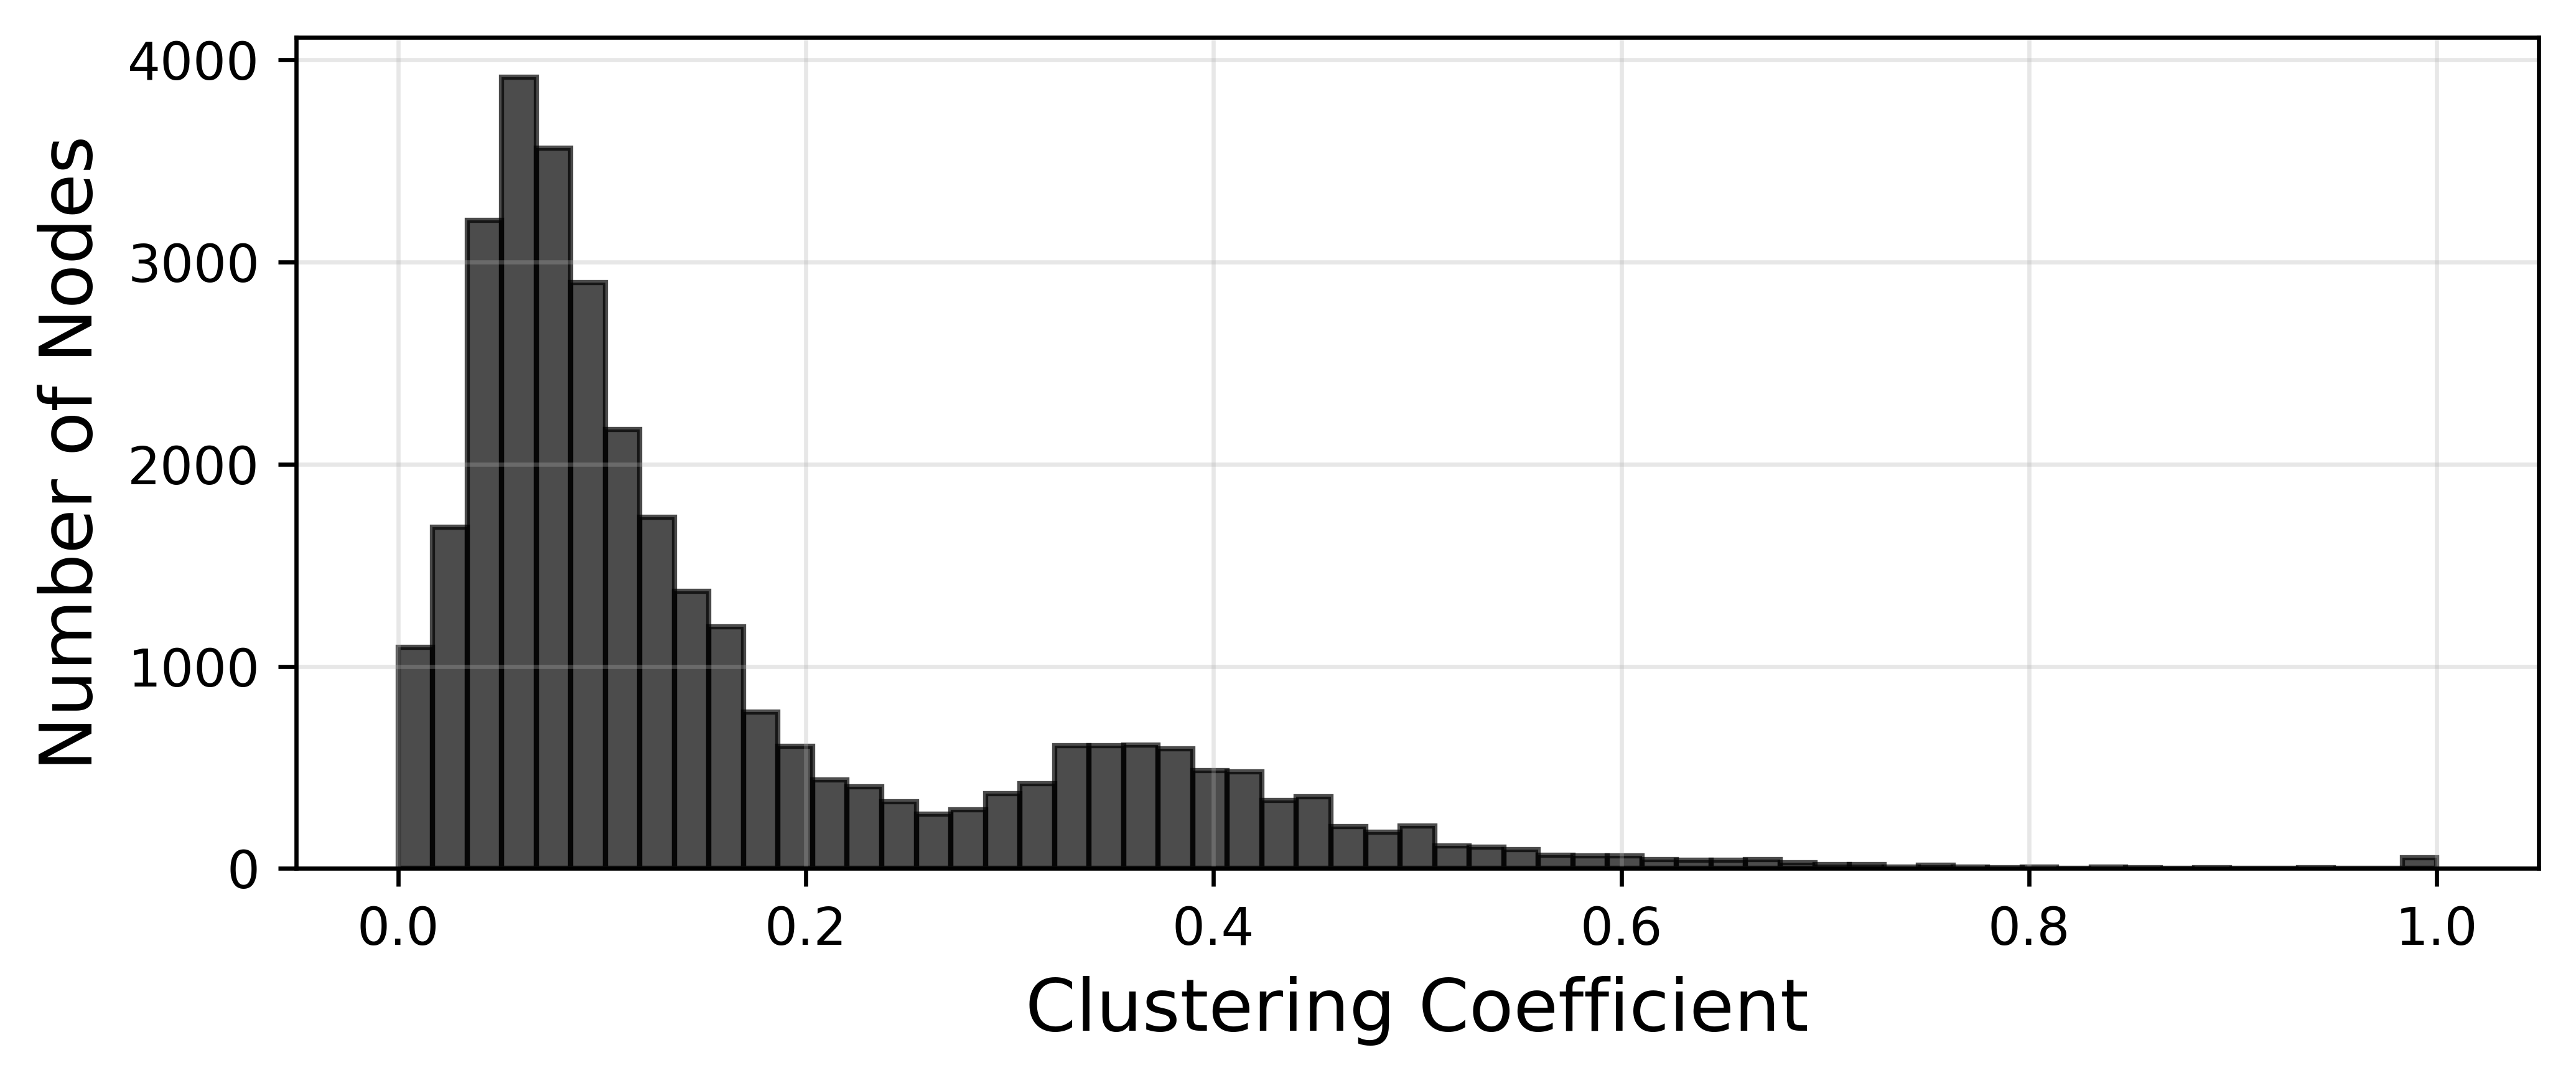

In [28]:
# Plot histogram of clustering coefficients
print("Plotting histogram of clustering coefficients...")
plt.figure(figsize=(7, 3), dpi=600)

# Create bins that handle the distribution well
# Often clustering has many 0s and 1s, with fewer values in between
# We'll use a combination of linear bins and specific bins for 0 and 1
# bins = np.concatenate(([0], np.linspace(0.001, 0.999, 60), [1]))

bins = np.linspace(0,1,60)

plt.hist(clustering_values, bins=bins, alpha=0.7, color='black', 
         edgecolor='black', label='Undirected clustering')
         
# plt.title('Histogram of Clustering Coefficients', fontsize=16)
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.grid(True, alpha=0.3)

# # Add some statistics as text on the plot
# stats_text = (
#     f"Total Nodes: {len(clustering)}\n"
#     f"Avg. Clustering: {sum(clustering_values) / len(clustering_values):.4f}\n"
#     f"Nodes with C=0: {sum(1 for c in clustering_values if c == 0)}\n"
#     f"Nodes with C=1: {sum(1 for c in clustering_values if c == 1)}"
# )
# plt.text(0.7, 0.8, stats_text, transform=plt.gca().transAxes, 
#          bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram")

Starting in-degree distribution analysis...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Calculating in-degrees...
In-degree range: min=0, max=2843
Degree distribution statistics:
Total unique in-degrees: 354
Calculating cumulative distribution...
Identifying high-degree outliers...
Found 334 potential outliers with degree >= 20
Top 5 highest degrees: [269 405 264 368 194] with counts: [1 2 1 1 1]
Fitting log-normal distribution to the main part of the data...
Log-normal fit parameters: mu=1.9179, sigma=0.7155, loc=0.0000
Created 'plots' directory
Saved in-degree distribution plot with log-normal fit at 600dpi
Saved annotated in-degree distribution plot at 600dpi

Comparing with other potential distribution models...
Power law fit parameters: a=0.000057, b=-0.295040
Exponential law fit parameters: a=0.000053, b=-0.055348
Saved distribution 

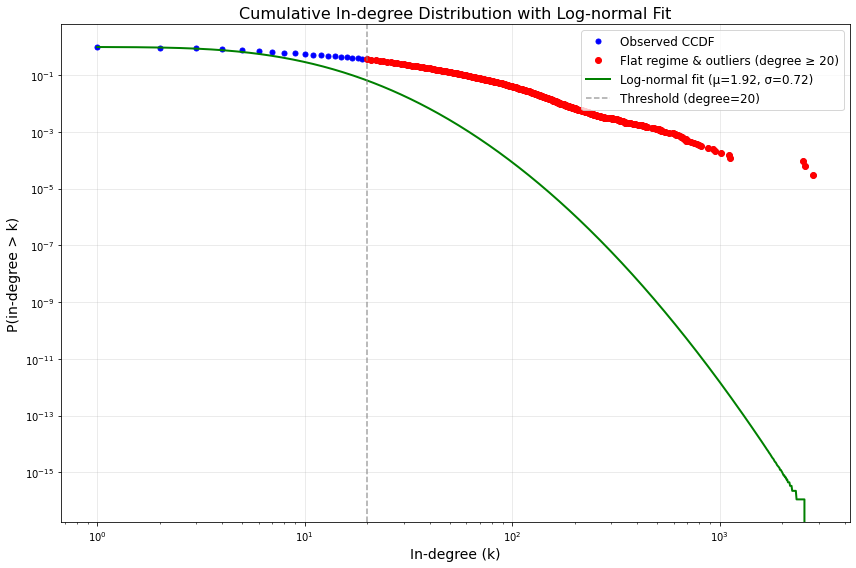

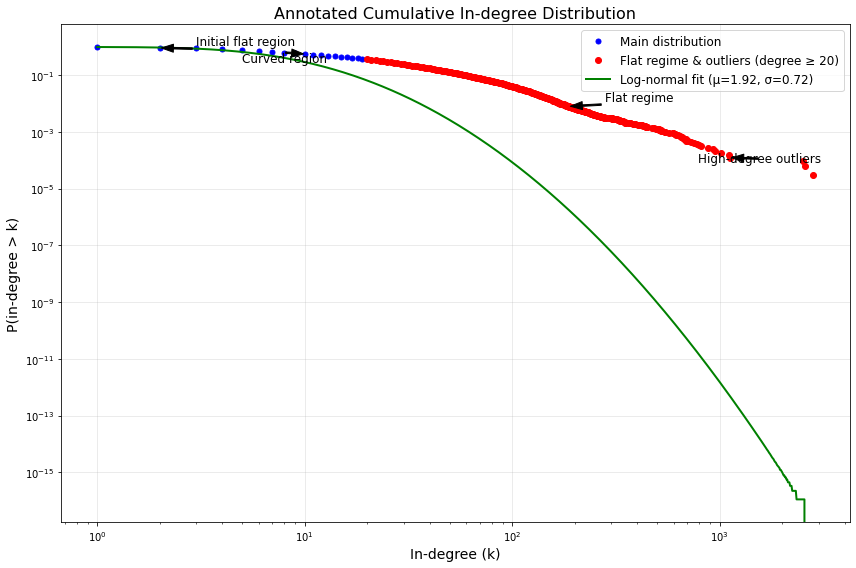

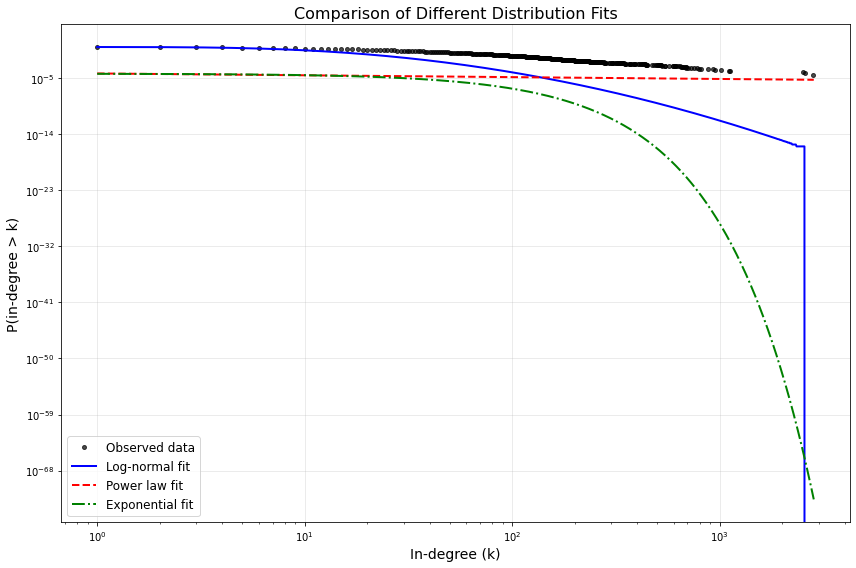

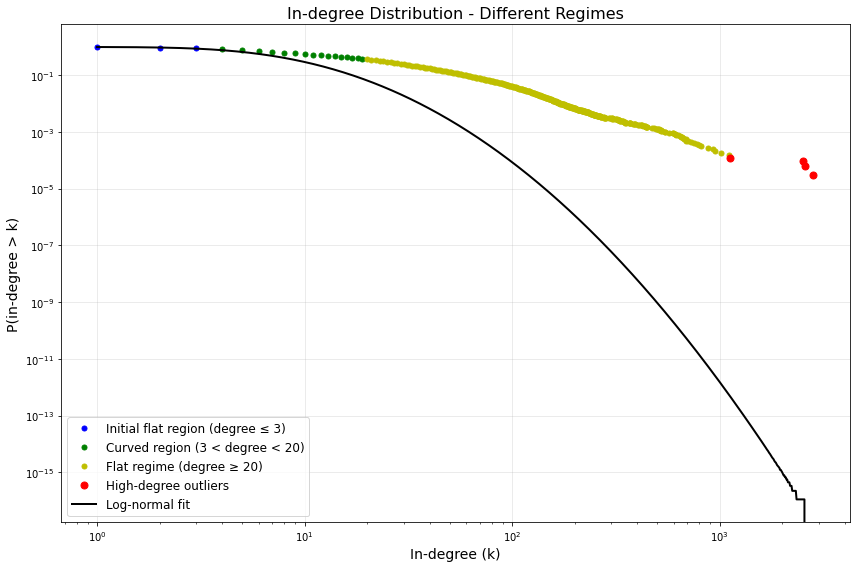

Starting basic log-normal fit to in-degree CDF...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating in-degrees...
In-degree range: min=0, max=2843
Creating empirical CDF...
Preparing data for log-normal fitting...
Using 31835 positive degrees for fitting
Fitting log-normal distribution...
Log-normal fit parameters: mu=2.6355, sigma=1.1281
Saved CDF plot with log-normal fit at 600dpi
Creating complementary CDF (CCDF) plot...
Saved CCDF plot with log-normal fit at 600dpi

Calculating goodness-of-fit metrics...
Mean Squared Error (MSE): 0.000366
Kolmogorov-Smirnov test: statistic=0.0498, p-value=0.0000
Basic log-normal fitting complete!


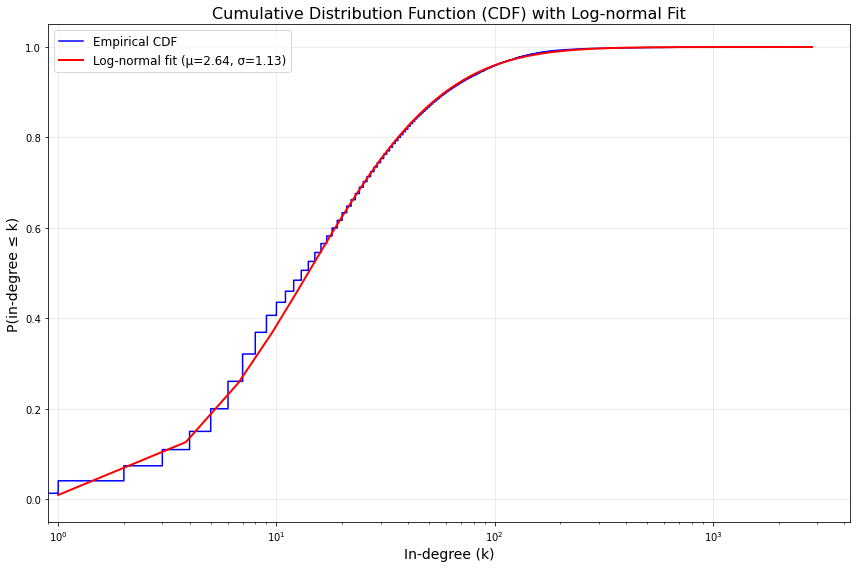

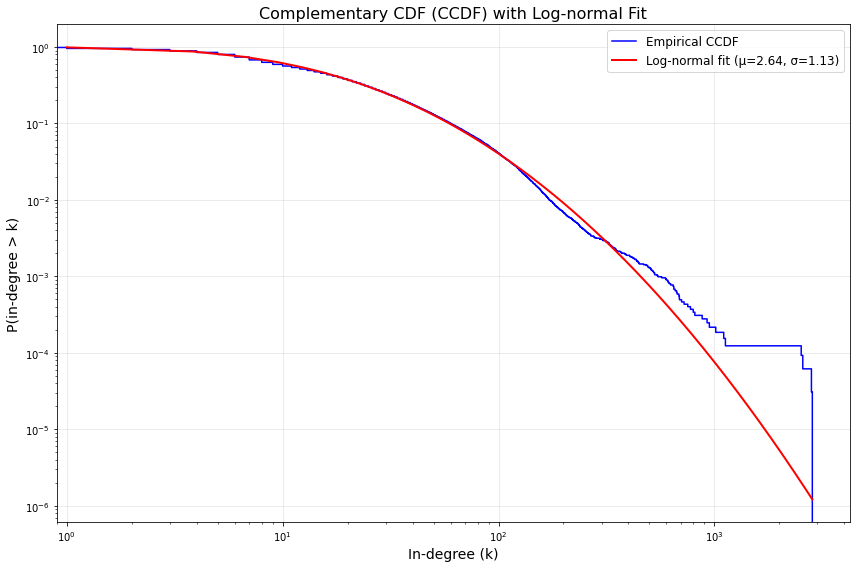

In [31]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

print("Starting basic log-normal fit to in-degree CDF...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate in-degrees
print("Calculating in-degrees...")
in_degrees = [d for n, d in G.in_degree()]
print(f"In-degree range: min={min(in_degrees)}, max={max(in_degrees)}")

# Create empirical CDF
print("Creating empirical CDF...")
# Sort the degrees
sorted_degrees = np.sort(in_degrees)
# Calculate empirical CDF (cumulative proportion of nodes with degree <= x)
ecdf = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)

# For fitting log-normal, we need positive values only
print("Preparing data for log-normal fitting...")
positive_degrees = sorted_degrees[sorted_degrees > 0]
positive_ecdf = ecdf[len(sorted_degrees) - len(positive_degrees):]

print(f"Using {len(positive_degrees)} positive degrees for fitting")

# Fit log-normal distribution to the data
print("Fitting log-normal distribution...")
# stats.lognorm.fit returns shape, loc, scale parameters
# shape is sigma, scale is exp(mu)
shape, loc, scale = stats.lognorm.fit(positive_degrees, floc=0)
sigma = shape
mu = np.log(scale)
print(f"Log-normal fit parameters: mu={mu:.4f}, sigma={sigma:.4f}")

# Generate fitted CDF for plotting
x_fit = np.linspace(min(positive_degrees), max(sorted_degrees), 1000)
y_fit = stats.lognorm.cdf(x_fit, shape, loc=loc, scale=scale)

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Plot the CDF with log-normal fit
plt.figure(figsize=(12, 8))

# Plot empirical CDF
plt.step(sorted_degrees, ecdf, 'b-', where='post', label='Empirical CDF')

# Plot fitted CDF
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree ≤ k)', fontsize=14)
plt.title('Cumulative Distribution Function (CDF) with Log-normal Fit', fontsize=16)
plt.legend(fontsize=12)

# Use log scale for x-axis to better visualize the distribution
plt.xscale('log')
plt.xlim(left=0.9)  # Start just below 1 to show degrees of 1

plt.tight_layout()
plt.savefig('plots/in_degree_cdf_lognormal_fit.png', dpi=600)
print("Saved CDF plot with log-normal fit at 600dpi")

# Also plot the complementary CDF (CCDF) which is more common for power-law-like analyses
print("Creating complementary CDF (CCDF) plot...")
ccdf = 1 - ecdf
y_fit_ccdf = 1 - y_fit

plt.figure(figsize=(12, 8))

# Plot empirical CCDF
plt.step(sorted_degrees, ccdf, 'b-', where='post', label='Empirical CCDF')

# Plot fitted CCDF
plt.plot(x_fit, y_fit_ccdf, 'r-', linewidth=2, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Complementary CDF (CCDF) with Log-normal Fit', fontsize=16)
plt.legend(fontsize=12)

# Use log scales for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.9)

plt.tight_layout()
plt.savefig('plots/in_degree_ccdf_lognormal_fit.png', dpi=600)
print("Saved CCDF plot with log-normal fit at 600dpi")

# Calculate goodness-of-fit
print("\nCalculating goodness-of-fit metrics...")
# Calculate Mean Squared Error (MSE) between empirical CDF and fitted CDF
interp_y_fit = np.interp(sorted_degrees, x_fit, y_fit)
mse = np.mean((ecdf - interp_y_fit) ** 2)
print(f"Mean Squared Error (MSE): {mse:.6f}")

# Perform Kolmogorov-Smirnov test
ks_stat, ks_pval = stats.kstest(positive_degrees, 'lognorm', args=(shape, loc, scale))
print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p-value={ks_pval:.4f}")

print("Basic log-normal fitting complete!")

Starting log-normal fit to in-degree CCDF...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating in-degrees...
In-degree range: min=0, max=2843
Creating empirical CCDF...
Preparing data for log-normal fitting...
Using 31835 positive degrees for fitting
Fitting log-normal distribution...
Log-normal fit parameters: mu=2.6355, sigma=1.1281
Saved CCDF plot with log-normal fit at 600dpi

Calculating goodness-of-fit metrics...
Mean Squared Error (MSE): 0.000366
Log-normal fitting to CCDF complete!


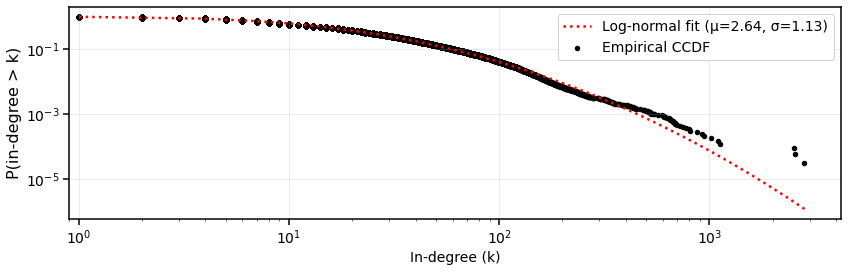

In [67]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

print("Starting log-normal fit to in-degree CCDF...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate in-degrees
print("Calculating in-degrees...")
in_degrees = [d for n, d in G.in_degree()]
print(f"In-degree range: min={min(in_degrees)}, max={max(in_degrees)}")

# Create empirical CCDF
print("Creating empirical CCDF...")
# Sort the degrees
sorted_degrees = np.sort(in_degrees)
# Calculate empirical CDF (cumulative proportion of nodes with degree <= x)
ecdf = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
# Calculate complementary CDF (CCDF = 1 - CDF)
ccdf = 1 - ecdf

# For fitting log-normal, we need positive values only
print("Preparing data for log-normal fitting...")
positive_degrees = sorted_degrees[sorted_degrees > 0]
positive_ccdf = ccdf[len(sorted_degrees) - len(positive_degrees):]

print(f"Using {len(positive_degrees)} positive degrees for fitting")

# Fit log-normal distribution to the data
print("Fitting log-normal distribution...")
# stats.lognorm.fit returns shape, loc, scale parameters
# shape is sigma, scale is exp(mu)
shape, loc, scale = stats.lognorm.fit(positive_degrees, floc=0)
sigma = shape
mu = np.log(scale)
print(f"Log-normal fit parameters: mu={mu:.4f}, sigma={sigma:.4f}")

# Generate fitted CCDF for plotting
x_fit = np.linspace(min(positive_degrees), max(sorted_degrees), 1000)
y_fit = 1 - stats.lognorm.cdf(x_fit, shape, loc=loc, scale=scale)

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Plot the CCDF with log-normal fit
plt.figure(figsize=(12, 4))

# Set bigger font sizes for better visibility at small sizes
plt.rcParams.update({'font.size': 14})

# Plot empirical CCDF as black dots
plt.scatter(sorted_degrees, ccdf, color='black', s=20, label='Empirical CCDF')

# Plot fitted CCDF as red dotted line
plt.plot(x_fit, y_fit, 'r:', linewidth=2.5, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=16)
# plt.title('Complementary CDF with Log-normal Fit', fontsize=18, fontweight='bold')
plt.legend(fontsize=14, framealpha=0.9)

# Use log scales for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.9)

# Add thick border
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

# Increase tick width and length for better visibility
plt.tick_params(width=1.5, length=6, labelsize=14)

plt.tight_layout()
plt.savefig('plots/in_degree_ccdf_lognormal_fit.png', dpi=600)
print("Saved CCDF plot with log-normal fit at 600dpi")

# Calculate goodness-of-fit
print("\nCalculating goodness-of-fit metrics...")
# Calculate Mean Squared Error (MSE) between empirical CCDF and fitted CCDF
interp_y_fit = np.interp(sorted_degrees, x_fit, y_fit)
mse = np.mean((ccdf - interp_y_fit) ** 2)
print(f"Mean Squared Error (MSE): {mse:.6f}")

print("Log-normal fitting to CCDF complete!")

Saved CCDF plot with log-normal fit at 600dpi


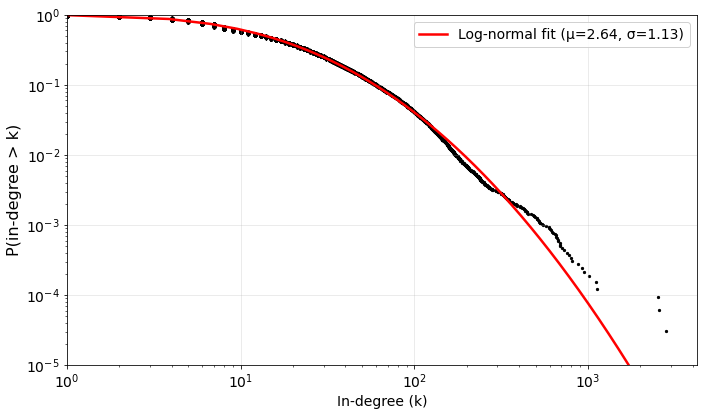

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Assume sorted_degrees and ccdf are numpy arrays; if not, convert them:
sorted_degrees = np.array(sorted_degrees)
ccdf = np.array(ccdf)

# Define sampling factor for the dense region (adjust as needed)
sample_factor = 1

# Create masks for the dense region (between 20 and 100) and sparse regions (outside this interval)
dense_mask = (sorted_degrees >= 20) & (sorted_degrees <= 100)
sparse_mask = ~dense_mask

# Get indices for each region
dense_indices = np.where(dense_mask)[0]
sparse_indices = np.where(sparse_mask)[0]

# Sample the dense region using the sampling factor
sampled_dense_indices = dense_indices[::sample_factor]

# Combine the sampled dense indices with all sparse indices, then sort to maintain order
combined_indices = np.sort(np.concatenate((sampled_dense_indices, sparse_indices)))

# Create sampled arrays for plotting
sampled_degrees = sorted_degrees[combined_indices]
sampled_ccdf = ccdf[combined_indices]

# Plot the CCDF with log-normal fit
plt.figure(figsize=(10, 6))

# Set bigger font sizes for better visibility
plt.rcParams.update({'font.size': 14})

# Plot empirical CCDF as black dots using the sampled data
plt.scatter(sampled_degrees, sampled_ccdf, color='black', s=5)

# Plot fitted CCDF as a solid red line (assuming x_fit, y_fit, mu, and sigma are defined)
plt.plot(x_fit, y_fit, 'r-', linewidth=2.5, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=16)
plt.legend(fontsize=14, framealpha=0.9)

# Use log scales for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=1)
plt.ylim(10e-6,10e-1)  # Set y limits between 10e0 and 10e5

plt.tight_layout()
plt.savefig('plots/in_degree_ccdf_lognormal_fit.png', dpi=600)
print("Saved CCDF plot with log-normal fit at 600dpi")


Starting log-normal fit to in-degree CCDF...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Graph created with 32272 nodes and 849981 edges
Calculating out-degrees...
out-degree range: min=0, max=2763
Creating empirical CCDF...
Preparing data for log-normal fitting...
Using 31855 positive degrees for fitting
Fitting log-normal distribution...
Log-normal fit parameters: mu=2.7018, sigma=1.0608
Saved CCDF plot with log-normal fit at 600dpi

Calculating goodness-of-fit metrics...
Mean Squared Error (MSE): 0.000217
Log-normal fitting to CCDF complete!


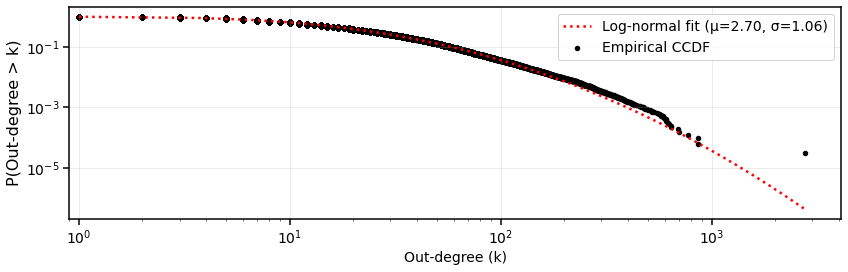

In [69]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

print("Starting log-normal fit to in-degree CCDF...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Calculate out-degrees
print("Calculating out-degrees...")
out_degrees = [d for n, d in G.out_degree()]
print(f"out-degree range: min={min(out_degrees)}, max={max(out_degrees)}")

# Create empirical CCDF
print("Creating empirical CCDF...")
# Sort the degrees
sorted_degrees = np.sort(out_degrees)
# Calculate empirical CDF (cumulative proportion of nodes with degree <= x)
ecdf = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
# Calculate complementary CDF (CCDF = 1 - CDF)
ccdf = 1 - ecdf

# For fitting log-normal, we need positive values only
print("Preparing data for log-normal fitting...")
positive_degrees = sorted_degrees[sorted_degrees > 0]
positive_ccdf = ccdf[len(sorted_degrees) - len(positive_degrees):]

print(f"Using {len(positive_degrees)} positive degrees for fitting")

# Fit log-normal distribution to the data
print("Fitting log-normal distribution...")
# stats.lognorm.fit returns shape, loc, scale parameters
# shape is sigma, scale is exp(mu)
shape, loc, scale = stats.lognorm.fit(positive_degrees, floc=0)
sigma = shape
mu = np.log(scale)
print(f"Log-normal fit parameters: mu={mu:.4f}, sigma={sigma:.4f}")

# Generate fitted CCDF for plotting
x_fit = np.linspace(min(positive_degrees), max(sorted_degrees), 1000)
y_fit = 1 - stats.lognorm.cdf(x_fit, shape, loc=loc, scale=scale)

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Plot the CCDF with log-normal fit
plt.figure(figsize=(12, 4))

# Set bigger font sizes for better visibility at small sizes
plt.rcParams.update({'font.size': 14})

# Plot empirical CCDF as black dots
plt.scatter(sorted_degrees, ccdf, color='black', s=20, label='Empirical CCDF')

# Plot fitted CCDF as red dotted line
plt.plot(x_fit, y_fit, 'r:', linewidth=2.5, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(Out-degree > k)', fontsize=16)
# plt.title('Complementary CDF with Log-normal Fit', fontsize=18, fontweight='bold')
plt.legend(fontsize=14, framealpha=0.9)

# Use log scales for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0.9)

# Add thick border
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

# Increase tick width and length for better visibility
plt.tick_params(width=1.5, length=6, labelsize=14)

plt.tight_layout()
plt.savefig('plots/out_degree_ccdf_lognormal_fit.png', dpi=600)
print("Saved CCDF plot with log-normal fit at 600dpi")

# Calculate goodness-of-fit
print("\nCalculating goodness-of-fit metrics...")
# Calculate Mean Squared Error (MSE) between empirical CCDF and fitted CCDF
interp_y_fit = np.interp(sorted_degrees, x_fit, y_fit)
mse = np.mean((ccdf - interp_y_fit) ** 2)
print(f"Mean Squared Error (MSE): {mse:.6f}")

print("Log-normal fitting to CCDF complete!")

Saved CCDF plot with log-normal fit at 600dpi


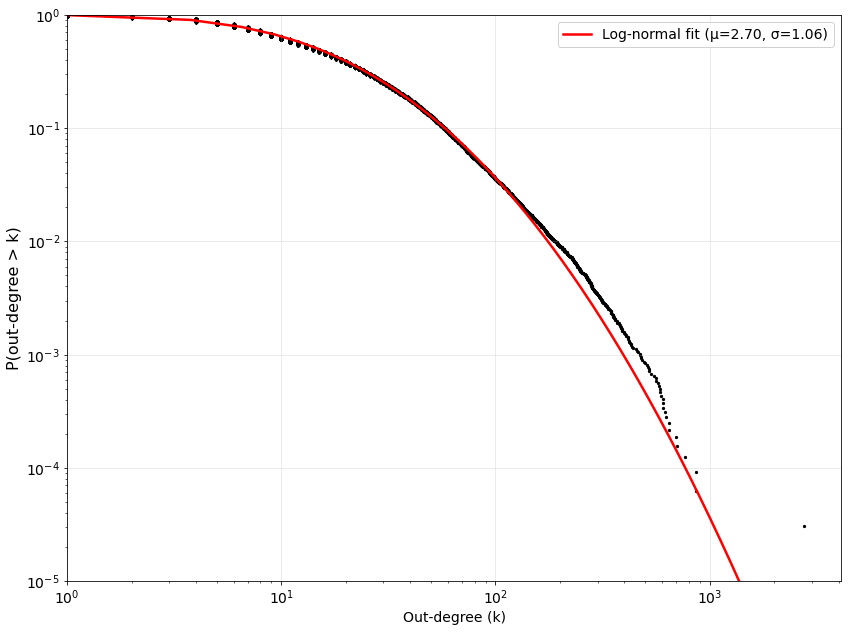

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Assume sorted_degrees and ccdf are numpy arrays; if not, convert them:
sorted_degrees = np.array(sorted_degrees)
ccdf = np.array(ccdf)

# Define sampling factor for the dense region (adjust as needed)
sample_factor = 1

# Create masks for the dense region (between 20 and 100) and sparse regions (outside this interval)
dense_mask = (sorted_degrees >= 20) & (sorted_degrees <= 100)
sparse_mask = ~dense_mask

# Get indices for each region
dense_indices = np.where(dense_mask)[0]
sparse_indices = np.where(sparse_mask)[0]

# Sample the dense region using the sampling factor
sampled_dense_indices = dense_indices[::sample_factor]

# Combine the sampled dense indices with all sparse indices, then sort to maintain order
combined_indices = np.sort(np.concatenate((sampled_dense_indices, sparse_indices)))

# Create sampled arrays for plotting
sampled_degrees = sorted_degrees[combined_indices]
sampled_ccdf = ccdf[combined_indices]

# Plot the CCDF with log-normal fit
plt.figure(figsize=(12,9))

# Plot empirical CCDF as black dots using the sampled data
plt.scatter(sampled_degrees, sampled_ccdf, color='black', s=5)

# Plot fitted CCDF as a solid red line (assuming x_fit, y_fit, mu, and sigma are defined)
plt.plot(x_fit, y_fit, 'r-', linewidth=2.5, label=f'Log-normal fit (μ={mu:.2f}, σ={sigma:.2f})')

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=16)
plt.legend(fontsize=14, framealpha=0.9)

# Use log scales for better visualization
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=1)
plt.ylim(10e-6,10e-1)  # Set y limits between 10e0 and 10e5

plt.tight_layout()
plt.savefig('plots/out_degree_ccdf_lognormal_fit.png', dpi=600)
print("Saved CCDF plot with log-normal fit at 600dpi")

Starting network analysis script...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Calculating in-degrees and out-degrees...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Sorting degree distributions...
Calculating cumulative distributions...
Plotting cumulative degree distributions...
Saved in-degree distribution plot at 600dpi
Saved out-degree distribution plot at 600dpi
Saved combined degree distribution plot at 600dpi
Analysis complete!

Summary Statistics:
Total nodes: 32272
Total edges: 849981
Average in-degree: 26.34
Average out-degree: 26.34
Maximum in-degree: 2843
Maximum out-degree: 2763


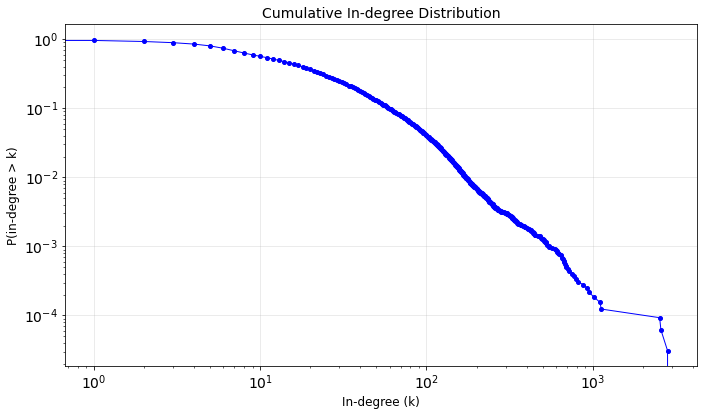

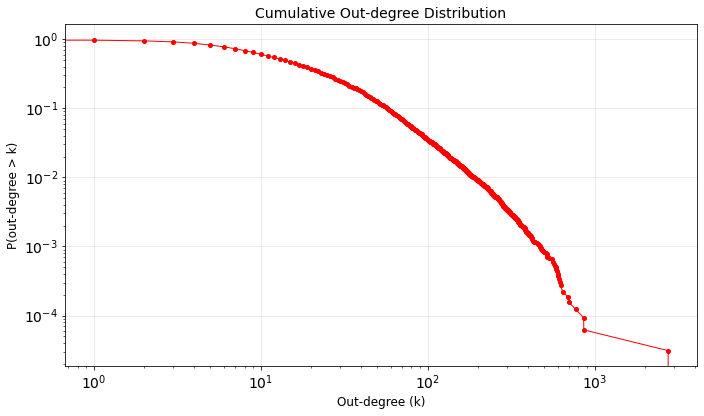

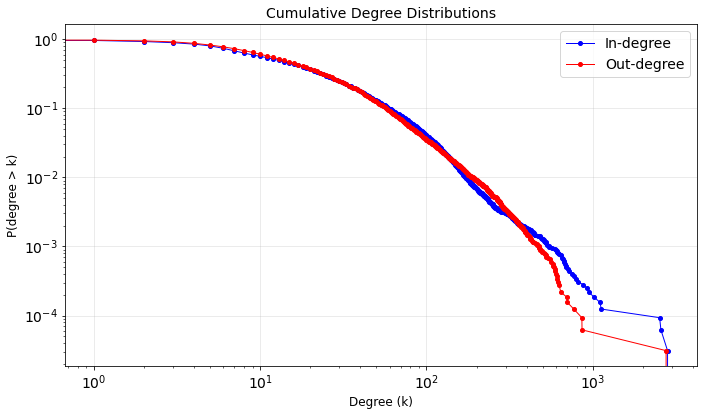

In [75]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

print("Starting network analysis script...")

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Calculate in-degrees and out-degrees
print("Calculating in-degrees and out-degrees...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Count frequencies of each degree
in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

# Sort the degrees in ascending order
print("Sorting degree distributions...")
sorted_in_degrees = sorted(in_degree_counts.items())
sorted_out_degrees = sorted(out_degree_counts.items())

# Calculate cumulative distributions
print("Calculating cumulative distributions...")
total_nodes = G.number_of_nodes()

# For in-degrees
x_in = [k for k, _ in sorted_in_degrees]
y_in = []
count_so_far = 0
for _, count in sorted_in_degrees:
    count_so_far += count
    y_in.append(1 - count_so_far / total_nodes)  # P(degree > k)

# For out-degrees
x_out = [k for k, _ in sorted_out_degrees]
y_out = []
count_so_far = 0
for _, count in sorted_out_degrees:
    count_so_far += count
    y_out.append(1 - count_so_far / total_nodes)  # P(degree > k)

print("Plotting cumulative degree distributions...")

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Plot in-degree cumulative distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_in, y_in, 'bo-', markersize=4, linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('plots/in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution plot at 600dpi")

# Plot out-degree cumulative distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_out, y_out, 'ro-', markersize=4, linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('plots/out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution plot at 600dpi")

# Combined plot
plt.figure(figsize=(10, 6))
plt.loglog(x_in, y_in, 'bo-', markersize=4, linewidth=1, label='In-degree')
plt.loglog(x_out, y_out, 'ro-', markersize=4, linewidth=1, label='Out-degree')
plt.grid(True, alpha=0.3)
plt.xlabel('Degree (k)', fontsize=12)
plt.ylabel('P(degree > k)', fontsize=12)
plt.title('Cumulative Degree Distributions', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/combined_degree_distribution.png', dpi=600)
print("Saved combined degree distribution plot at 600dpi")

print("Analysis complete!")

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"Average in-degree: {sum(in_degrees.values()) / total_nodes:.2f}")
print(f"Average out-degree: {sum(out_degrees.values()) / total_nodes:.2f}")
print(f"Maximum in-degree: {max(in_degrees.values())}")
print(f"Maximum out-degree: {max(out_degrees.values())}")

Plotting in-degree distribution...
Saved in-degree distribution plot at 600dpi
Plotting out-degree distribution...
Saved out-degree distribution plot at 600dpi


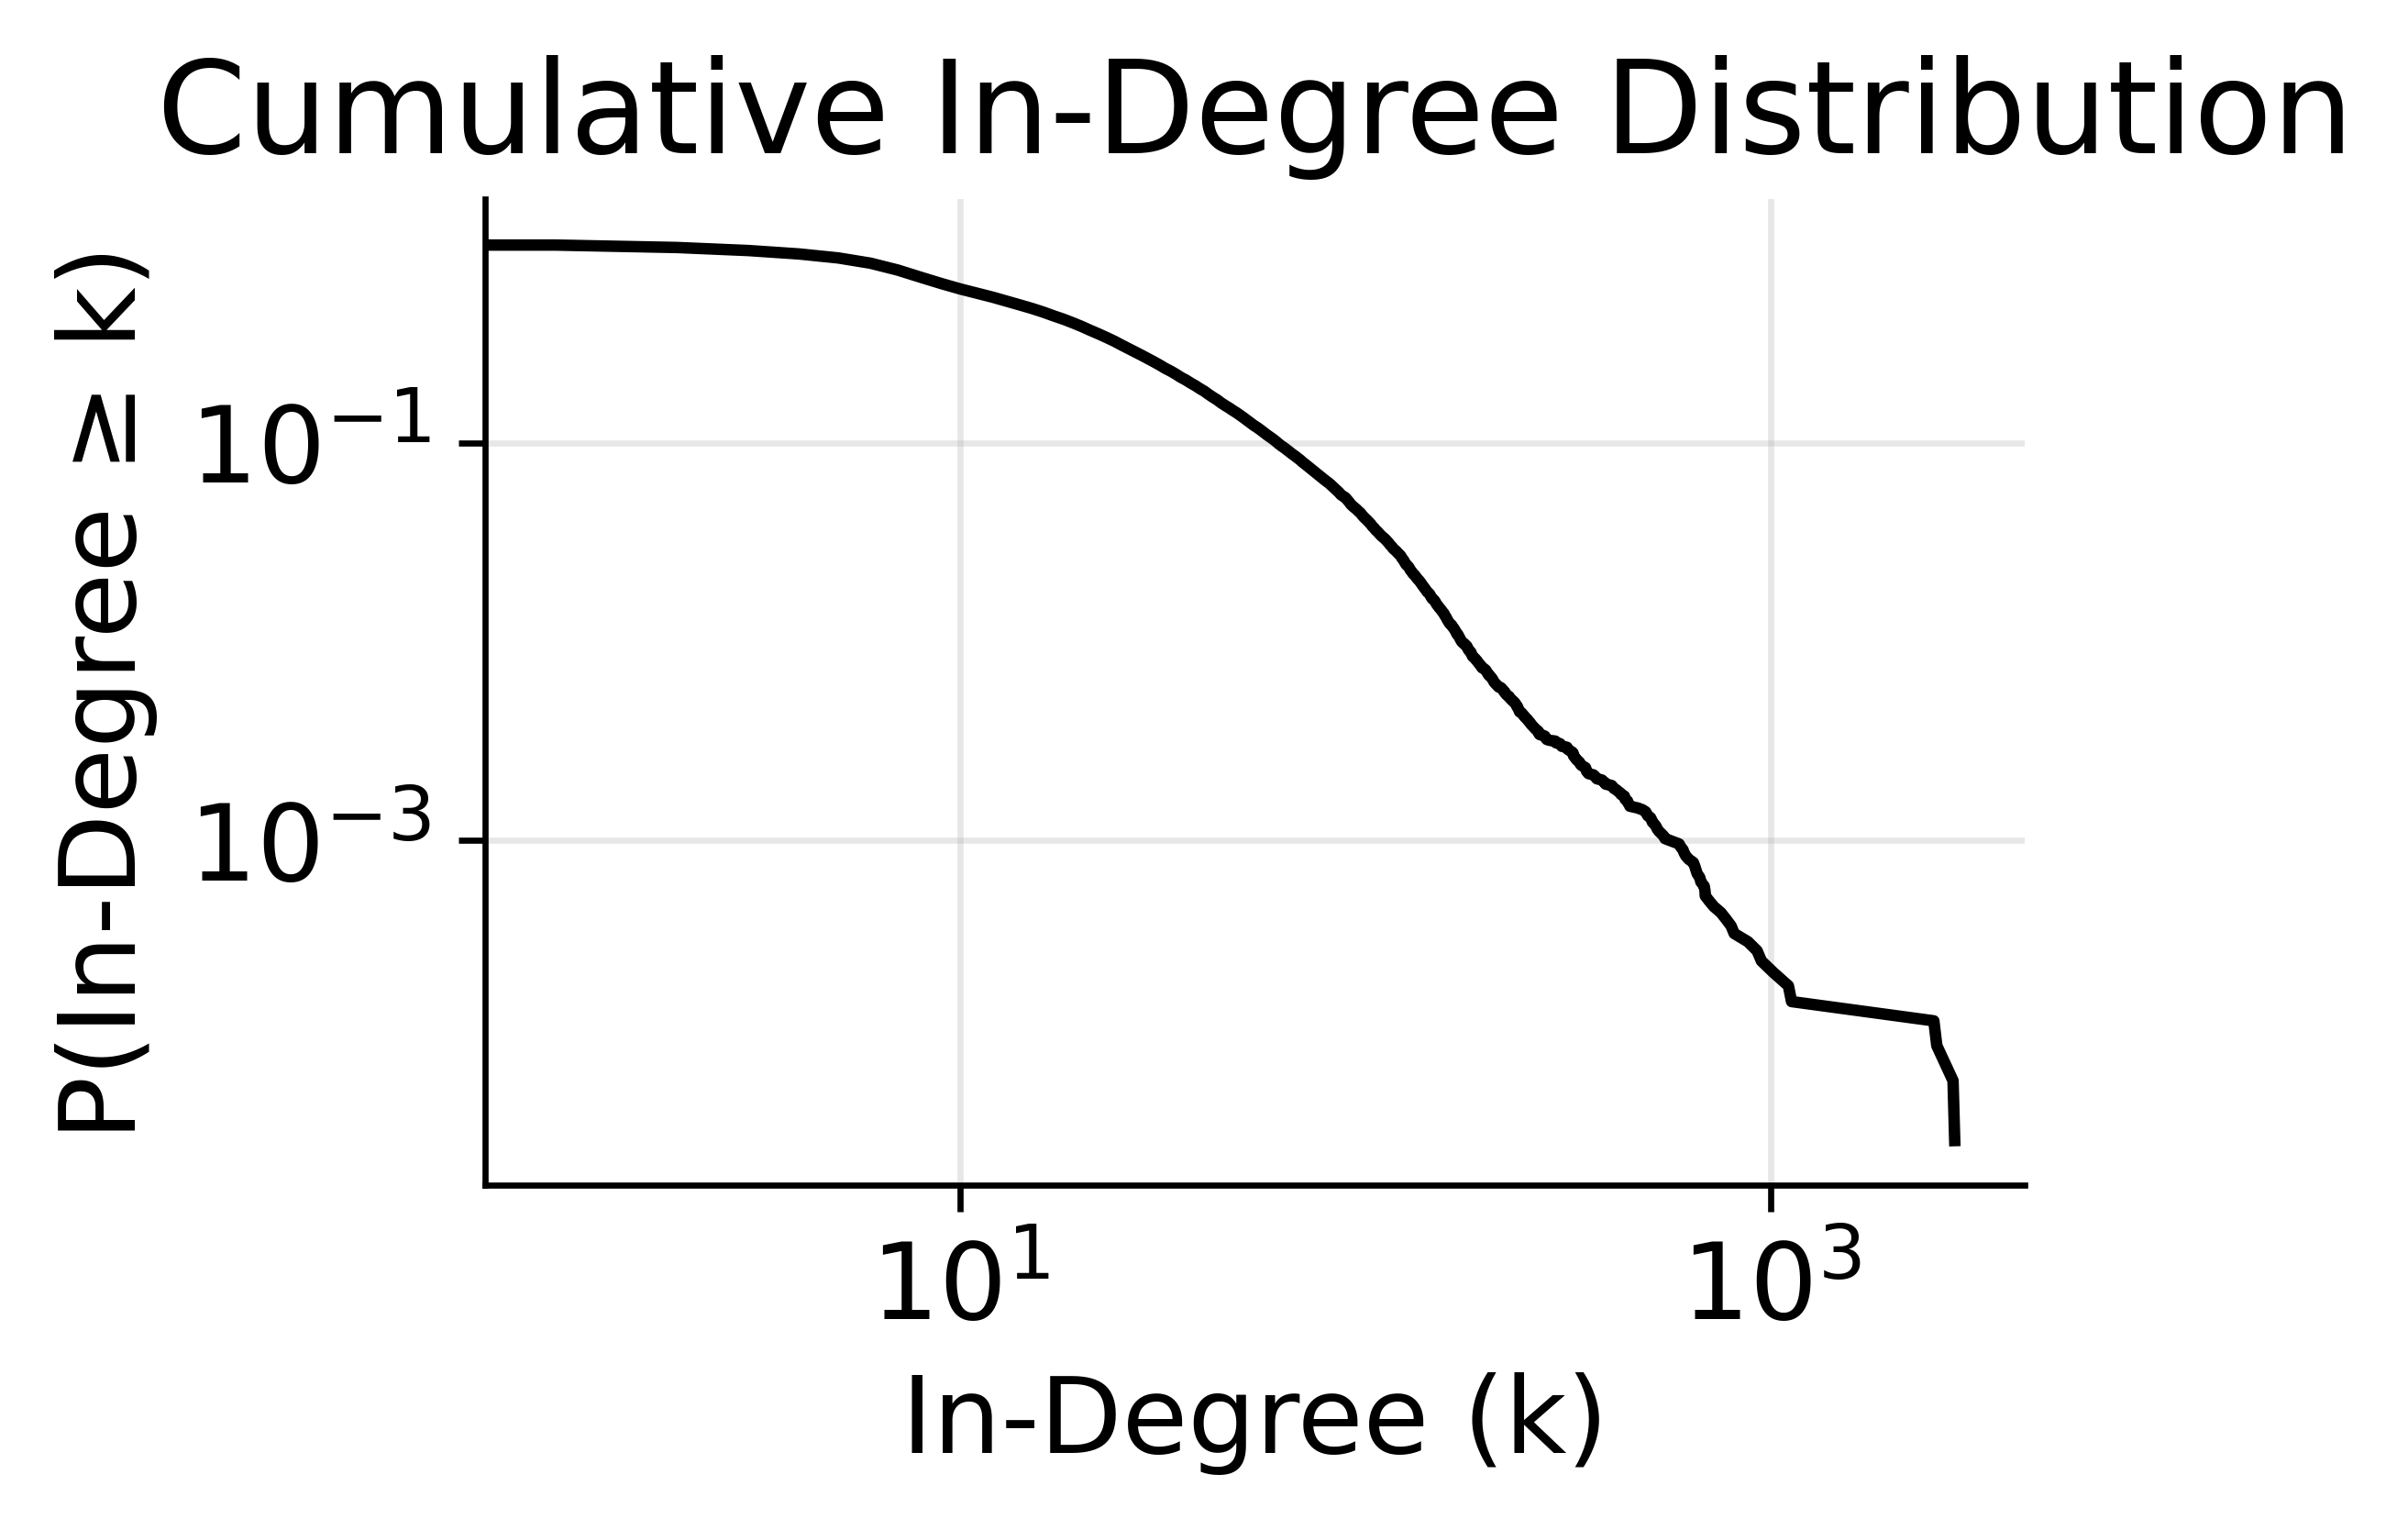

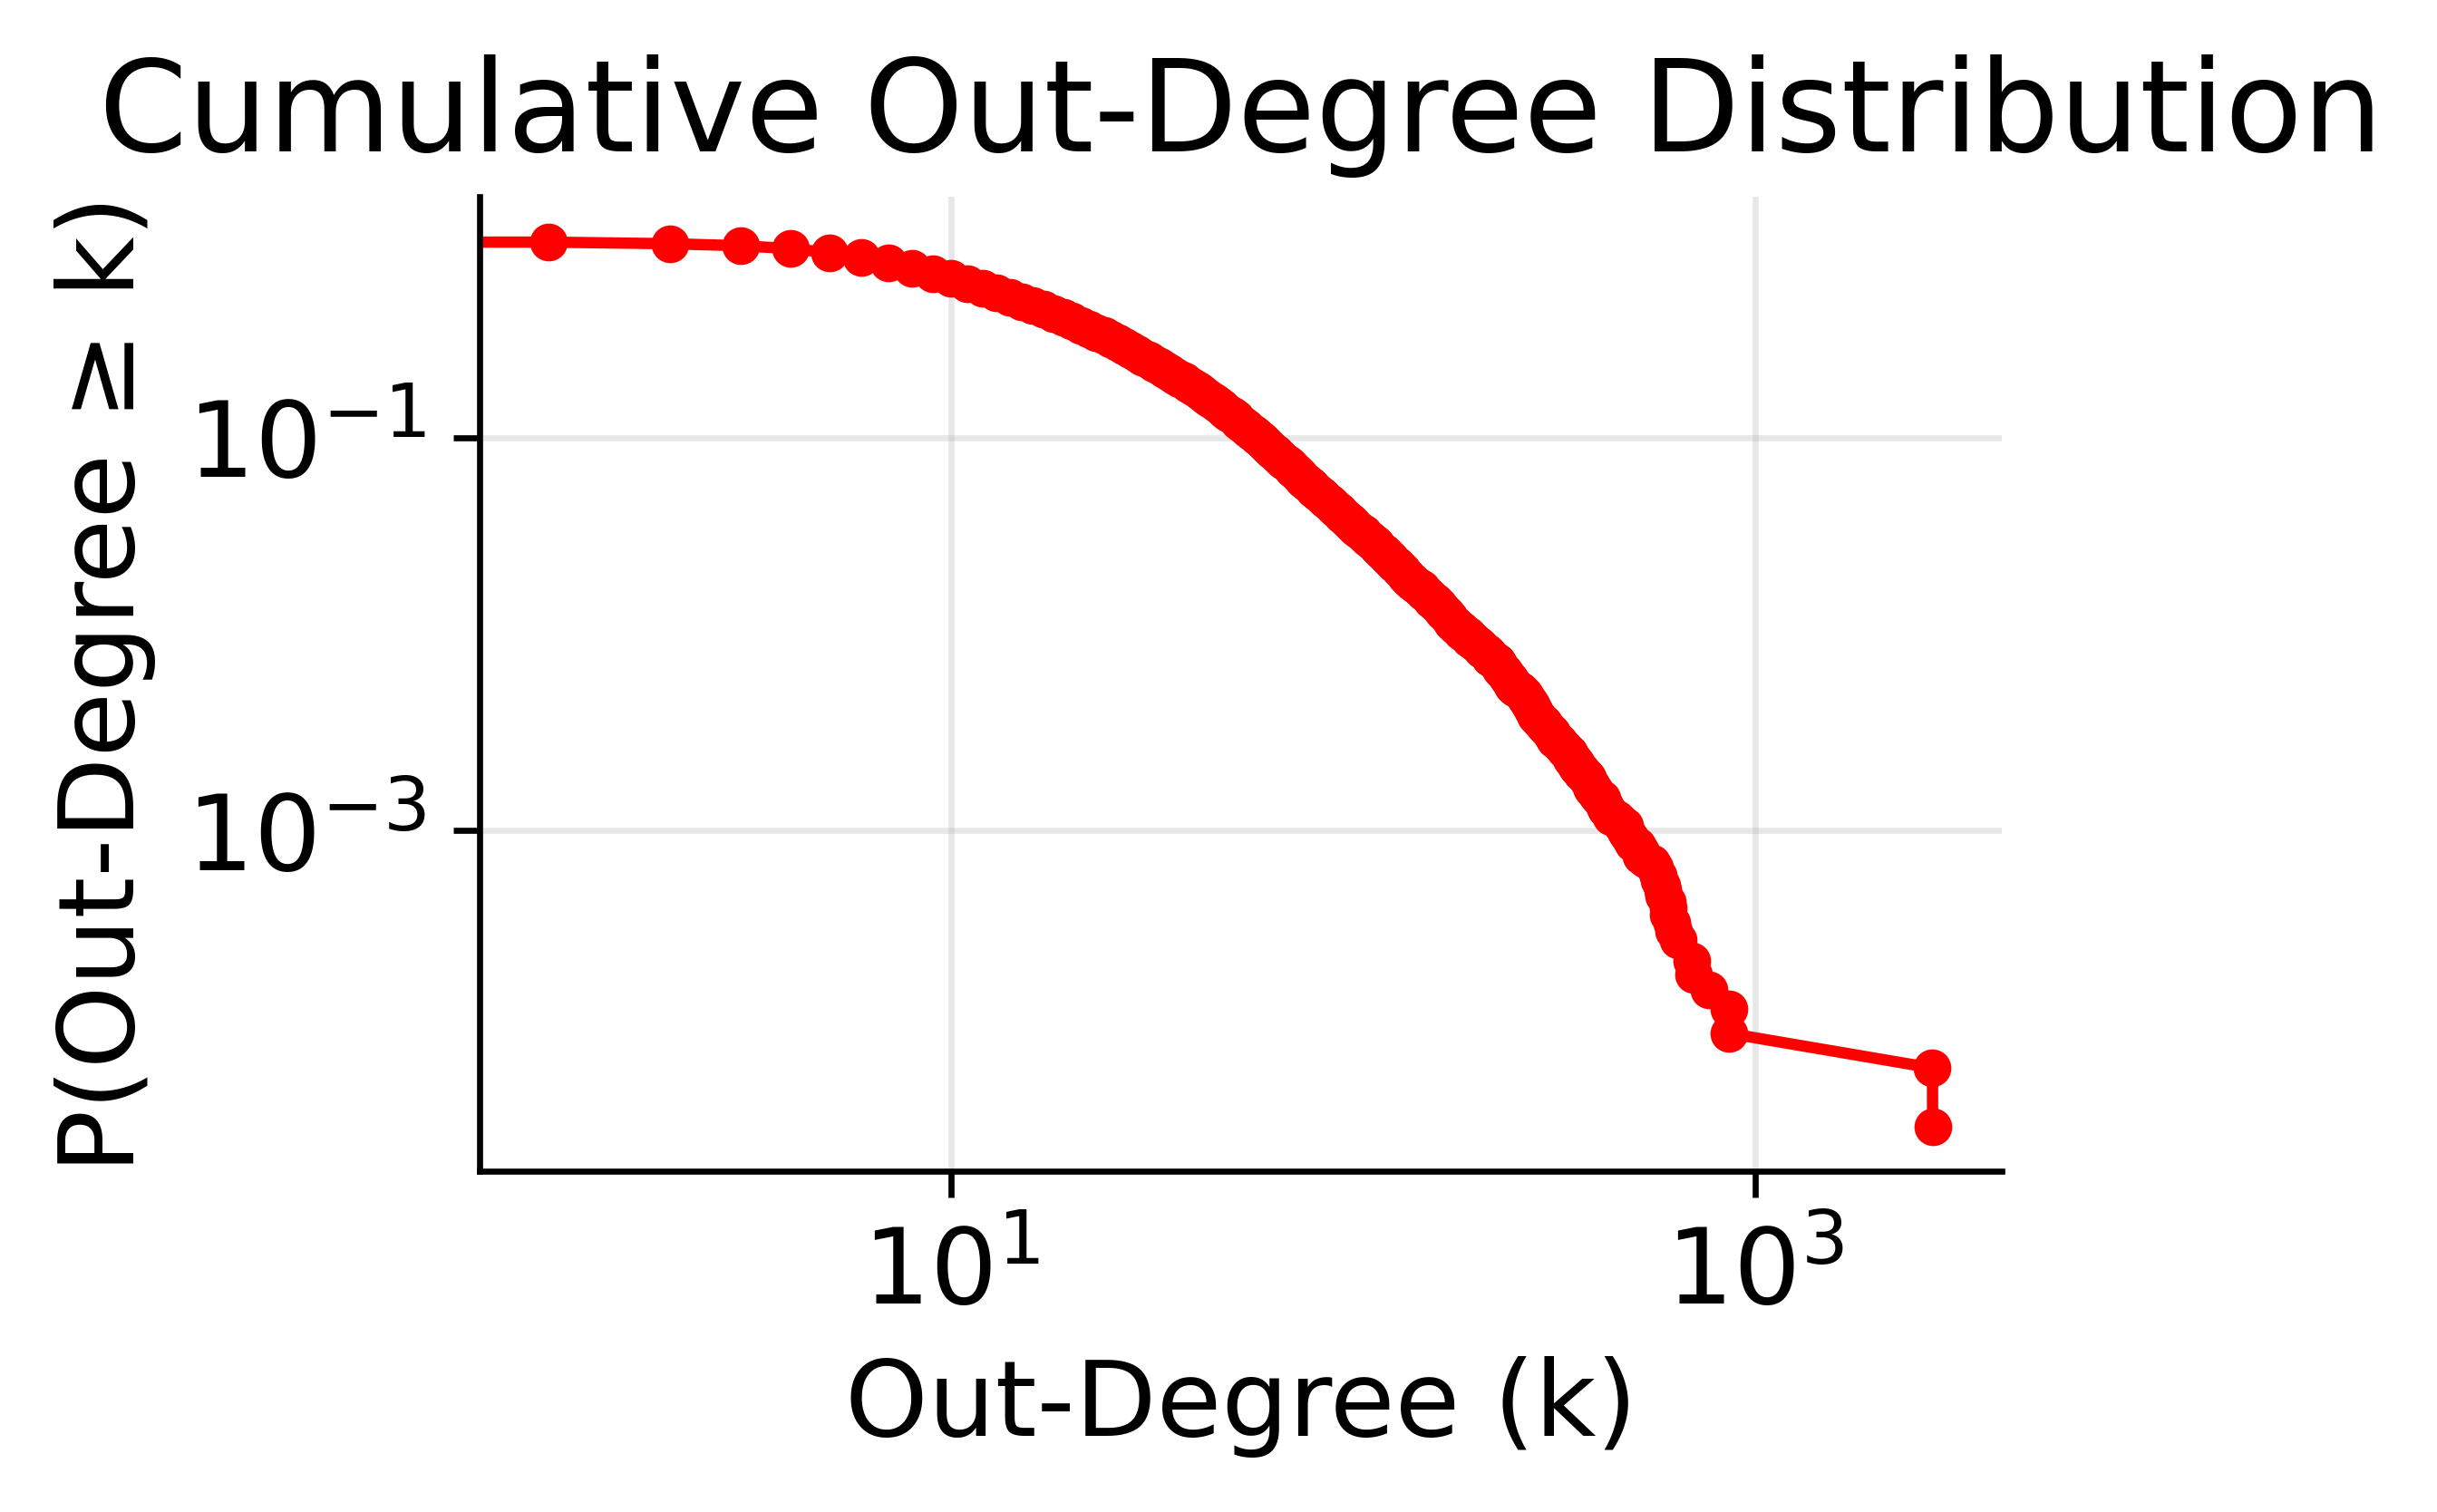

In [76]:
# Plot in-degree distribution
print("Plotting in-degree distribution...")
plt.figure(figsize=(4, 3), dpi=600)
plt.plot(in_x, in_cumulative_y, 'bo-', markersize=0.1, color='black')
plt.title('Cumulative In-Degree Distribution')
plt.xlabel('In-Degree (k)')
plt.ylabel('P(In-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution plot at 600dpi")

# Plot out-degree distribution
print("Plotting out-degree distribution...")
plt.figure(figsize=(4, 3), dpi=600)
plt.plot(out_x, out_cumulative_y, 'ro-', markersize=4)
plt.title('Cumulative Out-Degree Distribution')
plt.xlabel('Out-Degree (k)')
plt.ylabel('P(Out-Degree ≥ k)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution plot at 600dpi")
